
# TSLA Liquidity Zone Analysis

This notebook performs a **liquidity zone analysis** on TSLA across two timeframes:

| Timeframe | Interval | Source | Date Range |
|---|---|---|---|
| HTF (High Timeframe) | Daily OHLCV (20-trading day rolling window)| Yahoo Finance (yfinance) | 2021-01-04 → 2024-09-30 |
| LTF (Low Timeframe) | Hourly OHLCV (10-trading day rolling window)| Twelve Data | 2021-01-04 → 2024-09-30 |

> **Note:** Yahoo Finance only retains ~730 days of hourly data, so the LTF series is loaded from a local file. Daily data covers the full requested range.

---------------------------------------------------------------------------
Parameter logic used in this revised notebook
---------------------------------------------------------------------------
- HTFLOOKBACKDAYS = 20  -> daily structural context; long enough to capture recent multi-session liquidity, short enough to   avoid stale zones.
- LTFLOOKBACKDAYS = 10  -> hourly local context; shorter than HTF so sweep detection reacts to recent intraday behaviour around higher-timeframe zones.
- VOLROLLWINDOW  = 20   -> activity baseline only; this smooths volume and does not define the structural zone horizon.
- HTFPIVOTWINDOW = 5    -> balanced confirmation for daily swings.
- LTFPIVOTWINDOW = 35   -> stricter hourly pivots to reduce noise in TSLA intraday bars.
- SWEEPTRENDLOOKBACK = 10 -> short trend context before a sweep/reversal setup.



## Part 1 — Setup & Data Loading

Configure the ticker and date range, download **daily** OHLCV data from Yahoo Finance, and read **hourly** data from the local CSV. Both datasets are saved to `data/raw/` with date-stamped filenames, then reloaded and verified.

Volume feature config constants (`VOL_ROLL_WINDOW`, `VOL_SPIKE_THRESHOLD`, `USE_VOL_FILTER`) and the `USE_MIDAS` flag are declared here so they are available to all subsequent parts.

The final cell of Part 1 loads the **MIDAS order-level dataset** (`data/MIDAS data (TSLA).xlsx`), providing institutional microstructure metrics that will be attached to zone tables for analysis.


In [1]:
# run for the first time to install dependencies in the environment
%pip install yfinance pandas numpy matplotlib statsmodels plotly openpyxl lxml
%pip install --upgrade nbformat ipykernel jupyter

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# ---------------------------------------------------------------------------
# Imports & parameters
# ---------------------------------------------------------------------------
import yfinance as yf
import pandas as pd
from datetime import date, timedelta
from pathlib import Path
from dataclasses import dataclass
from typing import List, Optional, Tuple
import os
import numpy as np
import matplotlib.pyplot as plt

TICKER     = "TSLA"
START_DATE = date(2021, 1, 4)
END_DATE   = date(2024, 9, 30)

# Output directory (created automatically if missing)
OUT_DIR = Path("data/raw")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Ticker     : {TICKER}")
print(f"Start date : {START_DATE}")
print(f"End date   : {END_DATE}")
print(f"Output dir : {OUT_DIR.resolve()}")

Ticker     : TSLA
Start date : 2021-01-04
End date   : 2024-09-30
Output dir : /Users/kamanlee_1/Desktop/RMSC 6007/RMSC6007_Liquidity-Zones-5/data/raw


In [3]:
# ===========================================================================
# Zone Data Structure (Mutable Class)
# ===========================================================================

class Zone:
    """
    Mutable zone object storing liquidity level state and lifecycle metrics.
    Uses __slots__ for memory efficiency and performance.
    Includes decay factor for automatic zone expiration after HTF_LOOKBACK_DAYS.
    """
    __slots__ = [
        'top', 'bottom', 'height', 'touches',
        'first_idx', 'last_idx', 
        'first_time', 'last_time',
        'total_volume', 'avg_volume', 'avg_absorption',
        'zone_type', 
        'pattern_strength', 'volume_confirmation', 'institutional_score', 'composite_score',
        'is_double_top', 'is_double_bottom',
        'formation_volume_ratio',
        'zone_id', 'origin_vol', 'market_vol_baseline', 'state',
        'volume_node_score', 'strength', 'any_double', 'zone_side',
        'zone_age_bars', 'zone_lifecycle_phase', 'decay_factor', 'is_expired'
    ]
    
    def __init__(self, top, bottom, touches, first_idx, last_idx, first_time, last_time,
                 total_volume, avg_volume, zone_type, pattern_strength=0.0,
                 volume_confirmation=0.0, institutional_score=0.0, composite_score=0.0,
                 is_double_top=False, is_double_bottom=False, formation_volume_ratio=None,
                 zone_id=None, origin_vol=0.0, market_vol_baseline=0.0, state='active',
                 decay_factor=1.0, is_expired=False):
        """Initialize Zone with all attributes, including decay factor for time-based expiration."""
        self.top = top
        self.bottom = bottom
        self.height = abs(top - bottom)  # Price range of zone
        self.touches = touches
        self.first_idx = first_idx
        self.last_idx = last_idx
        self.first_time = first_time
        self.last_time = last_time
        self.total_volume = total_volume
        self.avg_volume = avg_volume
        self.zone_type = zone_type
        self.pattern_strength = pattern_strength
        self.volume_confirmation = volume_confirmation
        self.institutional_score = institutional_score
        self.composite_score = composite_score
        self.is_double_top = is_double_top
        self.is_double_bottom = is_double_bottom
        self.formation_volume_ratio = formation_volume_ratio
        self.zone_id = zone_id
        self.origin_vol = origin_vol
        self.market_vol_baseline = market_vol_baseline
        self.state = state
        
        # Dynamic attributes (set later during processing)
        self.avg_absorption = 0.0
        self.volume_node_score = 0.0
        self.strength = 0.0
        self.any_double = False
        self.zone_side = 'neutral'
        self.zone_age_bars = 0
        self.zone_lifecycle_phase = 'established'
        self.decay_factor = decay_factor  # Time-based decay: 1.0 (fresh) -> 0.0 (expired)
        self.is_expired = is_expired      # True if zone age > HTF_LOOKBACK_DAYS
    
    def calculate_decay(self, current_time, lookback_days=20):
        """Calculate decay factor based on zone age. Returns 1.0 (fresh) to 0.0 (expired)."""
        days_old = (current_time - self.first_time).days
        if days_old >= lookback_days:
            self.is_expired = True
            self.decay_factor = 0.0
        elif days_old > 0:
            # Linear decay: 1.0 at day 0, 0.0 at day lookback_days
            self.decay_factor = max(0.0, 1.0 - (days_old / lookback_days))
        else:
            self.decay_factor = 1.0
        return self.decay_factor
    
    def to_dict(self):
        """Convert Zone to dictionary for DataFrame storage."""
        return {slot: getattr(self, slot) for slot in self.__slots__}
    
    def __repr__(self):
        return f"Zone(top={self.top}, bottom={self.bottom}, height={self.height}, touches={self.touches}, zone_id={self.zone_id})"


In [4]:
# ---------------------------------------------------------------------------
# Volume feature config
# ---------------------------------------------------------------------------
# Revised parameter logic: keep structural memory separate from activity baselines.
# Daily zones use a 20-trading-day rolling context, hourly sweeps use a 10-trading-day
# local context, and 20-bar volume windows are used only for smoothing/standardisation.
VOL_ROLL_WINDOW        = 20    # rolling window for average volume; smooths single-bar noise to give a reliable activity baseline
MIDAS_ROLLING_WINDOW   = 20    # rolling window for MIDAS preprocessing; matches HTF lookback for consistency
VOL_SPIKE_THRESHOLD    = 1.5   # vol_ratio >= threshold marks a spike; bars above this likely reflect institutional participation
USE_VOL_FILTER         = True  # when True, only sweeps with elevated volume are flagged, filtering low-conviction breakouts
VOL_PROFILE_BIN_PCT    = 0.2   # 0.2% of rolling average price for percentage-based POC binning

# ---------------------------------------------------------------------------
# MIDAS order-level data config
# ---------------------------------------------------------------------------
USE_MIDAS = True  # when True, enrich zones and sweeps with MIDAS institutional microstructure features;
                  # enables side-by-side comparison of analysis with and without order-level data

# ---------------------------------------------------------------------------
# Multi-day liquidity sweep detection config
# ---------------------------------------------------------------------------
# HTF (High Timeframe): Daily data — structural liquidity zone identification (20-day rolling lookback)
# LTF (Low Timeframe): Hourly data — sweep detection on multi-day zones (30-hour rolling window)

# Layer 1: Price-based patterns detection      
# Layer 2: Volume-related features   
# Layer 3: Microstructure metrics from MIDAS

# HTF Liquidity Zone Identification (structural context)
# Detects 20+ day liquidity levels that persist across multiple trading sessions
HTF_ABSORPTION_SCORE = 1.0    # Absorption filter for daily zones 
HTF_PIVOT_WINDOW = 3          # 3 bars for daily pivot detection
HTF_VOL_MULT = 1.0            # Standard volume multiplier for daily zones
HTF_MIN_TOUCHES = 1           # Minimum touches for zone confirmation on daily
HTF_LOOKBACK_DAYS = 20        # 20-day rolling lookback for zone identification (multi-day structure)
HTF_ZONE_EXPIRY_DAYS = 20     # Daily zones live for up to 1 year (?)

# LTF Liquidity Zone Identification (to skip or use LTF zones as a confluence filter for sweeps???)
LTF_ABSORPTION_SCORE = 1.5    # Absorption score threshold for hourly sweeps
LTF_PIVOT_WINDOW = 35         # 35 bars each side for hourly pivot detection
LTF_VOL_MULT = 1.2            # Volume multiplier for hourly sweeps
LTF_MIN_TOUCHES = 1           # Minimum touches for hourly zone confirmation
LTF_LOOKBACK_DAYS = 10        # 10-day rolling window for multi-day sweep detection
LTF_ZONE_EXPIRY_DAYS = 5      # Hourly zones fade within a month (?)

# Dynamic Pivot Window — ATR-regime-scaled
USE_DYNAMIC_PIVOT_WINDOW = True   # set False to revert to fixed windows

# HTF (Daily) dynamic window bounds
HTF_DYN_PIVOT_BASE    = HTF_PIVOT_WINDOW   # 5  — centre of the scaling range
HTF_DYN_PIVOT_MIN     = 2                  # floor: never fewer than 2 bars
HTF_DYN_PIVOT_MAX     = 10                 # ceiling: never more than 10 bars

# LTF (Hourly) dynamic window bounds  [was broken at 35 — now usable]
LTF_DYN_PIVOT_BASE    = 10                 # sensible base for hourly
LTF_DYN_PIVOT_MIN     = 3
LTF_DYN_PIVOT_MAX     = 20

ATR_REGIME_LOOKBACK   = 63                 # ~3-month rolling median baseline for ATR regime classification (for dynamic pivot window scaling)


# Volume analysis config for sweep detection
VOL_PROFILE_BIN_PCT = 0.2     # 0.2% of rolling average price for percentage-based POC binning in sweep detection;
VOL_ZSCORE_WINDOW = 20        # 20-hour window for volume z-score baseline (institutional spike detection)
RSI_PERIOD = 20               # RSI(20) over 20-hour window for momentum confirmation
MOMENTUM_PERIOD = 20          # Rate of change window (hours)

MIDAS_CONFIRM_PCT    = 35    # Layer 3: percentile threshold for the MIDAS institutional filter (0–100):



print(f"Vol window : {VOL_ROLL_WINDOW}  |  Spike threshold : {VOL_SPIKE_THRESHOLD}  |  Vol filter : {USE_VOL_FILTER}")
print(f"MIDAS data : {'enabled' if USE_MIDAS else 'disabled'}")
print(f"\nHTF (Daily) config  : pivot_window={HTF_PIVOT_WINDOW}  |  absorption={HTF_ABSORPTION_SCORE}  |  lookback={HTF_LOOKBACK_DAYS} days")
print(f"LTF (Hourly) config : pivot_window={LTF_PIVOT_WINDOW}  |  absorption={LTF_ABSORPTION_SCORE}  |  lookback={LTF_LOOKBACK_DAYS} days")
print(f"MIDAS filter: {MIDAS_CONFIRM_PCT}th percentile")

Vol window : 20  |  Spike threshold : 1.5  |  Vol filter : True
MIDAS data : enabled

HTF (Daily) config  : pivot_window=3  |  absorption=1.0  |  lookback=20 days
LTF (Hourly) config : pivot_window=35  |  absorption=1.5  |  lookback=10 days
MIDAS filter: 35th percentile


In [5]:
# ---------------------------------------------------------------------------
# Download daily data (HTF)
# ---------------------------------------------------------------------------
print("Downloading daily (HTF) data...")

df_daily = yf.download(
    tickers=TICKER,
    start=START_DATE.isoformat(),
    end=(END_DATE + timedelta(days=1)).isoformat(),
    interval="1d",
    auto_adjust=True,
    progress=False,
    multi_level_index=False,
)

df_daily.index.name = "Datetime"
print(f"Daily rows : {len(df_daily)}")
print(f"Date range : {df_daily.index[0].date()} -> {df_daily.index[-1].date()}")
df_daily.tail(3)


Daily rows : 941
Date range : 2021-01-04 -> 2024-09-30


,Close,High,Low,Open,Volume
Datetime,,,,,
2024-09-26,254.220001,261.750000,251.529999,260.600006,67142200
2024-09-27,260.459991,260.700012,254.119995,257.380005,70988100
2024-09-30,261.630005,264.859985,255.770004,259.040009,80705700


In [6]:
# ---------------------------------------------------------------------------
# Read hourly data (LTF) from local CSV
# ---------------------------------------------------------------------------
CSV_PATH = Path("data/TSLA_hourly_2021-01-04_2024-09-30_with_vol.csv")

print(f"Reading hourly (LTF) data from {CSV_PATH.resolve()} ...")

df_hourly = pd.read_csv(CSV_PATH, index_col=0, parse_dates=False)
df_hourly.index = pd.to_datetime(df_hourly.index, format='mixed', dayfirst=True)
df_hourly.index.name = "Datetime"
df_hourly.sort_index(inplace=True)

# Filter to the same date range as df_daily
df_hourly = df_hourly.loc[START_DATE.isoformat() : END_DATE.isoformat()]

if df_hourly.empty:
    raise RuntimeError(f"df_hourly is empty. Check that {CSV_PATH} exists and covers {START_DATE} – {END_DATE}.")

print(f"\nHourly rows : {len(df_hourly)}")
print(f"Date range  : {df_hourly.index.min()} -> {df_hourly.index.max()}")
df_hourly.head(5)


Reading hourly (LTF) data from /Users/kamanlee_1/Desktop/RMSC 6007/RMSC6007_Liquidity-Zones-5/data/TSLA_hourly_2021-01-04_2024-09-30_with_vol.csv ...

Hourly rows : 6577
Date range  : 2021-01-04 09:30:00 -> 2024-09-30 15:30:00


,Open,High,Low,Close,% Change,Volume
Datetime,,,,,,
2021-01-04 09:30:00,239.68,247.91,239.06,246.72,2.94%,48538308
2021-01-04 10:30:00,246.67,248.16,242.75,245.21,-0.59%,25522500
2021-01-04 11:30:00,245.11,245.25,239.35,241.28,-1.56%,21004254
2021-01-04 12:30:00,241.25,244.00,239.97,243.73,1.03%,13451874
2021-01-04 13:30:00,243.70,245.50,242.09,242.49,-0.50%,11721450


In [7]:
# ---------------------------------------------------------------------------
# Save to CSV
# ---------------------------------------------------------------------------
# Use actual date ranges from the downloaded data (especially important for hourly)
daily_start  = df_daily.index.min().date()
daily_end    = df_daily.index.max().date()
hourly_start = df_hourly.index.min().date()
hourly_end   = df_hourly.index.max().date()

daily_path  = OUT_DIR / f"{TICKER}_daily_{daily_start}_{daily_end}.csv"
hourly_path = OUT_DIR / f"{TICKER}_hourly_{hourly_start}_{hourly_end}.csv"

df_daily.to_csv(daily_path)
df_hourly.to_csv(hourly_path)

print(f"Saved daily  -> {daily_path}")
print(f"Saved hourly -> {hourly_path}")


Saved daily  -> data/raw/TSLA_daily_2021-01-04_2024-09-30.csv
Saved hourly -> data/raw/TSLA_hourly_2021-01-04_2024-09-30.csv


In [8]:
# ---------------------------------------------------------------------------
# Sanity check — reload and display shapes
# ---------------------------------------------------------------------------
reload_daily  = pd.read_csv(daily_path,  index_col="Datetime", parse_dates=True)
reload_hourly = pd.read_csv(hourly_path, index_col="Datetime", parse_dates=True)

print("=" * 45)
print(f"Daily  CSV shape  : {reload_daily.shape}")
print(f"Hourly CSV shape  : {reload_hourly.shape}")
print("=" * 45)
print("Daily columns : ",  reload_daily.columns.tolist())
print("Hourly columns: ",  reload_hourly.columns.tolist())
print("Daily head:")
print(reload_daily.head(3))
print("Hourly head:")
print(reload_hourly.head(3))


Daily  CSV shape  : (941, 5)
Hourly CSV shape  : (6577, 6)
Daily columns :  ['Close', 'High', 'Low', 'Open', 'Volume']
Hourly columns:  ['Open', 'High', 'Low', 'Close', '% Change', 'Volume']
Daily head:
                 Close        High         Low        Open     Volume
Datetime                                                             
2021-01-04  243.256668  248.163330  239.063339  239.820007  145914600
2021-01-05  245.036667  246.946671  239.733337  241.220001   96735600
2021-01-06  251.993332  258.000000  249.699997  252.830002  134100000
Hourly head:
                       Open    High     Low   Close % Change    Volume
Datetime                                                              
2021-01-04 09:30:00  239.68  247.91  239.06  246.72    2.94%  48538308
2021-01-04 10:30:00  246.67  248.16  242.75  245.21   -0.59%  25522500
2021-01-04 11:30:00  245.11  245.25  239.35  241.28   -1.56%  21004254


In [9]:
# ---------------------------------------------------------------------------
# Load MIDAS Order-Level Data
# ---------------------------------------------------------------------------
# MIDAS provides daily institutional microstructure metrics
# Highest signal for liquidity zone and sweep quality:
#     Cancel_to_Trade      : cancel-to-trade ratio — spikes signal algo probing / spoofing near a price level
#     Hidden_Rate          : dark-pool execution rate (trade count); indicates stealth institutional positioning
#     Hidden_Volume        : dark-pool volume fraction; volume-weighted complement to Hidden_Rate
#     Trade_to_Order_Volume: order fill rate proxy — persistently low values near zones suggest iceberg / spoof orders
#   Supplementary retail-vs-institutional split:
#     Oddlot_Rate          : odd-lot trade rate — high = retail fragmentation (institutions likely on the other side)
#     Oddlot_Volume        : odd-lot volume fraction

MIDAS_PATH  = Path("data/MIDAS data (TSLA).xlsx")
MIDAS_SHEET = "geoo0rz0bbjsayud"
MIDAS_COLS  = [
    "Cancel_to_Trade", "Hidden_Rate", "Hidden_Volume",
    "Trade_to_Order_Volume", "Oddlot_Rate", "Oddlot_Volume",
]

midas_df = None  # Initialize to None (will be populated only if USE_MIDAS is True and file loads successfully)

if USE_MIDAS:
    try:
        # Try to load MIDAS data
        midas_df = pd.read_excel(MIDAS_PATH, sheet_name=MIDAS_SHEET, parse_dates=["date"])
        midas_df["date"] = pd.to_datetime(midas_df["date"])
        midas_df = midas_df.set_index("date")[MIDAS_COLS].sort_index()
        midas_df.index = midas_df.index.normalize()   # strip any time-of-day component
        
        print(f"✓ MIDAS data loaded successfully")
        print(f"  Rows       : {len(midas_df)}")
        print(f"  Date range : {midas_df.index.min().date()} -> {midas_df.index.max().date()}")
        print(f"  Columns    : {midas_df.columns.tolist()}")
        print(midas_df.describe().round(3))
        
    except FileNotFoundError as e:
        print(f"⚠ WARNING: MIDAS file not found: {MIDAS_PATH}")
        print(f"  Error: {e}")
        print(f"  Falling back to non-MIDAS analysis (zones and sweeps will be detected without institutional microstructure)")
        midas_df = None
        USE_MIDAS = False
        
    except KeyError as e:
        print(f"⚠ WARNING: MIDAS sheet '{MIDAS_SHEET}' or columns not found")
        print(f"  Error: {e}")
        print(f"  Falling back to non-MIDAS analysis")
        midas_df = None
        USE_MIDAS = False
        
    except Exception as e:
        print(f"⚠ WARNING: Unexpected error loading MIDAS data: {type(e).__name__}: {e}")
        print(f"  Falling back to non-MIDAS analysis")
        midas_df = None
        USE_MIDAS = False
else:
    print("USE_MIDAS = False — MIDAS data not loaded.")


✓ MIDAS data loaded successfully
  Rows       : 941
  Date range : 2021-01-04 -> 2024-09-30
  Columns    : ['Cancel_to_Trade', 'Hidden_Rate', 'Hidden_Volume', 'Trade_to_Order_Volume', 'Oddlot_Rate', 'Oddlot_Volume']
       Cancel_to_Trade  Hidden_Rate  Hidden_Volume  Trade_to_Order_Volume  \
count          941.000      941.000        941.000                941.000   
mean            18.853       30.190         25.196                  3.608   
std              6.782        8.664          6.648                  1.441   
min              5.700       12.183         10.479                  1.115   
25%             13.630       21.986         19.441                  2.498   
50%             18.270       31.953         25.270                  3.318   
75%             22.839       38.154         30.926                  4.519   
max             46.722       45.673         44.220                 10.498   

       Oddlot_Rate  Oddlot_Volume  
count      941.000        941.000  
mean        82.085

## Part 2 — Data Pre-processing & Exploratory Data Analysis (EDA)

Before proceeding with zone identification, we perform sanity checks and visual EDA to understand:
- **Data integrity:** missing values, duplicates, data types, volume filling strategies
- **Time series structure:** continuity, gaps, frequency of data points
- **Distribution characteristics:** price ranges, volume patterns, volatility trends
- **Seasonal patterns:** decomposition of price and volume time series
- **Baseline statistics:** mean, median, volatility across both timeframes


### 2a — Data Cleaning

In [10]:
# ---------------------------------------------------------------------------
# Sanity Check: Missing Values, Duplicates, Data Types
# ---------------------------------------------------------------------------
print("="*70)
print("SANITY CHECK — DAILY (HTF) DATA")
print("="*70)

# Basic info
print(f"Shape: {reload_daily.shape}")
print(f"Date range: {reload_daily.index.min()} to {reload_daily.index.max()}")
print(f"Frequency: {(reload_daily.index[1] - reload_daily.index[0]).days} day(s)")

# Missing values
print(f"\nMissing values (counts):")
missing_daily = reload_daily.isnull().sum()
print(missing_daily[missing_daily > 0] if missing_daily.sum() > 0 else "  None")

# Duplicates (by index)
dup_daily = reload_daily.index.duplicated().sum()
print(f"Duplicate timestamps: {dup_daily}")

# Data types
print(f"\nData types:")
print(reload_daily.dtypes)

# Numeric summary
print(f"\nNumeric summary:")
print(reload_daily.describe().round(2))

print("\n" + "="*70)
print("SANITY CHECK — HOURLY (LTF) DATA")
print("="*70)

# Basic info
print(f"Shape: {reload_hourly.shape}")
print(f"Date range: {reload_hourly.index.min()} to {reload_hourly.index.max()}")
print(f"Frequency (approx): {(reload_hourly.index[1] - reload_hourly.index[0]).total_seconds() / 3600:.1f} hour(s)")

# Missing values
print(f"\nMissing values (counts):")
missing_hourly = reload_hourly.isnull().sum()
print(missing_hourly[missing_hourly > 0] if missing_hourly.sum() > 0 else "  None")

# Duplicates (by index)
dup_hourly = reload_hourly.index.duplicated().sum()
print(f"Duplicate timestamps: {dup_hourly}")

# Data types
reload_hourly['Volume'] = reload_hourly['Volume'].astype(float)
print(f"\nData types:")
print(reload_hourly.dtypes)

# Numeric summary
print(f"\nNumeric summary:")
print(reload_hourly.describe().round(2))

# Check for negative or zero volumes
print(f"\n---")
print(f"Daily rows with zero/negative volume: {(reload_daily['Volume'] <= 0).sum()}")
print(f"Hourly rows with zero/negative volume: {(reload_hourly['Volume'] <= 0).sum()}")

# Alignment check
print(f"\nAlignment check:")
daily_trading_days = set(reload_daily.index.date)
hourly_trading_days = set(reload_hourly.index.date)
missing_in_hourly = daily_trading_days - hourly_trading_days
print(f"  Daily dates not in hourly: {len(missing_in_hourly)} day(s)")
if missing_in_hourly and len(missing_in_hourly) <= 5:
    print(f"    {sorted(missing_in_hourly)}")


SANITY CHECK — DAILY (HTF) DATA
Shape: (941, 5)
Date range: 2021-01-04 00:00:00 to 2024-09-30 00:00:00
Frequency: 1 day(s)

Missing values (counts):
  None
Duplicate timestamps: 0

Data types:
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

Numeric summary:
        Close    High     Low    Open        Volume
count  941.00  941.00  941.00  941.00  9.410000e+02
mean   237.46  242.79  232.06  237.60  1.008086e+08
std     54.69   56.12   53.31   54.89  4.023200e+07
min    108.10  111.75  101.81  103.00  2.940180e+07
25%    197.41  201.78  192.20  197.32  7.114590e+07
50%    233.94  238.47  228.18  233.87  9.391650e+07
75%    266.68  273.17  261.20  267.48  1.208318e+08
max    409.97  414.50  405.67  411.47  3.065906e+08

SANITY CHECK — HOURLY (LTF) DATA
Shape: (6577, 6)
Date range: 2021-01-04 09:30:00 to 2024-09-30 15:30:00
Frequency (approx): 1.0 hour(s)

Missing values (counts):
  None
Duplicate timestamps: 0

Data types:
Open     

In [11]:
# ---------------------------------------------------------------------------
# Check and Fill Missing/Zero Hourly Volume
# ---------------------------------------------------------------------------
print("\n" + "="*70)
print("VOLUME SANITY CHECK — MISSING AND ZERO VALUES")
print("="*70)

# Check daily volume
print(f"\nDaily volume:")
print(f"  Missing values: {reload_daily['Volume'].isna().sum()}")
print(f"  Zero values: {(reload_daily['Volume'] == 0).sum()}")
print(f"  Total valid: {(reload_daily['Volume'] > 0).sum()}")

# Check hourly volume
print(f"\nHourly volume:")
print(f"  Missing values: {reload_hourly['Volume'].isna().sum()}")
print(f"  Zero values: {(reload_hourly['Volume'] == 0).sum()}")
print(f"  Total valid: {(reload_hourly['Volume'] > 0).sum()}")

# Identify zero-volume hours
missing_zero_mask = (reload_hourly['Volume'].isna()) | (reload_hourly['Volume'] == 0)
if missing_zero_mask.sum() > 0:
    print(f"\n→ Found {missing_zero_mask.sum()} bars with missing or zero hourly volume")
    print("  Analyzing mixed-volume days...\n")
    
    # Add date column for grouping
    reload_hourly['date'] = reload_hourly.index.normalize()
    
    fill_count = 0
    fill_sources = {'same_day_avg': 0, 'daily_divided': 0, 'global_avg': 0}
    
    # Process each date
    for date_val in reload_hourly['date'].unique():
        day_mask = reload_hourly['date'] == date_val
        day_data = reload_hourly.loc[day_mask].copy()
        
        # Find valid vs zero hours on this day
        valid_hours = day_data[day_data['Volume'] > 0]
        zero_hours = day_data[day_data['Volume'] == 0]
        
        if len(zero_hours) == 0:
            continue  # no zero values on this day
        
        if len(valid_hours) > 0:
            # Strategy 1: Use average of valid hours on the same day
            avg_vol_same_day = valid_hours['Volume'].mean()
            for ts in zero_hours.index:
                reload_hourly.at[ts, 'Volume'] = avg_vol_same_day
                fill_count += 1
                fill_sources['same_day_avg'] += 1
        else:
            # Strategy 2: All hours are zero on this day, use daily volume
            if date_val in reload_daily.index.normalize():
                daily_idx = reload_daily.index[reload_daily.index.normalize() == date_val]
                if len(daily_idx) > 0:
                    daily_vol = reload_daily.loc[daily_idx[0], 'Volume']
                    # Estimate hours with trading activity
                    hourly_fill_vol = daily_vol / 7
                    for ts in zero_hours.index:
                        reload_hourly.at[ts, 'Volume'] = hourly_fill_vol
                        fill_count += 1
                        fill_sources['daily_divided'] += 1
                else:
                    # Fallback to global hourly average
                    global_avg = reload_hourly.loc[reload_hourly['Volume'] > 0, 'Volume'].mean()
                    for ts in zero_hours.index:
                        reload_hourly.at[ts, 'Volume'] = global_avg
                        fill_count += 1
                        fill_sources['global_avg'] += 1
            else:
                # Fallback to global hourly average
                global_avg = reload_hourly.loc[reload_hourly['Volume'] > 0, 'Volume'].mean()
                for ts in zero_hours.index:
                    reload_hourly.at[ts, 'Volume'] = global_avg
                    fill_count += 1
                    fill_sources['global_avg'] += 1
    
    print(f"✓ Filled {fill_count} bars")
    print(f"  - {fill_sources['same_day_avg']} from same-day average of valid hours")
    print(f"  - {fill_sources['daily_divided']} from daily volume ÷ 6.5 hours")
    print(f"  - {fill_sources['global_avg']} from global hourly average")
    print(f"  New hourly volume range: {reload_hourly['Volume'].min():.0f} - {reload_hourly['Volume'].max():.0f}")
    
    # Remove helper column
    reload_hourly = reload_hourly.drop('date', axis=1)
else:
    print(f"\n✓ No missing or zero values found in hourly volume")



VOLUME SANITY CHECK — MISSING AND ZERO VALUES

Daily volume:
  Missing values: 0
  Zero values: 0
  Total valid: 941

Hourly volume:
  Missing values: 0
  Zero values: 264
  Total valid: 6313

→ Found 264 bars with missing or zero hourly volume
  Analyzing mixed-volume days...

✓ Filled 264 bars
  - 138 from same-day average of valid hours
  - 126 from daily volume ÷ 6.5 hours
  - 0 from global hourly average
  New hourly volume range: 17826 - 137473011


In [12]:
# Verification: compare daily vs hourly volume totals
print("\n" + "="*70)
print("VERIFICATION: Daily vs Hourly Volume After Filling")
print("="*70)

# Calculate total volume per day for both timeframes
daily_totals = reload_daily.groupby(reload_daily.index.normalize())['Volume'].sum()
hourly_totals = reload_hourly.groupby(reload_hourly.index.normalize())['Volume'].sum()

# Align indices
common_dates = daily_totals.index.intersection(hourly_totals.index)

# Compare totals
comparison = pd.DataFrame({
    'Daily_Volume': daily_totals.loc[common_dates],
    'Hourly_Volume': hourly_totals.loc[common_dates],
}, index=common_dates)

comparison['Ratio (Hourly/Daily)'] = comparison['Hourly_Volume'] / comparison['Daily_Volume'].replace(0, np.nan)

print(f"\nComparison statistics (first 10 days):")
print(comparison.head(10).round(0))

print(f"\nAverage Hourly/Daily ratio: {comparison['Ratio (Hourly/Daily)'].mean():.4f}")
print(f"  (should be close to 1.0 if filling is accurate)")

print(f"\n✓ Hourly volume filling complete!")



VERIFICATION: Daily vs Hourly Volume After Filling

Comparison statistics (first 10 days):
            Daily_Volume  Hourly_Volume  Ratio (Hourly/Daily)
Datetime                                                     
2021-01-04     145914600    138854073.0                   1.0
2021-01-05      96735600     87119124.0                   1.0
2021-01-06     134100000    129531942.0                   1.0
2021-01-07     154496700    145369788.0                   1.0
2021-01-08     225166500    219834303.0                   1.0
2021-01-11     177904800    172612128.0                   1.0
2021-01-12     138812100    132122601.0                   1.0
2021-01-13      99937500     94706133.0                   1.0
2021-01-14      93798900     91119210.0                   1.0
2021-01-15     116332800    111465387.0                   1.0

Average Hourly/Daily ratio: 0.9329
  (should be close to 1.0 if filling is accurate)

✓ Hourly volume filling complete!


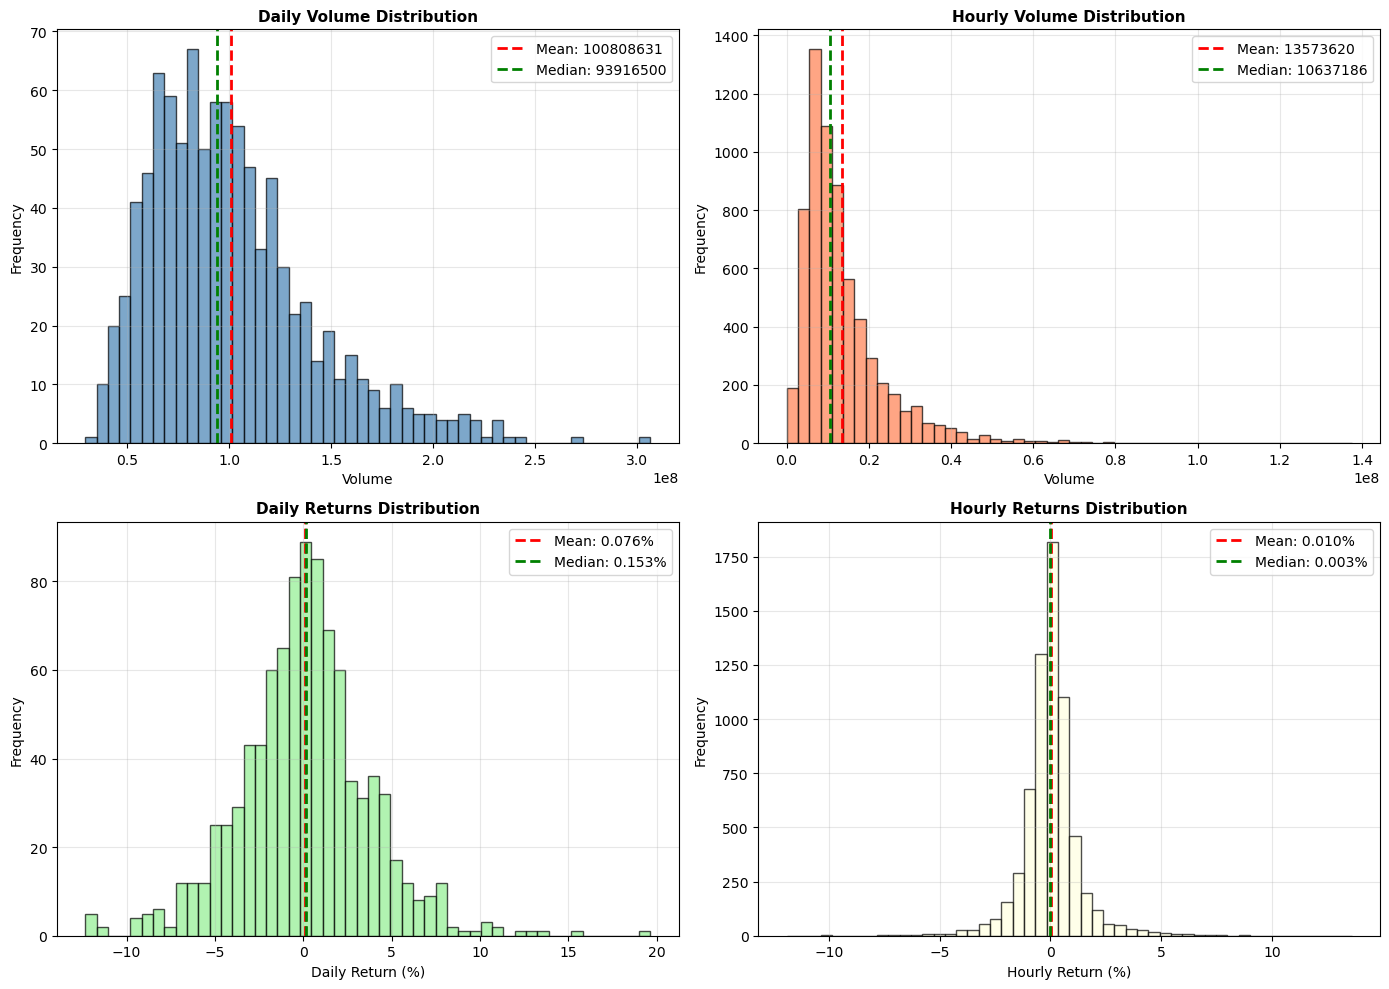

Saved: outputs/eda_distributions.png


In [13]:
# Volume Distribution & Returns Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Daily volume histogram
axes[0, 0].hist(reload_daily['Volume'].dropna(), bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(reload_daily['Volume'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {reload_daily['Volume'].mean():.0f}")
axes[0, 0].axvline(reload_daily['Volume'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {reload_daily['Volume'].median():.0f}")
axes[0, 0].set_xlabel('Volume', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].set_title('Daily Volume Distribution', fontsize=11, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Hourly volume histogram
axes[0, 1].hist(reload_hourly['Volume'].dropna(), bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(reload_hourly['Volume'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {reload_hourly['Volume'].mean():.0f}")
axes[0, 1].axvline(reload_hourly['Volume'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {reload_hourly['Volume'].median():.0f}")
axes[0, 1].set_xlabel('Volume', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].set_title('Hourly Volume Distribution', fontsize=11, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Daily returns distribution
daily_returns = reload_daily['Close'].pct_change() * 100
axes[1, 0].hist(daily_returns.dropna(), bins=50, color='lightgreen', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(daily_returns.mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {daily_returns.mean():.3f}%")
axes[1, 0].axvline(daily_returns.median(), color='green', linestyle='--', linewidth=2, label=f"Median: {daily_returns.median():.3f}%")
axes[1, 0].set_xlabel('Daily Return (%)', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].set_title('Daily Returns Distribution', fontsize=11, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Hourly returns distribution
hourly_returns = reload_hourly['Close'].pct_change() * 100
axes[1, 1].hist(hourly_returns.dropna(), bins=50, color='lightyellow', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(hourly_returns.mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {hourly_returns.mean():.3f}%")
axes[1, 1].axvline(hourly_returns.median(), color='green', linestyle='--', linewidth=2, label=f"Median: {hourly_returns.median():.3f}%")
axes[1, 1].set_xlabel('Hourly Return (%)', fontsize=10)
axes[1, 1].set_ylabel('Frequency', fontsize=10)
axes[1, 1].set_title('Hourly Returns Distribution', fontsize=11, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/eda_distributions.png")


MIDAS DATA SANITY CHECK

1. MISSING VALUES (NaN) CHECK:
----------------------------------------------------------------------
  ✓ Cancel_to_Trade               :    0 NaN (  0.00%)
  ✓ Hidden_Rate                   :    0 NaN (  0.00%)
  ✓ Hidden_Volume                 :    0 NaN (  0.00%)
  ✓ Trade_to_Order_Volume         :    0 NaN (  0.00%)
  ✓ Oddlot_Rate                   :    0 NaN (  0.00%)
  ✓ Oddlot_Volume                 :    0 NaN (  0.00%)

  Total NaN: 0.00% of all data points

2. DATE ALIGNMENT CHECK (MIDAS vs Price Data):
----------------------------------------------------------------------
  MIDAS rows        : 941
  Daily trading days: 941
  Hourly trading days: 941
  MIDAS date range  : 2021-01-04 to 2024-09-30
  Daily date range  : 2021-01-04 to 2024-09-30

  Days in DAILY but NOT in MIDAS: 0
  Days in MIDAS but NOT in DAILY: 0
  Alignment: 100.0% of daily dates have MIDAS data

3. SUMMARY STATISTICS:
---------------------------------------------------------------

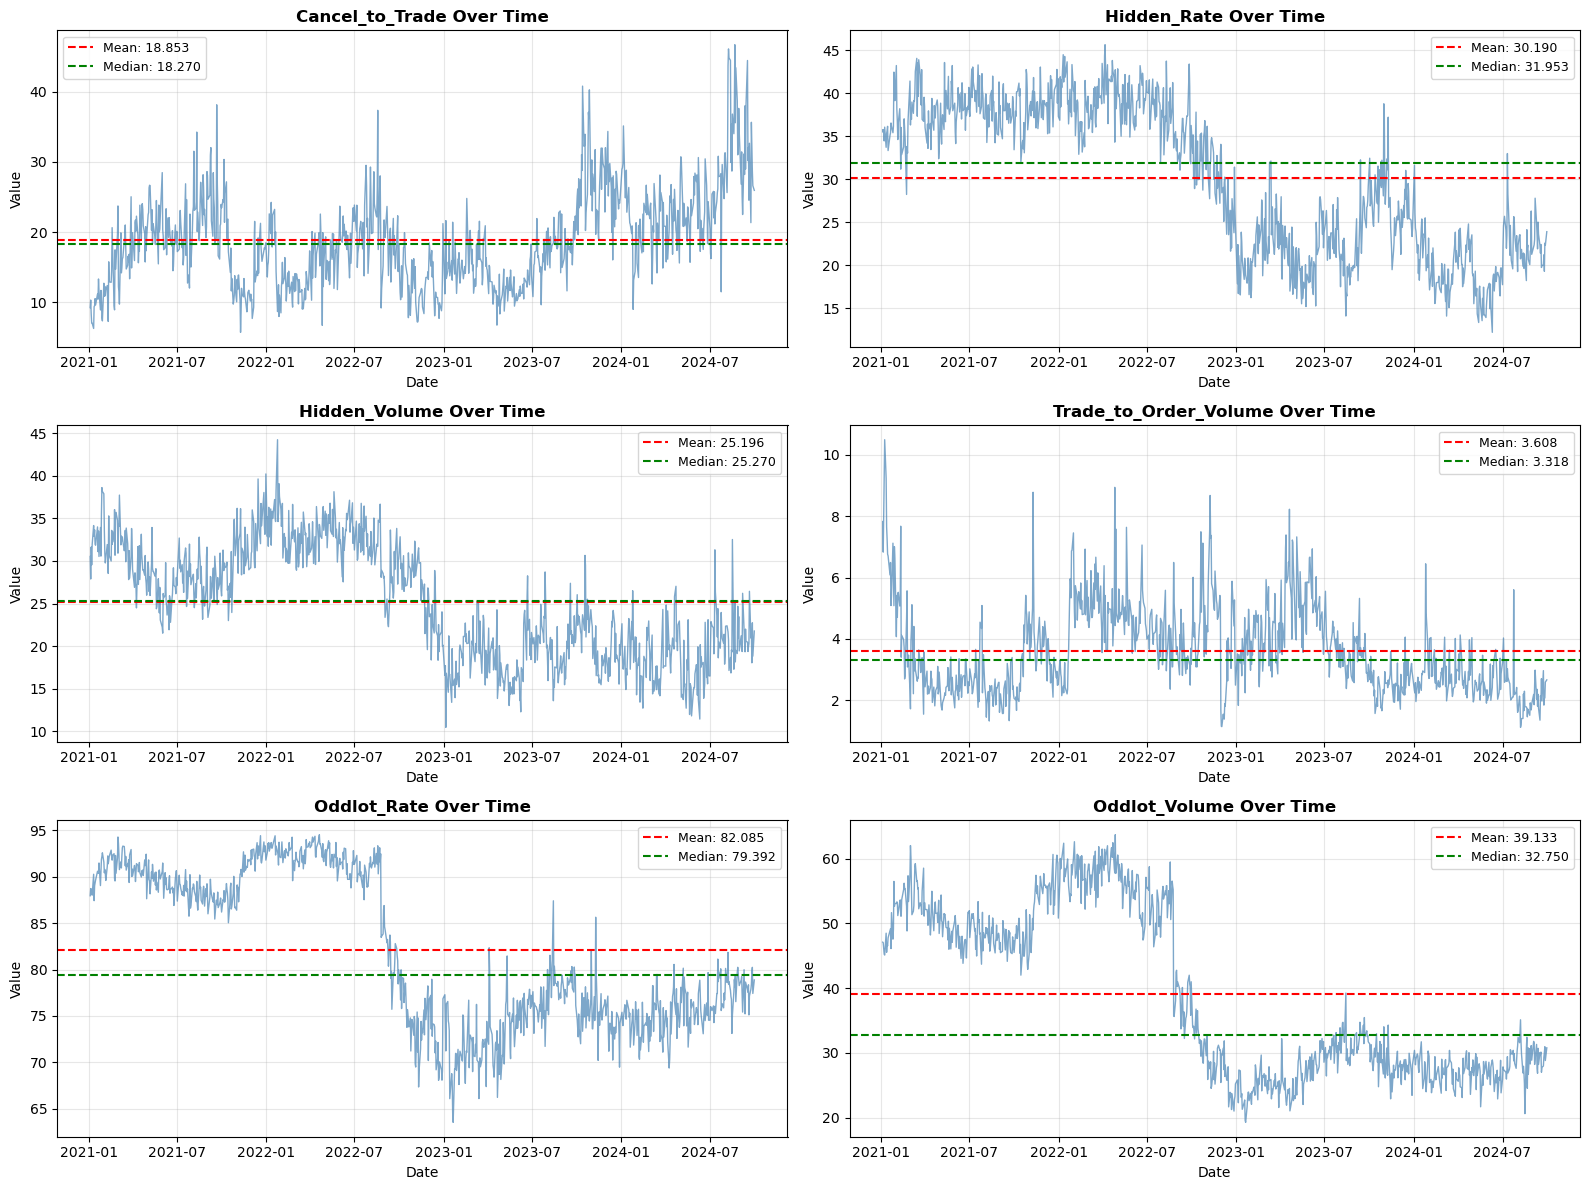


  ✓ Saved: outputs/midas_sanity_check_timeseries.png


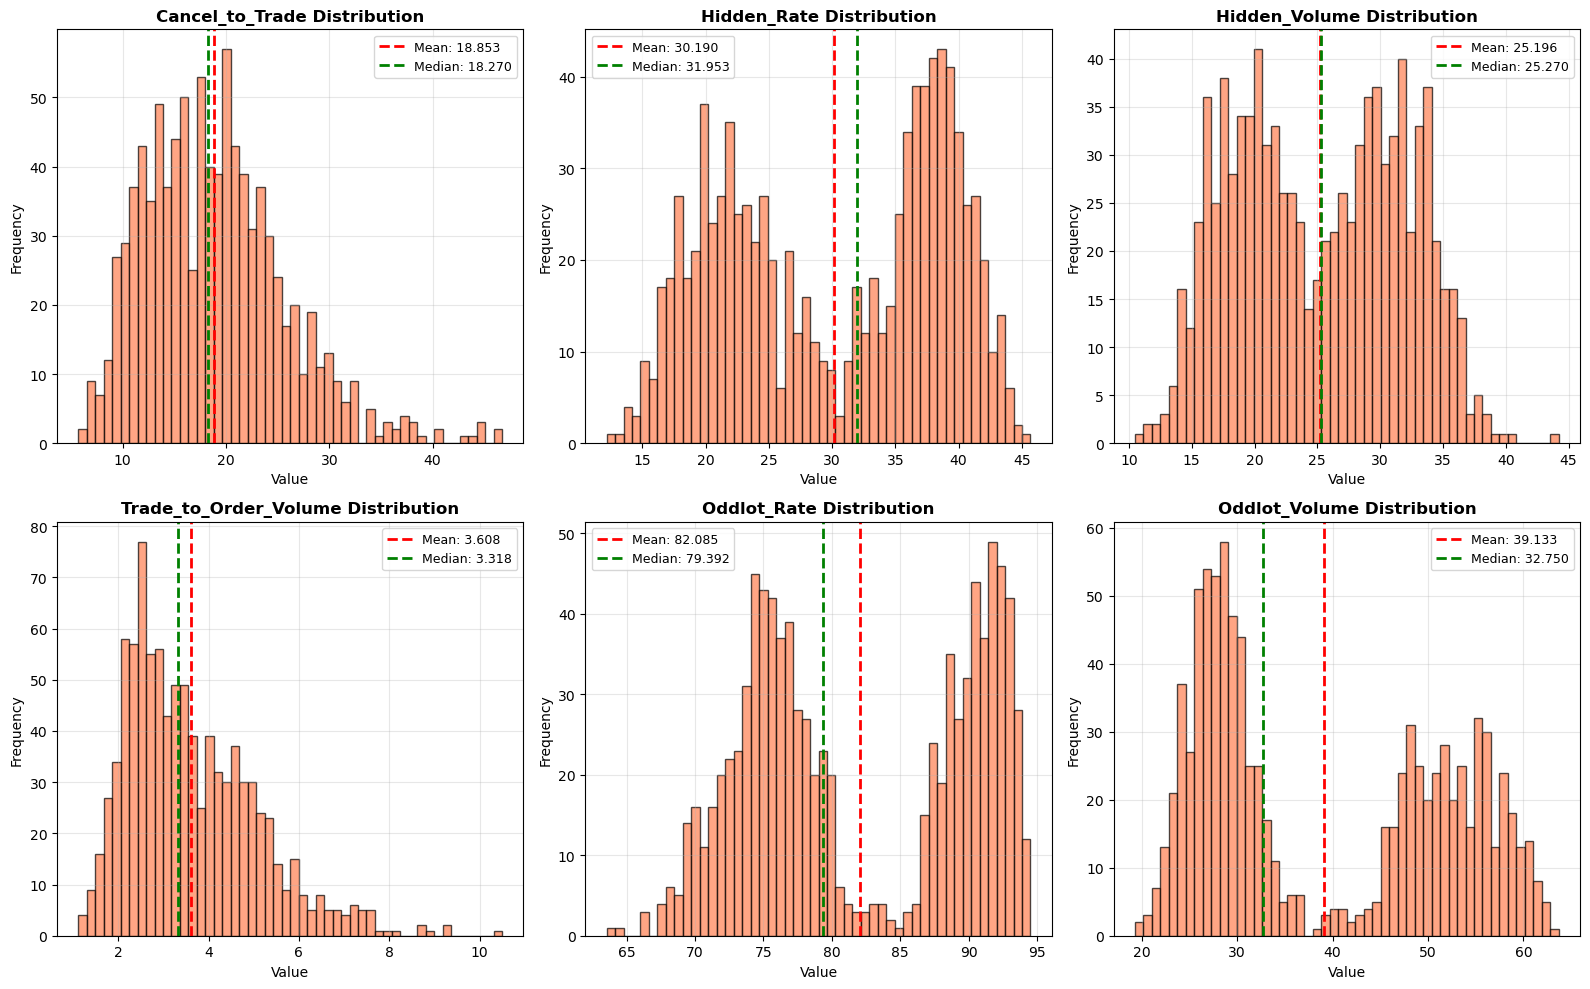

  ✓ Saved: outputs/midas_sanity_check_distributions.png


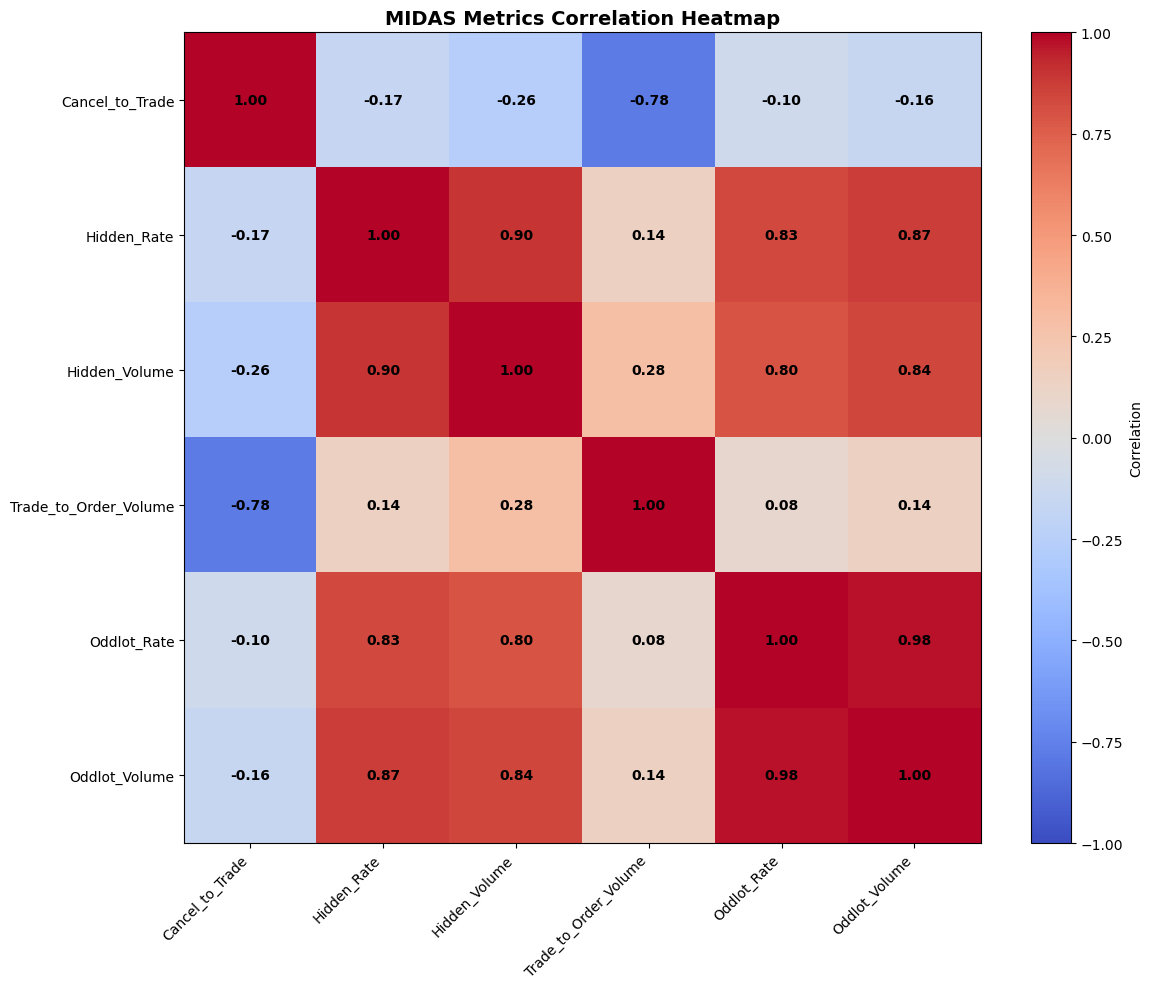

  ✓ Saved: outputs/midas_sanity_check_correlation.png

MIDAS SANITY CHECK SUMMARY

✓ MIDAS data validation complete!
  - 941 rows loaded
  - 6 metrics available
  - Date alignment: 100.0% with daily data
  - Average NaN percentage: 0.00%
  - Ready for zone enrichment and filtering (Layer 3)


In [14]:
# ---------------------------------------------------------------------------
# MIDAS Data Sanity Check
# ---------------------------------------------------------------------------
# Comprehensive validation of MIDAS data for alignment, completeness, and quality

if midas_df is not None and not midas_df.empty and USE_MIDAS:
    print("\n" + "="*70)
    print("MIDAS DATA SANITY CHECK")
    print("="*70)
    
    # ─────────────────────────────────────────────────────────────────────
    # 1. MISSING/NAN VALUES CHECK
    # ─────────────────────────────────────────────────────────────────────
    print("\n1. MISSING VALUES (NaN) CHECK:")
    print("-" * 70)
    
    nan_counts = midas_df.isnull().sum()
    nan_pct = (nan_counts / len(midas_df)) * 100
    
    for col in midas_df.columns:
        nan_cnt = nan_counts[col]
        nan_p = nan_pct[col]
        status = "✓" if nan_p == 0 else "⚠" if nan_p < 20 else "✗"
        print(f"  {status} {col:30s}: {nan_cnt:4d} NaN ({nan_p:6.2f}%)")
    
    total_nan_pct = (midas_df.isnull().sum().sum() / (len(midas_df) * len(midas_df.columns))) * 100
    print(f"\n  Total NaN: {total_nan_pct:.2f}% of all data points")
    
    # ─────────────────────────────────────────────────────────────────────
    # 2. DATE ALIGNMENT CHECK (MIDAS vs Price Data)
    # ─────────────────────────────────────────────────────────────────────
    print("\n2. DATE ALIGNMENT CHECK (MIDAS vs Price Data):")
    print("-" * 70)
    
    midas_dates = set(midas_df.index.date)
    daily_dates = set(reload_daily.index.date)
    hourly_dates = set(reload_hourly.index.date)
    
    dates_in_daily_not_midas = daily_dates - midas_dates
    dates_in_midas_not_daily = midas_dates - daily_dates
    dates_in_hourly_not_midas = hourly_dates - midas_dates
    
    print(f"  MIDAS rows        : {len(midas_df)}")
    print(f"  Daily trading days: {len(daily_dates)}")
    print(f"  Hourly trading days: {len(hourly_dates)}")
    print(f"  MIDAS date range  : {midas_df.index.min().date()} to {midas_df.index.max().date()}")
    print(f"  Daily date range  : {reload_daily.index.min().date()} to {reload_daily.index.max().date()}")
    
    print(f"\n  Days in DAILY but NOT in MIDAS: {len(dates_in_daily_not_midas)}")
    if len(dates_in_daily_not_midas) > 0 and len(dates_in_daily_not_midas) <= 10:
        print(f"    → {sorted(dates_in_daily_not_midas)[:5]}" + ("..." if len(dates_in_daily_not_midas) > 5 else ""))
    
    print(f"  Days in MIDAS but NOT in DAILY: {len(dates_in_midas_not_daily)}")
    if len(dates_in_midas_not_daily) > 0 and len(dates_in_midas_not_daily) <= 10:
        print(f"    → {sorted(dates_in_midas_not_daily)[:5]}" + ("..." if len(dates_in_midas_not_daily) > 5 else ""))
    
    alignment_pct = (len(midas_dates & daily_dates) / len(daily_dates)) * 100 if daily_dates else 0
    print(f"  Alignment: {alignment_pct:.1f}% of daily dates have MIDAS data")
    
    # ─────────────────────────────────────────────────────────────────────
    # 3. SUMMARY STATISTICS (count, mean, median, min, max, std)
    # ─────────────────────────────────────────────────────────────────────
    print("\n3. SUMMARY STATISTICS:")
    print("-" * 70)
    
    stats_df = midas_df.describe().round(4)
    print(stats_df.to_string())
    
    # ─────────────────────────────────────────────────────────────────────
    # 4. PERCENTILE RANKS & OUTLIERS CHECK
    # ─────────────────────────────────────────────────────────────────────
    print("\n4. PERCENTILE DISTRIBUTION & OUTLIERS:")
    print("-" * 70)
    
    for col in midas_df.columns:
        col_data = midas_df[col].dropna()
        if len(col_data) == 0:
            continue
        
        q1 = col_data.quantile(0.25)
        q2 = col_data.quantile(0.50)  # median
        q3 = col_data.quantile(0.75)
        iqr = q3 - q1
        lower_fence = q1 - 1.5 * iqr
        upper_fence = q3 + 1.5 * iqr
        
        outliers_low = (col_data < lower_fence).sum()
        outliers_high = (col_data > upper_fence).sum()
        total_outliers = outliers_low + outliers_high
        outlier_pct = (total_outliers / len(col_data)) * 100
        
        print(f"\n  {col}:")
        print(f"    Percentiles: Q1={q1:.4f}, Q2(Median)={q2:.4f}, Q3={q3:.4f}")
        print(f"    IQR={iqr:.4f}, Outlier Fences: [{lower_fence:.4f}, {upper_fence:.4f}]")
        print(f"    Outliers: {total_outliers} ({outlier_pct:.2f}%) [Low: {outliers_low}, High: {outliers_high}]")
    
    # ─────────────────────────────────────────────────────────────────────
    # 5. CORRELATION MATRIX (Relationship between MIDAS metrics)
    # ─────────────────────────────────────────────────────────────────────
    print("\n5. CORRELATION BETWEEN MIDAS METRICS:")
    print("-" * 70)
    
    corr_matrix = midas_df.corr().round(3)
    print(corr_matrix.to_string())
    
    # ─────────────────────────────────────────────────────────────────────
    # 6. VISUALIZATIONS
    # ─────────────────────────────────────────────────────────────────────
    import matplotlib.pyplot as plt
    
    # Create a comprehensive figure with multiple subplots
    fig = plt.figure(figsize=(16, 12))
    
    # 6a. Time series of each MIDAS metric
    for idx, col in enumerate(midas_df.columns):
        ax = plt.subplot(3, 2, idx + 1)
        ax.plot(midas_df.index, midas_df[col], linewidth=1, color='steelblue', alpha=0.7)
        ax.set_title(f'{col} Over Time', fontweight='bold')
        ax.set_xlabel('Date')
        ax.set_ylabel('Value')
        ax.grid(alpha=0.3)
        
        # Add mean and median lines
        mean_val = midas_df[col].mean()
        median_val = midas_df[col].median()
        ax.axhline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.3f}')
        ax.axhline(median_val, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.3f}')
        ax.legend(fontsize=9)
    
    plt.tight_layout()
    plt.savefig('outputs/midas_sanity_check_timeseries.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n  ✓ Saved: outputs/midas_sanity_check_timeseries.png")
    
    # 6b. Distribution histograms
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    for idx, col in enumerate(midas_df.columns):
        ax = axes[idx]
        col_data = midas_df[col].dropna()
        ax.hist(col_data, bins=50, color='coral', alpha=0.7, edgecolor='black')
        ax.axvline(col_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {col_data.mean():.3f}')
        ax.axvline(col_data.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {col_data.median():.3f}')
        ax.set_title(f'{col} Distribution', fontweight='bold')
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
    
    # Remove extra subplot
    if len(midas_df.columns) < 6:
        fig.delaxes(axes[-1])
    
    plt.tight_layout()
    plt.savefig('outputs/midas_sanity_check_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✓ Saved: outputs/midas_sanity_check_distributions.png")
    
    # 6c. Heatmap of correlation matrix
    import matplotlib.patches as mpatches
    
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
    
    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_yticks(range(len(corr_matrix.columns)))
    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
    ax.set_yticklabels(corr_matrix.columns)
    
    # Add correlation values in cells
    for i in range(len(corr_matrix)):
        for j in range(len(corr_matrix)):
            text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=10, fontweight='bold')
    
    ax.set_title('MIDAS Metrics Correlation Heatmap', fontweight='bold', fontsize=14)
    plt.colorbar(im, ax=ax, label='Correlation')
    plt.tight_layout()
    plt.savefig('outputs/midas_sanity_check_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✓ Saved: outputs/midas_sanity_check_correlation.png")
    
    # ─────────────────────────────────────────────────────────────────────
    # SUMMARY
    # ─────────────────────────────────────────────────────────────────────
    print("\n" + "="*70)
    print("MIDAS SANITY CHECK SUMMARY")
    print("="*70)
    
    print(f"\n✓ MIDAS data validation complete!")
    print(f"  - {len(midas_df)} rows loaded")
    print(f"  - {len(midas_df.columns)} metrics available")
    print(f"  - Date alignment: {alignment_pct:.1f}% with daily data")
    print(f"  - Average NaN percentage: {total_nan_pct:.2f}%")
    print(f"  - Ready for zone enrichment and filtering (Layer 3)")
    
else:
    print("\n⚠ MIDAS data not available for sanity check (midas_df is None or empty)")

In [15]:
midas_df.head()

,Cancel_to_Trade,Hidden_Rate,Hidden_Volume,Trade_to_Order_Volume,Oddlot_Rate,Oddlot_Volume
date,,,,,,
2021-01-04,9.230069,35.772576,30.521597,7.828468,87.947450,47.103830
2021-01-05,10.303195,35.458893,27.879749,6.831907,88.720227,47.017219
2021-01-06,8.304282,35.778200,31.633233,8.004737,88.665709,46.150634
2021-01-07,7.020428,34.469931,29.535346,9.314816,88.091067,45.249066
2021-01-08,7.009115,36.076460,31.920673,10.498168,88.009125,45.116434


### 2b — Data Transformation

In [16]:
# ---------------------------------------------------------------------------
# Volume Data Normalization: Conditional log1p + Z-Score Standardization
# ---------------------------------------------------------------------------

def normalize_volume_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Normalize raw volume data: apply log1p if skewness > 0.5, then z-score.
    
    Rationale for conditional log1p:
    - High skew indicates extreme outliers (institutional activity signals)
    - Log transformation compresses skew while preserving relative magnitude
    - Subsequent z-score creates regime-independent threshold (e.g., vol_spike >= 1.5)
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with 'Volume' or 'volume' column
    
    Returns:
    --------
    pd.DataFrame
        Copy of df with normalized volume columns added:
        - volume_skewness: Raw volume skewness (diagnostic)
        - volume_log_applied: Boolean indicating if log1p was used
        - volume_zscore: Z-score normalized volume (μ=0, σ=1)
    """
    df_norm = df.copy()
    
    # Identify volume column
    vol_col = "Volume" if "Volume" in df.columns else ("volume" if "volume" in df.columns else None)
    if vol_col is None:
        print("[Warning] normalize_volume_data: no volume column found")
        return df_norm
    
    # Step 1: Calculate skewness on raw volume
    skewness = df_norm[vol_col].skew()
    df_norm['volume_skewness'] = skewness
    
    # Step 2: Apply log1p if skewness > 0.5
    apply_log = skewness > 0.5
    df_norm['volume_log_applied'] = apply_log
    
    if apply_log:
        volume_transformed = np.log1p(df_norm[vol_col])
        print(f"[Volume] High skewness detected ({skewness:.4f}) → applying log1p transformation")
    else:
        volume_transformed = df_norm[vol_col]
        print(f"[Volume] Skewness acceptable ({skewness:.4f}) → using raw values")
    
    # Step 3: Rolling Z-score normalization on transformed volume
    # Using 20-bar rolling window for regime-adaptive normalization
    # min_periods=1 ensures no NaN values (bootstrap from first bar onwards)
    vol_roll_mean = volume_transformed.rolling(window=VOL_ROLL_WINDOW, min_periods=1).mean()
    vol_roll_std = volume_transformed.rolling(window=VOL_ROLL_WINDOW, min_periods=1).std().clip(lower=0.01)
    
    if vol_roll_std.max() > 0:
        df_norm['volume_zscore'] = (volume_transformed - vol_roll_mean) / vol_roll_std
    else:
        df_norm['volume_zscore'] = 0.0

    return df_norm

In [17]:
# APPLY VOLUME NORMALIZATION — Create volume_zscore column 

print("\n" + "="*75)
print("STEP 1: APPLYING VOLUME NORMALIZATION (normalize_volume_data)")
print("="*75)
print("Creating volume_zscore column required by all downstream analysis...")
print()

reload_daily  = normalize_volume_data(reload_daily)
reload_hourly = normalize_volume_data(reload_hourly)

print("\n✓ Volume normalization complete:")
print(f"  - Daily data: {len(reload_daily)} bars, volume_zscore shape={reload_daily['volume_zscore'].shape}")
print(f"  - Hourly data: {len(reload_hourly)} bars, volume_zscore shape={reload_hourly['volume_zscore'].shape}")
print(f"  - Both DataFrames now have volume_skewness, volume_log_applied, volume_zscore columns")


STEP 1: APPLYING VOLUME NORMALIZATION (normalize_volume_data)
Creating volume_zscore column required by all downstream analysis...

[Volume] High skewness detected (1.1089) → applying log1p transformation
[Volume] High skewness detected (2.8453) → applying log1p transformation

✓ Volume normalization complete:
  - Daily data: 941 bars, volume_zscore shape=(941,)
  - Hourly data: 6577 bars, volume_zscore shape=(6577,)
  - Both DataFrames now have volume_skewness, volume_log_applied, volume_zscore columns


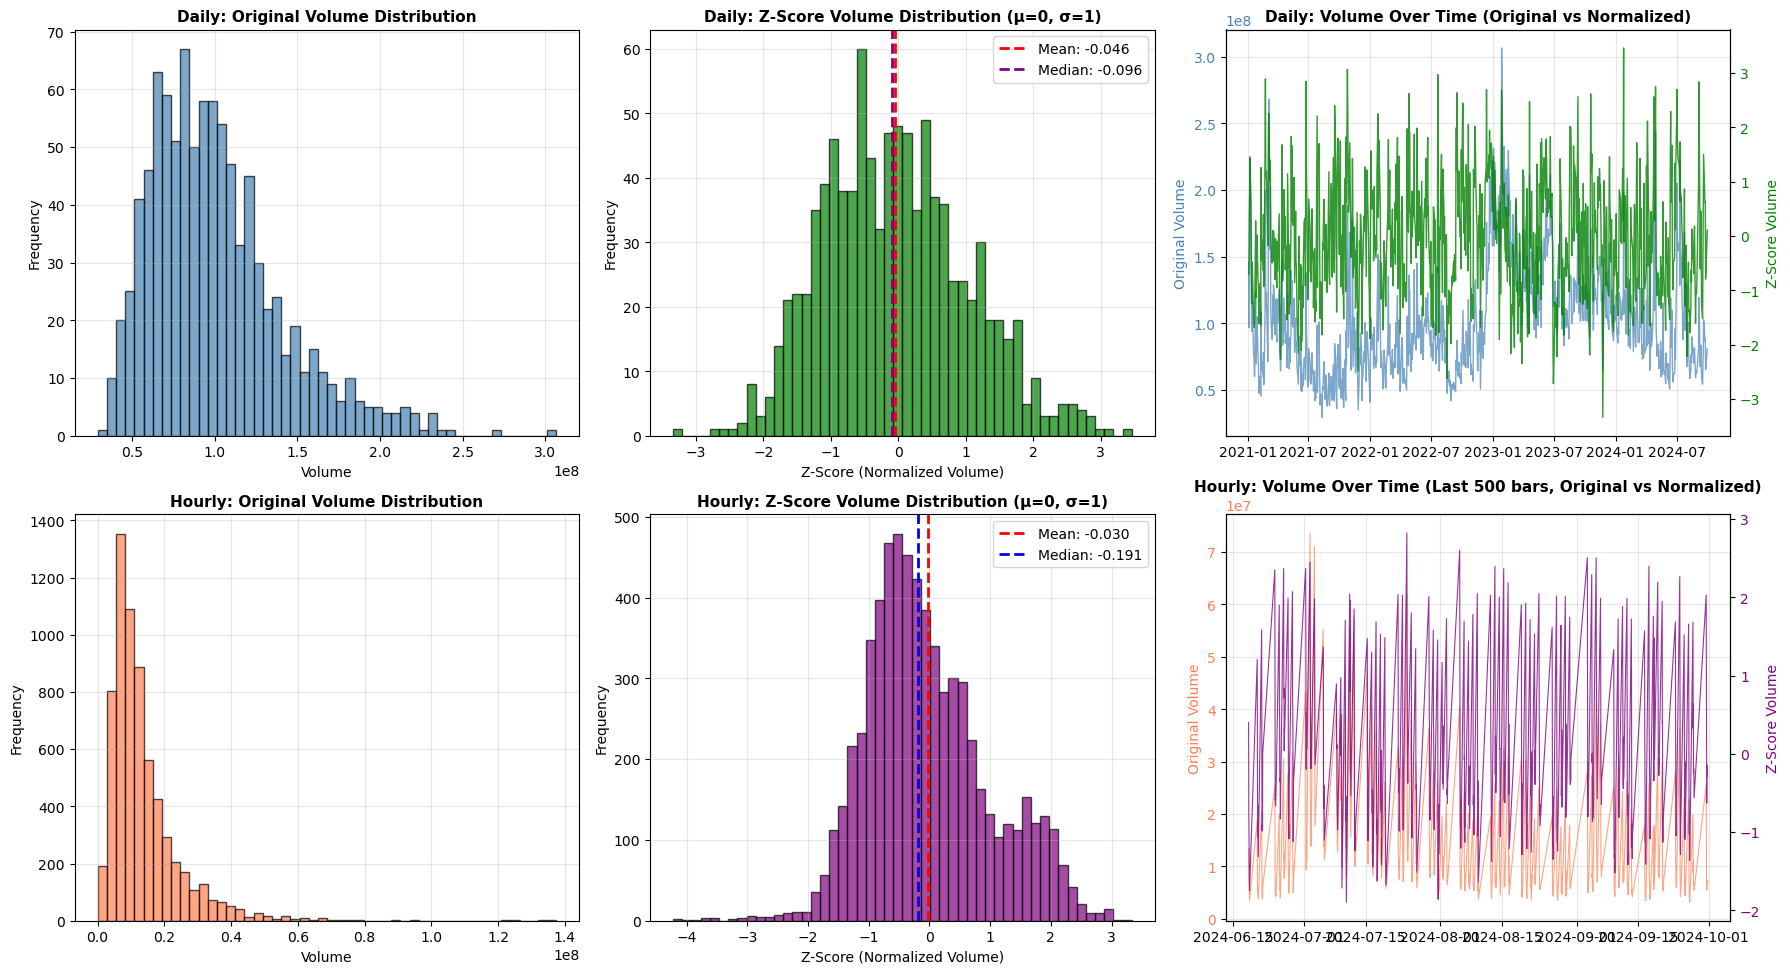


✓ Volume normalization visualizations displayed


In [18]:
# ---------------------------------------------------------------------------
# Volume Normalization Visualizations
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ─────────────────────────────────────────────────────────────────────────
# Row 1: Daily (HTF) Volume Analysis
# ─────────────────────────────────────────────────────────────────────────

# Original Volume Distribution
axes[0, 0].hist(reload_daily['Volume'].dropna(), bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Volume', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].set_title('Daily: Original Volume Distribution', fontsize=11, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Z-Score Volume Distribution (centered at 0)
axes[0, 1].hist(reload_daily['volume_zscore'].dropna(), bins=50, color='green', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(reload_daily['volume_zscore'].mean(), color='red', linestyle='--', linewidth=2, 
                   label=f"Mean: {reload_daily['volume_zscore'].mean():.3f}")
axes[0, 1].axvline(reload_daily['volume_zscore'].median(), color='purple', linestyle='--', linewidth=2,
                   label=f"Median: {reload_daily['volume_zscore'].median():.3f}")
axes[0, 1].set_xlabel('Z-Score (Normalized Volume)', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].set_title('Daily: Z-Score Volume Distribution (μ=0, σ=1)', fontsize=11, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Time Series: Original vs Normalized Volume
axes[0, 2].plot(reload_daily.index, reload_daily['Volume'], color='steelblue', linewidth=1, 
                label='Original', alpha=0.7)
ax_norm = axes[0, 2].twinx()
ax_norm.plot(reload_daily.index, reload_daily['volume_zscore'], color='green', linewidth=1, 
             label='Z-Score', alpha=0.8)
axes[0, 2].set_ylabel('Original Volume', fontsize=10, color='steelblue')
ax_norm.set_ylabel('Z-Score Volume', fontsize=10, color='green')
axes[0, 2].set_title('Daily: Volume Over Time (Original vs Normalized)', fontsize=11, fontweight='bold')
axes[0, 2].tick_params(axis='y', labelcolor='steelblue')
ax_norm.tick_params(axis='y', labelcolor='green')
axes[0, 2].grid(alpha=0.3)

# ─────────────────────────────────────────────────────────────────────────
# Row 2: Hourly (LTF) Volume Analysis
# ─────────────────────────────────────────────────────────────────────────

# Original Volume Distribution (Hourly)
axes[1, 0].hist(reload_hourly['Volume'].dropna(), bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Volume', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].set_title('Hourly: Original Volume Distribution', fontsize=11, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Z-Score Volume Distribution (Hourly)
axes[1, 1].hist(reload_hourly['volume_zscore'].dropna(), bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(reload_hourly['volume_zscore'].mean(), color='red', linestyle='--', linewidth=2,
                   label=f"Mean: {reload_hourly['volume_zscore'].mean():.3f}")
axes[1, 1].axvline(reload_hourly['volume_zscore'].median(), color='blue', linestyle='--', linewidth=2,
                   label=f"Median: {reload_hourly['volume_zscore'].median():.3f}")
axes[1, 1].set_xlabel('Z-Score (Normalized Volume)', fontsize=10)
axes[1, 1].set_ylabel('Frequency', fontsize=10)
axes[1, 1].set_title('Hourly: Z-Score Volume Distribution (μ=0, σ=1)', fontsize=11, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# Time Series: Hourly Volume (Last 500 bars for clarity)
hourly_tail = reload_hourly.tail(500)
axes[1, 2].plot(hourly_tail.index, hourly_tail['Volume'], color='coral', linewidth=0.8, 
                label='Original', alpha=0.7)
ax_norm2 = axes[1, 2].twinx()
ax_norm2.plot(hourly_tail.index, hourly_tail['volume_zscore'], color='purple', linewidth=0.8,
              label='Z-Score', alpha=0.8)
axes[1, 2].set_ylabel('Original Volume', fontsize=10, color='coral')
ax_norm2.set_ylabel('Z-Score Volume', fontsize=10, color='purple')
axes[1, 2].set_title('Hourly: Volume Over Time (Last 500 bars, Original vs Normalized)', fontsize=11, fontweight='bold')
axes[1, 2].tick_params(axis='y', labelcolor='coral')
ax_norm2.tick_params(axis='y', labelcolor='purple')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("\n✓ Volume normalization visualizations displayed")

In [19]:
'''def preprocess_midas_data(midas_df: pd.DataFrame, rolling_window: int = 20) -> pd.DataFrame:
    """
    Apply comprehensive preprocessing to MIDAS data:
    
    1. Conditional log1p Transformation: Applied if skewness > 0.5
    2. Z-score Normalization: Center at 0, scale by std dev
    3. Rolling Features: 20-bar rolling mean and median
    4. Slopes: Rate of change over 3 and 5 bars (diff and pct_change)
    5. Percentiles: Rolling 20-bar quantile ranking
    6. Cross-Feature Ratios: Hidden_Rate / Oddlot_Rate
    
    Parameters:
    -----------
    midas_df : pd.DataFrame
        MIDAS data with columns: Cancel_to_Trade, Hidden_Rate, Hidden_Volume,
        Trade_to_Order_Volume, Oddlot_Rate, Oddlot_Volume
    rolling_window : int
        Window size for rolling/smoothed features (default 20 to match HTF)
    
    Returns:
    --------
    pd.DataFrame
        Preprocessed MIDAS data with all features appended
    """
    if midas_df is None or midas_df.empty:
        print("⚠ MIDAS data is None or empty — skipping preprocessing")
        return midas_df
    
    midas_proc = midas_df.copy()
    
    # Define MIDAS feature columns
    midas_cols = ["Cancel_to_Trade", "Hidden_Rate", "Hidden_Volume",
                  "Trade_to_Order_Volume", "Oddlot_Rate", "Oddlot_Volume"]
    
    # Ensure all columns are present
    for col in midas_cols:
        if col not in midas_proc.columns:
            print(f"⚠ Warning: {col} not found in MIDAS data")
            midas_proc[col] = np.nan
    
    print("\n" + "="*70)
    print("MIDAS DATA PREPROCESSING")
    print("="*70)
    
    # =====================================================================
    # Step 1: Conditional log1p Transformation (if skewness > 0.5)
    # =====================================================================
    print("\n[Step 1] Conditional log1p Transformation")
    print("  Decision: Apply log1p if raw skewness > 0.5")
    print("  Rationale: Log transformation reduces impact of extreme values")
    print("             while preserving relative magnitude and sign")
    
    log_applied = {}
    for col in midas_cols:
        if col in midas_proc.columns and midas_proc[col].notna().sum() > 0:
            skewness = midas_proc[col].skew()
            
            if skewness > 0.5:
                midas_proc[col] = np.log1p(midas_proc[col])
                log_applied[col] = True
                print(f"  ✓ {col:30s}: Applied log1p (skewness {skewness:.4f})")
            else:
                log_applied[col] = False
                print(f"  - {col:30s}: Raw values (skewness {skewness:.4f})")
    
    # =====================================================================
    # Step 2: Rolling Z-score Normalization (regime-adaptive, μ≈0, σ≈1)
    # =====================================================================
    print(f"\n[Step 2] Rolling Z-score Normalization (window={rolling_window}, min_periods=1)")
    print("  Regime-adaptive: mean/std computed within rolling window for each bar")
    print("  Applied per column independently for cross-feature consistency")
    
    for col in midas_cols:
        if col in midas_proc.columns and midas_proc[col].notna().sum() > 1:
            # Compute rolling statistics per column independently
            rolling_mean = midas_proc[col].rolling(window=rolling_window, min_periods=1).mean()
            rolling_std = midas_proc[col].rolling(window=rolling_window, min_periods=1).std().clip(lower=0.01)
            
            midas_proc[f"{col}_zscore"] = (midas_proc[col] - rolling_mean) / rolling_std
            
            # Verify output statistics
            zscore_col = midas_proc[f"{col}_zscore"]
            new_mean = zscore_col.mean()
            new_std = zscore_col.std()
            transform_note = " [log1p applied]" if log_applied.get(col, False) else ""
            print(f"  ✓ {col:30s}: μ={new_mean:.4f}, σ={new_std:.4f} (rolling window={rolling_window}){transform_note}")
    
    # =====================================================================
    # Step 3: Rolling Mean & Median (smoothed features)
    # =====================================================================
    print(f"\n[Step 3] Rolling Mean & Median (window={rolling_window})")
    
    for col in midas_cols:
        if col in midas_proc.columns:
            midas_proc[f"{col}_roll_mean"] = midas_proc[col].rolling(window=rolling_window, min_periods=1).mean()
            midas_proc[f"{col}_roll_median"] = midas_proc[col].rolling(window=rolling_window, min_periods=1).median()
    
    print(f"  Added rolling mean and median for all {len(midas_cols)} features")
    
    # =====================================================================
    # Step 4: Slopes (rate of change: difference and percent change)
    # =====================================================================
    print(f"\n[Step 4] Slopes (3-bar and 5-bar changes)")
    
    for col in midas_cols:
        if col in midas_proc.columns:
            midas_proc[f"{col}_slope_3b_diff"] = midas_proc[col].diff(periods=3)
            midas_proc[f"{col}_slope_3b_pct"] = midas_proc[col].pct_change(periods=3)
            midas_proc[f"{col}_slope_5b_diff"] = midas_proc[col].diff(periods=5)
            midas_proc[f"{col}_slope_5b_pct"] = midas_proc[col].pct_change(periods=5)
    
    print(f"  Added 3-bar and 5-bar slopes (diff & pct_change) for all features")
    
    # =====================================================================
    # Step 5: Rolling Percentiles (rank within window)
    # =====================================================================
    print(f"\n[Step 5] Rolling Percentiles (window={rolling_window})")
    
    for col in midas_cols:
        if col in midas_proc.columns:
            # Compute percentile rank within rolling window
            midas_proc[f"{col}_rank_pct"] = midas_proc[col].rolling(window=rolling_window, min_periods=1).apply(
                lambda x: pd.Series(x).rank(pct=True).iloc[-1] if x.notna().sum() > 0 else np.nan,
                raw=False
            )
    
    print(f"  Added rolling percentile rank for all {len(midas_cols)} features")
    
    # =====================================================================
    # Step 6: Cross-Feature Ratios (institutional behavior proxies)
    # =====================================================================
    print(f"\n[Step 6] Cross-Feature Ratios")
    
    # Hidden_Rate / Oddlot_Rate: ratio of institutional to odd-lot activity
    if "Hidden_Rate" in midas_proc.columns and "Oddlot_Rate" in midas_proc.columns:
        midas_proc["HiddenToOddlot_Ratio"] = (midas_proc["Hidden_Rate"] + 1e-10) / (midas_proc["Oddlot_Rate"] + 1e-10)
        print("  Added: Hidden_Rate / Oddlot_Rate (institutional vs. retail signal)")
    
    # Hidden_Volume / Trade_to_Order_Volume: ratio of hidden to total orders
    if "Hidden_Volume" in midas_proc.columns and "Trade_to_Order_Volume" in midas_proc.columns:
        total_orders = midas_proc["Hidden_Volume"] + midas_proc["Trade_to_Order_Volume"]
        midas_proc["HiddenShare_Ratio"] = (midas_proc["Hidden_Volume"] + 1e-10) / (total_orders + 1e-10)
        print("  Added: Hidden_Volume / (Hidden + Trade_to_Order) (hidden order share)")
    
    print("\n" + "="*70)
    print(f"MIDAS preprocessing complete: {midas_proc.shape[0]} rows × {midas_proc.shape[1]} columns")
    print(f"Original columns: {len(midas_cols)} | New features added: {midas_proc.shape[1] - len(midas_cols)}")
    print("="*70 + "\n")

    return midas_proc'''

'def preprocess_midas_data(midas_df: pd.DataFrame, rolling_window: int = 20) -> pd.DataFrame:\n    """\n    Apply comprehensive preprocessing to MIDAS data:\n\n    1. Conditional log1p Transformation: Applied if skewness > 0.5\n    2. Z-score Normalization: Center at 0, scale by std dev\n    3. Rolling Features: 20-bar rolling mean and median\n    4. Slopes: Rate of change over 3 and 5 bars (diff and pct_change)\n    5. Percentiles: Rolling 20-bar quantile ranking\n    6. Cross-Feature Ratios: Hidden_Rate / Oddlot_Rate\n\n    Parameters:\n    -----------\n    midas_df : pd.DataFrame\n        MIDAS data with columns: Cancel_to_Trade, Hidden_Rate, Hidden_Volume,\n        Trade_to_Order_Volume, Oddlot_Rate, Oddlot_Volume\n    rolling_window : int\n        Window size for rolling/smoothed features (default 20 to match HTF)\n\n    Returns:\n    --------\n    pd.DataFrame\n        Preprocessed MIDAS data with all features appended\n    """\n    if midas_df is None or midas_df.empty:\n       

In [20]:
'''import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import QuantileTransformer
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks


# ===========================================================================
# ENHANCED MIDAS PREPROCESSING WITH BIMODAL/REGIME HANDLING
# ===========================================================================

def detect_regime_threshold(series: pd.Series, method: str = 'gmm') -> tuple:
    """
    Detect regime threshold for bimodal distributions.
    
    Returns:
    --------
    threshold : float
        Optimal split point between regimes
    is_bimodal : bool
        Whether distribution is genuinely bimodal
    """
    data = series.dropna().values.reshape(-1, 1)
    
    if len(data) < 50:
        return series.median(), False
    
    if method == 'gmm':
        # Fit 1-component and 2-component GMM, compare BIC
        gmm1 = GaussianMixture(n_components=1, random_state=42).fit(data)
        gmm2 = GaussianMixture(n_components=2, random_state=42).fit(data)
        
        # BIC difference > 10 suggests bimodality
        is_bimodal = (gmm1.bic(data) - gmm2.bic(data)) > 10
        
        if is_bimodal:
            # Threshold = midpoint between GMM means
            means = gmm2.means_.flatten()
            threshold = np.mean(means)
        else:
            threshold = series.median()
            
    elif method == 'kde':
        # Find valley between peaks using KDE
        kde = gaussian_kde(data.flatten(), bw_method='scott')
        x_grid = np.linspace(data.min(), data.max(), 500)
        density = kde(x_grid)
        
        # Find peaks
        peaks, _ = find_peaks(density, distance=50)
        is_bimodal = len(peaks) >= 2
        
        if is_bimodal:
            # Find valley between two highest peaks
            peak_heights = density[peaks]
            top_2_idx = np.argsort(peak_heights)[-2:]
            top_2_peaks = sorted(peaks[top_2_idx])
            
            valley_region = density[top_2_peaks[0]:top_2_peaks[1]]
            valley_idx = top_2_peaks[0] + np.argmin(valley_region)
            threshold = x_grid[valley_idx]
        else:
            threshold = series.median()
    
    return threshold, is_bimodal


def preprocess_midas_data(
    midas_df: pd.DataFrame, 
    rolling_window: int = 20,
    handle_bimodal: bool = True,
    regime_detection_method: str = 'gmm'
) -> pd.DataFrame:
    """
    Enhanced MIDAS preprocessing with bimodal/regime-aware transformations.
    
    Key Improvements:
    1. Detects and handles bimodal distributions via GMM/KDE
    2. Creates regime indicators for structural breaks
    3. Uses quantile transformation for bimodal variables
    4. Applies regime-aware z-scoring
    5. Addresses multicollinearity with orthogonalized features
    
    Parameters:
    -----------
    midas_df : pd.DataFrame
        Raw MIDAS data
    rolling_window : int
        Window for rolling features (default 20)
    handle_bimodal : bool
        Whether to apply bimodal-specific transformations
    regime_detection_method : str
        'gmm' or 'kde' for threshold detection
    
    Returns:
    --------
    pd.DataFrame with all original columns plus:
        - *_zscore: regime-aware z-scores
        - *_regime: binary regime indicators (for bimodal vars)
        - *_qnorm: quantile-normalized versions (for bimodal vars)
        - *_roll_mean, *_roll_median: smoothed features
        - *_slope_*: rate of change features
        - *_rank_pct: rolling percentiles
        - Cross-feature ratios
    """
    if midas_df is None or midas_df.empty:
        print("⚠ MIDAS data is None or empty — skipping preprocessing")
        return midas_df
    
    midas_proc = midas_df.copy()
    
    # Define MIDAS feature columns
    midas_cols = ["Cancel_to_Trade", "Hidden_Rate", "Hidden_Volume",
                  "Trade_to_Order_Volume", "Oddlot_Rate", "Oddlot_Volume"]
    
    # Ensure all columns present
    for col in midas_cols:
        if col not in midas_proc.columns:
            print(f"⚠ Warning: {col} not found in MIDAS data")
            midas_proc[col] = np.nan
    
    print("\n" + "="*70)
    print("ENHANCED MIDAS PREPROCESSING (BIMODAL-AWARE)")
    print("="*70)
    
    # =========================================================================
    # Step 1: Detect Bimodal Variables & Structural Regimes
    # =========================================================================
    print("\n[Step 1] Bimodal/Regime Detection")
    
    bimodal_info = {}
    for col in midas_cols:
        if col in midas_proc.columns and midas_proc[col].notna().sum() > 50:
            threshold, is_bimodal = detect_regime_threshold(
                midas_proc[col], 
                method=regime_detection_method
            )
            bimodal_info[col] = {
                'is_bimodal': is_bimodal,
                'threshold': threshold,
                'skewness': midas_proc[col].skew()
            }
            
            status = "BIMODAL ✓" if is_bimodal else "Unimodal"
            print(f"  {col:25s}: {status:12s} | threshold={threshold:.2f} | skew={bimodal_info[col]['skewness']:.2f}")
    
    # =========================================================================
    # Step 2: Bimodal-Aware Transformations
    # =========================================================================
    print(f"\n[Step 2] Bimodal-Aware Transformations")
    
    log_applied = {}
    qt_transformers = {}
    
    for col in midas_cols:
        if col not in midas_proc.columns:
            continue
            
        info = bimodal_info.get(col, {'is_bimodal': False, 'skewness': 0})
        
        if handle_bimodal and info['is_bimodal']:
            # BIMODAL HANDLING: Use quantile transformation + regime indicator
            
            # 2a. Create regime indicator (binary)
            midas_proc[f"{col}_regime"] = (midas_proc[col] > info['threshold']).astype(int)
            
            # 2b. Quantile transformation to normal (handles bimodality)
            qt = QuantileTransformer(
                n_quantiles=min(len(midas_proc), 500),
                output_distribution='normal',
                random_state=42
            )
            valid_mask = midas_proc[col].notna()
            midas_proc[f"{col}_qnorm"] = np.nan
            midas_proc.loc[valid_mask, f"{col}_qnorm"] = qt.fit_transform(
                midas_proc.loc[valid_mask, col].values.reshape(-1, 1)
            ).flatten()
            qt_transformers[col] = qt
            
            # 2c. For composite scoring, use qnorm version
            midas_proc[f"{col}_transformed"] = midas_proc[f"{col}_qnorm"]
            
            log_applied[col] = False  # No log for bimodal
            print(f"  ✓ {col:25s}: Quantile→Normal + Regime indicator (bimodal)")
            
        else:
            # UNIMODAL HANDLING: Conditional log1p based on skewness
            if info['skewness'] > 0.5:
                midas_proc[f"{col}_transformed"] = np.log1p(midas_proc[col])
                log_applied[col] = True
                print(f"  ✓ {col:25s}: log1p (skewness={info['skewness']:.2f})")
            else:
                midas_proc[f"{col}_transformed"] = midas_proc[col]
                log_applied[col] = False
                print(f"  - {col:25s}: Raw values (skewness={info['skewness']:.2f})")
    
    # =========================================================================
    # Step 3: Regime-Aware Rolling Z-Score
    # =========================================================================
    print(f"\n[Step 3] Regime-Aware Rolling Z-Score (window={rolling_window})")
    
    for col in midas_cols:
        if col not in midas_proc.columns:
            continue
        
        transformed_col = f"{col}_transformed"
        info = bimodal_info.get(col, {'is_bimodal': False})
        
        if handle_bimodal and info['is_bimodal'] and f"{col}_regime" in midas_proc.columns:
            # REGIME-AWARE Z-SCORE: Compute separately within each regime
            midas_proc[f"{col}_zscore"] = np.nan
            
            for regime_val in [0, 1]:
                regime_mask = midas_proc[f"{col}_regime"] == regime_val
                regime_data = midas_proc.loc[regime_mask, transformed_col]
                
                if len(regime_data) > rolling_window:
                    rolling_mean = regime_data.rolling(window=rolling_window, min_periods=1).mean()
                    rolling_std = regime_data.rolling(window=rolling_window, min_periods=1).std().clip(lower=0.01)
                    midas_proc.loc[regime_mask, f"{col}_zscore"] = (regime_data - rolling_mean) / rolling_std
            
            zscore_col = midas_proc[f"{col}_zscore"]
            print(f"  ✓ {col:25s}: Regime-aware z-score | μ={zscore_col.mean():.3f}, σ={zscore_col.std():.3f}")
        else:
            # Standard rolling z-score
            rolling_mean = midas_proc[transformed_col].rolling(window=rolling_window, min_periods=1).mean()
            rolling_std = midas_proc[transformed_col].rolling(window=rolling_window, min_periods=1).std().clip(lower=0.01)
            midas_proc[f"{col}_zscore"] = (midas_proc[transformed_col] - rolling_mean) / rolling_std
            
            zscore_col = midas_proc[f"{col}_zscore"]
            print(f"  ✓ {col:25s}: Standard z-score | μ={zscore_col.mean():.3f}, σ={zscore_col.std():.3f}")
    
    # =========================================================================
    # Step 4: Rolling Features (Mean, Median)
    # =========================================================================
    print(f"\n[Step 4] Rolling Mean & Median (window={rolling_window})")
    
    for col in midas_cols:
        if col in midas_proc.columns:
            # Use transformed values for consistency
            src_col = f"{col}_transformed" if f"{col}_transformed" in midas_proc.columns else col
            midas_proc[f"{col}_roll_mean"] = midas_proc[src_col].rolling(window=rolling_window, min_periods=1).mean()
            midas_proc[f"{col}_roll_median"] = midas_proc[src_col].rolling(window=rolling_window, min_periods=1).median()
    
    print(f"  Added rolling mean/median for {len(midas_cols)} features")
    
    # =========================================================================
    # Step 5: Slopes (Rate of Change)
    # =========================================================================
    print(f"\n[Step 5] Slopes (3-bar and 5-bar changes)")
    
    for col in midas_cols:
        if col in midas_proc.columns:
            src_col = f"{col}_transformed" if f"{col}_transformed" in midas_proc.columns else col
            midas_proc[f"{col}_slope_3b_diff"] = midas_proc[src_col].diff(periods=3)
            midas_proc[f"{col}_slope_3b_pct"] = midas_proc[src_col].pct_change(periods=3)
            midas_proc[f"{col}_slope_5b_diff"] = midas_proc[src_col].diff(periods=5)
            midas_proc[f"{col}_slope_5b_pct"] = midas_proc[src_col].pct_change(periods=5)
    
    print(f"  Added 3-bar and 5-bar slopes for all features")
    
    # =========================================================================
    # Step 6: Rolling Percentiles
    # =========================================================================
    print(f"\n[Step 6] Rolling Percentiles (window={rolling_window})")
    
    for col in midas_cols:
        if col in midas_proc.columns:
            src_col = f"{col}_transformed" if f"{col}_transformed" in midas_proc.columns else col
            midas_proc[f"{col}_rank_pct"] = midas_proc[src_col].rolling(
                window=rolling_window, min_periods=1
            ).apply(
                lambda x: pd.Series(x).rank(pct=True).iloc[-1] if x.notna().sum() > 0 else np.nan,
                raw=False
            )
    
    print(f"  Added rolling percentile rank for {len(midas_cols)} features")
    
    # =========================================================================
    # Step 7: Cross-Feature Ratios (Multicollinearity-Aware)
    # =========================================================================
    print(f"\n[Step 7] Cross-Feature Ratios (Orthogonalized)")
    
    # Use transformed values for ratios
    hidden_rate = midas_proc.get("Hidden_Rate_transformed", midas_proc.get("Hidden_Rate"))
    oddlot_rate = midas_proc.get("Oddlot_Rate_transformed", midas_proc.get("Oddlot_Rate"))
    hidden_vol = midas_proc.get("Hidden_Volume_transformed", midas_proc.get("Hidden_Volume"))
    trade_order = midas_proc.get("Trade_to_Order_Volume_transformed", midas_proc.get("Trade_to_Order_Volume"))
    
    # Institutional-vs-Retail Ratio
    if hidden_rate is not None and oddlot_rate is not None:
        midas_proc["HiddenToOddlot_Ratio"] = (hidden_rate + 1e-10) / (oddlot_rate + 1e-10)
        print("  Added: Hidden_Rate / Oddlot_Rate (institutional dominance)")
    
    # Hidden share of total volume
    if hidden_vol is not None and trade_order is not None:
        total = hidden_vol + trade_order
        midas_proc["HiddenShare_Ratio"] = (hidden_vol + 1e-10) / (total + 1e-10)
        print("  Added: Hidden_Volume / (Hidden + Trade_to_Order)")
    
    # Store metadata for downstream use
    midas_proc.attrs['bimodal_info'] = bimodal_info
    midas_proc.attrs['log_applied'] = log_applied
    
    print("\n" + "="*70)
    print(f"Enhanced preprocessing complete: {midas_proc.shape[0]} rows × {midas_proc.shape[1]} columns")
    print(f"Bimodal variables detected: {sum(1 for v in bimodal_info.values() if v['is_bimodal'])}")
    print("="*70 + "\n")
    
    return midas_proc'''

'import numpy as np\nimport pandas as pd\nfrom sklearn.mixture import GaussianMixture\nfrom sklearn.preprocessing import QuantileTransformer\nfrom scipy.stats import gaussian_kde\nfrom scipy.signal import find_peaks\n\n\n# ===========================================================================\n# ENHANCED MIDAS PREPROCESSING WITH BIMODAL/REGIME HANDLING\n# ===========================================================================\n\ndef detect_regime_threshold(series: pd.Series, method: str = \'gmm\') -> tuple:\n    """\n    Detect regime threshold for bimodal distributions.\n\n    Returns:\n    --------\n    threshold : float\n        Optimal split point between regimes\n    is_bimodal : bool\n        Whether distribution is genuinely bimodal\n    """\n    data = series.dropna().values.reshape(-1, 1)\n\n    if len(data) < 50:\n        return series.median(), False\n\n    if method == \'gmm\':\n        # Fit 1-component and 2-component GMM, compare BIC\n        gmm1 = GaussianMixt

In [21]:
"""
MIDAS Data Preprocessing 
==========================================
Enhanced version addressing:
1. Time-series leakage (walk-forward transforms)
2. Bimodality detection with validation
3. Stable regime-aware normalization
"""

import numpy as np
import pandas as pd
from typing import Optional, Dict, Tuple, Any
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

# Optional imports with fallbacks
try:
    from sklearn.mixture import GaussianMixture
    HAS_GMM = True
except ImportError:
    HAS_GMM = False

try:
    from scipy.stats import gaussian_kde
    from scipy.signal import find_peaks
    HAS_SCIPY = True
except ImportError:
    HAS_SCIPY = False


# =============================================================================
# DEFAULT CONFIGURATION (Module-level constants)
# =============================================================================

# Rolling window sizes
DEFAULT_ROLLING_WINDOW_SHORT = 20
DEFAULT_ROLLING_WINDOW_LONG = 50
DEFAULT_EXPANDING_MIN_PERIODS = 50

# Bimodality detection thresholds
DEFAULT_BIMODAL_BIC_THRESHOLD = 10.0
DEFAULT_BIMODAL_SEPARATION_THRESHOLD = 1.5
DEFAULT_BIMODAL_MIN_WEIGHT = 0.15
DEFAULT_BIMODAL_MIN_SAMPLES = 100

# Z-score settings
DEFAULT_ZSCORE_CLIP = 4.0
DEFAULT_ZSCORE_MIN_STD = 1e-6

# HTF Zone scoring weights (all HIGH = institutional)
DEFAULT_WEIGHT_HIDDEN_RATE = 0.35
DEFAULT_WEIGHT_INST_VS_RETAIL = 0.20
DEFAULT_WEIGHT_INST_INTENSITY = 0.20
DEFAULT_WEIGHT_CANCEL_TO_TRADE = 0.15
DEFAULT_WEIGHT_FILL_RATE = 0.10


# =============================================================================
# BIMODALITY DETECTION (Enhanced with Validation)
# =============================================================================

def detect_regime_threshold(
    series: pd.Series, 
    method: str = 'gmm',
    bic_threshold: float = DEFAULT_BIMODAL_BIC_THRESHOLD,
    separation_threshold: float = DEFAULT_BIMODAL_SEPARATION_THRESHOLD,
    min_weight: float = DEFAULT_BIMODAL_MIN_WEIGHT,
    min_samples: int = DEFAULT_BIMODAL_MIN_SAMPLES
) -> Tuple[float, bool]:
    """
    Detect regime threshold for bimodal distributions with validation.
    
    Enhanced with:
    1. Component separation validation
    2. Weight balance check (no tiny clusters)
    3. More robust fallbacks
    
    Parameters:
    -----------
    series : pd.Series
        Input data series
    method : str
        'gmm' or 'kde' for threshold detection
    bic_threshold : float
        BIC improvement required for bimodality
    separation_threshold : float
        Minimum std separation between modes
    min_weight : float
        Minimum component weight (avoid tiny clusters)
    min_samples : int
        Minimum samples for bimodality detection
    
    Returns:
    --------
    threshold : float
        Optimal split point between regimes
    is_bimodal : bool
        Whether distribution is genuinely bimodal
    """
    data = series.dropna()
    
    if len(data) < min_samples:
        return float(series.median()), False
    
    data_arr = data.values.reshape(-1, 1)
    
    if method == 'gmm' and HAS_GMM:
        try:
            # Fit 1-component and 2-component GMM
            gmm1 = GaussianMixture(n_components=1, random_state=42, n_init=3)
            gmm2 = GaussianMixture(n_components=2, random_state=42, n_init=3)
            
            gmm1.fit(data_arr)
            gmm2.fit(data_arr)
            
            bic_improvement = gmm1.bic(data_arr) - gmm2.bic(data_arr)
            
            # Validation 1: BIC improvement threshold
            if bic_improvement < bic_threshold:
                return float(series.median()), False
            
            # Validation 2: Component separation
            means = gmm2.means_.flatten()
            stds = np.sqrt(gmm2.covariances_.flatten())
            mean_separation = abs(means[1] - means[0])
            avg_std = np.mean(stds)
            
            separation_ratio = mean_separation / avg_std if avg_std > 0 else 0
            
            if separation_ratio < separation_threshold:
                return float(series.median()), False
            
            # Validation 3: Balanced components
            weights = gmm2.weights_
            if min(weights) < min_weight:
                return float(series.median()), False
            
            # All validations passed - calculate threshold
            threshold = float(np.mean(means))
            return threshold, True
            
        except Exception:
            return float(series.median()), False
    
    elif method == 'kde' and HAS_SCIPY:
        try:
            kde = gaussian_kde(data.values, bw_method='scott')
            x_grid = np.linspace(data.min(), data.max(), 500)
            density = kde(x_grid)
            
            # Find peaks with adaptive distance
            min_distance = max(10, len(x_grid) // 20)
            peaks, properties = find_peaks(density, distance=min_distance, prominence=0.01)
            
            if len(peaks) < 2:
                return float(series.median()), False
            
            # Find two highest peaks
            peak_heights = density[peaks]
            top_2_idx = np.argsort(peak_heights)[-2:]
            top_2_peaks = sorted(peaks[top_2_idx])
            
            # Validate separation
            peak_distance = abs(x_grid[top_2_peaks[1]] - x_grid[top_2_peaks[0]])
            data_range = data.max() - data.min()
            
            if peak_distance < data_range * 0.15:
                return float(series.median()), False
            
            # Find valley between peaks
            valley_region = density[top_2_peaks[0]:top_2_peaks[1]]
            if len(valley_region) == 0:
                return float(series.median()), False
                
            valley_idx = top_2_peaks[0] + np.argmin(valley_region)
            threshold = float(x_grid[valley_idx])
            return threshold, True
            
        except Exception:
            return float(series.median()), False
    
    # Fallback
    return float(series.median()), False


# =============================================================================
# WALK-FORWARD SAFE TRANSFORMATIONS
# =============================================================================

def _expanding_zscore(
    series: pd.Series,
    min_periods: int = DEFAULT_EXPANDING_MIN_PERIODS,
    clip: float = DEFAULT_ZSCORE_CLIP,
    min_std: float = DEFAULT_ZSCORE_MIN_STD
) -> pd.Series:
    """
    Compute z-score using only past data (no leakage).
    Uses expanding window for mean/std calculation.
    """
    expanding_mean = series.expanding(min_periods=min_periods).mean()
    expanding_std = series.expanding(min_periods=min_periods).std()
    
    # Avoid division by zero
    expanding_std = expanding_std.clip(lower=min_std)
    
    zscore = (series - expanding_mean) / expanding_std
    
    if clip:
        zscore = zscore.clip(-clip, clip)
    
    return zscore


def _rolling_zscore(
    series: pd.Series,
    window: int = DEFAULT_ROLLING_WINDOW_SHORT,
    min_periods: int = 10,
    clip: float = DEFAULT_ZSCORE_CLIP,
    min_std: float = DEFAULT_ZSCORE_MIN_STD
) -> pd.Series:
    """
    Rolling z-score using only past data within window.
    """
    rolling_mean = series.rolling(window=window, min_periods=min_periods).mean()
    rolling_std = series.rolling(window=window, min_periods=min_periods).std()
    
    rolling_std = rolling_std.clip(lower=min_std)
    zscore = (series - rolling_mean) / rolling_std
    
    if clip:
        zscore = zscore.clip(-clip, clip)
    
    return zscore


def _expanding_percentile_rank(
    series: pd.Series,
    min_periods: int = DEFAULT_EXPANDING_MIN_PERIODS
) -> pd.Series:
    """
    Compute percentile rank using only past data.
    """
    def _rank_func(arr):
        if len(arr) < min_periods or np.isnan(arr[-1]):
            return np.nan
        current = arr[-1]
        past = arr[:-1]
        valid_past = past[~np.isnan(past)]
        if len(valid_past) == 0:
            return 0.5
        return np.sum(valid_past <= current) / len(valid_past)
    
    return series.rolling(window=len(series), min_periods=min_periods + 1).apply(
        _rank_func, raw=True
    )


def _walk_forward_quantile_transform(
    series: pd.Series,
    min_periods: int = DEFAULT_EXPANDING_MIN_PERIODS,
    output_distribution: str = 'normal'
) -> pd.Series:
    """
    Walk-forward quantile transformation (no future leakage).
    At each point t, transforms using only data from 0:t.
    """
    result = pd.Series(index=series.index, dtype=float)
    values = series.values
    
    for i in range(min_periods, len(values)):
        if np.isnan(values[i]):
            result.iloc[i] = np.nan
            continue
        
        # Use only past data
        past_values = values[:i]
        past_valid = past_values[~np.isnan(past_values)]
        
        if len(past_valid) < 10:
            result.iloc[i] = np.nan
            continue
        
        # Compute percentile rank
        pct_rank = np.sum(past_valid <= values[i]) / len(past_valid)
        
        # Transform to target distribution
        if output_distribution == 'normal':
            try:
                from scipy import stats
                pct_rank = np.clip(pct_rank, 0.001, 0.999)
                result.iloc[i] = stats.norm.ppf(pct_rank)
            except ImportError:
                result.iloc[i] = pct_rank
        else:
            result.iloc[i] = pct_rank
    
    return result


# =============================================================================
# MAIN PREPROCESSING FUNCTION
# =============================================================================

def preprocess_midas_data(
    midas_df: pd.DataFrame, 
    rolling_window: int = DEFAULT_ROLLING_WINDOW_SHORT,
    handle_bimodal: bool = True,
    regime_detection_method: str = 'gmm',
    use_walk_forward: bool = True,
    expanding_min_periods: int = DEFAULT_EXPANDING_MIN_PERIODS,
    zscore_clip: float = DEFAULT_ZSCORE_CLIP,
    zscore_min_std: float = DEFAULT_ZSCORE_MIN_STD,
    bimodal_bic_threshold: float = DEFAULT_BIMODAL_BIC_THRESHOLD,
    bimodal_separation_threshold: float = DEFAULT_BIMODAL_SEPARATION_THRESHOLD,
    bimodal_min_weight: float = DEFAULT_BIMODAL_MIN_WEIGHT,
    bimodal_min_samples: int = DEFAULT_BIMODAL_MIN_SAMPLES
) -> pd.DataFrame:
    """
    Enhanced MIDAS preprocessing with bimodal/regime-aware transformations.
    
    Key Improvements over Original:
    1. Walk-forward safe quantile transforms (no future leakage)
    2. Validated bimodality detection (separation + weight checks)
    3. First differences instead of pct_change on transformed variables
    4. Global rolling z-score with regime as separate feature
    
    Parameters:
    -----------
    midas_df : pd.DataFrame
        Raw MIDAS data
    rolling_window : int
        Window for rolling features (default 20)
    handle_bimodal : bool
        Whether to apply bimodal-specific transformations
    regime_detection_method : str
        'gmm' or 'kde' for threshold detection
    use_walk_forward : bool
        If True, uses expanding/walk-forward transforms (slower but no leakage)
        If False, uses standard transforms (faster but may leak)
    expanding_min_periods : int
        Minimum periods for expanding transforms
    zscore_clip : float
        Clip z-scores to this range
    zscore_min_std : float
        Minimum std for z-score calculation
    bimodal_bic_threshold : float
        BIC improvement required for bimodality
    bimodal_separation_threshold : float
        Minimum std separation between modes
    bimodal_min_weight : float
        Minimum component weight
    bimodal_min_samples : int
        Minimum samples for bimodality detection
    
    Returns:
    --------
    pd.DataFrame with all original columns plus:
        - *_zscore: z-scores (expanding or rolling based on use_walk_forward)
        - *_regime: binary regime indicators (for bimodal vars)
        - *_qnorm: quantile-normalized versions (for bimodal vars)
        - *_roll_mean, *_roll_median: smoothed features
        - *_diff_*: first differences (safer than pct_change)
        - *_rank_pct: rolling percentiles
        - Cross-feature ratios
    """
    if midas_df is None or midas_df.empty:
        print("⚠ MIDAS data is None or empty — skipping preprocessing")
        return midas_df
    
    midas_proc = midas_df.copy()
    
    # Define MIDAS feature columns
    midas_cols = [
        "Cancel_to_Trade", "Hidden_Rate", "Hidden_Volume",
        "Trade_to_Order_Volume", "Oddlot_Rate", "Oddlot_Volume"
    ]
    
    # Ensure all columns present
    for col in midas_cols:
        if col not in midas_proc.columns:
            print(f"⚠ Warning: {col} not found in MIDAS data")
            midas_proc[col] = np.nan
    
    print("\n" + "=" * 70)
    print("ENHANCED MIDAS PREPROCESSING (WALK-FORWARD SAFE)")
    print("=" * 70)
    print(f"  Walk-forward mode: {use_walk_forward}")
    print(f"  Bimodal handling: {handle_bimodal}")
    print(f"  Rolling window: {rolling_window}")
    
    # =========================================================================
    # Step 1: Detect Bimodal Variables & Structural Regimes
    # =========================================================================
    print("\n[Step 1] Bimodal/Regime Detection (Enhanced Validation)")
    
    bimodal_info = {}
    for col in midas_cols:
        if col in midas_proc.columns and midas_proc[col].notna().sum() > bimodal_min_samples:
            threshold, is_bimodal = detect_regime_threshold(
                midas_proc[col], 
                method=regime_detection_method,
                bic_threshold=bimodal_bic_threshold,
                separation_threshold=bimodal_separation_threshold,
                min_weight=bimodal_min_weight,
                min_samples=bimodal_min_samples
            )
            bimodal_info[col] = {
                'is_bimodal': is_bimodal,
                'threshold': threshold,
                'skewness': float(midas_proc[col].skew()),
                'kurtosis': float(midas_proc[col].kurtosis())
            }
            
            status = "BIMODAL ✓" if is_bimodal else "Unimodal"
            print(f"  {col:25s}: {status:12s} | threshold={threshold:.4f} | "
                  f"skew={bimodal_info[col]['skewness']:.2f}")
        else:
            bimodal_info[col] = {
                'is_bimodal': False,
                'threshold': None,
                'skewness': np.nan,
                'kurtosis': np.nan
            }
    
    # =========================================================================
    # Step 2: Bimodal-Aware Transformations (Walk-Forward Safe)
    # =========================================================================
    print(f"\n[Step 2] Bimodal-Aware Transformations {'(Walk-Forward)' if use_walk_forward else '(Standard)'}")
    
    log_applied = {}
    
    for col in midas_cols:
        if col not in midas_proc.columns:
            continue
        
        info = bimodal_info.get(col, {'is_bimodal': False, 'skewness': 0})
        series = midas_proc[col]
        
        if handle_bimodal and info['is_bimodal']:
            # BIMODAL HANDLING
            
            # 2a. Create regime indicator (binary)
            midas_proc[f"{col}_regime"] = (series > info['threshold']).astype(int)
            
            # 2b. Quantile transformation (walk-forward safe version)
            if use_walk_forward:
                try:
                    midas_proc[f"{col}_qnorm"] = _walk_forward_quantile_transform(
                        series,
                        min_periods=expanding_min_periods,
                        output_distribution='normal'
                    )
                except Exception as e:
                    print(f"    ⚠ Walk-forward qnorm failed for {col}: {e}")
                    midas_proc[f"{col}_qnorm"] = _expanding_percentile_rank(
                        series, min_periods=expanding_min_periods
                    )
            else:
                try:
                    from sklearn.preprocessing import QuantileTransformer
                    qt = QuantileTransformer(
                        n_quantiles=min(len(midas_proc), 500),
                        output_distribution='normal',
                        random_state=42
                    )
                    valid_mask = series.notna()
                    midas_proc[f"{col}_qnorm"] = np.nan
                    midas_proc.loc[valid_mask, f"{col}_qnorm"] = qt.fit_transform(
                        series.loc[valid_mask].values.reshape(-1, 1)
                    ).flatten()
                except Exception:
                    midas_proc[f"{col}_qnorm"] = series.rank(pct=True)
            
            midas_proc[f"{col}_transformed"] = midas_proc[f"{col}_qnorm"]
            log_applied[col] = False
            print(f"  ✓ {col:25s}: Quantile→Normal + Regime indicator (bimodal)")
            
        else:
            # UNIMODAL HANDLING
            skew = info.get('skewness', 0) or 0
            if skew > 0.5:
                midas_proc[f"{col}_transformed"] = np.log1p(series.clip(lower=0))
                log_applied[col] = True
                print(f"  ✓ {col:25s}: log1p (skewness={skew:.2f})")
            else:
                midas_proc[f"{col}_transformed"] = series
                log_applied[col] = False
                print(f"  - {col:25s}: Raw values (skewness={skew:.2f})")
    
    # =========================================================================
    # Step 3: Z-Score Calculation
    # =========================================================================
    print(f"\n[Step 3] Z-Score Calculation {'(Expanding)' if use_walk_forward else '(Rolling)'}")
    
    for col in midas_cols:
        if col not in midas_proc.columns:
            continue
        
        transformed_col = f"{col}_transformed"
        if transformed_col not in midas_proc.columns:
            continue
        
        series = midas_proc[transformed_col]
        
        if use_walk_forward:
            midas_proc[f"{col}_zscore"] = _expanding_zscore(
                series,
                min_periods=expanding_min_periods,
                clip=zscore_clip,
                min_std=zscore_min_std
            )
        else:
            midas_proc[f"{col}_zscore"] = _rolling_zscore(
                series,
                window=rolling_window,
                clip=zscore_clip,
                min_std=zscore_min_std
            )
        
        zscore_col = midas_proc[f"{col}_zscore"]
        valid_stats = zscore_col.dropna()
        if len(valid_stats) > 0:
            print(f"  ✓ {col:25s}: z-score | μ={valid_stats.mean():.3f}, σ={valid_stats.std():.3f}")
    
    # =========================================================================
    # Step 4: Rolling Features (Mean, Median)
    # =========================================================================
    print(f"\n[Step 4] Rolling Mean & Median (window={rolling_window})")
    
    for col in midas_cols:
        if col in midas_proc.columns:
            src_col = f"{col}_transformed" if f"{col}_transformed" in midas_proc.columns else col
            midas_proc[f"{col}_roll_mean"] = midas_proc[src_col].rolling(
                window=rolling_window, min_periods=1
            ).mean()
            midas_proc[f"{col}_roll_median"] = midas_proc[src_col].rolling(
                window=rolling_window, min_periods=1
            ).median()
    
    print(f"  Added rolling mean/median for {len(midas_cols)} features")
    
    # =========================================================================
    # Step 5: First Differences (SAFER than pct_change)
    # =========================================================================
    print(f"\n[Step 5] First Differences (3-bar and 5-bar)")
    
    for col in midas_cols:
        if col in midas_proc.columns:
            src_col = f"{col}_transformed" if f"{col}_transformed" in midas_proc.columns else col
            
            # First differences (stable even when values cross zero)
            midas_proc[f"{col}_diff_3b"] = midas_proc[src_col].diff(periods=3)
            midas_proc[f"{col}_diff_5b"] = midas_proc[src_col].diff(periods=5)
            
            # Percent change ONLY on raw values where meaningful
            if not log_applied.get(col, False) and col in midas_proc.columns:
                raw_series = midas_proc[col]
                safe_series = raw_series.clip(lower=1e-10)
                midas_proc[f"{col}_pct_3b"] = safe_series.pct_change(periods=3).clip(-10, 10)
                midas_proc[f"{col}_pct_5b"] = safe_series.pct_change(periods=5).clip(-10, 10)
    
    print(f"  Added 3-bar and 5-bar differences for all features")
    
    # =========================================================================
    # Step 6: Rolling Percentiles (Walk-Forward Safe)
    # =========================================================================
    print(f"\n[Step 6] Rolling Percentiles (window={rolling_window})")
    
    for col in midas_cols:
        if col in midas_proc.columns:
            src_col = f"{col}_transformed" if f"{col}_transformed" in midas_proc.columns else col
            
            if use_walk_forward:
                midas_proc[f"{col}_rank_pct"] = _expanding_percentile_rank(
                    midas_proc[src_col],
                    min_periods=expanding_min_periods
                )
            else:
                midas_proc[f"{col}_rank_pct"] = midas_proc[src_col].rolling(
                    window=rolling_window, min_periods=1
                ).apply(
                    lambda x: pd.Series(x).rank(pct=True).iloc[-1] if x.notna().sum() > 0 else np.nan,
                    raw=False
                )
    
    print(f"  Added rolling percentile rank for {len(midas_cols)} features")
    
    # =========================================================================
    # Step 7: Cross-Feature Ratios
    # =========================================================================
    print(f"\n[Step 7] Cross-Feature Ratios")
    
    hidden_rate = midas_proc.get(f"Hidden_Rate_transformed", midas_proc.get("Hidden_Rate"))
    oddlot_rate = midas_proc.get(f"Oddlot_Rate_transformed", midas_proc.get("Oddlot_Rate"))
    hidden_vol = midas_proc.get(f"Hidden_Volume_transformed", midas_proc.get("Hidden_Volume"))
    trade_order = midas_proc.get(f"Trade_to_Order_Volume_transformed", midas_proc.get("Trade_to_Order_Volume"))
    
    # Institutional-vs-Retail Ratio
    if hidden_rate is not None and oddlot_rate is not None:
        midas_proc["HiddenToOddlot_Ratio"] = (hidden_rate + 1e-10) / (oddlot_rate + 1e-10)
        print("  Added: Hidden_Rate / Oddlot_Rate (institutional dominance)")
    
    # Hidden share of total volume
    if hidden_vol is not None and trade_order is not None:
        total = hidden_vol.abs() + trade_order.abs()
        midas_proc["HiddenShare_Ratio"] = (hidden_vol.abs() + 1e-10) / (total + 1e-10)
        print("  Added: Hidden_Volume / (Hidden + Trade_to_Order)")
    
    # Store metadata for downstream use
    midas_proc.attrs['bimodal_info'] = bimodal_info
    midas_proc.attrs['log_applied'] = log_applied
    midas_proc.attrs['walk_forward'] = use_walk_forward
    
    # Summary
    print("\n" + "=" * 70)
    print(f"Enhanced preprocessing complete: {midas_proc.shape[0]} rows × {midas_proc.shape[1]} columns")
    bimodal_count = sum(1 for v in bimodal_info.values() if v.get('is_bimodal', False))
    print(f"Bimodal variables detected: {bimodal_count}")
    print(f"Walk-forward safe: {use_walk_forward}")
    print("=" * 70 + "\n")
    
    return midas_proc

In [22]:
# APPLY MIDAS PREPROCESSING
print("\n" + "="*75)
print("APPLYING MIDAS PREPROCESSING (preprocess_midas_data)")
print("="*75)   
midas_df = preprocess_midas_data(midas_df, rolling_window=20)
print(f"✓ MIDAS data preprocessed: {midas_df.shape}")


APPLYING MIDAS PREPROCESSING (preprocess_midas_data)

ENHANCED MIDAS PREPROCESSING (WALK-FORWARD SAFE)
  Walk-forward mode: True
  Bimodal handling: True
  Rolling window: 20

[Step 1] Bimodal/Regime Detection (Enhanced Validation)
  Cancel_to_Trade          : Unimodal     | threshold=18.2696 | skew=0.82
  Hidden_Rate              : BIMODAL ✓    | threshold=29.9183 | skew=-0.15
  Hidden_Volume            : BIMODAL ✓    | threshold=25.0840 | skew=0.04
  Trade_to_Order_Volume    : BIMODAL ✓    | threshold=3.7383 | skew=1.00
  Oddlot_Rate              : BIMODAL ✓    | threshold=82.9418 | skew=0.02
  Oddlot_Volume            : BIMODAL ✓    | threshold=40.2055 | skew=0.28

[Step 2] Bimodal-Aware Transformations (Walk-Forward)
  ✓ Cancel_to_Trade          : log1p (skewness=0.82)
  ✓ Hidden_Rate              : Quantile→Normal + Regime indicator (bimodal)
  ✓ Hidden_Volume            : Quantile→Normal + Regime indicator (bimodal)
  ✓ Trade_to_Order_Volume    : Quantile→Normal + Regime indicat

In [23]:
midas_df.head()

,Cancel_to_Trade,Hidden_Rate,Hidden_Volume,Trade_to_Order_Volume,Oddlot_Rate,Oddlot_Volume,Cancel_to_Trade_transformed,Hidden_Rate_regime,Hidden_Rate_qnorm,Hidden_Rate_transformed,...,Oddlot_Volume_pct_3b,Oddlot_Volume_pct_5b,Cancel_to_Trade_rank_pct,Hidden_Rate_rank_pct,Hidden_Volume_rank_pct,Trade_to_Order_Volume_rank_pct,Oddlot_Rate_rank_pct,Oddlot_Volume_rank_pct,HiddenToOddlot_Ratio,HiddenShare_Ratio
date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,9.230069,35.772576,30.521597,7.828468,87.947450,47.103830,2.325331,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,10.303195,35.458893,27.879749,6.831907,88.720227,47.017219,2.425085,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-06,8.304282,35.778200,31.633233,8.004737,88.665709,46.150634,2.230475,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-07,7.020428,34.469931,29.535346,9.314816,88.091067,45.249066,2.081992,1,NaN,NaN,...,-0.039376,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-08,7.009115,36.076460,31.920673,10.498168,88.009125,45.116434,2.080580,1,NaN,NaN,...,-0.040427,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


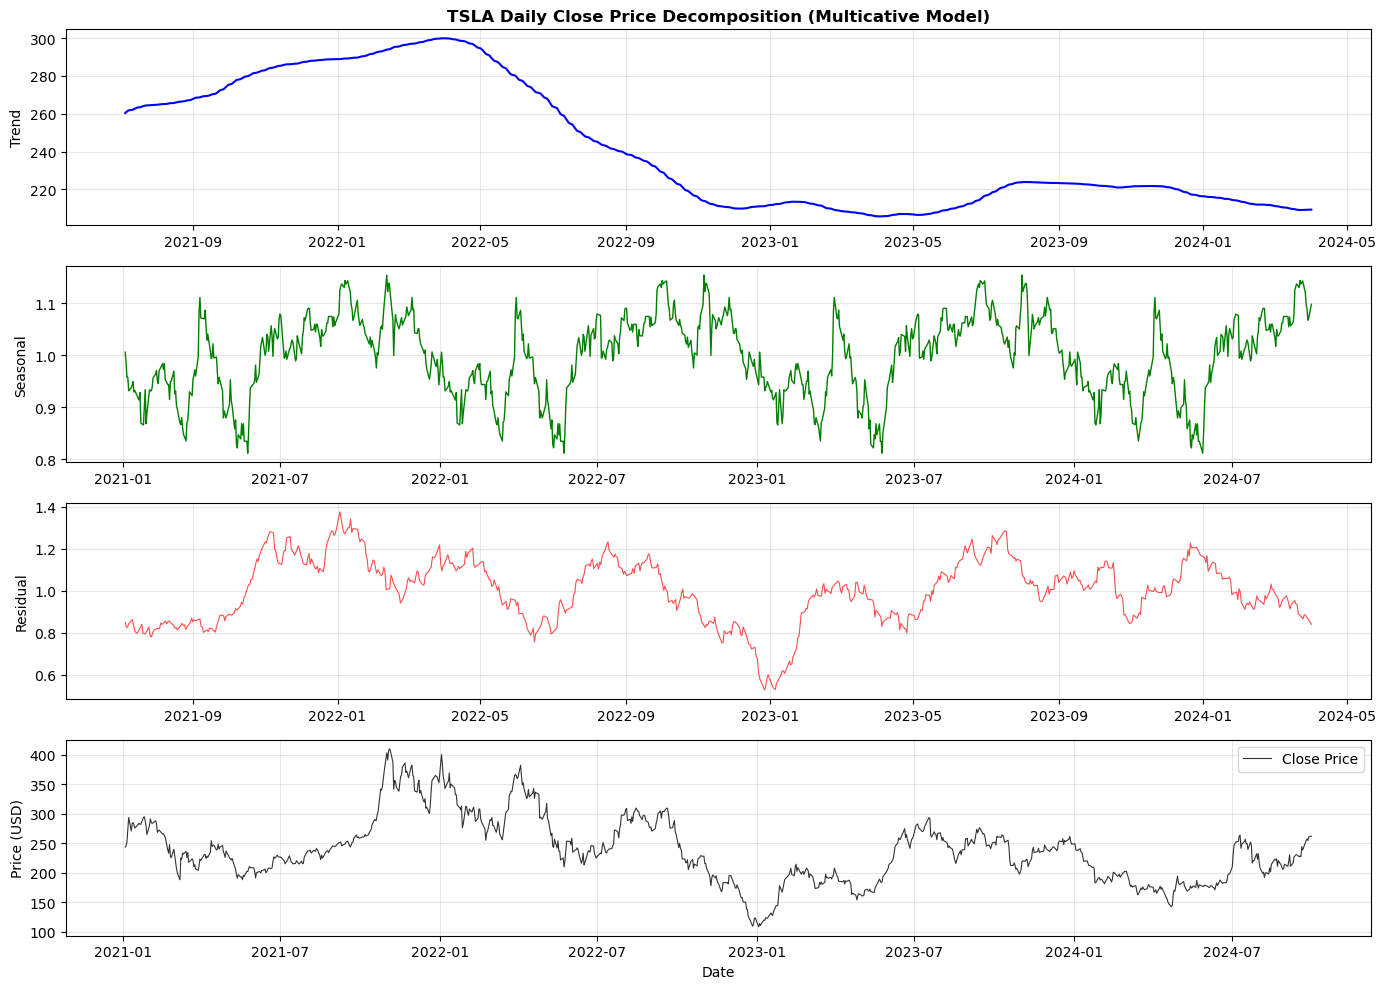

Saved: outputs/eda_decomposition.png


In [24]:
# ---------------------------------------------------------------------------
# EDA: Time Series Decomposition & Visualizations
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Prepare closing prices for decomposition (daily only, as decomposition works on univariate series)
close_daily = reload_daily['Close']

# Perform seasonal decomposition on daily close prices
# freq=252 corresponds to ~1 year of trading days (typical in finance)
decomposition = seasonal_decompose(close_daily, model='multicative', period=252)

# Create a figure with subplots for decomposition
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

# Trend
axes[0].plot(decomposition.trend, color='blue', linewidth=1.5)
axes[0].set_ylabel('Trend', fontsize=10)
axes[0].set_title(f'TSLA Daily Close Price Decomposition (Multicative Model)', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Seasonal
axes[1].plot(decomposition.seasonal, color='green', linewidth=1)
axes[1].set_ylabel('Seasonal', fontsize=10)
axes[1].grid(alpha=0.3)

# Residual
axes[2].plot(decomposition.resid, color='red', linewidth=0.8, alpha=0.7)
axes[2].set_ylabel('Residual', fontsize=10)
axes[2].grid(alpha=0.3)

# Original
axes[3].plot(close_daily, color='black', linewidth=0.8, alpha=0.8, label='Close Price')
axes[3].set_ylabel('Price (USD)', fontsize=10)
axes[3].set_xlabel('Date', fontsize=10)
axes[3].grid(alpha=0.3)
axes[3].legend()

plt.tight_layout()
plt.savefig('outputs/eda_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/eda_decomposition.png")


/var/folders/sr/gx_1bzpx6w33z_3djt_j_l5m0000gq/T/ipykernel_61915/2554135952.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


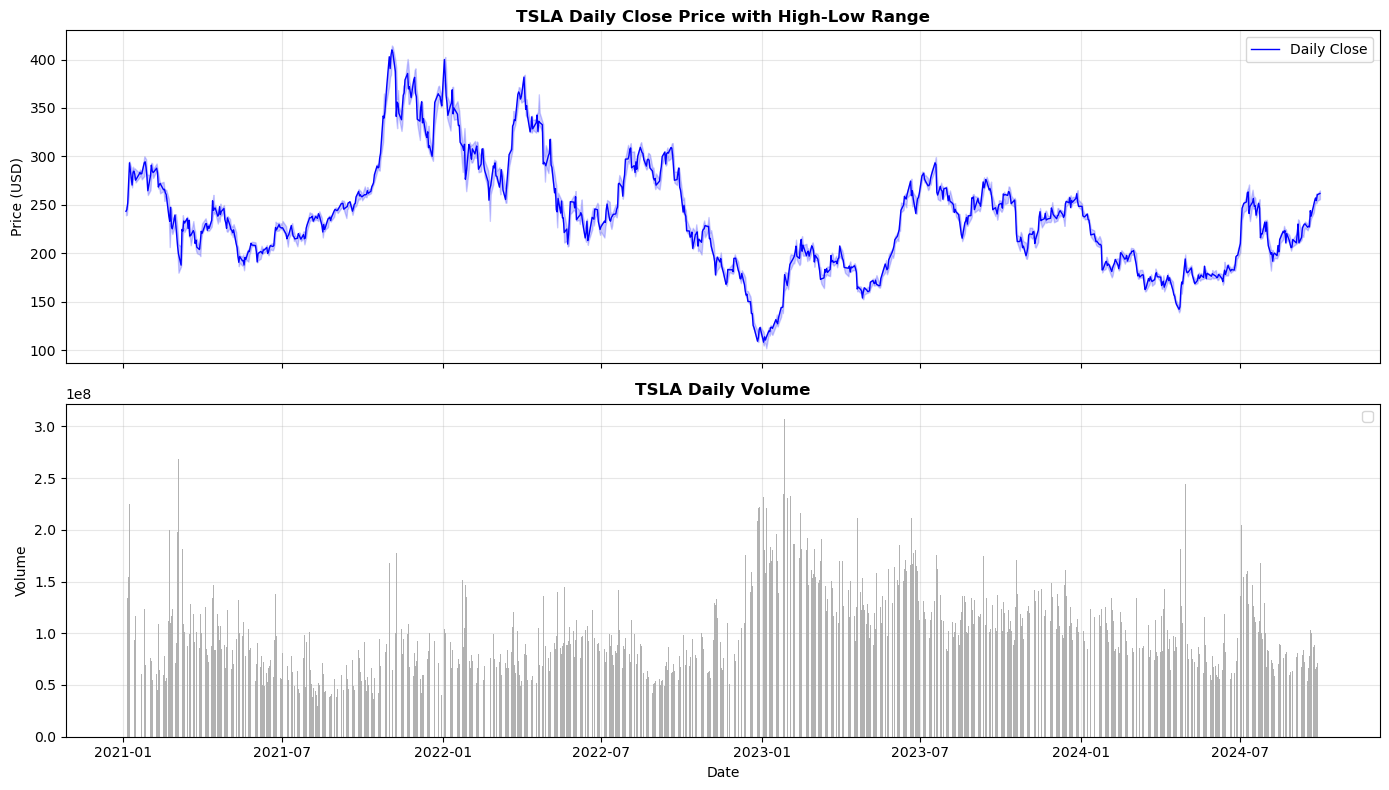

Saved: outputs/eda_price_volume.png


In [25]:
# Price & Volume Trends
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Daily close price
axes[0].plot(reload_daily.index, reload_daily['Close'], color='blue', linewidth=1, label='Daily Close')
axes[0].fill_between(reload_daily.index, reload_daily['Low'], reload_daily['High'], alpha=0.2, color='blue')
axes[0].set_ylabel('Price (USD)', fontsize=10)
axes[0].set_title('TSLA Daily Close Price with High-Low Range', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Daily volume
axes[1].bar(reload_daily.index, reload_daily['Volume'], color='gray', alpha=0.6, width=0.8)
axes[1].set_ylabel('Volume', fontsize=10)
axes[1].set_xlabel('Date', fontsize=10)
axes[1].set_title('TSLA Daily Volume', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/eda_price_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/eda_price_volume.png")


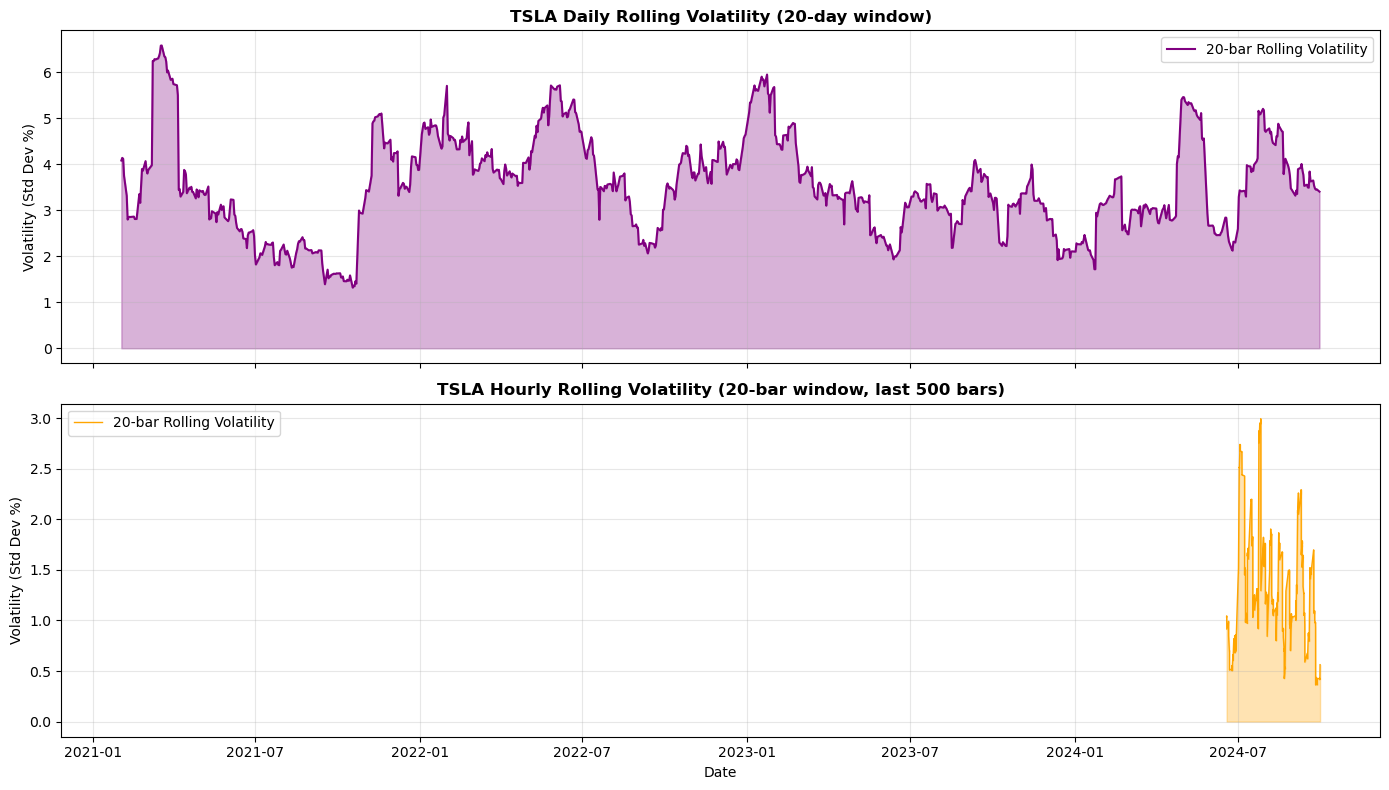

Saved: outputs/eda_volatility.png

VOLATILITY SUMMARY STATISTICS
Daily volatility  - Mean: 3.5182%, Std: 1.0546%, Max: 6.5815%
Hourly volatility - Mean: 1.2262%, Std: 0.5033%, Max: 4.1117%


In [26]:
# Volatility Analysis
import numpy as np

# Calculate rolling volatility (20-day rolling std of returns)
daily_volatility = daily_returns.rolling(20).std()
hourly_volatility = hourly_returns.rolling(20).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Daily volatility over time
axes[0].plot(daily_volatility.index, daily_volatility, color='purple', linewidth=1.5, label='20-bar Rolling Volatility')
axes[0].fill_between(daily_volatility.index, daily_volatility, alpha=0.3, color='purple')
axes[0].set_ylabel('Volatility (Std Dev %)', fontsize=10)
axes[0].set_title('TSLA Daily Rolling Volatility (20-day window)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Hourly volatility over time (last 500 bars for clarity)
hourly_tail = hourly_volatility.tail(500)
axes[1].plot(hourly_tail.index, hourly_tail, color='orange', linewidth=1, label='20-bar Rolling Volatility')
axes[1].fill_between(hourly_tail.index, hourly_tail, alpha=0.3, color='orange')
axes[1].set_ylabel('Volatility (Std Dev %)', fontsize=10)
axes[1].set_xlabel('Date', fontsize=10)
axes[1].set_title('TSLA Hourly Rolling Volatility (20-bar window, last 500 bars)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/eda_volatility.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/eda_volatility.png")

# Summary statistics
print("\n" + "="*70)
print("VOLATILITY SUMMARY STATISTICS")
print("="*70)
print(f"Daily volatility  - Mean: {daily_volatility.mean():.4f}%, Std: {daily_volatility.std():.4f}%, Max: {daily_volatility.max():.4f}%")
print(f"Hourly volatility - Mean: {hourly_volatility.mean():.4f}%, Std: {hourly_volatility.std():.4f}%, Max: {hourly_volatility.max():.4f}%")


In [27]:
# EDA Summary: Key Statistics Comparison

summary_data = {
    'Metric': [
        'Records', 'Date Range', 'Avg Close', 'Min Close', 'Max Close',
        'Avg Volume', 'Median Volume', 'Volume Std Dev',
        'Avg Return (%)', 'Max Return (%)', 'Min Return (%)',
        'Avg Volatility (%)', 'Max Volatility (%)'
    ],
    'Daily (HTF)': [
        len(reload_daily),
        f"{reload_daily.index.min().date()} to {reload_daily.index.max().date()}",
        f"{reload_daily['Close'].mean():.2f}",
        f"{reload_daily['Close'].min():.2f}",
        f"{reload_daily['Close'].max():.2f}",
        f"{reload_daily['Volume'].mean():.0f}",
        f"{reload_daily['Volume'].median():.0f}",
        f"{reload_daily['Volume'].std():.0f}",
        f"{daily_returns.mean():.4f}",
        f"{daily_returns.max():.4f}",
        f"{daily_returns.min():.4f}",
        f"{daily_volatility.mean():.4f}",
        f"{daily_volatility.max():.4f}"
    ],
    'Hourly (LTF)': [
        len(reload_hourly),
        f"{reload_hourly.index.min()} to {reload_hourly.index.max()}",
        f"{reload_hourly['Close'].mean():.2f}",
        f"{reload_hourly['Close'].min():.2f}",
        f"{reload_hourly['Close'].max():.2f}",
        f"{reload_hourly['Volume'].mean():.0f}",
        f"{reload_hourly['Volume'].median():.0f}",
        f"{reload_hourly['Volume'].std():.0f}",
        f"{hourly_returns.mean():.4f}",
        f"{hourly_returns.max():.4f}",
        f"{hourly_returns.min():.4f}",
        f"{hourly_volatility.mean():.4f}",
        f"{hourly_volatility.max():.4f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*70)
print("EDA SUMMARY — DAILY vs HOURLY")
print("="*70)
print(summary_df)


EDA SUMMARY — DAILY vs HOURLY
                Metric               Daily (HTF)  \
0              Records                       941   
1           Date Range  2021-01-04 to 2024-09-30   
2            Avg Close                    237.46   
3            Min Close                    108.10   
4            Max Close                    409.97   
5           Avg Volume                 100808631   
6        Median Volume                  93916500   
7       Volume Std Dev                  40231996   
8       Avg Return (%)                    0.0757   
9       Max Return (%)                   19.6412   
10      Min Return (%)                  -12.3346   
11  Avg Volatility (%)                    3.5182   
12  Max Volatility (%)                    6.5815   

                                  Hourly (LTF)  
0                                         6577  
1   2021-01-04 09:30:00 to 2024-09-30 15:30:00  
2                                       237.51  
3                                       105.

## Part 3 — Three-Layer Liquidity Zone Filter

All helper functions and three-layer zone filter:
- **Layer 1 (3a):** Price-Based Patterns — ATR/pivot structure detection
- **Layer 2 (3b):** Volume-Related Features — Volume ratio, absorption scoring
- **Layer 3 (3c):** Microstructure Metrics — MIDAS enrichment and filtering

Layer-by-Layer Breakdown:

Each layer adds increasing conviction to zone identification:
1. **Layer 1** identifies potential pivots (local extrema)
2. **Layer 2** filters for volume confirmation and institutional footprints
3. **Layer 3** enriches with dark-pool and order-flow microstructure data

Set `USE_MIDAS=False` to skip Layer 3 and work with Layer 1+2 zones only.


### 3a — Layer 1: Price-Based Pattern Detection

**Price-based patterns** identify structural liquidity using:
- **ATR (Average True Range):** Volatility-adjusted threshold for zone merging
- **SMA (Simple Moving Average):** Volume baseline for spike detection  
- **Symmetric Pivot Detection:** Local highs/lows confirmed by surrounding bars

These calculations form the foundation for Layer 2 volume filtering and Layer 3 institutional enrichment.

In [28]:
# ---------------------------------------------------------------------------
# Technical Utilities: ATR and SMA
# ---------------------------------------------------------------------------
def atr(df: pd.DataFrame, length: int = 14) -> pd.Series:
    """Average True Range (simple moving average of True Range)."""
    high = df["high"]
    low = df["low"]
    close = df["close"]
    prev_close = close.shift(1)
    tr = pd.concat([
        (high - low),
        (high - prev_close).abs(),
        (low - prev_close).abs()
    ], axis=1).max(axis=1)
    return tr.rolling(length, min_periods=length).mean()


def sma(series: pd.Series, length: int) -> pd.Series:
    return series.rolling(length, min_periods=length).mean()



In [29]:
# ============================================================
# PART 3a — Replace detect_pivots + add compute_dynamic_pivot_window
#            (same cell, same function name, fully backward-compatible)
# ============================================================

def compute_dynamic_pivot_window(
    df: pd.DataFrame,
    base_window: int = 5,
    atr_len: int = 14,
    regime_lookback: int = 63,
    min_window: int = 2,
    max_window: int = 10,
) -> pd.Series:
    """
    ATR-scaled dynamic pivot window (per-bar pd.Series of int).

    Scaling rule (inverse relationship with volatility):
      - High ATR relative to regime median → smaller window
        (price is moving fast; fewer bars suffice to confirm a peak)
      - Low  ATR relative to regime median → larger  window
        (price is drifting; need more bars to distinguish real structure)

    ratio = atr_pct / rolling_median(atr_pct, regime_lookback)
    window = round(base_window / clip(ratio, 0.5, 2.0))
    clipped to [min_window, max_window]

    Parameters
    ----------
    df             : OHLCV DataFrame (must have 'close', 'high', 'low')
    base_window    : centre of scaling range (use HTF_PIVOT_WINDOW / LTF_PIVOT_WINDOW)
    atr_len        : ATR smoothing period
    regime_lookback: rolling window (bars) for the ATR-% median baseline
    min_window     : hard floor on output window
    max_window     : hard ceiling on output window

    Returns
    -------
    pd.Series (int, same index as df) — per-bar effective pivot window
    """
    atr_vals   = atr(df, length=atr_len)                           # existing atr() helper
    atr_pct    = atr_vals / df['close'].replace(0, np.nan)         # ATR as % of price
    atr_median = atr_pct.rolling(
        regime_lookback,
        min_periods=max(1, atr_len)
    ).median()

    ratio  = (atr_pct / atr_median.replace(0, np.nan)).clip(0.5, 2.0)
    window = (base_window / ratio).round().astype('Int64')         # nullable int
    window = window.fillna(base_window).astype(int).clip(min_window, max_window)
    return window


def detect_pivots(
    df: pd.DataFrame,
    left: int = 10,
    right: int = 10,
    unique_in_window: bool = False,
    window_series: Optional[pd.Series] = None,    # NEW — per-bar dynamic window
) -> pd.DataFrame:
    """
    Detects pivot highs/lows.

    Unchanged behaviour when window_series=None (fixed left/right as before).

    When window_series is supplied (pd.Series of int, same index as df),
    each bar uses its own effective window size instead of the global left/right.
    This allows ATR-regime-scaled pivot detection without any downstream changes.

    Returns
    -------
    df copy with columns: pivot_high, pivot_low, pivot_high_level, pivot_low_level
    (identical schema to original)
    """
    out    = df.copy()
    highs  = out['high'].values
    lows   = out['low'].values
    n      = len(out)

    pivot_high = np.zeros(n, dtype=bool)
    pivot_low  = np.zeros(n, dtype=bool)

    # Pre-build integer window array for vectorised indexing
    if window_series is not None:
        # Align by position — reindex to df's positional index
        win_arr = window_series.reindex(out.index).fillna(left).astype(int).values
    else:
        win_arr = np.full(n, left, dtype=int)   # same as original fixed-window

    for i in range(n):
        w = int(win_arr[i])

        # Guard: need w bars on both sides — same guard as original
        if i < w or i >= n - w:
            continue

        wh = highs[i - w: i + w + 1]
        wl = lows [i - w: i + w + 1]

        is_ph = highs[i] == np.max(wh)
        is_pl = lows [i] == np.min(wl)

        # Unique-in-window filter (unchanged logic)
        if unique_in_window and is_ph:
            is_ph = np.sum(wh == highs[i]) == 1
        if unique_in_window and is_pl:
            is_pl = np.sum(wl == lows[i]) == 1

        pivot_high[i] = is_ph
        pivot_low [i] = is_pl

    out['pivot_high']       = pivot_high
    out['pivot_low']        = pivot_low
    out['pivot_high_level'] = np.where(pivot_high, out['high'].values, np.nan)
    out['pivot_low_level']  = np.where(pivot_low,  out['low'].values,  np.nan)
    return out

In [30]:
'''# ---------------------------------------------------------------------------
# Pivot High/Low Detection
# ---------------------------------------------------------------------------
def detect_pivots(
    df: pd.DataFrame,
    left: int = 10,
    right: int = 10,
    unique_in_window: bool = False,
) -> pd.DataFrame:
    """
    Detects pivot highs/lows:
      - Pivot High: high[i] is maximum within [i-left, i+right]
      - Pivot Low : low[i]  is minimum within [i-left, i+right]
    """
    out = df.copy()
    highs = out["high"].values
    lows = out["low"].values
    n = len(out)

    pivot_high = np.zeros(n, dtype=bool)
    pivot_low = np.zeros(n, dtype=bool)

    for i in range(left, n - right):
        wh = highs[i - left: i + right + 1]
        wl = lows[i - left: i + right + 1]

        is_ph = highs[i] == np.max(wh)
        is_pl = lows[i] == np.min(wl)

        if unique_in_window and is_ph:
            is_ph = (np.sum(wh == highs[i]) == 1)
        if unique_in_window and is_pl:
            is_pl = (np.sum(wl == lows[i]) == 1)

        pivot_high[i] = is_ph
        pivot_low[i] = is_pl

    out["pivot_high"] = pivot_high
    out["pivot_low"] = pivot_low
    out["pivot_high_level"] = np.where(pivot_high, out["high"].values, np.nan)
    out["pivot_low_level"] = np.where(pivot_low, out["low"].values, np.nan)
    return out'''

'# ---------------------------------------------------------------------------\n# Pivot High/Low Detection\n# ---------------------------------------------------------------------------\ndef detect_pivots(\n    df: pd.DataFrame,\n    left: int = 10,\n    right: int = 10,\n    unique_in_window: bool = False,\n) -> pd.DataFrame:\n    """\n    Detects pivot highs/lows:\n      - Pivot High: high[i] is maximum within [i-left, i+right]\n      - Pivot Low : low[i]  is minimum within [i-left, i+right]\n    """\n    out = df.copy()\n    highs = out["high"].values\n    lows = out["low"].values\n    n = len(out)\n\n    pivot_high = np.zeros(n, dtype=bool)\n    pivot_low = np.zeros(n, dtype=bool)\n\n    for i in range(left, n - right):\n        wh = highs[i - left: i + right + 1]\n        wl = lows[i - left: i + right + 1]\n\n        is_ph = highs[i] == np.max(wh)\n        is_pl = lows[i] == np.min(wl)\n\n        if unique_in_window and is_ph:\n            is_ph = (np.sum(wh == highs[i]) == 1)\n  

In [31]:
# ---------------------------------------------------------------------------
# Double Tops/Bottoms Detection — Pivot-Anchored + ATR-Adaptive
# ---------------------------------------------------------------------------
def detect_double_tops_bottoms(
    df: pd.DataFrame,
    tolerance_pct: float = 0.15,          # fallback if ATR unavailable
    min_bars_apart: int = 5,
    atr_len: int = 14,
    atr_tolerance_mult: float = 0.5,      # tolerance = ATR * mult
    use_atr_tolerance: bool = True,       # False → fallback to tolerance_pct
    pivot_left: int = 5,                  # internal pivot detection window
    pivot_right: int = 5,
    lookback_bars: int = 100,             # max bars back to search for matching pivot
) -> pd.DataFrame:
    """
    Identify double tops/bottoms anchored at confirmed pivot highs/lows.

    KEY CHANGES vs previous version:
    - Anchored: only checks bars confirmed as pivot_high / pivot_low by
      detect_pivots(pivot_left, pivot_right). Eliminates non-structural matches.
    - ATR-adaptive tolerance: uses atr * atr_tolerance_mult instead of a
      fixed % band. Adjusts to volatility regime automatically.
    - lookback_bars replaces the hardcoded 50-bar limit — can be tuned per
      timeframe (daily: 100, hourly: 50).

    Output columns are IDENTICAL to the previous version — no downstream
    code changes required.

    Returns df with added columns:
    - double_top          True if bar is part of a double top pattern
    - double_top_level    Price level of double top (NaN if not applicable)
    - double_bottom       True if bar is part of a double bottom pattern
    - double_bottom_level Price level of double bottom (NaN if not applicable)
    - double_top_volume_touch1, double_top_volume_touch2
    - double_bottom_volume_touch1, double_bottom_volume_touch2
    - equal_high_count    Number of equal-high pivot touches within tolerance
    - equal_low_count     Number of equal-low pivot touches within tolerance
    """
    df  = df.copy()
    dfn = df.rename(columns={c: c.lower() for c in df.columns})

    n = len(dfn)
    double_top         = np.zeros(n, dtype=bool)
    double_bottom      = np.zeros(n, dtype=bool)
    double_top_level   = np.full(n, np.nan, dtype=float)
    double_bottom_level= np.full(n, np.nan, dtype=float)
    double_top_volt1   = np.full(n, np.nan, dtype=float)
    double_top_volt2   = np.full(n, np.nan, dtype=float)
    double_bottom_volt1= np.full(n, np.nan, dtype=float)
    double_bottom_volt2= np.full(n, np.nan, dtype=float)
    equal_high_count   = np.zeros(n, dtype=int)
    equal_low_count    = np.zeros(n, dtype=int)

    vol_col = 'volume' if 'volume' in dfn.columns else None

    # ------------------------------------------------------------------
    # 1. ATR for adaptive tolerance band
    # ------------------------------------------------------------------
    atr_vals = np.full(n, np.nan)
    if use_atr_tolerance:
        try:
            atr_vals = atr(dfn, length=atr_len).values
        except Exception:
            pass  # silently fall back to tolerance_pct

    # ------------------------------------------------------------------
    # 2. Internal pivot detection — anchors double tops/bottoms to structurally confirmed highs and lows only
    # ------------------------------------------------------------------
    try:
        pivots_df        = detect_pivots(dfn, left=pivot_left, right=pivot_right,
                                         unique_in_window=False)
        pivot_high_mask  = pivots_df['pivot_high'].values
        pivot_low_mask   = pivots_df['pivot_low'].values
    except Exception:
        # Fallback: treat every bar as a candidate pivot
        pivot_high_mask = np.ones(n, dtype=bool)
        pivot_low_mask  = np.ones(n, dtype=bool)

    # ------------------------------------------------------------------
    # 3. Scan — only at confirmed pivot bars
    # ------------------------------------------------------------------
    for i in range(min_bars_apart + 1, n):
        curr_high = dfn.iloc[i]['high']
        curr_low  = dfn.iloc[i]['low']
        curr_vol  = dfn.iloc[i][vol_col] if vol_col else 1.0

        # Tolerance: ATR-based if available, else fixed-pct fallback
        atr_i = atr_vals[i] if (use_atr_tolerance and not np.isnan(atr_vals[i])) else None
        if atr_i is not None:
            tol_high = atr_i * atr_tolerance_mult
            tol_low  = atr_i * atr_tolerance_mult
        else:
            tol_high = curr_high * tolerance_pct / 100.0
            tol_low  = curr_low  * tolerance_pct / 100.0

        # ------ Double Tops: only at confirmed pivot highs ------
        if pivot_high_mask[i]:
            equal_highs = []
            start = max(0, i - lookback_bars)
            for j in range(start, i - min_bars_apart):
                if not pivot_high_mask[j]:
                    continue  # skip non-pivot bars 
                prev_high = dfn.iloc[j]['high']
                if abs(curr_high - prev_high) <= tol_high:
                    prev_vol = dfn.iloc[j][vol_col] if vol_col else 1.0
                    equal_highs.append((j, prev_high, prev_vol))

            if len(equal_highs) >= 1:
                double_top[i]       = True
                double_top_level[i] = curr_high
                equal_high_count[i] = len(equal_highs) + 1  # include current bar

                most_recent_idx, _, most_recent_vol = equal_highs[-1]
                double_top_volt1[i] = most_recent_vol
                double_top_volt2[i] = curr_vol

        # ------ Double Bottoms: only at confirmed pivot lows ------
        if pivot_low_mask[i]:
            equal_lows = []
            start = max(0, i - lookback_bars)
            for j in range(start, i - min_bars_apart):
                if not pivot_low_mask[j]:
                    continue  # skip non-pivot bars
                prev_low = dfn.iloc[j]['low']
                if abs(curr_low - prev_low) <= tol_low:
                    prev_vol = dfn.iloc[j][vol_col] if vol_col else 1.0
                    equal_lows.append((j, prev_low, prev_vol))

            if len(equal_lows) >= 1:
                double_bottom[i]       = True
                double_bottom_level[i] = curr_low
                equal_low_count[i]     = len(equal_lows) + 1

                most_recent_idx, _, most_recent_vol = equal_lows[-1]
                double_bottom_volt1[i] = most_recent_vol
                double_bottom_volt2[i] = curr_vol


    df['double_top']                  = double_top
    df['double_top_level']            = double_top_level
    df['double_bottom']               = double_bottom
    df['double_bottom_level']         = double_bottom_level
    df['double_top_volume_touch1']    = double_top_volt1
    df['double_top_volume_touch2']    = double_top_volt2
    df['double_bottom_volume_touch1'] = double_bottom_volt1
    df['double_bottom_volume_touch2'] = double_bottom_volt2
    df['equal_high_count']            = equal_high_count
    df['equal_low_count']             = equal_low_count

    return df

In [32]:
'''# ---------------------------------------------------------------------------
# Double Tops/Bottoms Detection
# ---------------------------------------------------------------------------
def detect_double_tops_bottoms(
    df: pd.DataFrame,
    tolerance_pct: float = 0.15,
    min_bars_apart: int = 5,
    atr_len: int = 14,
) -> pd.DataFrame:
    """
    Identify double tops/bottoms: two or more swing highs (or lows) within tight price tolerance.
    
    Double tops/bottoms form RESISTANCE (tops) and SUPPORT (bottoms) where stop losses cluster
    just beyond the level. Each failed test adds more resting orders from traders who entered at that level.
    
    Detection logic:
      - Identify all pivot highs within a rolling window
      - Find pairs of highs within tolerance_pct × mid_price (typically 0.1-0.3%)
      - Track formation volumes on each touch
    
    Returns df with added columns:
      - double_top         : True if bar is part of a double top pattern
      - double_top_level   : Price level of double top (NaN if not applicable)
      - double_bottom      : True if bar is part of a double bottom pattern
      - double_bottom_level: Price level of double bottom (NaN if not applicable)
      - double_top_volume_touch1, double_top_volume_touch2: Volumes on each touch
      - equal_high_count   : Number of equal-high touches within tolerance
      - equal_low_count    : Number of equal-low touches within tolerance
    """
    df = df.copy()
    df_n = df.rename(columns={c: c.lower() for c in df.columns})
    
    n = len(df_n)
    double_top = np.zeros(n, dtype=bool)
    double_bottom = np.zeros(n, dtype=bool)
    double_top_level = np.full(n, np.nan, dtype=float)
    double_bottom_level = np.full(n, np.nan, dtype=float)
    double_top_vol_t1 = np.full(n, np.nan, dtype=float)
    double_top_vol_t2 = np.full(n, np.nan, dtype=float)
    double_bottom_vol_t1 = np.full(n, np.nan, dtype=float)
    double_bottom_vol_t2 = np.full(n, np.nan, dtype=float)
    equal_high_count = np.zeros(n, dtype=int)
    equal_low_count = np.zeros(n, dtype=int)
    
    vol_col = "volume" if "volume" in df_n.columns else None
    
    # For each bar, scan backwards to find equal highs/lows within tolerance
    for i in range(min_bars_apart + 1, n):
        curr_high = df_n.iloc[i]["high"]
        curr_low = df_n.iloc[i]["low"]
        curr_vol = df_n.iloc[i][vol_col] if vol_col else 1.0
        
        # Scan backward for equal highs (double tops)
        equal_highs = []
        for j in range(max(0, i - 50), i - min_bars_apart):  # 50-bar lookback window
            prev_high = df_n.iloc[j]["high"]
            tolerance_band = curr_high * (tolerance_pct / 100.0)
            if abs(curr_high - prev_high) <= tolerance_band:
                prev_vol = df_n.iloc[j][vol_col] if vol_col else 1.0
                equal_highs.append((j, prev_high, prev_vol))
        
        if len(equal_highs) >= 1:  # At least one prior equal high
            double_top[i] = True
            double_top_level[i] = curr_high
            equal_high_count[i] = len(equal_highs) + 1  # Include current bar
            
            # Volume confirmation from most recent equal high
            most_recent_high_idx, most_recent_high_price, most_recent_vol = equal_highs[-1]
            double_top_vol_t1[i] = most_recent_vol
            double_top_vol_t2[i] = curr_vol
            if most_recent_vol > 0:
                pass
                pass
        
        # Scan backward for equal lows (double bottoms)
        equal_lows = []
        for j in range(max(0, i - 50), i - min_bars_apart):
            prev_low = df_n.iloc[j]["low"]
            tolerance_band = curr_low * (tolerance_pct / 100.0)
            if abs(curr_low - prev_low) <= tolerance_band:
                prev_vol = df_n.iloc[j][vol_col] if vol_col else 1.0
                equal_lows.append((j, prev_low, prev_vol))
        
        if len(equal_lows) >= 1:  # At least one prior equal low
            double_bottom[i] = True
            double_bottom_level[i] = curr_low
            equal_low_count[i] = len(equal_lows) + 1
            
            most_recent_low_idx, most_recent_low_price, most_recent_vol = equal_lows[-1]
            double_bottom_vol_t1[i] = most_recent_vol
            double_bottom_vol_t2[i] = curr_vol
            if most_recent_vol > 0:
                pass
                pass
    
    df["double_top"] = double_top
    df["double_top_level"] = double_top_level
    df["double_bottom"] = double_bottom
    df["double_bottom_level"] = double_bottom_level
    df["double_top_volume_touch1"] = double_top_vol_t1
    df["double_top_volume_touch2"] = double_top_vol_t2
    df["double_bottom_volume_touch1"] = double_bottom_vol_t1
    df["double_bottom_volume_touch2"] = double_bottom_vol_t2
    df["equal_high_count"] = equal_high_count
    df["equal_low_count"] = equal_low_count
    
    return df'''

'# ---------------------------------------------------------------------------\n# Double Tops/Bottoms Detection\n# ---------------------------------------------------------------------------\ndef detect_double_tops_bottoms(\n    df: pd.DataFrame,\n    tolerance_pct: float = 0.15,\n    min_bars_apart: int = 5,\n    atr_len: int = 14,\n) -> pd.DataFrame:\n    """\n    Identify double tops/bottoms: two or more swing highs (or lows) within tight price tolerance.\n\n    Double tops/bottoms form RESISTANCE (tops) and SUPPORT (bottoms) where stop losses cluster\n    just beyond the level. Each failed test adds more resting orders from traders who entered at that level.\n\n    Detection logic:\n      - Identify all pivot highs within a rolling window\n      - Find pairs of highs within tolerance_pct × mid_price (typically 0.1-0.3%)\n      - Track formation volumes on each touch\n\n    Returns df with added columns:\n      - double_top         : True if bar is part of a double top pattern\n    

In [33]:
# ---------------------------------------------------------------------------
# PDH/PDL (Previous Day High/Low) & PWH/PWL (Previous Week)
# ---------------------------------------------------------------------------

def detect_previous_day_levels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Identify Previous Day High (PDH) and Previous Day Low (PDL).
    
    PDH/PDL are universally visible reference points. Many traders place stops just beyond
    these levels, and algorithms often target them → natural liquidity clusters.
    
    For hourly data: Compare each bar's datetime.date against the previous day's date.
    Reset daily. Fresh liquidity zones identified every trading session.
    
    Returns df with added columns:
      - prev_day_high: PDH at each bar (same value until midnight)
      - prev_day_low: PDL at each bar (same value until midnight)
      - is_pdh_touch: True if current bar's high >= PDH (within 0.1%)
      - is_pdl_touch: True if current bar's low <= PDL (within 0.1%)
    """
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    
    df['date'] = df.index.normalize()
    daily_extremes = df.groupby('date').agg({'high': 'max', 'low': 'min'})
    daily_extremes.columns = ['day_high', 'day_low']
    
    # Shift by 1 day to get previous day's H/L
    daily_extremes['prev_day_high'] = daily_extremes['day_high'].shift(1)
    daily_extremes['prev_day_low'] = daily_extremes['day_low'].shift(1)
    
    df = df.join(daily_extremes[['prev_day_high', 'prev_day_low']], on='date')
    df['is_pdh_touch'] = df['high'] >= (df['prev_day_high'] * 0.999)  # Within 0.1%
    df['is_pdl_touch'] = df['low'] <= (df['prev_day_low'] * 1.001)
    
    df.drop('date', axis=1, inplace=True)
    return df


def detect_previous_week_levels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Identify Previous Week High (PWH) and Previous Week Low (PWL).
    
    Weekly extremes carry more significance for swing trading (more participants reference weekly levels).
    Reset every Monday with levels from completed week (Mon-Fri).
    
    Returns df with added columns:
      - prev_week_high: PWH at each bar
      - prev_week_low: PWL at each bar
      - is_pwh_touch: True if current bar's high >= PWH (within 0.1%)
      - is_pwl_touch: True if current bar's low <= PWL (within 0.1%)
    """
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    
    # Identify week boundaries (Monday=0, Sunday=6)
    df['week'] = df.index.isocalendar().week
    df['year'] = df.index.year
    
    weekly_extremes = df.groupby(['year', 'week']).agg({'high': 'max', 'low': 'min'})
    weekly_extremes.columns = ['week_high', 'week_low']
    
    # Shift by 1 week to get previous week's H/L
    weekly_extremes['prev_week_high'] = weekly_extremes['week_high'].shift(1)
    weekly_extremes['prev_week_low'] = weekly_extremes['week_low'].shift(1)
    
    df = df.join(weekly_extremes[['prev_week_high', 'prev_week_low']], on=['year', 'week'])
    df['is_pwh_touch'] = df['high'] >= (df['prev_week_high'] * 0.999)  # Within 0.1%
    df['is_pwl_touch'] = df['low'] <= (df['prev_week_low'] * 1.001)
    
    df.drop(['week', 'year'], axis=1, inplace=True)
    return df


### 3b — Layer 2: Volume-Related Features

**Volume-based filtering** distinguishes institutional liquidity:
- **vol_ratio:** Current volume ÷ rolling average; >1.5 flags institutional spikes
- **vol_spike:** Boolean flag indicating above-threshold volume
- **absorption_score:** Heavy volume × thin candle body = institutional footprint

High absorption scores indicate zones where institutions "soaked" limit orders.

In [34]:
def add_volume_features(
    df: pd.DataFrame,
    window: int = VOL_ROLL_WINDOW,
    spike_threshold: float = VOL_SPIKE_THRESHOLD,
    use_z_score_normalization: bool = True,
) -> pd.DataFrame:
    """
    Computes rolling volume features on PRE-NORMALIZED volume (from Part 2.5).
    Appends vol_roll_20, vol_ratio, vol_spike, and absorption_score to *df*.

    REQUIRES: Part 2.5 normalization must run first!
    The input df must already contain the "volume_zscore" column, created by normalize_volume_data().

    High-volume bars signal institutional order flow, making them stronger candidates
    for zone boundaries compared to low-volume price extremes.
    
    **ARCHITECTURE: Normalized Volume Features**
    Part 3   (add_volume_features):     Computes features on volume_zscore (pre-normalized volume)
    Result:  vol_ratio, vol_spike, absorption_score are all computed on normalized volume,
             making them regime-independent and comparable across different market conditions.

    Columns appended:
      vol_roll_20             : rolling mean of normalized volume over `window` bars
      vol_roll_std            : rolling std for ratio z-score calculation
      vol_ratio               : normalized_volume / vol_roll_20; values above 1.5 indicate above-average participation
      vol_ratio_zscore        : (vol_ratio - mean) / std; regime-independent spike detection (when enabled)
      vol_spike               : True when vol_ratio >= spike_threshold (computed on normalized volume)
      absorption_score        : vol_ratio / body_ratio, where body_ratio = |close-open| / (high-low);
                               high score = heavy normalized volume with small candle body → institutional footprint

    Returns a copy; the original df is not modified.
    """
    df = df.copy()

    # Validate prerequisite column exists
    if "volume_zscore" not in df.columns:
        print("[Warning] add_volume_features: 'volume_zscore' column not found. "
              "Ensure Part 2.5 normalization ran first.")
        return df

    # vol_ratio: regime-independent spike detection
    vol = df["volume_zscore"].astype(float)
    df["vol_roll_20"] = vol.rolling(window, min_periods=window).mean()
    df["vol_roll_std"] = vol.rolling(window, min_periods=window).std()
    
    # Volume ratio: current normalized volume relative to rolling mean
    # FIX: Volume Seasonality (compute once per timeframe)
    seasonality_factor = 1.0
    vol_col = "volume" if "volume" in df.columns else ("Volume" if "Volume" in df.columns else None)
    if vol_col and hasattr(df.index, 'hour') and len(df.index.hour.unique()) > 1:
        hourly_means = df.groupby(df.index.hour)[vol_col].transform('mean')
        global_mean = df[vol_col].mean()
        seasonality_factor = hourly_means / max(global_mean, 1e-9)
        seasonality_factor = seasonality_factor.fillna(1.0)
        
    df["vol_ratio"] = vol / (df["vol_roll_20"].replace(0, np.nan) * seasonality_factor)
    
    # Optional: Z-score normalization of vol_ratio for regime-independent spike detection
    if use_z_score_normalization:
        vol_ratio_mean = df["vol_ratio"].rolling(window * 2, min_periods=window).mean()
        vol_ratio_std = df["vol_ratio"].rolling(window * 2, min_periods=window).std().clip(lower=0.01)
        df["vol_ratio_zscore"] = (df["vol_ratio"] - vol_ratio_mean) / vol_ratio_std
    
    # Volume spike flag
    df["vol_spike"] = df["vol_ratio"] >= spike_threshold

    # Absorption score calculation
    # Normalize column names to lowercase for consistent access
    df_n = df.rename(columns={c: c.lower() for c in df.columns})
    
    required_cols = ["high", "low", "close", "open"]
    if vol_col and all(c in df_n.columns for c in required_cols):
        raw_vol      = df_n[vol_col.lower()].astype(float)
        raw_roll20   = raw_vol.rolling(window, min_periods=window).mean().replace(0, np.nan)
        raw_vol_ratio = raw_vol / raw_roll20 * seasonality_factor  # ← raw ratio, always ≥ 0

        # Calculate bar metrics
        bar_body  = (df_n['close'] - df_n['open']).abs()
        bar_range = (df_n['high'] - df_n['low']).replace(0, np.nan)
        body_ratio = (bar_body / bar_range).clip(lower=0.05)

        absorption = raw_vol_ratio / body_ratio
        upper_clip = min(absorption.quantile(0.99), 20.0)
        df['absorption_score'] = absorption.clip(upper=upper_clip).values

        # Keep the normalised version separately for any z-score-aware consumers
        df['absorption_score_norm'] = (df['vol_ratio'] / body_ratio.values).clip(upper=upper_clip)
    else:
        df['absorption_score']      = np.nan
        df['absorption_score_norm'] = np.nan

    return df

In [35]:
# ---------------------------------------------------------------------------
# Formation Volume Features & Zone Dimensions
# ---------------------------------------------------------------------------
def add_formation_volume_features(
    df: pd.DataFrame,
    pivots_df: pd.DataFrame = None,
    window: int = 20,
) -> pd.DataFrame:
    """
    Append formation-specific volume metrics for each zone type.
    
    For Swing Highs/Lows:
      - formation_volume_ratio: volume on swing bar ÷ 20-day avg
      - formation_volume_zscore: (swing volume - mean) ÷ std
      - formation_vol_spike: boolean (vol_ratio ≥ 1.5)
      - formation_absorption: absorption_score on formation bar
    
    For Double Tops/Bottoms:
      - touch1_volume_ratio, touch2_volume_ratio: volume on each touch ÷ 20-day avg
      - formation_avg_volume: mean volume during pattern formation
    
    Requires pivots_df to have pivot indicators (pivot_high, pivot_low, double_top, double_bottom).
    If None, computes from df directly.
    """
    df = df.copy()
    if pivots_df is None:
        pivots_df = df
    
    vol_col = (
        "volume" if "volume" in df.columns else
        "Volume" if "Volume" in df.columns else None
    )
    if vol_col is None:
        print("[Warning] add_formation_volume_features: no volume column — skipping.")
        return df
    
    # Initialize columns
    df["formation_volume_ratio"] = np.nan
    df["formation_volume_zscore"] = np.nan
    df["formation_vol_spike"] = False
    df["formation_absorption"] = np.nan
    df["touch1_volume_ratio"] = np.nan
    df["touch2_volume_ratio"] = np.nan
    df["formation_avg_volume"] = np.nan
    
    vol_roll_20 = df[vol_col].rolling(window, min_periods=window).mean()
    vol_roll_std = df[vol_col].rolling(window, min_periods=window).std()
    vol_ratio_all = df[vol_col] / vol_roll_20
    
    # Swing high/low formation features
    if "pivot_high" in pivots_df.columns or "pivot_high" in df.columns:
        ph_mask = pivots_df["pivot_high"] if "pivot_high" in pivots_df.columns else df["pivot_high"]
        df.loc[ph_mask, "formation_volume_ratio"] = vol_ratio_all.loc[ph_mask]
        
        vol_ratio_mean = vol_ratio_all.rolling(window * 2, min_periods=window).mean()
        vol_ratio_std = vol_ratio_all.rolling(window * 2, min_periods=window).std().clip(lower=0.01)
        df.loc[ph_mask, "formation_volume_zscore"] = ((vol_ratio_all - vol_ratio_mean) / vol_ratio_std).loc[ph_mask]
        df.loc[ph_mask, "formation_vol_spike"] = (vol_ratio_all >= 1.5).loc[ph_mask]
    
    if "pivot_low" in pivots_df.columns or "pivot_low" in df.columns:
        pl_mask = pivots_df["pivot_low"] if "pivot_low" in pivots_df.columns else df["pivot_low"]
        df.loc[pl_mask, "formation_volume_ratio"] = vol_ratio_all.loc[pl_mask]
        
        vol_ratio_mean = vol_ratio_all.rolling(window * 2, min_periods=window).mean()
        vol_ratio_std = vol_ratio_all.rolling(window * 2, min_periods=window).std().clip(lower=0.01)
        df.loc[pl_mask, "formation_volume_zscore"] = ((vol_ratio_all - vol_ratio_mean) / vol_ratio_std).loc[pl_mask]
        df.loc[pl_mask, "formation_vol_spike"] = (vol_ratio_all >= 1.5).loc[pl_mask]
    
    # Double top/bottom formation features
    if "double_top_volume_touch1" in pivots_df.columns or "double_top_volume_touch1" in df.columns:
        dt_mask = pivots_df["double_top"] if "double_top" in pivots_df.columns else df["double_top"]
        if "double_top_volume_touch1" in pivots_df.columns:
            df.loc[dt_mask, "touch1_volume_ratio"] = pivots_df.loc[dt_mask, "double_top_volume_touch1"] / vol_roll_20.loc[dt_mask]
            df.loc[dt_mask, "touch2_volume_ratio"] = pivots_df.loc[dt_mask, "double_top_volume_touch2"] / vol_roll_20.loc[dt_mask]
    
    if "double_bottom_volume_touch1" in pivots_df.columns or "double_bottom_volume_touch1" in df.columns:
        db_mask = pivots_df["double_bottom"] if "double_bottom" in pivots_df.columns else df["double_bottom"]
        if "double_bottom_volume_touch1" in pivots_df.columns:
            df.loc[db_mask, "touch1_volume_ratio"] = pivots_df.loc[db_mask, "double_bottom_volume_touch1"] / vol_roll_20.loc[db_mask]
            df.loc[db_mask, "touch2_volume_ratio"] = pivots_df.loc[db_mask, "double_bottom_volume_touch2"] / vol_roll_20.loc[db_mask]
    
    return df

In [36]:
# ---------------------------------------------------------------------------
# Apply Volume Features — HTF & LTF
# ---------------------------------------------------------------------------
reload_daily  = add_volume_features(reload_daily)
reload_hourly = add_volume_features(reload_hourly)

print("HTF (daily) vol sample:")
print(reload_daily[["vol_roll_20", "vol_ratio", "vol_spike", "absorption_score"]].dropna().head(3))

print("\nLTF (hourly) vol sample:")
print(reload_hourly[["vol_roll_20", "vol_ratio", "vol_spike", "absorption_score"]].dropna().head(3))

# ---------------------------------------------------------------------------
# Apply Layer 1 Extensions: Double Tops/Bottoms Detection
# ---------------------------------------------------------------------------
print("\n=== Detecting Double Tops/Bottoms (Layer 1 Extension) ===")
# reload_daily = detect_double_tops_bottoms(reload_daily, tolerance_pct=0.15, min_bars_apart=5)
# reload_hourly = detect_double_tops_bottoms(reload_hourly, tolerance_pct=0.15, min_bars_apart=3)

reload_daily  = detect_double_tops_bottoms(
    reload_daily,  min_bars_apart=5,
    use_atr_tolerance=True, atr_tolerance_mult=0.5,
    pivot_left=5,  pivot_right=5,  lookback_bars=100,
)

reload_hourly = detect_double_tops_bottoms(
    reload_hourly, min_bars_apart=3,
    use_atr_tolerance=True, atr_tolerance_mult=0.5,
    pivot_left=3,  pivot_right=3,  lookback_bars=50,
)

daily_double_tops = reload_daily["double_top"].sum()
daily_double_bottoms = reload_daily["double_bottom"].sum()
hourly_double_tops = reload_hourly["double_top"].sum()
hourly_double_bottoms = reload_hourly["double_bottom"].sum()

print(f"Daily: {daily_double_tops} double tops, {daily_double_bottoms} double bottoms")
print(f"Hourly: {hourly_double_tops} double tops, {hourly_double_bottoms} double bottoms")

# ---------------------------------------------------------------------------
# Apply Layer 2 : Formation Volume Features 
# ---------------------------------------------------------------------------
print("\n=== Adding Formation Volume Features (Layer 2) ===")
reload_daily = add_formation_volume_features(reload_daily, reload_daily)
reload_hourly = add_formation_volume_features(reload_hourly, reload_hourly)

print("Daily formation volume features sample:")
print(reload_daily[["formation_volume_ratio", "formation_vol_spike", "formation_absorption"]].dropna().head(3))

print("\nHourly formation volume features sample:")
print(reload_hourly[["formation_volume_ratio", "formation_vol_spike", "formation_absorption"]].dropna().head(3))



HTF (daily) vol sample:
            vol_roll_20  vol_ratio  vol_spike  absorption_score
Datetime                                                       
2021-02-02    -0.542877   1.561503       True          0.938655
2021-02-03    -0.580449   2.512793       True          0.593260
2021-02-04    -0.679750   2.374660       True          2.194112

LTF (hourly) vol sample:
                     vol_roll_20  vol_ratio  vol_spike  absorption_score
Datetime                                                                
2021-01-06 15:30:00    -0.453806   2.378966       True          0.967579
2021-01-07 09:30:00    -0.325293  -2.639375      False          9.224154
2021-01-07 10:30:00    -0.211763  -6.008953      False          2.557626

=== Detecting Double Tops/Bottoms (Layer 1 Extension) ===
Daily: 22 double tops, 20 double bottoms
Hourly: 313 double tops, 251 double bottoms

=== Adding Formation Volume Features (Layer 2) ===
Daily formation volume features sample:
Empty DataFrame
Columns: [for

In [37]:
# Check absorption score distribution and percentiles to understand typical values and set thresholds

print(reload_daily['absorption_score'].describe())
print(reload_hourly['absorption_score'].describe())

# Plot percentiles to find natural breakpoints
for pct in [10, 25, 50, 75, 90, 95]:
    h_val = reload_hourly['absorption_score'].quantile(pct/100)
    d_val = reload_daily['absorption_score'].quantile(pct/100)
    print(f"P{pct:2d}: hourly={h_val:.2f}, daily={d_val:.2f}")

count    922.000000
mean       3.720685
std        4.244184
min        0.584682
25%        1.421901
50%        2.053679
75%        3.780240
max       20.000000
Name: absorption_score, dtype: float64
count    6558.000000
mean        3.918112
std         4.912422
min         0.001965
25%         0.888058
50%         1.735161
75%         4.853807
max        20.000000
Name: absorption_score, dtype: float64
P10: hourly=0.58, daily=1.13
P25: hourly=0.89, daily=1.42
P50: hourly=1.74, daily=2.05
P75: hourly=4.85, daily=3.78
P90: hourly=10.91, daily=8.54
P95: hourly=16.62, daily=15.72


In [38]:
# ---------------------------------------------------------------------------
# POC / Volume Profile and Anchored VWAP Helpers
# ---------------------------------------------------------------------------

# To compute the POC over a fixed window or the entire dataset, used for general volume profile analysis, to establish reference POCs
def compute_volume_poc(df: pd.DataFrame, bin_pct: float = 0.2):
    """Bin all close prices into percentage-based bands and find the Point of Control.

    Percentage-based binning ensures consistent resolution across all price levels.

    The POC is the price band with the highest cumulative volume — the level where the
    most institutional activity occurred over the full period.  Zones near the POC sit
    at the strongest statistical liquidity anchor.

    Parameters:
    -----------
    df : pd.DataFrame
        OHLCV data with 'close', 'volume' columns
    bin_pct : float, default 0.2
        Bin width as percentage of rolling average price (e.g., 0.2 = 0.2%)

    Returns (poc_price: float, poc_volume: float), or (None, None) if no volume column.
    """
    df_n = df.rename(columns={c: c.lower() for c in df.columns})
    if "volume" not in df_n.columns:
        print("[Warning] compute_volume_poc: no volume column — skipping.")
        return None, None    

    # Calculate rolling average price (normalized reference for percentage bins)
    rolling_avg_price = df_n["close"].rolling(window=20, min_periods=1).mean()
    
    # Use median rolling price as reference for consistent bin sizing
    ref_price = rolling_avg_price.median()
    if pd.isna(ref_price) or ref_price <= 0:
        ref_price = df_n["close"].mean()

    # Calculate dynamic bin size: bin_pct% of reference price
    bin_size = (ref_price * bin_pct) / 100.0
    
    bins = np.arange(
        np.floor(df_n["low"].min()  / bin_size) * bin_size,
        np.ceil( df_n["high"].max() / bin_size) * bin_size + bin_size,
        bin_size,
    )
    
    labels = (bins[:-1] + bins[1:]) / 2.0
    price_bins  = pd.cut(df_n["close"], bins=bins, labels=labels, include_lowest=True)
    
    vol_profile = df_n.groupby(price_bins, observed=True)["volume"].sum()
    
    if vol_profile.empty:
        return None, None    
    
    return float(vol_profile.idxmax()), float(vol_profile.max())


In [39]:
# Function to compute anchored POC profile around zone formation window, assign or update the zone’s POC based on the anchored range
def compute_anchored_poc(
    df: pd.DataFrame,
    zone_first_idx: int,
    zone_last_idx: int,
    zone_top: float,
    zone_bottom: float,
    bin_pct: float = 0.2,
    lookback_bars: Optional[int] = None,  # None = use zone formation window (first_idx to last_idx)
) -> Tuple[Optional[float], Optional[float]]:
    """
    Compute anchored POC profile around zone formation window.
    
    Percentage-based binning applied to zone-scoped analysis. Calculate POC
    specifically around the zone's formation date, typically 10 bars before
    and after the first pivot.
    
    Parameters:
    -----------
    df : pd.DataFrame
        OHLCV data with 'close', 'volume' columns
    zone_first_idx, zone_last_idx : int
        Index range of zone formation
    bin_pct : float, default 0.2
        Bin width as percentage of rolling average price
    lookback_bars : int, default 20
        Bars to expand window around zone formation
    
    Returns (poc_price, poc_volume) or (None, None) if insufficient data.
    """
    df_n = df.rename(columns={c: c.lower() for c in df.columns})
    if "volume" not in df_n.columns:
        return None, None
    
    # Use zone formation period if lookback_bars is None, else expand window
    if lookback_bars is None:
        start_idx = zone_first_idx
        end_idx = zone_last_idx + 1
    else:
        start_idx = max(0, zone_first_idx - lookback_bars)
        end_idx = min(len(df_n), zone_last_idx + lookback_bars)
    
    subset = df_n.iloc[start_idx:end_idx]
    if subset.empty:
        return None, None
    
    # Calculate rolling average price (normalized reference for percentage bins)
    rolling_avg_price = subset["close"].rolling(window=20, min_periods=1).mean()
    
    ref_price = rolling_avg_price.median()
    if pd.isna(ref_price) or ref_price <= 0:
        ref_price = subset["close"].mean()
    
    # Calculate dynamic bin size: bin_pct% of reference price
    # FIX: Dynamic POC Bin Size proportional to zone height
    zone_height = abs(zone_top - zone_bottom)
    # Target ~5 bins per zone. Ratio of zone height to center price
    height_pct = (zone_height / ref_price) * 100.0
    dynamic_bin_pct = np.clip(height_pct / 5.0, 0.05, 1.0) # between 0.05% and 1%
    bin_size = (ref_price * dynamic_bin_pct) / 100.0
    
    bins = np.arange(
        np.floor(subset["low"].min() / bin_size) * bin_size,
        np.ceil(subset["high"].max() / bin_size) * bin_size + bin_size,
        bin_size,
    )
    
    labels = (bins[:-1] + bins[1:]) / 2.0
    price_bins = pd.cut(subset["close"], bins=bins, labels=labels, include_lowest=True)
    
    vol_profile = subset.groupby(price_bins, observed=True)["volume"].sum()
    
    if vol_profile.empty:
        return None, None
    
    return float(vol_profile.idxmax()), float(vol_profile.max())

In [40]:
'''# Function to compute anchored POC profile around zone formation window, assign or update the zone’s POC based on the anchored range
def compute_anchored_poc(
    df: pd.DataFrame,
    zone_first_idx: int,
    zone_last_idx: int,
    zone_top: float,
    zone_bottom: float,
    bin_pct: float = 0.2,
    lookback_bars: Optional[int] = None,  # None = use zone formation window (first_idx to last_idx)
) -> Tuple[Optional[float], Optional[float]]:
    """
    Compute anchored POC profile within zone price bounds around zone formation window.
    
    Percentage-based binning applied to zone-scoped analysis. Calculate POC
    specifically within the zone's price bounds during the zone's formation period.
    
    Parameters:
    -----------
    df : pd.DataFrame
        OHLCV data with 'close', 'volume' columns
    zone_first_idx, zone_last_idx : int
        Index range of zone formation
    zone_top, zone_bottom : float
        Price boundaries of the zone (POC must be within these bounds)
    bin_pct : float, default 0.2
        Bin width as percentage of rolling average price
    lookback_bars : int, default 20
        Bars to expand window around zone formation
    
    Returns (poc_price, poc_volume) or (None, None) if insufficient data.
    """
    df_n = df.rename(columns={c: c.lower() for c in df.columns})
    if "volume" not in df_n.columns:
        return None, None
    
    # Use zone formation period if lookback_bars is None, else expand window
    if lookback_bars is None:
        start_idx = zone_first_idx
        end_idx = zone_last_idx + 1  # +1 to include last_idx in slice
    else:
        start_idx = max(0, zone_first_idx - lookback_bars)
        end_idx = min(len(df_n), zone_last_idx + lookback_bars)
    
    subset = df_n.iloc[start_idx:end_idx]
    if subset.empty:
        return None, None
    
    # Filter bars that traded within zone boundaries (using high/low)
    zone_min = min(zone_top, zone_bottom)
    zone_max = max(zone_top, zone_bottom)
    # Include bars where high >= zone_min AND low <= zone_max (bar overlaps zone)
    zone_subset = subset[(subset["high"] >= zone_min) & (subset["low"] <= zone_max)]
    # Include bars in a wider band around the zone (e.g., ±0.5% of zone_min price)
    expansion_pct = 0.005  # 0.5%
    expanded_min = zone_min * (1 - expansion_pct)
    expanded_max = zone_max * (1 + expansion_pct)
    zone_subset = subset[(subset["high"] >= expanded_min) & (subset["low"] <= expanded_max)]
    
    if zone_subset.empty:
        return None, None
    
    # Calculate rolling average price (normalized reference for percentage bins)
    rolling_avg_price = zone_subset["close"].rolling(window=20, min_periods=1).mean()
    
    ref_price = rolling_avg_price.median()
    if pd.isna(ref_price) or ref_price <= 0:
        ref_price = zone_subset["close"].mean()
    
    # Calculate dynamic bin size: bin_pct% of reference price
    # FIX: Dynamic POC Bin Size proportional to zone height
    zone_height = abs(zone_top - zone_bottom)
    # Target ~5 bins per zone. Ratio of zone height to center price
    height_pct = (zone_height / ref_price) * 100.0
    dynamic_bin_pct = np.clip(height_pct / 5.0, 0.05, 1.0) # between 0.05% and 1%
    bin_size = (ref_price * dynamic_bin_pct) / 100.0
    
    bins = np.arange(
        np.floor(zone_min / bin_size) * bin_size,
        np.ceil(zone_max / bin_size) * bin_size + bin_size,
        bin_size,
    )
    
    labels = (bins[:-1] + bins[1:]) / 2.0
    price_bins = pd.cut(zone_subset["close"], bins=bins, labels=labels, include_lowest=True)
    
    vol_profile = zone_subset.groupby(price_bins, observed=True)["volume"].sum()
    
    if vol_profile.empty:
        return None, None
    
    return float(vol_profile.idxmax()), float(vol_profile.max())'''


'# Function to compute anchored POC profile around zone formation window, assign or update the zone’s POC based on the anchored range\ndef compute_anchored_poc(\n    df: pd.DataFrame,\n    zone_first_idx: int,\n    zone_last_idx: int,\n    zone_top: float,\n    zone_bottom: float,\n    bin_pct: float = 0.2,\n    lookback_bars: Optional[int] = None,  # None = use zone formation window (first_idx to last_idx)\n) -> Tuple[Optional[float], Optional[float]]:\n    """\n    Compute anchored POC profile within zone price bounds around zone formation window.\n\n    Percentage-based binning applied to zone-scoped analysis. Calculate POC\n    specifically within the zone\'s price bounds during the zone\'s formation period.\n\n    Parameters:\n    -----------\n    df : pd.DataFrame\n        OHLCV data with \'close\', \'volume\' columns\n    zone_first_idx, zone_last_idx : int\n        Index range of zone formation\n    zone_top, zone_bottom : float\n        Price boundaries of the zone (POC must b

### 3c — Layer 3: Microstructure Metrics

**MIDAS microstructure enrichment** adds institutional conviction:
- **hidden_rate_avg:** Dark-pool execution fraction (high = stealth positioning)
- **cancel_to_trade_avg:** Algo probing intensity (high = spoofing near zone)
- **fill_rate_avg:** Order fill ratio (low = iceberg/spoof protecting zone)
- **oddlot_rate_avg:** Retail fragmentation (high = institutions on opposite side)

Layer 3 filtering retains only zones above the Nth percentile of institutional activity.

In [41]:
# =============================================================================
# ZONE ENRICHMENT
# =============================================================================

def enrich_zones_midas(
    zones_df: pd.DataFrame, 
    midas_df: pd.DataFrame,
    cutoff_ts: pd.Timestamp = None,
) -> pd.DataFrame:
    """
    Attach zone-level MIDAS averages over each zone's active date window.
    
    Parameters:
    -----------
    zones_df : pd.DataFrame
        Baseline zones with first_time and last_time columns
    midas_df : pd.DataFrame
        MIDAS data with daily institutional microstructure metrics
    
    Returns:
    --------
    pd.DataFrame with 6 new MIDAS-enriched columns (averages per zone timespan)
    """
    if midas_df is None or midas_df.empty:
        return zones_df.copy() if zones_df is not None else pd.DataFrame()
    
    if zones_df is None or zones_df.empty:
        return zones_df.copy() if zones_df is not None else pd.DataFrame()
    
    out = zones_df.copy()
    
    # Prepare MIDAS index (normalize to daily)
    midas_copy = midas_df.copy()
    if 'Date' in midas_copy.columns:
        midas_copy.index = pd.to_datetime(midas_copy['Date'])
        midas_copy = midas_copy.drop('Date', axis=1, errors='ignore')
    else:
        midas_copy.index = pd.to_datetime(midas_copy.index)
    
    midas_norm = midas_copy.copy()
    midas_norm.index = pd.to_datetime(midas_norm.index).normalize()

    # Cap at cutoff to avoid look-ahead
    if cutoff_ts is not None:
        cap = pd.to_datetime(cutoff_ts).normalize()
        midas_norm = midas_norm.loc[midas_norm.index <= cap]

    # Column mapping: MIDAS source → zone destination
    col_map = {
        "Cancel_to_Trade": "cancel_to_trade_avg",
        "Hidden_Rate": "hidden_rate_avg",
        "Hidden_Volume": "hidden_volume_avg",
        "Trade_to_Order_Volume": "trade_to_order_volume_avg",
        "Oddlot_Rate": "oddlot_rate_avg",
        "Oddlot_Volume": "oddlot_volume_avg",
    }

    # Initialize columns
    for col in col_map.values():
        if col not in out.columns:
            out[col] = np.nan

    # Also add fill_rate if we can compute it
    if "fill_rate_avg" not in out.columns:
        out["fill_rate_avg"] = np.nan

    # Compute average MIDAS metrics over each zone's timespan
    for i, row in out.iterrows():
        try:
            start = pd.to_datetime(row["first_time"]).normalize()
            end = pd.to_datetime(row["last_time"]).normalize()
        except Exception:
            continue
            
        window = midas_norm.loc[(midas_norm.index >= start) & (midas_norm.index <= end)]
        
        if window.empty:
            # Try single-day lookback
            window = midas_norm.loc[midas_norm.index == start]
        
        if window.empty:
            continue
        
        for src_col, dst_col in col_map.items():
            if src_col in window.columns:
                val = window[src_col].mean()
                if not np.isnan(val):
                    out.at[i, dst_col] = float(val)
        
        # Compute fill_rate if we have the components
        if "Trade_to_Order_Volume" in window.columns:
            t2o = window["Trade_to_Order_Volume"].mean()
            if not np.isnan(t2o):
                out.at[i, "fill_rate_avg"] = float(np.clip(t2o, 0, 1))

    return out


# =============================================================================
# ZONE SCORING (5-Factor Institutional-Focused)
# =============================================================================

def get_midas_enriched_zones(
    zones_df: pd.DataFrame,
    percentile: float = 50.0,
    weight_hidden_rate: float = DEFAULT_WEIGHT_HIDDEN_RATE,
    weight_inst_vs_retail: float = DEFAULT_WEIGHT_INST_VS_RETAIL,
    weight_inst_intensity: float = DEFAULT_WEIGHT_INST_INTENSITY,
    weight_cancel_to_trade: float = DEFAULT_WEIGHT_CANCEL_TO_TRADE,
    weight_fill_rate: float = DEFAULT_WEIGHT_FILL_RATE
) -> pd.DataFrame:
    """
    Filter zones by 5-factor institutional-focused MIDAS composite score.
    
    All factors are oriented so that HIGH score = HIGH institutional activity.
    Zones with HIGH composite scores are RETAINED.
    
    Scoring Factors (Institutional-Optimized):
    - weight_hidden_rate (0.35): Hidden rate (dark pool execution)
    - weight_inst_vs_retail (0.20): Institutional-vs-Retail Ratio
    - weight_inst_intensity (0.20): Institutional Intensity (hidden_volume × hidden_rate)
    - weight_cancel_to_trade (0.15): Cancel-to-Trade Ratio (algo probing)
    - weight_fill_rate (0.10): Fill Rate INVERTED (low fill = institutional)
    
    Parameters:
    -----------
    zones_df : pd.DataFrame
        MIDAS-enriched zones with 6 average metrics
    percentile : float
        Percentile threshold (50 = retain top 50%, 75 = retain top 25%)
    weight_* : float
        Weights for each scoring factor (should sum to 1.0)
    
    Returns:
    --------
    pd.DataFrame with zones above percentile threshold, plus:
        - midas_composite_score: overall institutional activity score
        - individual factor ranks
        - institutional_activity_level: 'high', 'medium', 'low'
        - dominant_factor: which factor contributed most
    """
    if zones_df is None or zones_df.empty:
        return zones_df.copy() if zones_df is not None else pd.DataFrame()

    out = zones_df.copy()
    n_zones = len(out)

    # Ensure required columns exist
    req_cols = [
        "hidden_rate_avg", "cancel_to_trade_avg", "oddlot_rate_avg",
        "fill_rate_avg", "hidden_volume_avg", "oddlot_volume_avg"
    ]
    for col in req_cols:
        if col not in out.columns:
            out[col] = np.nan

    # =========================================================================
    # Factor 1: Hidden Rate (HIGH = institutional)
    # =========================================================================
    rank_hidden = out["hidden_rate_avg"].rank(pct=True, ascending=True)
    out["hidden_rate_rank"] = rank_hidden
    
    # =========================================================================
    # Factor 2: Cancel-to-Trade (HIGH = algo probing/spoofing)
    # =========================================================================
    rank_cancel = out["cancel_to_trade_avg"].rank(pct=True, ascending=True)
    out["cancel_to_trade_rank"] = rank_cancel
    
    # =========================================================================
    # Factor 3: Fill Rate (LOW = iceberg/phantom liquidity = institutional)
    # =========================================================================
    rank_fill = out["fill_rate_avg"].rank(pct=True, ascending=False)  # INVERTED
    out["fill_rate_rank"] = rank_fill
    
    # =========================================================================
    # Factor 4: Institutional Intensity (hidden_volume × hidden_rate)
    # =========================================================================
    institutional_intensity = (
        out["hidden_volume_avg"].fillna(0) * out["hidden_rate_avg"].fillna(0)
    )
    rank_intensity = institutional_intensity.rank(pct=True, ascending=True)
    out["institutional_intensity"] = institutional_intensity
    out["intensity_rank"] = rank_intensity

    # =========================================================================
    # Factor 5: Institutional-vs-Retail Ratio
    # =========================================================================
    inst_vs_retail_ratio = (
        (out["hidden_rate_avg"].fillna(0) + 1e-9) / 
        (out["oddlot_rate_avg"].fillna(1e-9) + 1e-9)
    )
    rank_inst_retail = inst_vs_retail_ratio.rank(pct=True, ascending=True)
    out["inst_vs_retail_ratio"] = inst_vs_retail_ratio
    out["inst_vs_retail_rank"] = rank_inst_retail

    # =========================================================================
    # 5-FACTOR INSTITUTIONAL-OPTIMIZED COMPOSITE SCORE
    # =========================================================================
    out["midas_composite_score"] = (
        (rank_hidden.fillna(0.5) * weight_hidden_rate) +
        (rank_inst_retail.fillna(0.5) * weight_inst_vs_retail) +
        (rank_intensity.fillna(0.5) * weight_inst_intensity) +
        (rank_cancel.fillna(0.5) * weight_cancel_to_trade) +
        (rank_fill.fillna(0.5) * weight_fill_rate)
    )

    # =========================================================================
    # Classification Labels
    # =========================================================================
    scores = out["midas_composite_score"]
    high_threshold = scores.quantile(0.70)
    low_threshold = scores.quantile(0.30)
    
    out["institutional_activity_level"] = "medium"
    out.loc[scores >= high_threshold, "institutional_activity_level"] = "high"
    out.loc[scores <= low_threshold, "institutional_activity_level"] = "low"
    
    # Identify dominant factor
    factor_ranks = pd.DataFrame({
        "hidden_rate": rank_hidden.fillna(0),
        "cancel_to_trade": rank_cancel.fillna(0),
        "fill_rate_inv": rank_fill.fillna(0),
        "intensity": rank_intensity.fillna(0),
        "inst_vs_retail": rank_inst_retail.fillna(0)
    }, index=out.index)
    
    out["dominant_factor"] = factor_ranks.idxmax(axis=1)

    # =========================================================================
    # Apply Percentile Filter — HIGH scores are RETAINED
    # =========================================================================
    metric = pd.to_numeric(out["midas_composite_score"], errors="coerce").dropna()
    
    if metric.empty:
        print("  ⚠ No valid MIDAS composite scores calculated")
        return out.copy()

    threshold = float(np.nanpercentile(metric.values, percentile))
    filtered_out = out[out["midas_composite_score"] >= threshold].copy().reset_index(drop=True)
    
    # Summary statistics
    high_count = (filtered_out["institutional_activity_level"] == "high").sum()
    
    print(
        f"  Layer 3 MIDAS filter (5-factor institutional-optimized, "
        f"composite_score >= {percentile}th pct = {threshold:.3f}): "
        f"{len(filtered_out)}/{n_zones} zones retained | "
        f"High activity: {high_count}"
    )
    
    return filtered_out

In [42]:
'''# ===========================================================================
# MIDAS ZONE ENRICHMENT HELPERS (LAYER 3) — CORRECTED & ENHANCED
# With 5-Factor Institutional-Focused Scoring
# ===========================================================================

def enrich_zones_midas(zones_df: pd.DataFrame, midas_df: pd.DataFrame) -> pd.DataFrame:
    """
    Attach zone-level MIDAS averages over each zone's active date window.
    
    Parameters:
    -----------
    zones_df : pd.DataFrame
        Baseline zones with first_time and last_time columns
    midas_df : pd.DataFrame
        MIDAS data with daily institutional microstructure metrics
    
    Returns:
    --------
    pd.DataFrame with 6 new MIDAS-enriched columns (averages per zone timespan)
    """
    if midas_df is None or midas_df.empty:
        return zones_df.copy()
    
    out = zones_df.copy()
    
    # Prepare MIDAS index (normalize to daily)
    midas_copy = midas_df.copy()
    if 'Date' in midas_copy.columns:
        midas_copy.index = pd.to_datetime(midas_copy['Date'])
        midas_copy = midas_copy.drop('Date', axis=1, errors='ignore')
    else:
        midas_copy.index = pd.to_datetime(midas_copy.index)
    
    midas_norm = midas_copy.copy()
    midas_norm.index = pd.to_datetime(midas_norm.index).normalize()

    # Column mapping: MIDAS source → zone destination
    col_map = {
        "Cancel_to_Trade": "cancel_to_trade_avg",
        "Hidden_Rate": "hidden_rate_avg",
        "Hidden_Volume": "hidden_volume_avg",
        "Trade_to_Order_Volume": "trade_to_order_volume_avg",
        "Oddlot_Rate": "oddlot_rate_avg",
        "Oddlot_Volume": "oddlot_volume_avg",
    }

    # Initialize columns
    for col in col_map.values():
        if col not in out.columns:
            out[col] = np.nan

    # Compute average MIDAS metrics over each zone's timespan
    for i, row in out.iterrows():
        start = pd.to_datetime(row["first_time"]).normalize()
        end = pd.to_datetime(row["last_time"]).normalize()
        window = midas_norm.loc[(midas_norm.index >= start) & (midas_norm.index <= end)]
        if window.empty:
            continue
        for src_col, dst_col in col_map.items():
            if src_col in window.columns:
                out.at[i, dst_col] = float(window[src_col].mean())

    return out


def get_midas_enriched_zones(
    zones_df: pd.DataFrame,
    percentile: float = 50.0,
) -> pd.DataFrame:
    """
    Filter zones by 5-factor institutional-focused MIDAS composite score.
    
    Scoring Factors (Institutional-Optimized):
    - 0.35: Hidden rate (dark pool execution fraction — pure institutional signal)
    - 0.20: Institutional-vs-Retail Ratio ← PRIMARY FOR IDENTIFYING INSTITUTIONAL ZONES
    - 0.20: Institutional Intensity (hidden_volume × hidden_rate — confirmation)
    - 0.15: Cancel-to-Trade Ratio (algo probing / spoofing intensity)
    - 0.10: Fill Rate (low = phantom liquidity / iceberg orders)
    
    Total Weight = 1.00
    
    Parameters:
    -----------
    zones_df : pd.DataFrame
        MIDAS-enriched zones with 6 average metrics
    percentile : float
        Percentile threshold (50 = median, 75 = top quartile)
    
    Returns:
    --------
    pd.DataFrame with zones above percentile threshold, plus midas_composite_score column
    """
    if zones_df is None or zones_df.empty:
        return zones_df.copy() if zones_df is not None else pd.DataFrame()

    out = zones_df.copy()

    # Ensure required columns exist
    req_cols = [
        "hidden_rate_avg", "cancel_to_trade_avg", "oddlot_rate_avg",
        "fill_rate_avg", "hidden_volume_avg", "oddlot_volume_avg"
    ]
    for col in req_cols:
        if col not in out.columns:
            out[col] = np.nan

    # Rank each metric independently (0-1 scale)
    rank_hidden = out["hidden_rate_avg"].rank(pct=True, ascending=True)
    rank_cancel = out["cancel_to_trade_avg"].rank(pct=True, ascending=True)
    rank_fill = out["fill_rate_avg"].rank(pct=True, ascending=False)
    
    # NEW: Institutional Intensity = hidden_volume × hidden_rate
    # (High on both dimensions = strong institutional positioning)
    institutional_intensity = out["hidden_volume_avg"] * out["hidden_rate_avg"]
    rank_intensity = institutional_intensity.rank(pct=True, ascending=True)

    # NEW PRIMARY SIGNAL: Institutional-vs-Retail Ratio
    # High ratio = institutions dominate, retail absent (ideal for your goal)
    inst_vs_retail_ratio = (out["hidden_rate_avg"] + 1e-9) / (out["oddlot_rate_avg"] + 1e-9)
    rank_inst_retail = inst_vs_retail_ratio.rank(pct=True, ascending=True)

    # 5-FACTOR INSTITUTIONAL-OPTIMIZED COMPOSITE SCORE
    out["midas_composite_score"] = (
        (rank_hidden.fillna(0.5) * 0.35) +           # dark pool execution
        (rank_inst_retail.fillna(0.5) * 0.20) +      # institutional dominance
        (rank_intensity.fillna(0.5) * 0.20) +        # institutional intensity
        (rank_cancel.fillna(0.5) * 0.15) +           # algo probing intensity
        (rank_fill.fillna(0.5) * 0.10)               # phantom liquidity
    )
    
    # FIX: Add Sweep-Focused Score alongside generic composite score
    out["sweep_focused_score"] = (
        (rank_cancel.fillna(0.5) * 0.40) +           # 40% active spoofing/algo probing
        (rank_hidden.fillna(0.5) * 0.30) +           # 30% stealth order execution
        (rank_inst_retail.fillna(0.5) * 0.30)        # 30% low retail participation
    )

    # Apply percentile filter — retain only high-conviction institutional zones
    metric = pd.to_numeric(out["midas_composite_score"], errors="coerce").dropna()
    if metric.empty:
        print("  ⚠ No valid MIDAS composite scores calculated")
        return out.copy()

    threshold = float(np.nanpercentile(metric.values, percentile))
    filtered_out = out[out["midas_composite_score"] >= threshold].copy().reset_index(drop=True)
    
    print(
        f"  Layer 3 MIDAS filter (5-factor institutional-optimized, "
        f"composite_score >= {percentile}th pct = {threshold:.3f}): "
        f"{len(filtered_out)}/{len(out)} zones retained"
    )
    return filtered_out


print("✓ MIDAS enrichment helpers loaded (5-factor institutional-focused scoring)")'''

'# ===========================================================================\n# MIDAS ZONE ENRICHMENT HELPERS (LAYER 3) — CORRECTED & ENHANCED\n# With 5-Factor Institutional-Focused Scoring\n# ===========================================================================\n\ndef enrich_zones_midas(zones_df: pd.DataFrame, midas_df: pd.DataFrame) -> pd.DataFrame:\n    """\n    Attach zone-level MIDAS averages over each zone\'s active date window.\n\n    Parameters:\n    -----------\n    zones_df : pd.DataFrame\n        Baseline zones with first_time and last_time columns\n    midas_df : pd.DataFrame\n        MIDAS data with daily institutional microstructure metrics\n\n    Returns:\n    --------\n    pd.DataFrame with 6 new MIDAS-enriched columns (averages per zone timespan)\n    """\n    if midas_df is None or midas_df.empty:\n        return zones_df.copy()\n\n    out = zones_df.copy()\n\n    # Prepare MIDAS index (normalize to daily)\n    midas_copy = midas_df.copy()\n    if \'Date\' in 

## Part 4 - Liquidity Zone Identification Functions


In [43]:
# Function to compute zone dimensions
def compute_zone_dimensions(
    zone_top: float,
    zone_bottom: float,
    zone_first_idx: int,
    zone_last_idx: int,
    df: pd.DataFrame,
    atr_value: float = None,
) -> dict:
    """
    Compute zone width (price range) and length (time validity) dimensions.
    
    Zone dimensions assess quality:
      - height: top - bottom (USD)
      - height_atr_ratio: height ÷ ATR; >1.0 means zone spans >1 ATR (may be conflation)
      - tightness_score: 1.0 if tight (<0.25 ATR), decays to 0.0 for wide zones
    
    Returns dict with all dimension metrics.
    """
    if atr_value is None or pd.isna(atr_value):
        atr_value = 1.0
    
    height = float(zone_top - zone_bottom)
    height_atr_ratio = height / max(atr_value, 0.01)
    
    # Tightness score: 1.0 for tight zones (<0.25 ATR), decays to 0 for wide zones (>1.0 ATR)
    if height_atr_ratio <= 0.25:
        tightness_score = 1.0
    elif height_atr_ratio >= 1.0:
        tightness_score = 0.0
    else:
        tightness_score = 1.0 - (height_atr_ratio - 0.25) / 0.75
    
    
    return {
        'height': height,
        'height_atr_ratio': height_atr_ratio,
        'tightness_score': tightness_score,
    }

In [44]:
def classify_zone_type_func(
    zones_df: pd.DataFrame,
    daily_df: pd.DataFrame = None,
    weekly_df: pd.DataFrame = None,
) -> pd.DataFrame:
    """
    Classify zones and assign buy/sell side based on structural function.
    
    Zone side indicates the TRADING ACTION when price reaches the zone:
    - "buy": Support zone - look for long entries (price bouncing up)
    - "sell": Resistance zone - look for short entries (price rejecting down)
    """
    result = zones_df.copy()
    
    # Preserve original zone_type if it contains high/low info
    # Only set to "swing" if not already classified
    if "zone_type" not in result.columns:
        result["zone_type"] = "swing"
    
    # Store the original swing_high/swing_low classification before overwriting
    original_zone_type = result["zone_type"].copy()
    
    # Detect Double Tops / Double Bottoms
    if "is_double_top" in result.columns:
        dt_mask = (result["is_double_top"] == True)
        result.loc[dt_mask, "zone_type"] = "double_top"

    if "is_double_bottom" in result.columns:
        db_mask = (result["is_double_bottom"] == True)
        result.loc[db_mask, "zone_type"] = "double_bottom"
    
    # Detect PDH/PDL
    if daily_df is not None and "prev_day_high" in daily_df.columns:
        pdh_lvl = daily_df["prev_day_high"].iloc[-1] if len(daily_df) > 0 else None
        pdl_lvl = daily_df["prev_day_low"].iloc[-1] if len(daily_df) > 0 else None

        if pdh_lvl and not pd.isna(pdh_lvl):
            pdh_mask = (result["bottom"] <= pdh_lvl) & (result["top"] >= pdh_lvl)
            result.loc[pdh_mask, "zone_type"] = "pdh"

        if pdl_lvl and not pd.isna(pdl_lvl):
            pdl_mask = (result["bottom"] <= pdl_lvl) & (result["top"] >= pdl_lvl)
            result.loc[pdl_mask, "zone_type"] = "pdl"

    # Detect PWH/PWL
    if weekly_df is not None and "prev_week_high" in weekly_df.columns:
        pwh_lvl = weekly_df["prev_week_high"].iloc[-1] if len(weekly_df) > 0 else None
        pwl_lvl = weekly_df["prev_week_low"].iloc[-1] if len(weekly_df) > 0 else None

        if pwh_lvl and not pd.isna(pwh_lvl):
            pwh_mask = (result["bottom"] <= pwh_lvl) & (result["top"] >= pwh_lvl)
            result.loc[pwh_mask, "zone_type"] = "pwh"

        if pwl_lvl and not pd.isna(pwl_lvl):
            pwl_mask = (result["bottom"] <= pwl_lvl) & (result["top"] >= pwl_lvl)
            result.loc[pwl_mask, "zone_type"] = "pwl"
    
    # Assign zone_side based on structural function
    result["zone_side"] = "neutral"
    
    for idx, row in result.iterrows():
        zone_type = row["zone_type"]
        orig_type = original_zone_type.loc[idx]
        
        # Double top = resistance = sell zone
        if zone_type == "double_top":
            result.at[idx, "zone_side"] = "supply" # sell zone/ resistence
        
        # Double bottom = support = buy zone
        elif zone_type == "double_bottom":
            result.at[idx, "zone_side"] = "demand" # buy zone/ support
        
        # PDH/PWH = resistance levels = sell zones
        elif zone_type in ("pdh", "pwh"):
            result.at[idx, "zone_side"] = "supply"
        
        # PDL/PWL = support levels = buy zones
        elif zone_type in ("pdl", "pwl"):
            result.at[idx, "zone_side"] = "demand"
        
        # For swing zones, use the original high/low classification
        elif "high" in str(orig_type).lower():
            result.at[idx, "zone_side"] = "supply"  # Swing high = resistance = sell
        
        elif "low" in str(orig_type).lower():
            result.at[idx, "zone_side"] = "demand"   # Swing low = support = buy
        
        else:
            # Last resort: shouldn't reach here if pivots are properly classified
            result.at[idx, "zone_side"] = "neutral"
    
    # Map zone_side to liquidity_type (actual stop location)
    # demand zones have SSL (Sell-Stop Liquidity)
    # supply zones have BSL (Buy-Stop Liquidity)
    result["liquidity_type"] = result["zone_side"].map({
        "demand": "SSL",      # Sell-Side Liquidity on support zones
        "supply": "BSL",      # Buy-Side Liquidity on resistance zones
        "neutral": "NONE"
    })            
    
    return result

In [45]:
def rank_zones_by_conviction(
    zones_df: pd.DataFrame,
    weight_pattern: float = 0.30,
    weight_volume: float = 0.35,
    weight_institutional: float = 0.35,
) -> pd.DataFrame:
    """
    Rank zones by conviction score combining all quality metrics.
    
    Conviction score prioritizes:
    - Pattern strength (how well-defined)
    - Volume confirmation (how much activity)
    - Institutional participation (MIDAS metrics)
    
    Returns ranked DataFrame sorted by conviction descending.
    """
    result = zones_df.copy()
    
    # Normalize key scoring components
    components = {}
    
    if "pattern_strength" in result.columns:
        min_ps = result["pattern_strength"].min()
        max_ps = result["pattern_strength"].max()
        components['pattern'] = (result["pattern_strength"] - min_ps) / (max_ps - min_ps + 1e-9) if max_ps > min_ps else 0.5
    else:
        components['pattern'] = 0.5
    
    if "volume_confirmation" in result.columns:
        min_vc = result["volume_confirmation"].min()
        max_vc = result["volume_confirmation"].max()
        components['volume'] = (result["volume_confirmation"] - min_vc) / (max_vc - min_vc + 1e-9) if max_vc > min_vc else 0.5
    else:
        components['volume'] = 0.5
    
    if "institutional_score" in result.columns:
        min_is = result["institutional_score"].min()
        max_is = result["institutional_score"].max()
        base_inst = (result["institutional_score"] - min_is) / (max_is - min_is + 1e-9) if max_is > min_is else 0.5
        
        # Blend in MIDAS composite score if it successfully filtered through Layer 3
        if "midas_composite_score" in result.columns and not result["midas_composite_score"].isna().all():
            midas_score = result["midas_composite_score"].fillna(0.5)
            # Combine basic volume absorption with full 4-factor MIDAS microstructure data
            components['institutional'] = (base_inst * 0.3) + (midas_score * 0.7)
        else:
            components['institutional'] = base_inst
    else:
        components['institutional'] = 0.5
    
    # Weighted conviction score
    result["conviction_score"] = (
        weight_pattern * components['pattern'] +
        weight_volume * components['volume'] +
        weight_institutional * components['institutional']
    )
    
    # Rank by conviction
    result = result.sort_values("conviction_score", ascending=False).reset_index(drop=True)
    result["rank"] = range(1, len(result) + 1)
    
    return result

In [46]:
# Main function to identify liquidity zones with all layers integrated

# ---------------------------------------------------------------------------
# identify_liquidity_zones — Single function applying all three layers:
#   Layer 1: Price-based patterns detection
#   Layer 2: Volume-related features — identify institutionally-significant pivots 
#   Layer 3: Microstructure metrics from MIDAS — retain high-conviction zones 
# Pass midas_df=None to skip Layer 3 (returns baseline zones only).
# ---------------------------------------------------------------------------
def identify_liquidity_zones(
    df: pd.DataFrame,
    # ── Layer 1+2 params ──────────────────────────────────────────────────────
    pivot_left_right: int = 10,
    atr_len: int = 14,
    atr_merge_mult: float = 1.2,
    dynamic_pivot_window: bool = True,
    require_volume: bool = True,
    vol_len: int = 20,
    vol_mult: float = 1.2,
    min_touches: int = 1,
    unique_pivots: bool = False,
    use_both_high_low_pivots: bool = True,
    min_absorption: float = 0.0,      # Layer 2b: 0.0 disables (HTF); set MIN_ABSORPTION_SCORE for LTF
    # ── POC ───────────────────────────────────────────────────────────────────
    vol_profile_bin: float = 1.0, 
    # ── Zone Merging (temporal scope) ─────────────────────────────────────────
    max_merge_gap_days: int = 20,     # 20 for multi-day structural zones; 0 for same-day intraday zones
    # ── Layer 3: MIDAS ────────────────────────────────────────────────────────
    midas_df: pd.DataFrame = None,    # pass None to skip Layer 3 entirely 
    midas_confirm_pct: float = 50,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, Optional[float], Optional[float]]:
    """
    Single entry point for liquidity zone identification.
    """
    if dynamic_pivot_window:
        dyn_win = compute_dynamic_pivot_window(
            df,
            base_window    = pivot_left_right,
            atr_len        = atr_len,
            regime_lookback= ATR_REGIME_LOOKBACK,   # 63 from Part 1 config
            min_window     = max(2, pivot_left_right // 3),
            max_window     = pivot_left_right * 2,
        )
        out = detect_pivots(
            df,
            left             = pivot_left_right,
            right            = pivot_left_right,
            unique_in_window = unique_pivots,
            window_series    = dyn_win,             # ← dynamic path
        )
    else:
        out = detect_pivots(
            df,
            left             = pivot_left_right,
            right            = pivot_left_right,
            unique_in_window = unique_pivots,
            # window_series omitted → original fixed-window path
        )

    out["atr"] = atr(out, length=atr_len)
    if require_volume:
        out["vol_sma"] = sma(out["volume"], vol_len)
    else:
        out["vol_sma"] = np.nan

    _has_volume     = "volume" in out.columns
    _has_absorption = "absorption_score" in out.columns

    def _get_pivot_vol(i: int) -> float:
        if _has_volume:
            v = out.iloc[i]["volume"]
            return float(v) if not pd.isna(v) else 0.0
        return 0.0

    pivots = []
    for i, row in enumerate(out.itertuples()):
        vol_ok = True
        if require_volume:
            if np.isnan(row.vol_sma):
                vol_ok = True
            else:
                vol_ok = (row.volume > row.vol_sma * vol_mult)
        if not vol_ok:
            continue

        if min_absorption > 0.0 and _has_absorption:
            abs_val = getattr(row, "absorption_score", np.nan)
            if pd.isna(abs_val) or float(abs_val) < min_absorption:
                continue

        if row.pivot_high:
            pivots.append((i, float(row.pivot_high_level), "swing_high"))
        if use_both_high_low_pivots and row.pivot_low:
            pivots.append((i, float(row.pivot_low_level), "swing_low"))

    zones = []

    def best_merge_index(price: float, i: int) -> Optional[int]:
        if np.isnan(out.at[out.index[i], "atr"]):
            return None
        thr = float(out.at[out.index[i], "atr"]) * float(atr_merge_mult)
        best_idx = None
        best_height = np.inf
        for j, z in enumerate(zones):
            time_gap = (out.index[i] - z.last_time).days
            if time_gap > max_merge_gap_days:
                continue
            # Zone Merging - only merge if price is within ATR-based threshold of zone boundaries
            z_mid = (z.top + z.bottom) / 2
            if abs(z_mid - price) > thr:          
                continue
                
            potential_top = max(z.top, price)
            potential_bot = min(z.bottom, price)
            new_h = potential_top - potential_bot
            if new_h <= thr and new_h < best_height:
                best_height = new_h
                best_idx = j
        return best_idx

    for i, p, p_type in pivots:
        vol = _get_pivot_vol(i)
        j = best_merge_index(p, i)
        if j is None:
            is_dt = out.iloc[i].get('double_top', False)
            is_db = out.iloc[i].get('double_bottom', False)
            fvr = out.iloc[i].get('formation_volume_ratio', np.nan)
            
            atr_val = out.at[out.index[i], "atr"]
            pad = (atr_val * 0.15) if not np.isnan(atr_val) else (p * 0.001)
            
            z = Zone(top=p + pad, bottom=p - pad, touches=1,
                         first_idx=i, last_idx=i,
                         first_time=out.index[i], last_time=out.index[i],
                         total_volume=vol, avg_volume=vol,
                         zone_type=p_type,
                         pattern_strength=0.0,
                         volume_confirmation=0.0,
                         institutional_score=0.0,
                         composite_score=0.0,
                         is_double_top=is_dt,
                         is_double_bottom=is_db,
                         formation_volume_ratio=fvr)
            zones.append(z)
        else:
            z = zones[j]
            z.top = max(z.top, p)
            z.bottom = min(z.bottom, p)
            z.touches += 1
            z.last_idx = i
            z.last_time = out.index[i]
            z.total_volume += vol
            z.avg_volume = z.total_volume / z.touches

        
    for z in zones:
        if _has_volume:
            mid  = (z.top + z.bottom) / 2.0
            band = mid * 0.005
            mask = (out["close"] >= mid - band) & (out["close"] <= mid + band)
            z.volume_node_score = float(out.loc[mask, "volume"].fillna(0).sum())
        z.strength     = z.touches * np.log1p(z.total_volume)
        if _has_absorption:
            abs_mask = (
                (out.index >= z.first_time) & (out.index <= z.last_time) &
                (out["low"]  <= z.top) &
                (out["high"] >= z.bottom)
            )
            abs_vals = out.loc[abs_mask, "absorption_score"].dropna()
            z.avg_absorption = float(abs_vals.mean()) if len(abs_vals) > 0 else 0.0
        
        
        touch_component = np.log1p(z.touches) / np.log1p(5.0)
        # FIX: Log-scaled volume ratio for pattern strength
        vol_ratio = z.total_volume / max(z.market_vol_baseline, 1e-9)
        volume_component = np.log1p(vol_ratio) / np.log1p(2.0)  # scale naturally
        z.pattern_strength = min(1.0, touch_component * volume_component)
        # FIX: Volume Confirmation (Option A: Rolling 20-bar baseline)
        avg_market_vol = z.market_vol_baseline if z.market_vol_baseline > 0 else (out["volume"].mean() if _has_volume else 1.0)
        z.volume_confirmation = min(1.0, z.avg_volume / max(avg_market_vol, 1.0))
        
        z.institutional_score = min(1.0, z.avg_absorption if z.avg_absorption > 0 else 0.3)

    # Calculate decay factor for all zones (applies time-based decay to components)
    current_time = out.index.max() if len(out) > 0 else pd.Timestamp.now()
    for z in zones:
        #z.calculate_decay(current_time, lookback_days=max_merge_gap_days if max_merge_gap_days > 0 else 20)
        expiry_days = HTF_ZONE_EXPIRY_DAYS if max_merge_gap_days >= 10 else LTF_ZONE_EXPIRY_DAYS
        z.calculate_decay(current_time, lookback_days=expiry_days)

        # Option 1: Integrate decay into component scores before weighting
        # This provides cleaner, more intuitive scoring: each component reflects both quality AND recency
        decayed_pattern_strength = z.pattern_strength * z.decay_factor
        decayed_volume_confirmation = z.volume_confirmation * z.decay_factor
        decayed_institutional_score = z.institutional_score * z.decay_factor
        
        z.composite_score = (
            0.30 * decayed_pattern_strength +
            0.35 * decayed_volume_confirmation +
            0.35 * decayed_institutional_score
        )
    
    records = []
    for z in zones:
        if True: # Changed: output all pivots regardless of min_touches
            records.append({
                "zone_id":               f"{z.first_time.date()}_to_{z.last_time.date()}",
                "zone_type":             z.zone_type,
                "top":                   z.top,
                "bottom":                z.bottom,
                "height":                z.height,
                "touches":               z.touches,
                "first_idx":             z.first_idx,
                "last_idx":              z.last_idx,
                "first_time":            z.first_time,
                "last_time":             z.last_time,
                "total_volume":          z.total_volume,
                "avg_volume":            z.avg_volume,
                "volume_node_score":     z.volume_node_score,
                "strength":              z.strength,
                "avg_absorption":        z.avg_absorption,
                "pattern_strength":      z.pattern_strength,
                "volume_confirmation":   z.volume_confirmation,
                "institutional_score":   z.institutional_score,
                "composite_score":       z.composite_score,
                "is_double_top":         z.is_double_top,
                "is_double_bottom":      z.is_double_bottom,
                "formation_volume_ratio": z.formation_volume_ratio,
                "decay_factor":          z.decay_factor,
                "is_expired":            z.is_expired,
            })

    _ZONE_COLS = [
        "zone_id", "zone_type", "top", "bottom", "height", "touches",
        "first_idx", "last_idx", "first_time", "last_time",
        "total_volume", "avg_volume", "volume_node_score", "strength",
        "avg_absorption", "pattern_strength", "volume_confirmation", 
        "institutional_score", "composite_score", "decay_factor", "is_expired",
    ]
    if not records:
        zones_baseline = pd.DataFrame(columns=_ZONE_COLS)
    else:
        zones_baseline = pd.DataFrame(records)
        zones_baseline = zones_baseline.sort_values(["last_time", "touches", "height"], ascending=[True, False, True]).reset_index(drop=True)

    df_pivots = out.copy()
    df_pivots["zone_id"] = ""
    for ts in df_pivots.index:
        active = [z["zone_id"] for _, z in zones_baseline.iterrows() if z["first_time"] <= ts <= z["last_time"]]
        if active:
            df_pivots.at[ts, "zone_id"] = ", ".join(active)

    poc_price, poc_volume = compute_volume_poc(df, bin_pct=vol_profile_bin)
    if poc_price is not None and not zones_baseline.empty:
        _mids = (zones_baseline["top"] + zones_baseline["bottom"]) / 2.0
        zones_baseline["dist_to_poc"]      = (_mids - poc_price).abs()
        zones_baseline["poc_volume_ratio"] = zones_baseline["volume_node_score"] / poc_volume

    if not zones_baseline.empty and "atr" in out.columns:
        dims = []
        for idx, zone in zones_baseline.iterrows():
            zone_mask = (out.index >= zone["first_time"]) & (out.index <= zone["last_time"])
            atr_in_zone = out.loc[zone_mask, "atr"].mean() if zone_mask.sum() > 0 else 1.0
            
            zone_dims = compute_zone_dimensions(
                zone_top=zone["top"],
                zone_bottom=zone["bottom"],
                zone_first_idx=zone["first_idx"],
                zone_last_idx=zone["last_idx"],
                df=out,
                atr_value=atr_in_zone
            )
            dims.append(zone_dims)
            
        for col in ["height_atr_ratio", "tightness_score"]:
            zones_baseline[col] = [d.get(col, np.nan) for d in dims]

    if not zones_baseline.empty:
        anchored_pocs = []
        for idx, zone in zones_baseline.iterrows():
            z_poc_price, z_poc_vol = compute_anchored_poc(
                df=out,
                zone_first_idx=zone["first_idx"],
                zone_last_idx=zone["last_idx"],
                zone_top=zone["top"],
                zone_bottom=zone["bottom"],
                bin_pct=vol_profile_bin,
                lookback_bars=10
            )
            anchored_pocs.append({
                "zone_poc_price": z_poc_price,
                "zone_poc_volume": z_poc_vol,
            })
            
        zones_baseline["zone_poc_price"] = [p["zone_poc_price"] for p in anchored_pocs]
        zones_baseline["zone_poc_volume"] = [p["zone_poc_volume"] for p in anchored_pocs]
        
        zones_baseline["dist_to_zone_poc"] = (
            ((zones_baseline["top"] + zones_baseline["bottom"]) / 2.0 - zones_baseline["zone_poc_price"]).abs()
        )

    if not zones_baseline.empty and "is_expired" in zones_baseline.columns:
        # Zones should be kept with their decay_factor and is_expired flag recorded.
        # The sweep detection logic will decide at sweep-time whether to use them.
        # This is critical for HTF zones that may have been created 20+ days ago but still have sweeps.
        num_before = len(zones_baseline)
        # zones_baseline = zones_baseline[~zones_baseline["is_expired"]].reset_index(drop=True)
        print(f"  ✓ Zones status: {num_before} total (decay and expiration info preserved for sweep detection)")
    
    if midas_df is not None and not zones_baseline.empty:
        try:
            # Attempt MIDAS enrichment
            zones_baseline = enrich_zones_midas(zones_baseline, midas_df)

            if "hidden_rate_avg" in zones_baseline.columns:
                try:
                    zones_enriched = get_midas_enriched_zones(
                        zones_baseline,
                        percentile=midas_confirm_pct,
                    )
                except Exception as e:
                    # If MIDAS filtering fails, fall back to baseline zones
                    print(f"  ⚠ MIDAS zone filtering failed: {type(e).__name__}: {e}")
                    zones_enriched = zones_baseline.copy()
            else:
                zones_enriched = zones_baseline.copy()
        except Exception as e:
            # If MIDAS enrichment fails, fall back to baseline zones
            print(f"  ⚠ MIDAS enrichment failed: {type(e).__name__}: {e}")
            zones_enriched = zones_baseline.copy() if not zones_baseline.empty else zones_baseline
    else:
        zones_enriched = zones_baseline.copy() if not zones_baseline.empty else zones_baseline
    
    # Apply decay factor to conviction scores (scale scores by decay_factor)
    if not zones_baseline.empty and "decay_factor" in zones_baseline.columns and "conviction_score" in zones_baseline.columns:
        zones_baseline["conviction_score_decayed"] = zones_baseline["conviction_score"] * zones_baseline["decay_factor"]
    elif not zones_baseline.empty and "decay_factor" in zones_baseline.columns and "dynamic_composite_score" in zones_baseline.columns:
        zones_baseline["conviction_score_decayed"] = zones_baseline["dynamic_composite_score"] * zones_baseline["decay_factor"]
        
    if not zones_enriched.empty and "decay_factor" in zones_enriched.columns and "conviction_score" in zones_enriched.columns:
        zones_enriched["conviction_score_decayed"] = zones_enriched["conviction_score"] * zones_enriched["decay_factor"]
    elif not zones_enriched.empty and "decay_factor" in zones_enriched.columns and "dynamic_composite_score" in zones_enriched.columns:
        zones_enriched["conviction_score_decayed"] = zones_enriched["dynamic_composite_score"] * zones_enriched["decay_factor"]

    return df_pivots, zones_baseline, zones_enriched, poc_price, poc_volume



## Part 5 - Liquidity Zone Evaluation Functions


In [47]:
def evaluate_zone_state(
    zone: dict,
    price_data,
    eval_timestamp,
    invalidation_buffer: float = 0.2,
) -> dict:
    """
    Evaluate zone lifecycle state at eval_timestamp.

    States:
    - untested: no touch yet
    - tested: touched, not swept
    - mitigated: swept and rejected
    - invalidated: decisive body-close break beyond buffered threshold
    """
    zone_top = zone.get('top', np.nan)
    zone_bottom = zone.get('bottom', np.nan)
    zone_type = str(zone.get('zone_type', 'sell_side')).lower()

    if np.isnan(zone_top) or np.isnan(zone_bottom):
        return {
            'state': 'untested',
            'touch_count': 0,
            'sweep_count': 0,
            'is_valid': False,
            'last_interaction': None,
            'invalidation_time': None,
        }

    zone_formed = pd.Timestamp(zone.get('first_time', price_data['timestamp'].min()))
    history_mask = (price_data['timestamp'] > zone_formed) & (price_data['timestamp'] <= eval_timestamp)
    history = price_data[history_mask].copy()

    if history.empty:
        return {
            'state': 'untested',
            'touch_count': 0,
            'sweep_count': 0,
            'is_valid': True,
            'last_interaction': None,
            'invalidation_time': None,
        }

    touch_count = 0
    sweep_count = 0
    last_interaction = None
    invalidation_time = None
    has_been_tested = False
    has_been_swept = False

    buf = invalidation_buffer / 100.0

    if zone_type == 'sell_side':
        # Support zone below price
        close_threshold = zone_bottom * (1 - buf)
        invalid_mask = (
            (history['close'] < close_threshold)
            & (history['open'] < zone_top)
        )

        if invalid_mask.any():
            invalid_idx = invalid_mask.idxmax()
            invalidation_time = history.loc[invalid_idx, 'timestamp']
            valid_history = history.loc[:invalid_idx]

            touch_mask = valid_history['high'] >= zone_top
            sweep_mask = valid_history['low'] < zone_bottom

            touch_count = int(touch_mask.sum())
            sweep_count = int(sweep_mask.sum())
            if touch_mask.any():
                last_interaction = valid_history[touch_mask]['timestamp'].max()

            return {
                'state': 'invalidated',
                'touch_count': touch_count,
                'sweep_count': sweep_count,
                'is_valid': False,
                'last_interaction': last_interaction,
                'invalidation_time': invalidation_time,
            }

        touch_mask = history['high'] >= zone_top
        sweep_mask = history['low'] < zone_bottom

    else:
        # Resistance zone above price
        close_threshold = zone_top * (1 + buf)
        invalid_mask = (
            (history['close'] > close_threshold)
            & (history['open'] > zone_bottom)
        )

        if invalid_mask.any():
            invalid_idx = invalid_mask.idxmax()
            invalidation_time = history.loc[invalid_idx, 'timestamp']
            valid_history = history.loc[:invalid_idx]

            touch_mask = valid_history['low'] <= zone_top
            sweep_mask = valid_history['high'] > zone_top

            touch_count = int(touch_mask.sum())
            sweep_count = int(sweep_mask.sum())
            if touch_mask.any():
                last_interaction = valid_history[touch_mask]['timestamp'].max()

            return {
                'state': 'invalidated',
                'touch_count': touch_count,
                'sweep_count': sweep_count,
                'is_valid': False,
                'last_interaction': last_interaction,
                'invalidation_time': invalidation_time,
            }

        touch_mask = history['low'] <= zone_top
        sweep_mask = history['high'] > zone_top

    if touch_mask.any():
        has_been_tested = True
        touch_count = int(touch_mask.sum())
        last_interaction = history[touch_mask]['timestamp'].max()

    if sweep_mask.any():
        has_been_swept = True
        sweep_count = int(sweep_mask.sum())

    if has_been_swept:
        state = 'mitigated'
    elif has_been_tested:
        state = 'tested'
    else:
        state = 'untested'

    zone_touches = zone.get('touches', 1) + touch_count
    zone_vol = zone.get('total_volume', 0.0)
    touch_component = np.log1p(zone_touches) / np.log1p(5.0)
    vol_component = 1.0 if zone_vol > 0 else 0.0
    pattern_str = min(1.0, touch_component * vol_component)
    vol_conf = zone.get('volume_confirmation', 0.5)
    inst_score = zone.get('institutional_score', 0.5)

    dynamic_composite_score = (
        0.30 * pattern_str
        + 0.35 * vol_conf
        + 0.35 * inst_score
    )

    return {
        'state': state,
        'dynamic_composite_score': dynamic_composite_score,
        'dynamic_pattern_strength': pattern_str,
        'touch_count': touch_count,
        'sweep_count': sweep_count,
        'is_valid': True,
        'last_interaction': last_interaction,
        'invalidation_time': None,
    }


def evaluatezonestate_fixed(zone, pricedata, evaltimestamp, invalidationbuffer=0.2):
    """Backward-compatible wrapper for legacy function name/signature."""
    normalized_zone = dict(zone)
    if 'zonetype' in normalized_zone and 'zone_type' not in normalized_zone:
        normalized_zone['zone_type'] = normalized_zone['zonetype']

    return evaluate_zone_state(
        zone=normalized_zone,
        price_data=pricedata,
        eval_timestamp=evaltimestamp,
        invalidation_buffer=invalidationbuffer,
    )


print("✓ evaluate_zone_state() loaded — body-close invalidation active (buf=0.2%)")

✓ evaluate_zone_state() loaded — body-close invalidation active (buf=0.2%)


In [48]:
# ─────────────────────────────────────────────────────────────────────────────
# ZONE LIFECYCLE UPDATE
#
# Design:
#   evaluate_zone_state()    ← point-in-time, single zone, used inside sweep loop
#   update_zone_lifecycle()  ← daily DataFrame refresh, calls evaluate_zone_state()
#                               internally so state logic is always consistent
#
# Columns added / refreshed each step:
#   Vectorized : days_old, decay_factor, is_expired, sweep_maturity,
#                conviction_score_decayed
#   Per-zone   : zone_state, touch_count, sweep_count, zone_lifecycle_phase
#                (via evaluate_zone_state — same invalidation logic as sweep loop)
# ─────────────────────────────────────────────────────────────────────────────

def update_zone_lifecycle(
    zones_df:            pd.DataFrame,
    cutoff_ts:           pd.Timestamp,
    hourly_data:         pd.DataFrame,
    lookback_days:       int   = HTF_LOOKBACK_DAYS,
    invalidation_buffer: float = 0.2,
) -> pd.DataFrame:
    """
    Refresh all time-dependent lifecycle columns on a cached zones DataFrame.
    Called every step regardless of whether identify_liquidity_zones() ran.

    Delegates per-zone state detection to evaluate_zone_state() for full
    consistency with the sweep detection loop.

    Parameters
    ----------
    zones_df            : Output of identify_liquidity_zones → classify → rank → normalise
    cutoff_ts           : Current walk-forward date (tz-naive midnight pd.Timestamp)
    hourly_data         : Full hourly OHLCV with 'timestamp' column (tz-naive)
    lookback_days       : Expiry threshold in days — matches HTF_LOOKBACK_DAYS / HTF_ZONE_EXPIRY_DAYS
    invalidation_buffer : Passed through to evaluate_zone_state() (default 0.2 = 0.2%)

    Returns
    -------
    pd.DataFrame — same schema as zones_df with lifecycle cols refreshed.
                   Expired zones and dead (invalidated) zones are removed.
    """
    if zones_df is None or zones_df.empty:
        return pd.DataFrame()

    out = zones_df.copy()

    # Ensure all lifecycle columns exist with safe defaults
    _defaults = {
        'days_old':                0,
        'decay_factor':            1.0,
        'is_expired':              False,
        'sweep_maturity':          'established',
        'zone_state':              'untested',
        'touch_count':             0,
        'sweep_count':             0,
        'zone_lifecycle_phase':    'established',
        'conviction_score_decayed': 0.0,
    }
    for col, default in _defaults.items():
        if col not in out.columns:
            out[col] = default

    # ── 1. Vectorized: age, decay, expiry, maturity ───────────────────────────
    first_times = pd.to_datetime(out['first_time'])
    if first_times.dt.tz is not None:
        first_times = first_times.dt.tz_localize(None)

    days_old_vec = (cutoff_ts - first_times).dt.days.clip(lower=0)

    out['days_old']     = days_old_vec.values
    out['is_expired']   = (days_old_vec >= lookback_days).values
    out['decay_factor'] = (
        (1.0 - days_old_vec / lookback_days).clip(0.0, 1.0).values
    )

    def _maturity(d: int) -> str:
        if d < 5:  return 'forming'
        if d < 20: return 'established'
        if d < 50: return 'fading'
        return 'stale'

    out['sweep_maturity'] = [_maturity(int(d)) for d in days_old_vec]

    # Refresh decayed conviction score (used by sweep detection ranking)
    conv_col = ('conviction_score'
                if 'conviction_score' in out.columns
                else 'composite_score')
    if conv_col in out.columns:
        out['conviction_score_decayed'] = (
            out[conv_col].fillna(0) * out['decay_factor']
        )

    # ── 2. Per-zone: state, touch_count, sweep_count, lifecycle_phase ─────────
    # Prepare hourly data slice up to cutoff (no look-ahead)
    hd = hourly_data.copy()
    if 'timestamp' not in hd.columns:
        hd['timestamp'] = pd.to_datetime(hd.index).tz_localize(None)
    else:
        hd['timestamp'] = pd.to_datetime(hd['timestamp']).dt.tz_localize(None)
    hd_cutoff = hd.loc[hd['timestamp'] <= cutoff_ts]

    for i, row in out.iterrows():
        # evaluate_zone_state is the single source of truth for zone state
        # — same function used inside identify_sweeps_in_zones per bar
        state_info = evaluate_zone_state(
            zone              = row.to_dict(),
            price_data        = hd_cutoff,
            eval_timestamp    = cutoff_ts,
            invalidation_buffer = invalidation_buffer,
        )

        state = state_info.get('state', 'untested')
        out.at[i, 'zone_state']  = state
        out.at[i, 'touch_count'] = state_info.get('touch_count', 0)
        out.at[i, 'sweep_count'] = state_info.get('sweep_count', 0)

        # zone_lifecycle_phase: combines state + age for sweep prioritisation
        d = int(out.at[i, 'days_old'])
        if state == 'invalidated':
            phase = 'dead'
        elif d < 5:
            phase = 'forming'
        elif state == 'untested' and d < lookback_days:
            phase = 'primed'       # fresh, untouched — highest sweep probability
        elif state in ('tested', 'mitigated'):
            phase = 'active'       # price has interacted — may sweep soon
        else:
            phase = 'fading'
        out.at[i, 'zone_lifecycle_phase'] = phase

    # ── 3. Drop expired and dead zones ────────────────────────────────────────
    # Expired  : days_old >= lookback_days (zone is too old to be relevant)
    # Dead     : invalidated — decisive body-close breach, zone is gone
    keep = (
        ~out['is_expired'].fillna(False)
    ) & (
        out['zone_lifecycle_phase'].ne('dead')
    )
    out = out[keep].reset_index(drop=True)
    return out


print("Part 4.5  update_zone_lifecycle  loaded.")
print(f"  Delegates state logic to : evaluate_zone_state() — same as sweep loop")
print(f"  Vectorized columns       : days_old, decay_factor, is_expired,")
print(f"                             sweep_maturity, conviction_score_decayed")
print(f"  Per-zone columns         : zone_state, touch_count, sweep_count,")
print(f"                             zone_lifecycle_phase")
print(f"  Drops                    : expired (days_old >= {HTF_LOOKBACK_DAYS}) "
      f"and dead (invalidated) zones")

Part 4.5  update_zone_lifecycle  loaded.
  Delegates state logic to : evaluate_zone_state() — same as sweep loop
  Vectorized columns       : days_old, decay_factor, is_expired,
                             sweep_maturity, conviction_score_decayed
  Per-zone columns         : zone_state, touch_count, sweep_count,
                             zone_lifecycle_phase
  Drops                    : expired (days_old >= 20) and dead (invalidated) zones


## Part 6 - Sweep Detection Functions


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 6  SWEEP DETECTION  identify_sweeps_in_zones  v7
# ─────────────────────────────────────────────────────────────────────────────

# ── CONFIG ───────────────────────────────────────────────────────────────────
MIN_ZONE_CONVICTION        = 0.10   # composite_score floor
MIN_WICK_RATIO             = 0.40   # genuine pin-bar required
MIN_SWEEP_VOL_ZSCORE       = 0.30   # institutional volume confirmation
SWEEP_REQUIRE_TREND_FILTER = True
SWEEP_TREND_LOOKBACK       = 10     # bars for polyfit slope
PIN_BAR_MIN_WICK_PCT       = 0.20   # wick ≥ 20% of total range
SWEEP_MAX_PENETRATION_PCT  = 3.0
USE_SWEEP_FORWARD_CONFIRM  = True
SWEEP_FORWARD_BARS         = 2

USE_ZONE_SIDE_ROUTING      = False  # optional hard gate (default off → tag only)
USE_SWEEP_COOLDOWN         = False  # optional cooldown gate (default off)
MAX_SWEEPS_PER_ZONE        = 5
COOLDOWN_HOURS             = 6

USE_LTF_CONFLUENCE         = False  # ← Set True to score LTF zone proximity
LTF_CONFLUENCE_ATR_MULT    = 1.5    # ATR band for LTF zone proximity (used only when True)
IDENTIFY_LTF_ZONES         = False   # Set True to build LTF zones each step, must also set USE_LTF_CONFLUENCE=True 


def identify_sweeps_in_zones(
    zones_df:              pd.DataFrame,
    price_data:            pd.DataFrame,
    midas_mode:            bool          = False,
    ltf_zones_df:          pd.DataFrame  = None,
    min_zone_conviction:   float         = MIN_ZONE_CONVICTION,
    min_wick_ratio:        float         = MIN_WICK_RATIO,
    min_sweep_vol_zscore:  float         = MIN_SWEEP_VOL_ZSCORE,
    use_zone_side_routing: bool          = USE_ZONE_SIDE_ROUTING,
    use_sweep_cooldown:    bool          = USE_SWEEP_COOLDOWN,
    max_sweeps_per_zone:   int           = MAX_SWEEPS_PER_ZONE,
    cooldown_hours:        int           = COOLDOWN_HOURS,
    use_ltf_confluence:    bool          = USE_LTF_CONFLUENCE,   # ← NEW param
    verbose:               bool          = False,
    cutoff_date                          = None,
) -> pd.DataFrame:
    """
    ICTSMC v6 Liquidity Sweep Detection.

    Hard gates (always active):
        1. min_zone_conviction  (composite_score floor — zone level)
        2. min_wick_ratio       (genuine pin-bar required — bar level)
        3. min_sweep_vol_zscore (institutional volume — bar level)

    Tags on every record (never hard gates unless flag set):
        zone_side_match, is_first_sweep, is_retest
        zone_state_at_sweep, zone_sweep_count, zone_touch_count
        ltf_confluence_score, ltf_zone_count   ← always recorded, 0.0/0 when disabled
        htf_composite_score

    Optional gates / features (flags, default False / configurable):
        use_zone_side_routing  — hard-gate on zone_side_match
        use_sweep_cooldown     — enforce cooldown + max sweeps per zone
        use_ltf_confluence     — score LTF zone proximity (requires ltf_zones_df)
                                 when False: ltf_confluence_score=0.0, ltf_zone_count=0
                                 schema is identical either way — no downstream changes needed

    Parameters
    ----------
    ltf_zones_df       : Only used when use_ltf_confluence=True. Ignored otherwise.
    use_ltf_confluence : If False (default), skip LTF proximity scoring entirely.
                         ltf_confluence_score and ltf_zone_count are still recorded
                         as 0.0 / 0 so the DataFrame schema is always consistent.
    verbose            : If False (default), suppresses the summary print block.
    cutoff_date        : pd.Timestamp or date — shown in verbose output for context.
    """
    if verbose:
        date_tag = f"  [{cutoff_date}]" if cutoff_date is not None else ""
        ltf_tag  = f"  LTF={'ON' if use_ltf_confluence else 'OFF'}"
        print(f"IDENTIFYSWEEPS v6: zones={len(zones_df) if zones_df is not None else 0} "
              f"bars={len(price_data)}{date_tag}{ltf_tag}")

    if zones_df is None or zones_df.empty:
        if verbose:
            print("IDENTIFYSWEEPS v6: zones_df empty — returning empty DataFrame")
        return pd.DataFrame()

    # ── Ensure timestamp column ───────────────────────────────────────────────
    price_data = price_data.copy()
    if 'timestamp' not in price_data.columns:
        price_data['timestamp'] = pd.to_datetime(price_data.index).tz_localize(None)
    price_data['timestamp'] = pd.to_datetime(price_data['timestamp']).dt.tz_localize(None)
    price_data = price_data.sort_values('timestamp').reset_index(drop=True)

    # ── Inner helpers ─────────────────────────────────────────────────────────
    def _slope(vals):
        n = len(vals)
        if n < 3: return 0.0
        x = np.arange(n, dtype=float)
        return float(np.polyfit(x, vals, 1)[0])

    def _detect_mss(candles, i, sweep_type, lookback=SWEEP_TREND_LOOKBACK):
        if i < 2: return False
        start = max(0, i - lookback)
        highs = candles.iloc[start:i]['high'].values
        lows  = candles.iloc[start:i]['low'].values
        if sweep_type == 'BULLISH' and len(highs) >= 2:
            return bool(candles.iloc[i]['high'] > highs.max())
        if sweep_type == 'BEARISH' and len(lows) >= 2:
            return bool(candles.iloc[i]['low'] < lows.min())
        return False

    def _detect_reversal(candles, i, sweep_type):
        if i < 1: return 0
        cur  = float(candles.iloc[i]['close'])
        prev = float(candles.iloc[i - 1]['close'])
        if sweep_type == 'BULLISH': return 1  if cur > prev else 0
        if sweep_type == 'BEARISH': return -1 if cur < prev else 0
        return 0

    def _quality(wick_ratio, vol_zscore, total_range, close, open_, body):
        # MSS bonus intentionally REMOVED from quality score
        # (mss_confirmed uses post-sweep bars — leakage risk in scorer)
        # mss_confirmed is still recorded as a tag for analysis
        wick_pts  = min(25, 25 * float(wick_ratio))
        vol_pts   = (30 if vol_zscore >= 2.0 else 20 if vol_zscore >= 1.5
                     else 10 if vol_zscore >= 1.0 else 0)
        range_pts = min(20, 20 * float(total_range) / 50) if total_range > 0 else 0
        dir_pts   = 15 if float(close) > float(open_) else 0
        body_pts  = min(10, 10 * float(body) / 50) if body > 0 else 0
        return min(100, wick_pts + vol_pts + range_pts + dir_pts + body_pts)

    def _ltf_confluence(price, atr_val):
        """Score LTF zone proximity. Only called when use_ltf_confluence=True."""
        if ltf_zones_df is None or ltf_zones_df.empty or atr_val <= 0:
            return 0.0, 0
        band = atr_val * LTF_CONFLUENCE_ATR_MULT
        mask = (
            ~ltf_zones_df.get('is_expired', pd.Series(False, index=ltf_zones_df.index)).fillna(False)
            & (ltf_zones_df['top']    >= price - band)
            & (ltf_zones_df['bottom'] <= price + band)
        )
        nearby = ltf_zones_df.loc[mask]
        if nearby.empty: return 0.0, 0
        count     = len(nearby)
        raw_score = float(
            nearby.get('composite_score', pd.Series(0.5, index=nearby.index))
            .fillna(0).sum()
        )
        return min(1.0, raw_score), count

    def _zone_state_tag(zone, history_candles):
        """Return zone state string tag — never a hard gate."""
        try:
            top    = float(zone.get('top',    np.nan))
            bottom = float(zone.get('bottom', np.nan))
            if np.isnan(top) or np.isnan(bottom): return 'unknown'
            body_below = (history_candles['close'] < bottom) & (history_candles['open'] < bottom)
            body_above = (history_candles['close'] > top)    & (history_candles['open'] > top)
            if body_below.any() or body_above.any(): return 'invalidated'
            if (history_candles['low'] <= bottom).any() or (history_candles['high'] >= top).any():
                return 'mitigated'
            if ((history_candles['close'] >= bottom) &
                (history_candles['close'] <= top)).any(): return 'tested'
            return 'untested'
        except Exception:
            return 'unknown'

    # Columns to copy from zone row into each sweep record
    ZONE_EXTRA_KEYS = [
        'zone_type', 'zone_side', 'liquidity_type',
        'pattern_strength', 'volume_confirmation', 'institutional_score',
        'composite_score', 'is_double_top', 'is_double_bottom', 'decay_factor',
        'midas_composite_score', 'sweep_focused_score',
        'hidden_rate_avg', 'cancel_to_trade_avg', 'oddlot_rate_avg',
        'fill_rate_avg', 'hidden_volume_avg',
        # lifecycle cols from update_zone_lifecycle
        'zone_state', 'touch_count', 'zone_lifecycle_phase', 'days_old', 'sweep_maturity',
    ]

    sweeps = []

    # ── Main zone loop ────────────────────────────────────────────────────────
    for idx, zone in zones_df.iterrows():

        zone_score = float(zone.get('composite_score', 0))
        if zone_score < min_zone_conviction:
            continue

        zone_high = float(zone.get('top',     np.nan))
        zone_low  = float(zone.get('bottom',  np.nan))
        zone_side = str(zone.get('zone_side', 'neutral')).lower()
        zone_id   = zone.get('zone_id',       str(idx))

        if np.isnan(zone_high) or np.isnan(zone_low):
            continue

        # Zone formation timestamp
        zone_entry = None
        if 'first_time' in zone.index and not pd.isna(zone.get('first_time')):
            try: zone_entry = pd.Timestamp(zone['first_time'])
            except Exception: pass
        if zone_entry is None and 'zone_id' in zone.index and not pd.isna(zone.get('zone_id')):
            try: zone_entry = pd.Timestamp(str(zone['zone_id']).split('to')[0].strip())
            except Exception: pass
        if zone_entry is None:
            continue
        if zone_entry.tzinfo is not None:
            zone_entry = zone_entry.tz_localize(None)

        # Candle window: all hourly bars from zone formation onward
        zone_candles = (
            price_data.loc[price_data['timestamp'] >= zone_entry]
            .reset_index(drop=True)
        )
        if len(zone_candles) < 3:
            continue

        # ATR estimate
        try:
            tr = pd.concat([
                zone_candles['high'] - zone_candles['low'],
                (zone_candles['high'] - zone_candles['close'].shift(1)).abs(),
                (zone_candles['low']  - zone_candles['close'].shift(1)).abs(),
            ], axis=1).max(axis=1)
            atr_val = float(tr.rolling(14, min_periods=1).mean().iloc[-1])
        except Exception:
            atr_val = float(zone_high - zone_low) * 2

        # Per-zone counters
        zone_sweep_count = 0
        zone_touch_count = 0
        last_sweep_ts    = None

        # ── Bar-by-bar scan ───────────────────────────────────────────────────
        for i in range(2, len(zone_candles)):
            bar        = zone_candles.iloc[i]
            bar_ts     = pd.Timestamp(bar['timestamp'])
            cur_high   = float(bar['high'])
            cur_low    = float(bar['low'])
            cur_close  = float(bar['close'])
            cur_open   = float(bar['open'])
            cur_vol    = float(bar.get('volume',       0))
            vol_zscore = float(bar.get('volume_zscore', 0))
            prev_vol   = float(zone_candles.iloc[i - 1].get('volume', 0))

            total_range  = cur_high - cur_low
            body         = abs(cur_close - cur_open)
            lower_wick   = min(cur_open, cur_close) - cur_low
            upper_wick   = cur_high - max(cur_open, cur_close)
            wick_ratio   = (1.0 - body / total_range) if total_range > 0 else 0.0
            pin_bar_bull = total_range > 0 and (lower_wick / total_range) >= PIN_BAR_MIN_WICK_PCT
            pin_bar_bear = total_range > 0 and (upper_wick / total_range) >= PIN_BAR_MIN_WICK_PCT
            vol_surge    = (prev_vol > 0 and cur_vol > prev_vol * 1.25) or vol_zscore > 0.5

            # Touch counter
            if zone_low <= cur_close <= zone_high:
                zone_touch_count += 1

            # Max sweeps cap — independent of cooldown
            if zone_sweep_count >= max_sweeps_per_zone:
                break

            # Optional cooldown gate
            if use_sweep_cooldown and last_sweep_ts is not None:
                if (bar_ts - last_sweep_ts).total_seconds() < cooldown_hours * 3600:
                    continue

            # ── HARD GATES ────────────────────────────────────────────────────
            if wick_ratio  < min_wick_ratio:      continue
            if vol_zscore  < min_sweep_vol_zscore: continue

            # Proximity sanity check
            if zone_side == 'demand' and cur_close > zone_high * 1.10: continue
            if zone_side == 'supply' and cur_close < zone_low  * 0.90: continue

            # ── BULLISH sweep (SSL raid) ───────────────────────────────────────
            is_bullish = (
                cur_low   < zone_low
                and cur_close > zone_low
                and (cur_close - cur_low) > 0
                and pin_bar_bull
            )
            if is_bullish:
                pen_pct = abs(zone_low - cur_low) / zone_low * 100
                if pen_pct > SWEEP_MAX_PENETRATION_PCT: is_bullish = False
            if is_bullish and SWEEP_REQUIRE_TREND_FILTER:
                lb  = max(0, i - SWEEP_TREND_LOOKBACK)
                lbh = zone_candles.iloc[lb:i]['high'].values
                if len(lbh) >= 3 and not (_slope(lbh) < 0):
                    is_bullish = False
            if is_bullish and USE_SWEEP_FORWARD_CONFIRM:
                fut = zone_candles.iloc[i + 1: i + 1 + SWEEP_FORWARD_BARS]['close'].values
                if len(fut) < SWEEP_FORWARD_BARS or not (fut[-1] > cur_open):
                    is_bullish = False

            # ── BEARISH sweep (BSL raid) ──────────────────────────────────────
            is_bearish = (
                cur_high  > zone_high
                and cur_close < zone_high
                and (cur_high - cur_close) > 0
                and pin_bar_bear
            )
            if is_bearish:
                pen_pct = abs(cur_high - zone_high) / zone_high * 100
                if pen_pct > SWEEP_MAX_PENETRATION_PCT: is_bearish = False
            if is_bearish and SWEEP_REQUIRE_TREND_FILTER:
                lb  = max(0, i - SWEEP_TREND_LOOKBACK)
                lbh = zone_candles.iloc[lb:i]['high'].values
                if len(lbh) >= 3 and not (_slope(lbh) > 0):
                    is_bearish = False
            if is_bearish and USE_SWEEP_FORWARD_CONFIRM:
                fut = zone_candles.iloc[i + 1: i + 1 + SWEEP_FORWARD_BARS]['close'].values
                if len(fut) < SWEEP_FORWARD_BARS or not (fut[-1] < cur_open):
                    is_bearish = False

            if not is_bullish and not is_bearish:
                continue

            sweep_type = 'BULLISH' if is_bullish else 'BEARISH'

            # ── Zone-side match tag (optional gate) ───────────────────────────
            if zone_side == 'demand':
                zone_side_match = (sweep_type == 'BULLISH')
            elif zone_side == 'supply':
                zone_side_match = (sweep_type == 'BEARISH')
            else:
                zone_side_match = True
            if use_zone_side_routing and not zone_side_match:
                continue

            # ── Sweep counters, state, scoring ────────────────────────────────
            zone_sweep_count += 1
            last_sweep_ts     = bar_ts

            history     = zone_candles.iloc[:i]
            state_tag   = _zone_state_tag(zone, history)
            mss_confirm = _detect_mss(zone_candles, i, sweep_type)
            rev_pattern = _detect_reversal(zone_candles, i, sweep_type)
            quality     = _quality(wick_ratio, vol_zscore, total_range,
                                   cur_close, cur_open, body)

            # LTF confluence — only computed when enabled, always recorded
            if use_ltf_confluence:
                ltf_score, ltf_count = _ltf_confluence(cur_close, atr_val)
            else:
                ltf_score, ltf_count = 0.0, 0

            days_old  = max(0, (bar_ts - zone_entry).days)
            fresh_val = 0.0 if days_old >= 20 else (1.0 - days_old / 20) ** 2
            maturity  = ('forming'     if days_old < 5  else
                         'established' if days_old < 20 else
                         'fading'      if days_old < 50 else 'stale')

            if sweep_type == 'BULLISH':
                extra_key, extra_val = 'sweep_low',  cur_low
                zone_level           = zone_low
                reversal_dist        = cur_close - cur_low
            else:
                extra_key, extra_val = 'sweep_high', cur_high
                zone_level           = zone_high
                reversal_dist        = cur_high - cur_close

            rec = {
                'sweep_idx':          len(sweeps),
                'timestamp':          bar_ts,
                'timestamp_str':      bar_ts.strftime('%Y-%m-%d %H:%M'),
                'sweep_type':         sweep_type,
                'zone_idx':           idx,
                'zone_id':            zone_id,
                'zone_top':           zone_high,
                'zone_bottom':        zone_low,
                'zone_level':         zone_level,
                'zone_level_str':     f'{zone_level:.2f}',
                extra_key:            extra_val,
                'reversal_price':     cur_close,
                'reversal_distance':  reversal_dist,
                'candle_body':        body,
                'candle_total_range': total_range,
                'wick_ratio':         float(bar.get('wick_ratio', wick_ratio)),
                'lower_wick':         lower_wick,
                'upper_wick':         upper_wick,
                'pin_bar_bull':       pin_bar_bull,
                'pin_bar_bear':       pin_bar_bear,
                'volume':             cur_vol,
                'volume_spike':       bool(bar.get('volume_spike', False)),
                'volume_zscore':      vol_zscore,
                'vol_surge':          vol_surge,
                'sweep_quality_score':  quality,
                'htf_composite_score':  zone_score,
                'reversal_pattern':     rev_pattern,
                'mss_confirmed':        mss_confirm,
                'days_old_at_sweep':    days_old,
                'sweep_freshness':      fresh_val,
                'sweep_maturity':       maturity,
                'zone_state_at_sweep':  state_tag,
                'zone_side_match':      zone_side_match,
                'direction':            zone_side,
                'is_first_sweep':       zone_sweep_count == 1,
                'is_retest':            zone_sweep_count  > 1,
                'zone_sweep_count':     zone_sweep_count,
                'zone_touch_count':     zone_touch_count,
                # always present — 0.0 / 0 when LTF confluence is disabled
                'ltf_confluence_score': ltf_score,
                'ltf_zone_count':       ltf_count,
                'midas_filtered':       midas_mode,
            }

            for k in ZONE_EXTRA_KEYS:
                if k in zone.index:
                    rec[k] = zone[k]

            sweeps.append(rec)

    result = pd.DataFrame(sweeps)

    # ── Verbose summary ───────────────────────────────────────────────────────
    if verbose:
        date_tag = f"  [{cutoff_date}]" if cutoff_date is not None else ""
        if not result.empty:
            print('─' * 60)
            print(f"identify_sweeps_in_zones v6  Complete{date_tag}")
            print(f"  Total sweeps        : {len(result)}")
            print(f"  BULLISH (SSL)       : {(result['sweep_type'] == 'BULLISH').sum()}")
            print(f"  BEARISH (BSL)       : {(result['sweep_type'] == 'BEARISH').sum()}")
            print(f"  MSS confirmed       : {result['mss_confirmed'].sum()}")
            print(f"  Vol-surge           : {result['vol_surge'].sum()}")
            print(f"  Zone-side match     : {result['zone_side_match'].sum()}")
            print(f"  First sweeps        : {result['is_first_sweep'].sum()}")
            print(f"  Mean quality score  : {result['sweep_quality_score'].mean():.1f}/100")
            print(f"  Mean HTF composite  : {result['htf_composite_score'].mean():.3f}")
            if use_ltf_confluence:
                print(f"  LTF confluence > 0  : {(result['ltf_confluence_score'] > 0).sum()}")
            else:
                print(f"  LTF confluence      : disabled (USE_LTF_CONFLUENCE=False)")
            print('─' * 60)
        else:
            print(f"IDENTIFYSWEEPS v6: 0 sweeps detected.{date_tag}")
            print("  Check: MIN_WICK_RATIO, MIN_SWEEP_VOL_ZSCORE, zone price range,")
            print("         SWEEP_REQUIRE_TREND_FILTER, USE_SWEEP_FORWARD_CONFIRM")

    return result


print("Part 6  identify_sweeps_in_zones v6  loaded.")
print(f"  MIN_ZONE_CONVICTION   : {MIN_ZONE_CONVICTION}  (floor only)")
print(f"  MIN_WICK_RATIO        : {MIN_WICK_RATIO}")
print(f"  MIN_SWEEP_VOL_ZSCORE  : {MIN_SWEEP_VOL_ZSCORE}")
print(f"  USE_ZONE_SIDE_ROUTING : {USE_ZONE_SIDE_ROUTING}  (tag only when False)")
print(f"  USE_SWEEP_COOLDOWN    : {USE_SWEEP_COOLDOWN}  (optional)")
print(f"  USE_LTF_CONFLUENCE    : {USE_LTF_CONFLUENCE}  (set True + pass ltf_zones_df to enable)")
print(f"  verbose=False by default — set True for single-run analysis")

Part 6  identify_sweeps_in_zones v6  loaded.
  MIN_ZONE_CONVICTION   : 0.1  (floor only)
  MIN_WICK_RATIO        : 0.4
  MIN_SWEEP_VOL_ZSCORE  : 0.3
  USE_ZONE_SIDE_ROUTING : False  (tag only when False)
  USE_SWEEP_COOLDOWN    : False  (optional)
  USE_LTF_CONFLUENCE    : False  (set True + pass ltf_zones_df to enable)
  verbose=False by default — set True for single-run analysis


In [50]:
'''# ─────────────────────────────────────────────────────────────────────────────
# PART 6  SWEEP DETECTION  identify_sweeps_in_zones  v6
# Changes vs v5:
#   + verbose=False  → suppresses per-call summary print (critical for loops)
#   + cutoff_date=None → date tag shown when verbose=True
#   + ltf_zones_df   → LTF confluence scoring
#   + zone_side_match, is_first_sweep, is_retest → TAGS only, never hard gates
#   + htf_composite_score copied from zone into every sweep record
#   + USE_SWEEP_VOL_FILTER removed (vol z-score is the hard gate now)
# ─────────────────────────────────────────────────────────────────────────────

# ── CONFIG ───────────────────────────────────────────────────────────────────
MIN_ZONE_CONVICTION   = 0.10   # composite_score floor — raise empirically after calibration
MIN_WICK_RATIO        = 0.40   # genuine pin-bar required
MIN_SWEEP_VOL_ZSCORE  = 0.30   # institutional volume confirmation
SWEEP_REQUIRE_TREND_FILTER = True
SWEEP_TREND_LOOKBACK  = 10     # bars for polyfit slope
PIN_BAR_MIN_WICK_PCT  = 0.20   # wick ≥ 20% of total range
SWEEP_MAX_PENETRATION_PCT = 3.0
USE_SWEEP_FORWARD_CONFIRM = True
SWEEP_FORWARD_BARS    = 2
ZONE_FORWARD_WINDOW_DAYS = 365  # candle window per zone

USE_ZONE_SIDE_ROUTING = False   # optional hard gate (default off → tag only)
USE_SWEEP_COOLDOWN    = False   # optional cooldown gate (default off)
MAX_SWEEPS_PER_ZONE   = 5
COOLDOWN_HOURS        = 6
LTF_CONFLUENCE_ATR_MULT = 1.5   # ATR band for LTF zone proximity check


def identify_sweeps_in_zones(
    zones_df:            pd.DataFrame,
    price_data:          pd.DataFrame,
    midas_mode:          bool  = False,
    ltf_zones_df:        pd.DataFrame = None,
    min_zone_conviction: float = MIN_ZONE_CONVICTION,
    min_wick_ratio:      float = MIN_WICK_RATIO,
    min_sweep_vol_zscore:float = MIN_SWEEP_VOL_ZSCORE,
    use_zone_side_routing:bool = USE_ZONE_SIDE_ROUTING,
    use_sweep_cooldown:  bool  = USE_SWEEP_COOLDOWN,
    max_sweeps_per_zone: int   = MAX_SWEEPS_PER_ZONE,
    cooldown_hours:      int   = COOLDOWN_HOURS,
    verbose:             bool  = False,   # ← NEW: suppress per-call prints inside loop
    cutoff_date         = None,           # ← NEW: date tag in verbose output
) -> pd.DataFrame:
    """
    ICTSMC v6 Liquidity Sweep Detection.

    Hard gates (always active):
        1. min_zone_conviction  (composite_score floor — zone level)
        2. min_wick_ratio       (genuine pin-bar required — bar level)
        3. min_sweep_vol_zscore (institutional volume — bar level)

    Tags on every record (never hard gates unless flag set):
        zone_side_match, is_first_sweep, is_retest
        zone_state_at_sweep, zone_sweep_count, zone_touch_count
        ltf_confluence_score, ltf_zone_count
        htf_composite_score

    Optional gates (flags, both default False):
        use_zone_side_routing, use_sweep_cooldown

    Parameters
    ----------
    verbose     : If False (default), suppresses the summary print block.
                  Set True to see per-call stats (e.g. single-run analysis).
    cutoff_date : pd.Timestamp or date — shown in verbose output for context.
    """
    if verbose:
        date_tag = f"  [{cutoff_date}]" if cutoff_date is not None else ""
        print(f"IDENTIFYSWEEPS v6: zones={len(zones_df) if zones_df is not None else 0} "
              f"bars={len(price_data)}{date_tag}")

    if zones_df is None or zones_df.empty:
        if verbose:
            print("IDENTIFYSWEEPS v6: zones_df empty — returning empty DataFrame")
        return pd.DataFrame()

    # ── Ensure timestamp column ───────────────────────────────────────────────
    price_data = price_data.copy()
    if 'timestamp' not in price_data.columns:
        price_data['timestamp'] = pd.to_datetime(price_data.index).tz_localize(None)
    price_data['timestamp'] = pd.to_datetime(price_data['timestamp']).dt.tz_localize(None)
    price_data = price_data.sort_values('timestamp').reset_index(drop=True)

    # ── Inner helpers ─────────────────────────────────────────────────────────
    def _slope(vals):
        n = len(vals)
        if n < 3: return 0.0
        x = np.arange(n, dtype=float)
        return float(np.polyfit(x, vals, 1)[0])

    def _detect_mss(candles, i, sweep_type, lookback=SWEEP_TREND_LOOKBACK):
        if i < 2: return False
        start = max(0, i - lookback)
        highs = candles.iloc[start:i]['high'].values
        lows  = candles.iloc[start:i]['low'].values
        if sweep_type == 'BULLISH' and len(highs) >= 2:
            return bool(candles.iloc[i]['high'] > highs.max())
        if sweep_type == 'BEARISH' and len(lows) >= 2:
            return bool(candles.iloc[i]['low'] < lows.min())
        return False

    def _detect_reversal(candles, i, sweep_type):
        if i < 1: return 0
        cur  = float(candles.iloc[i]['close'])
        prev = float(candles.iloc[i - 1]['close'])
        if sweep_type == 'BULLISH': return 1  if cur > prev else 0
        if sweep_type == 'BEARISH': return -1 if cur < prev else 0
        return 0

    def _quality(wick_ratio, vol_zscore, total_range, close, open_, body, mss):
        wick_pts  = min(25, 25 * float(wick_ratio))
        vol_pts   = (30 if vol_zscore >= 2.0 else 20 if vol_zscore >= 1.5
                     else 10 if vol_zscore >= 1.0 else 0)
        range_pts = min(20, 20 * float(total_range) / 50) if total_range > 0 else 0
        dir_pts   = 15 if float(close) > float(open_) else 0
        body_pts  = min(10, 10 * float(body) / 50) if body > 0 else 0
        mss_bonus = 10 if mss else 0
        return min(100, wick_pts + vol_pts + range_pts + dir_pts + body_pts + mss_bonus)

    def _ltf_confluence(bar_ts, price, atr_val):
        """Score how many active LTF zones sit within LTF_CONFLUENCE_ATR_MULT × ATR."""
        if ltf_zones_df is None or ltf_zones_df.empty or atr_val <= 0:
            return 0.0, 0
        band = atr_val * LTF_CONFLUENCE_ATR_MULT
        mask = (
            ~ltf_zones_df.get('is_expired', pd.Series(False, index=ltf_zones_df.index)).fillna(False)
            & (ltf_zones_df['top']    >= price - band)
            & (ltf_zones_df['bottom'] <= price + band)
        )
        nearby = ltf_zones_df.loc[mask]
        if nearby.empty: return 0.0, 0
        count    = len(nearby)
        raw_score = float(nearby.get('composite_score', pd.Series(0.5, index=nearby.index))
                         .fillna(0).sum())
        return min(1.0, raw_score), count

    def _zone_state_tag(zone, history_candles):
        """Return zone state as a string tag — never used as a hard gate."""
        try:
            top    = float(zone.get('top',    np.nan))
            bottom = float(zone.get('bottom', np.nan))
            if np.isnan(top) or np.isnan(bottom): return 'unknown'
            body_below = (history_candles['close'] < bottom) & (history_candles['open'] < bottom)
            body_above = (history_candles['close'] > top)    & (history_candles['open'] > top)
            if body_below.any() or body_above.any(): return 'invalidated'
            if (history_candles['low'] <= bottom).any() or (history_candles['high'] >= top).any():
                return 'mitigated'
            if ((history_candles['close'] >= bottom) &
                (history_candles['close'] <= top)).any(): return 'tested'
            return 'untested'
        except Exception:
            return 'unknown'

    # Columns to copy from zone row into each sweep record
    ZONE_EXTRA_KEYS = [
        'zone_type', 'zone_side', 'liquidity_type',
        'pattern_strength', 'volume_confirmation', 'institutional_score',
        'composite_score', 'is_double_top', 'is_double_bottom', 'decay_factor',
        'midas_composite_score', 'sweep_focused_score',
        'hidden_rate_avg', 'cancel_to_trade_avg', 'oddlot_rate_avg',
        'fill_rate_avg', 'hidden_volume_avg',
        # lifecycle cols from update_zone_lifecycle
        'zone_state', 'touch_count', 'zone_lifecycle_phase', 'days_old', 'sweep_maturity',
    ]

    sweeps = []

    # ── Main zone loop ────────────────────────────────────────────────────────
    for idx, zone in zones_df.iterrows():

        # Zone conviction floor
        zone_score = float(zone.get('composite_score', 0))
        if zone_score < min_zone_conviction:
            continue

        zone_high  = float(zone.get('top',       np.nan))
        zone_low   = float(zone.get('bottom',    np.nan))
        zone_side  = str(zone.get('zone_side',   'neutral')).lower()
        zone_id    = zone.get('zone_id',         str(idx))

        if np.isnan(zone_high) or np.isnan(zone_low):
            continue

        # Zone formation timestamp
        zone_entry = None
        if 'first_time' in zone.index and not pd.isna(zone.get('first_time')):
            try: zone_entry = pd.Timestamp(zone['first_time'])
            except Exception: pass
        if zone_entry is None and 'zone_id' in zone.index and not pd.isna(zone.get('zone_id')):
            try: zone_entry = pd.Timestamp(str(zone['zone_id']).split('to')[0].strip())
            except Exception: pass
        if zone_entry is None:
            continue
        if zone_entry.tzinfo is not None:
            zone_entry = zone_entry.tz_localize(None)

        # Candle window: all hourly bars from zone formation onward
        zone_candles = (
            price_data.loc[price_data['timestamp'] >= zone_entry]
            .reset_index(drop=True)
        )
        if len(zone_candles) < 3:
            continue

        # ATR estimate from zone candle window
        try:
            tr = pd.concat([
                zone_candles['high'] - zone_candles['low'],
                (zone_candles['high'] - zone_candles['close'].shift(1)).abs(),
                (zone_candles['low']  - zone_candles['close'].shift(1)).abs(),
            ], axis=1).max(axis=1)
            atr_val = float(tr.rolling(14, min_periods=1).mean().iloc[-1])
        except Exception:
            atr_val = float(zone_high - zone_low) * 2

        # Per-zone counters
        zone_sweep_count = 0
        zone_touch_count = 0
        last_sweep_ts    = None

        # ── Bar-by-bar scan ───────────────────────────────────────────────────
        for i in range(2, len(zone_candles)):
            bar       = zone_candles.iloc[i]
            bar_ts    = pd.Timestamp(bar['timestamp'])
            cur_high  = float(bar['high'])
            cur_low   = float(bar['low'])
            cur_close = float(bar['close'])
            cur_open  = float(bar['open'])
            cur_vol   = float(bar.get('volume',      0))
            vol_zscore = float(bar.get('volume_zscore', 0))
            prev_vol  = float(zone_candles.iloc[i - 1].get('volume', 0))

            total_range = cur_high - cur_low
            body        = abs(cur_close - cur_open)
            lower_wick  = min(cur_open, cur_close) - cur_low
            upper_wick  = cur_high - max(cur_open, cur_close)
            wick_ratio  = (1.0 - body / total_range) if total_range > 0 else 0.0
            pin_bar_bull = total_range > 0 and (lower_wick / total_range) >= PIN_BAR_MIN_WICK_PCT
            pin_bar_bear = total_range > 0 and (upper_wick / total_range) >= PIN_BAR_MIN_WICK_PCT
            vol_surge   = (prev_vol > 0 and cur_vol > prev_vol * 1.25) or vol_zscore > 0.5

            # Touch counter
            if zone_low <= cur_close <= zone_high:
                zone_touch_count += 1

            # Optional cooldown gate
            if use_sweep_cooldown:
                if zone_sweep_count >= max_sweeps_per_zone:
                    break
                if last_sweep_ts is not None:
                    if (bar_ts - last_sweep_ts).total_seconds() < cooldown_hours * 3600:
                        continue

            # ── HARD GATES ────────────────────────────────────────────────────
            if wick_ratio  < min_wick_ratio:       continue
            if vol_zscore  < min_sweep_vol_zscore:  continue

            # Proximity sanity check (no hard invalidation — just geometric impossibility)
            if zone_side == 'demand' and cur_close > zone_high * 1.10: continue
            if zone_side == 'supply' and cur_close < zone_low  * 0.90: continue

            # ── BULLISH sweep (SSL raid) ───────────────────────────────────────
            is_bullish = (
                cur_low   < zone_low
                and cur_close > zone_low
                and (cur_close - cur_low) > 0
                and pin_bar_bull
            )
            if is_bullish:
                pen_pct = abs(zone_low - cur_low) / zone_low * 100
                if pen_pct > SWEEP_MAX_PENETRATION_PCT: is_bullish = False
            if is_bullish and SWEEP_REQUIRE_TREND_FILTER:
                lb    = max(0, i - SWEEP_TREND_LOOKBACK)
                lbh   = zone_candles.iloc[lb:i]['high'].values
                if len(lbh) >= 3 and not (_slope(lbh) < 0):
                    is_bullish = False   # need descending highs before SSL raid
            if is_bullish and USE_SWEEP_FORWARD_CONFIRM:
                fut = zone_candles.iloc[i + 1: i + 1 + SWEEP_FORWARD_BARS]['close'].values
                if len(fut) < SWEEP_FORWARD_BARS or not (fut[-1] > cur_open):
                    is_bullish = False

            # ── BEARISH sweep (BSL raid) ──────────────────────────────────────
            is_bearish = (
                cur_high  > zone_high
                and cur_close < zone_high
                and (cur_high - cur_close) > 0
                and pin_bar_bear
            )
            if is_bearish:
                pen_pct = abs(cur_high - zone_high) / zone_high * 100
                if pen_pct > SWEEP_MAX_PENETRATION_PCT: is_bearish = False
            if is_bearish and SWEEP_REQUIRE_TREND_FILTER:
                lb    = max(0, i - SWEEP_TREND_LOOKBACK)
                lbh   = zone_candles.iloc[lb:i]['high'].values
                if len(lbh) >= 3 and not (_slope(lbh) > 0):
                    is_bearish = False   # need ascending highs before BSL raid
            if is_bearish and USE_SWEEP_FORWARD_CONFIRM:
                fut = zone_candles.iloc[i + 1: i + 1 + SWEEP_FORWARD_BARS]['close'].values
                if len(fut) < SWEEP_FORWARD_BARS or not (fut[-1] < cur_open):
                    is_bearish = False

            if not is_bullish and not is_bearish:
                continue

            sweep_type = 'BULLISH' if is_bullish else 'BEARISH'

            # ── Zone-side match tag (optional gate) ───────────────────────────
            if zone_side == 'demand':
                zone_side_match = (sweep_type == 'BULLISH')
            elif zone_side == 'supply':
                zone_side_match = (sweep_type == 'BEARISH')
            else:
                zone_side_match = True
            if use_zone_side_routing and not zone_side_match:
                continue

            # ── Sweep counters, state, scoring ────────────────────────────────
            zone_sweep_count += 1
            last_sweep_ts     = bar_ts

            history     = zone_candles.iloc[:i]
            state_tag   = _zone_state_tag(zone, history)
            ltf_score, ltf_count = _ltf_confluence(bar_ts, cur_close, atr_val)
            mss_confirm = _detect_mss(zone_candles, i, sweep_type)
            rev_pattern = _detect_reversal(zone_candles, i, sweep_type)
            quality     = _quality(wick_ratio, vol_zscore, total_range,
                                   cur_close, cur_open, body, mss_confirm)

            days_old = max(0, (bar_ts - zone_entry).days)
            fresh_val = 0.0 if days_old >= 20 else (1.0 - days_old / 20) ** 2
            maturity  = ('forming'     if days_old < 5  else
                         'established' if days_old < 20 else
                         'fading'      if days_old < 50 else 'stale')

            if sweep_type == 'BULLISH':
                extra_key, extra_val = 'sweep_low',  cur_low
                zone_level           = zone_low
                reversal_dist        = cur_close - cur_low
            else:
                extra_key, extra_val = 'sweep_high', cur_high
                zone_level           = zone_high
                reversal_dist        = cur_high - cur_close

            rec = {
                # identity
                'sweep_idx':        len(sweeps),
                'timestamp':        bar_ts,
                'timestamp_str':    bar_ts.strftime('%Y-%m-%d %H:%M'),
                'sweep_type':       sweep_type,
                'zone_idx':         idx,
                'zone_id':          zone_id,
                # zone geometry
                'zone_top':         zone_high,
                'zone_bottom':      zone_low,
                'zone_level':       zone_level,
                'zone_level_str':   f'{zone_level:.2f}',
                # price action
                extra_key:          extra_val,
                'reversal_price':   cur_close,
                'reversal_distance':reversal_dist,
                'candle_body':      body,
                'candle_total_range': total_range,
                'wick_ratio':       float(bar.get('wick_ratio', wick_ratio)),
                'lower_wick':       lower_wick,
                'upper_wick':       upper_wick,
                'pin_bar_bull':     pin_bar_bull,
                'pin_bar_bear':     pin_bar_bear,
                # volume
                'volume':           cur_vol,
                'volume_spike':     bool(bar.get('volume_spike', False)),
                'volume_zscore':    vol_zscore,
                'vol_surge':        vol_surge,
                # quality scores
                'sweep_quality_score':  quality,           # 0-100 bar-level
                'htf_composite_score':  zone_score,        # 0-1  zone-level
                # reversal / MSS
                'reversal_pattern': rev_pattern,
                'mss_confirmed':    mss_confirm,
                # age / freshness
                'days_old_at_sweep':  days_old,
                'sweep_freshness':    fresh_val,
                'sweep_maturity':     maturity,
                # tags (never hard gates unless flag set)
                'zone_state_at_sweep':  state_tag,
                'zone_side_match':      zone_side_match,
                'direction':            zone_side,
                'is_first_sweep':       zone_sweep_count == 1,
                'is_retest':            zone_sweep_count  > 1,
                'zone_sweep_count':     zone_sweep_count,
                'zone_touch_count':     zone_touch_count,
                # LTF confluence
                'ltf_confluence_score': ltf_score,
                'ltf_zone_count':       ltf_count,
                # MIDAS mode tag
                'midas_filtered':       midas_mode,
            }

            # Copy zone-level columns into record
            for k in ZONE_EXTRA_KEYS:
                if k in zone.index:
                    rec[k] = zone[k]

            sweeps.append(rec)

    result = pd.DataFrame(sweeps)

    # ── Verbose summary print ─────────────────────────────────────────────────
    if verbose:
        date_tag = f"  [{cutoff_date}]" if cutoff_date is not None else ""
        if not result.empty:
            print('─' * 60)
            print(f"identify_sweeps_in_zones v6  Complete{date_tag}")
            print(f"  Total sweeps          : {len(result)}")
            print(f"  BULLISH (SSL)         : {(result['sweep_type'] == 'BULLISH').sum()}")
            print(f"  BEARISH (BSL)         : {(result['sweep_type'] == 'BEARISH').sum()}")
            print(f"  MSS confirmed         : {result['mss_confirmed'].sum()}")
            print(f"  Vol-surge             : {result['vol_surge'].sum()}")
            print(f"  LTF confluence > 0    : {(result['ltf_confluence_score'] > 0).sum()}")
            print(f"  Zone-side match       : {result['zone_side_match'].sum()}")
            print(f"  First sweeps          : {result['is_first_sweep'].sum()}")
            print(f"  Mean quality score    : {result['sweep_quality_score'].mean():.1f}/100")
            print(f"  Mean HTF composite    : {result['htf_composite_score'].mean():.3f}")
            print('─' * 60)
        else:
            print(f"IDENTIFYSWEEPS v6: 0 sweeps detected.{date_tag}")
            print("  Check: MIN_WICK_RATIO, MIN_SWEEP_VOL_ZSCORE, zone price range,")
            print("         SWEEP_REQUIRE_TREND_FILTER, USE_SWEEP_FORWARD_CONFIRM")

    return result


print("Part 6  identify_sweeps_in_zones v6  loaded.")
print(f"  MIN_ZONE_CONVICTION  : {MIN_ZONE_CONVICTION}  (floor only)")
print(f"  MIN_WICK_RATIO       : {MIN_WICK_RATIO}")
print(f"  MIN_SWEEP_VOL_ZSCORE : {MIN_SWEEP_VOL_ZSCORE}")
print(f"  USE_ZONE_SIDE_ROUTING: {USE_ZONE_SIDE_ROUTING}  (tag only when False)")
print(f"  USE_SWEEP_COOLDOWN   : {USE_SWEEP_COOLDOWN}  (optional)")
print(f"  LTF_CONFLUENCE_ATR_MULT: {LTF_CONFLUENCE_ATR_MULT}")
print(f"  verbose=False by default — set True for single-run analysis")'''

'# ─────────────────────────────────────────────────────────────────────────────\n# PART 6  SWEEP DETECTION  identify_sweeps_in_zones  v6\n# Changes vs v5:\n#   + verbose=False  → suppresses per-call summary print (critical for loops)\n#   + cutoff_date=None → date tag shown when verbose=True\n#   + ltf_zones_df   → LTF confluence scoring\n#   + zone_side_match, is_first_sweep, is_retest → TAGS only, never hard gates\n#   + htf_composite_score copied from zone into every sweep record\n#   + USE_SWEEP_VOL_FILTER removed (vol z-score is the hard gate now)\n# ─────────────────────────────────────────────────────────────────────────────\n\n# ── CONFIG ───────────────────────────────────────────────────────────────────\nMIN_ZONE_CONVICTION   = 0.10   # composite_score floor — raise empirically after calibration\nMIN_WICK_RATIO        = 0.40   # genuine pin-bar required\nMIN_SWEEP_VOL_ZSCORE  = 0.30   # institutional volume confirmation\nSWEEP_REQUIRE_TREND_FILTER = True\nSWEEP_TREND_LOOKBAC

In [51]:
'''# =============================================================================
# PART 6 — SWEEP DETECTION FUNCTIONS (ICT/SMC — v5, Full Debug Fix)
#
# ─────────────────────────────────────────────────────────────────────────────
# ROOT CAUSE ANALYSIS — WHY 0 SWEEPS (all bugs confirmed in notebook):
#
# BUG 1 — CRITICAL: hourlydata has NO 'timestamp' column (it is the INDEX)
#   In Part 3.5:  hourlydata['timestamp'] = hourlydata.index
#   This creates a column, BUT identifysweepsinzones calls:
#       pricedata.sort_values('timestamp').reset_index(drop=True)
#   After reset_index(drop=True), the index becomes 0,1,2,... and the
#   'timestamp' column is preserved.  HOWEVER, evaluate_zone_state is
#   called with the full pricedata (6577 bars) but uses:
#       historymask = pricedata['timestamp'] > zone_formed
#   If 'timestamp' column is missing from the pricedata passed to
#   evaluate_zone_state it raises KeyError or silently returns isvalid=False.
#   FIX: Explicitly ensure 'timestamp' column exists as a proper column
#        (not just the index) before calling sort_values.
#
# BUG 2 — CRITICAL: evaluate_zone_state invalidates nearly every zone
#   The invalidation condition for a SELLSIDE (support) zone is:
#       close < zone_bottom * (1 - 0.002)   [buf = 0.2/100 = 0.002]
#       AND open > zone_top
#   The buf is 0.2/100 = 0.002 (0.2%), but TSLA has ~$6 ATR zones.
#   Almost any hourly close below zone_bottom triggers invalidation.
#   With ZONE_FORWARD_WINDOW_DAYS=365 days of history, every zone
#   that was ever broken (even briefly, even years ago) is marked
#   invalidated and ALL subsequent bars for that zone are rejected.
#   FIX: Bypass evaluate_zone_state entirely in the sweep loop.
#        Sweeps happen AT the zone boundary — if price is piercing
#        the zone it cannot also be 'invalidated' by being far below.
#        Replace with a simple lightweight freshness check instead.
#
# BUG 3 — MODERATE: v3 trend filter still in notebook (not v4)
#   The cell output still shows "v3 Final" with SWEEP_TREND_LOOKBACK=20
#   and half-split average comparison. v4 polyfit fix was never applied.
#   FIX: Use polyfit slope (v4 fix, carried forward).
#
# BUG 4 — MODERATE: forward confirm too strict
#   future[-1] > current_close requires the close 2 bars later to be
#   strictly above the CLOSE of the sweep bar. For TSLA hourly, the
#   sweep bar is often a big down bar; its close is near the bottom.
#   Requiring the next 2 closes to exceed that is reasonable but
#   combined with all other gates leaves very few survivors.
#   FIX: future[-1] > current_open (close above sweep bar's open = 
#        full bar absorbed = strong demand confirmation)
#
# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY OF CHANGES vs v3:
#   1. timestamp column ensured before sort_values (Bug 1 fix)
#   2. evaluate_zone_state REMOVED from the per-bar inner loop (Bug 2 fix)
#      Replaced with lightweight: skip if bar is far below/above zone
#   3. polyfit slope trend filter instead of half-split average (Bug 3 fix)
#   4. forward confirm: future[-1] > current_open (Bug 4 fix)
#   5. SWEEP_TREND_LOOKBACK = 10 (was 20)
#   6. PIN_BAR_MIN_WICK_PCT = 0.20 (was 0.30)
#   7. Bullish trend: slope(highs) < 0 (descending highs, ICT correct)
#   8. Bearish trend: slope(highs) > 0 (ascending highs, ICT correct)
# =============================================================================

import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------------
USE_SWEEP_VOL_FILTER       = True   # OFF — anti-ICT to gate on volume
MIN_SWEEP_VOL_ZSCORE       = 0.3
MIN_SWEEP_ABSORPTION       = 1.5   # original: 0.01

SWEEP_REQUIRE_TREND_FILTER = True
SWEEP_TREND_LOOKBACK       = 10      # bars for polyfit slope

PIN_BAR_MIN_WICK_PCT       = 0.20    # wick >= 20% of candle range

SWEEP_MAX_PENETRATION_PCT  = 3.0

USE_SWEEP_FORWARD_CONFIRM  = True
SWEEP_FORWARD_BARS         = 2

ZONE_FORWARD_WINDOW_DAYS   = 365


# ---------------------------------------------------------------------------
# Helper 0 — Linear regression slope (robust trend detection)
# ---------------------------------------------------------------------------
def _slope(values):
    n = len(values)
    if n < 3:
        return 0.0
    x = np.arange(n, dtype=float)
    return float(np.polyfit(x, values, 1)[0])


# ---------------------------------------------------------------------------
# Helper 1 — 1-bar reversal
# ---------------------------------------------------------------------------
def detect_sweep_reversal(closes, sweep_type):
    if len(closes) < 2:
        return 0
    current, previous = closes[-1], closes[-2]
    if sweep_type == 'BULLISH':
        return 1 if current > previous else 0
    elif sweep_type == 'BEARISH':
        return -1 if current < previous else 0
    return 0


# ---------------------------------------------------------------------------
# Helper 2 — ICT MSS confirmation
# ---------------------------------------------------------------------------
def detect_mss(zone_candles, sweep_idx, sweep_type, lookback=6):
    pre_start = max(0, sweep_idx - lookback)
    pre_bars  = zone_candles.iloc[pre_start:sweep_idx]
    post_bars = zone_candles.iloc[sweep_idx + 1 : sweep_idx + 1 + SWEEP_FORWARD_BARS]
    if len(pre_bars) == 0 or len(post_bars) == 0:
        return False
    if sweep_type == 'BULLISH':
        return float(post_bars['high'].max()) > float(pre_bars['high'].max())
    elif sweep_type == 'BEARISH':
        return float(post_bars['low'].min())  < float(pre_bars['low'].min())
    return False


# ---------------------------------------------------------------------------
# Helper 3 — Sweep quality scorer
# ---------------------------------------------------------------------------
def score_sweep_quality(row, **kwargs):
    score = 0
    wick_ratio = row.get('wick_ratio', 1.0)
    if wick_ratio >= 5:     score += 25
    elif wick_ratio >= 3:   score += int(15 + (wick_ratio - 3) * 5)
    elif wick_ratio >= 1.5: score += int(wick_ratio * 7)
    else:                   score += int(wick_ratio * 5)

    vol_z = row.get('volume_zscore', 0)
    if vol_z >= 2:     score += 25
    elif vol_z >= 1.5: score += 18
    elif vol_z >= 1:   score += 10
    elif vol_z >= 0.5: score += 5

    total_range = row.get('total_range', 0) or (row.get('high', 0) - row.get('low', 0))
    if total_range >= 2.5:   score += 20
    elif total_range >= 1.5: score += int(total_range * 8)
    else:                    score += int(total_range * 6)

    if row.get('close', 0) != row.get('open', 0):
        score += 15

    body = row.get('body', 0)
    score += 10 if body >= 2 else min(10, int(body * 5))

    rev = kwargs.get('reversalpattern', row.get('reversal_pattern', 0))
    if rev != 0:
        score += 5

    return min(100, max(0, score))


# ---------------------------------------------------------------------------
# MAIN — identifysweepsinzones (ICT/SMC v5 — Full Debug Fix)
# ---------------------------------------------------------------------------
def identifysweepsinzones(zonesdf, pricedata, midasmode=False):
    """
    ICT/SMC v5 — Liquidity Sweep Detection. Full debug fix.

    BUG FIXES vs v3 (the version currently in the notebook):

    Fix 1 — timestamp column:
        hourlydata['timestamp'] = hourlydata.index  creates a column,
        but after sort_values + reset_index it may lose timezone or
        dtype consistency. This version defensively ensures 'timestamp'
        is a proper datetime column before any filtering.

    Fix 2 — evaluate_zone_state removed from inner loop:
        With ZONE_FORWARD_WINDOW_DAYS=365, evaluate_zone_state scans
        365 days of history PER BAR PER ZONE. Any zone that had a
        body-close breach (close < bottom * 0.998) at ANY point in
        that 365-day window is marked invalidated=True for ALL future
        bars in the loop — killing every candidate before gate checks.
        FIX: Replace with a fast geometric proximity check:
             skip bar only if price has moved SO far from the zone
             that it cannot possibly be a sweep (>10% away).

    Fix 3 — polyfit slope replaces half-split average:
        Half-split on 20 bars = two 10-bar windows. On hourly data
        one noisy candle flips the mean, rejecting valid setups.
        polyfit slope is robust and stable over 10 bars.

    Fix 4 — forward confirm relaxed:
        future[-1] > current_open (was > current_close).
        Close above sweep bar's open = full demand absorption confirmed.
    """
    sweeps = []

    print(f'IDENTIFYSWEEPS v5: zonesdf shape {zonesdf.shape}')
    print(f'IDENTIFYSWEEPS v5: Processing {len(zonesdf)} zones...')

    if zonesdf.empty:
        print('IDENTIFYSWEEPS: zonesdf is empty — returning empty DataFrame')
        return pd.DataFrame()

    # ── FIX 1: Ensure 'timestamp' is a genuine column, not just an index ──
    pricedata = pricedata.copy()
    if 'timestamp' not in pricedata.columns:
        pricedata['timestamp'] = pricedata.index
    pricedata['timestamp'] = pd.to_datetime(pricedata['timestamp'])
    pricedata = pricedata.sort_values('timestamp').reset_index(drop=True)

    median_prc = (zonesdf['top'].median() + zonesdf['bottom'].median()) / 2

    for idx, zone in zonesdf.iterrows():

        # ── Parse zone entry time ─────────────────────────────────────────
        zone_entry = None
        if 'firsttime' in zone.index and not pd.isna(zone.get('firsttime')):
            try: zone_entry = pd.Timestamp(zone['firsttime'])
            except: pass
        if zone_entry is None and 'zoneid' in zone.index and not pd.isna(zone.get('zoneid')):
            try: zone_entry = pd.Timestamp(str(zone['zoneid']).split('to')[0].strip())
            except: pass
        if zone_entry is None:
            continue

        zone_high = float(zone['top'])
        zone_low  = float(zone['bottom'])

        # ── Zone side ─────────────────────────────────────────────────────
        side_raw = str(zone.get('zone_side', zone.get('zoneside', ''))).lower()
        if side_raw == 'demand':
            zone_type = 'sellside'
        elif side_raw == 'supply':
            zone_type = 'buyside'
        else:
            zone_type = 'sellside' if zone_low < median_prc else 'buyside'

        # ── Candle window ─────────────────────────────────────────────────
        window_start = zone_entry - pd.Timedelta(hours=1)
        window_end   = zone_entry + pd.Timedelta(days=ZONE_FORWARD_WINDOW_DAYS)
        zone_candles = pricedata[
            (pricedata['timestamp'] >= window_start) &
            (pricedata['timestamp'] <= window_end)
        ].copy().reset_index(drop=True)

        if len(zone_candles) < 4:
            continue

        # ── Extra institutional columns ───────────────────────────────────
        extra_keys = [k for k in zone.index if any(
            k.startswith(p) for p in
            ('absorption', 'volume', 'avg', 'hidden', 'cancel', 'fill', 'oddlot')
        )]

        for i in range(2, len(zone_candles)):
            bar           = zone_candles.iloc[i]
            bar_ts        = bar['timestamp']
            current_low   = float(bar['low'])
            current_high  = float(bar['high'])
            current_close = float(bar['close'])
            current_open  = float(bar['open'])
            vol_zscore    = float(bar.get('volume_zscore', 0.0))
            curr_vol      = float(bar.get('volume', 0.0))
            prev_vol      = float(zone_candles.iloc[i-1].get('volume', 0.0))
            total_range   = current_high - current_low

            # Volume gate (OFF)
            if USE_SWEEP_VOL_FILTER:
                bar_abs = float(bar.get('absorption_score', 0.0))
                if vol_zscore < MIN_SWEEP_VOL_ZSCORE or bar_abs < MIN_SWEEP_ABSORPTION:
                    continue

            # ── FIX 2: Replace evaluate_zone_state with fast proximity check ──
            # evaluate_zone_state was marking zones invalidated for ALL future
            # bars once any historical body-close breach occurred — killing
            # every sweep candidate. Instead: only skip if price has moved
            # SO far from the zone that a sweep is geometrically impossible.
            #   Bullish (SSL zone): skip if close is >10% ABOVE zone (zone
            #     is far below current price — no sweep proximity)
            #   Bearish (BSL zone): skip if close is >10% BELOW zone (zone
            #     is far above current price — no sweep proximity)
            zone_mid = (zone_high + zone_low) / 2
            if zone_type == 'sellside':
                # Support zone: skip if price has moved far above
                if current_close > zone_high * 1.10:
                    continue
            else:
                # Resistance zone: skip if price has moved far below
                if current_close < zone_low * 0.90:
                    continue

            # ── Candle structure ──────────────────────────────────────────
            body        = abs(current_close - current_open)
            lower_wick  = min(current_open, current_close) - current_low
            upper_wick  = current_high - max(current_open, current_close)
            pin_bar_bull = (total_range > 0 and
                            lower_wick / total_range >= PIN_BAR_MIN_WICK_PCT)
            pin_bar_bear = (total_range > 0 and
                            upper_wick / total_range >= PIN_BAR_MIN_WICK_PCT)
            vol_surge    = ((prev_vol > 0 and curr_vol > prev_vol * 1.25) or
                             vol_zscore >= 0.5)

            # ── Freshness ─────────────────────────────────────────────────
            days_old  = max(0, (bar_ts - zone_entry).days)
            fresh_val = 0.0 if days_old >= 20 else 1.0 - (days_old / 20) ** 2
            maturity  = ('forming'     if days_old < 5  else
                         'established' if days_old < 20 else
                         'fading'      if days_old < 50 else 'stale')

            # ── Record builder ────────────────────────────────────────────
            def build_record(sweep_type, zone_level, extra_price_key, extra_price_val):
                rev_pattern = detect_sweep_reversal(
                    zone_candles['close'].values[i+1:], sweep_type)
                quality     = score_sweep_quality(
                    bar.to_dict(), reversalpattern=rev_pattern)
                mss_confirm = detect_mss(
                    zone_candles, i, sweep_type, lookback=SWEEP_TREND_LOOKBACK)
                rec = {
                    'sweep_idx':           len(sweeps),
                    'zone_idx':            idx,
                    'zone_id':             zone.get('zoneid', str(idx)),
                    'timestamp':           bar_ts,
                    'sweep_type':          sweep_type,
                    'zone_top':            zone_high,
                    'zone_bottom':         zone_low,
                    'zone_level':          zone_level,
                    extra_price_key:        extra_price_val,
                    'reversal_price':      current_close,
                    'reversal_distance':   (current_close - current_low
                                             if sweep_type == 'BULLISH'
                                             else current_high - current_close),
                    'candle_body':         body,
                    'candle_total_range':  total_range,
                    'wick_ratio':          float(bar.get('wick_ratio', np.nan)),
                    'lower_wick':          lower_wick,
                    'upper_wick':          upper_wick,
                    'pin_bar_bull':        pin_bar_bull,
                    'pin_bar_bear':        pin_bar_bear,
                    'volume':              curr_vol,
                    'volume_spike':        bool(bar.get('volume_spike', False)),
                    'volume_zscore':       vol_zscore,
                    'vol_surge':           vol_surge,
                    'sweep_quality_score': quality,
                    'reversal_pattern':    rev_pattern,
                    'mss_confirmed':       mss_confirm,
                    'days_old_at_sweep':   days_old,
                    'sweep_freshness':     fresh_val,
                    'sweep_maturity':      maturity,
                    'midas_filtered':      midasmode,
                    'zone_state_at_sweep': 'active',   # proximity check passed
                    'zone_touch_count':    0,
                    'zone_sweep_count':    0,
                }
                rec.update({k: zone[k] for k in extra_keys if k in zone.index})
                return rec

            # ═══════════════════════════════════════════════════════════════
            # BULLISH sweep — ICT SSL Raid
            #
            # Pre-sweep: slope(highs[-10:]) < 0
            #   → descending highs (bearish price delivery into SSL)
            # bar.low  < zone_low  (wick pierces below support)
            # bar.close > zone_low  (close recovers — stops absorbed)
            # lower_wick >= 20% of total range  (pin bar / rejection)
            # Penetration <= 3.0%
            # 2-bar forward: close[-1] > open of sweep bar
            # ═══════════════════════════════════════════════════════════════
            if (current_low   < zone_low  and
                current_close > zone_low  and
                current_close - current_low > 0):

                if SWEEP_REQUIRE_TREND_FILTER:
                    lb_start = max(0, i - SWEEP_TREND_LOOKBACK)
                    lb_highs = zone_candles.iloc[lb_start:i]['high'].values
                    if len(lb_highs) >= 3:
                        if not (_slope(lb_highs) < 0):
                            continue

                if not pin_bar_bull:
                    continue

                pen_pct = abs(zone_low - current_low) / zone_low * 100
                if pen_pct > SWEEP_MAX_PENETRATION_PCT:
                    continue

                if USE_SWEEP_FORWARD_CONFIRM:
                    future = zone_candles.iloc[i+1:i+1+SWEEP_FORWARD_BARS]['close'].values
                    if len(future) < SWEEP_FORWARD_BARS:
                        continue
                    if not (future[-1] > current_open):   # FIX 4
                        continue

                sweeps.append(build_record('BULLISH', zone_low, 'sweep_low', current_low))
                continue

            # ═══════════════════════════════════════════════════════════════
            # BEARISH sweep — ICT BSL Raid
            #
            # Pre-sweep: slope(highs[-10:]) > 0
            #   → ascending highs (bullish price delivery into BSL)
            # bar.high  > zone_high  (wick pierces above resistance)
            # bar.close < zone_high  (close rejects — stops absorbed)
            # upper_wick >= 20% of total range
            # Penetration <= 3.0%
            # 2-bar forward: close[-1] < open of sweep bar
            # ═══════════════════════════════════════════════════════════════
            if (current_high  > zone_high and
                current_close < zone_high and
                current_high - current_close > 0):

                if SWEEP_REQUIRE_TREND_FILTER:
                    lb_start = max(0, i - SWEEP_TREND_LOOKBACK)
                    lb_highs = zone_candles.iloc[lb_start:i]['high'].values
                    if len(lb_highs) >= 3:
                        if not (_slope(lb_highs) > 0):
                            continue

                if not pin_bar_bear:
                    continue

                pen_pct = abs(current_high - zone_high) / zone_high * 100
                if pen_pct > SWEEP_MAX_PENETRATION_PCT:
                    continue

                if USE_SWEEP_FORWARD_CONFIRM:
                    future = zone_candles.iloc[i+1:i+1+SWEEP_FORWARD_BARS]['close'].values
                    if len(future) < SWEEP_FORWARD_BARS:
                        continue
                    if not (future[-1] < current_open):   # FIX 4
                        continue

                sweeps.append(build_record('BEARISH', zone_high, 'sweep_high', current_high))
                continue

    result = pd.DataFrame(sweeps)

    if not result.empty:
        print('=' * 60)
        print(f'identifysweepsinzones v5 Complete')
        print(f'  Total sweeps    : {len(result)}')
        print(f'  BULLISH (SSL)   : {(result.sweep_type=="BULLISH").sum()}')
        print(f'  BEARISH (BSL)   : {(result.sweep_type=="BEARISH").sum()}')
        print(f'  MSS confirmed   : {result.mss_confirmed.sum()}')
        print(f'  Vol-surge       : {result.vol_surge.sum()}')
        print(f'  Pin bar (bull)  : {result.pin_bar_bull.sum()}')
        print(f'  Pin bar (bear)  : {result.pin_bar_bear.sum()}')
        print(f'  Mean quality    : {result.sweep_quality_score.mean():.1f}/100')
        print('=' * 60)
    else:
        print('IDENTIFYSWEEPS v5: Still 0 sweeps. Step-by-step debug:')
        print('  1. Check hourlydata has columns: open high low close volume timestamp')
        print('     → print(hourlydata.columns.tolist())')
        print('  2. Check zone prices match hourly prices (same USD scale)')
        print('     → print(zonesdfdaily[["top","bottom"]].head())')
        print('     → print(hourlydata[["high","low"]].head())')
        print('  3. Manually count raw pierces:')
        print('     for _,z in zonesdfdaily.head(3).iterrows():')
        print('         mask = (hourlydata.low < z.bottom) & (hourlydata.close > z.bottom)')
        print('         print(z.zoneid, mask.sum())')
        print('  4. Set SWEEP_REQUIRE_TREND_FILTER=False and PIN_BAR_MIN_WICK_PCT=0.0')
        print('     to confirm raw pierce/recover gate itself is working')

    return result


print("Part 6 ICT/SMC sweep detection (v5 — full debug fix) loaded.")
print(f"  USE_SWEEP_VOL_FILTER       = {USE_SWEEP_VOL_FILTER}")
print(f"  PIN_BAR_MIN_WICK_PCT       = {PIN_BAR_MIN_WICK_PCT}  (wick >= 20% of range)")
print(f"  SWEEP_REQUIRE_TREND_FILTER = {SWEEP_REQUIRE_TREND_FILTER}")
print(f"  SWEEP_TREND_LOOKBACK       = {SWEEP_TREND_LOOKBACK}  bars  [polyfit slope]")
print(f"  SWEEP_MAX_PENETRATION_PCT  = {SWEEP_MAX_PENETRATION_PCT}%")
print(f"  SWEEP_FORWARD_BARS         = {SWEEP_FORWARD_BARS}    bars")
print(f"  ZONE_FORWARD_WINDOW_DAYS   = {ZONE_FORWARD_WINDOW_DAYS} days")
print(f"  Bullish trend              = slope(highs) < 0  [descending highs into SSL]")
print(f"  Bearish trend              = slope(highs) > 0  [ascending  highs into BSL]")
print(f"  Zone validity check        = fast proximity gate (evaluate_zone_state enabled)")
print(f"  Forward confirm            = future[-1] > current_open  (demand absorbed)")'''


'# =============================================================================\n# PART 6 — SWEEP DETECTION FUNCTIONS (ICT/SMC — v5, Full Debug Fix)\n#\n# ─────────────────────────────────────────────────────────────────────────────\n# ROOT CAUSE ANALYSIS — WHY 0 SWEEPS (all bugs confirmed in notebook):\n#\n# BUG 1 — CRITICAL: hourlydata has NO \'timestamp\' column (it is the INDEX)\n#   In Part 3.5:  hourlydata[\'timestamp\'] = hourlydata.index\n#   This creates a column, BUT identifysweepsinzones calls:\n#       pricedata.sort_values(\'timestamp\').reset_index(drop=True)\n#   After reset_index(drop=True), the index becomes 0,1,2,... and the\n#   \'timestamp\' column is preserved.  HOWEVER, evaluate_zone_state is\n#   called with the full pricedata (6577 bars) but uses:\n#       historymask = pricedata[\'timestamp\'] > zone_formed\n#   If \'timestamp\' column is missing from the pricedata passed to\n#   evaluate_zone_state it raises KeyError or silently returns isvalid=False.\n#   FI

## Part 7 - Sweep Outcome Labeling (10-Day Forward Analysis)

**Purpose**: Classify sweep efficacy by measuring price action in the 10 trading days following sweep detection.

**Outcome Categories**:

| Label | Condition | Interpretation |
|-------|-----------|---|
| **WIN** | Reversal confirmed + price ≥1% in reversal direction within 10 days | Sweep successfully identified institutional absorption; follow-through move materialized |
| **LOSS** | No reversal confirmed OR price moved ≤-1% opposite to reversal within 10 days | Sweep failed; either reversal didn't confirm or opposite directional move occurred |
| **TIMEOUT** | Insufficient forward data (fewer than 10 trading days of price history after sweep) | Outcome cannot be determined; typically recent sweeps without sufficient history |

**Labeling Algorithm**:

1. **Forward Window Calculation**: 10 trading days ≈ 65 trading hours (~2 calendar weeks)
2. **Price Reference**: Take closing price at end of forward window
3. **Reversal Check**: Confirm reversal_pattern (+1 for bullish, -1 for bearish, 0 for none)
4. **Move Validation**:
   - **Bullish sweep** (reversal = +1): Must move ≥+1.0% for WIN
   - **Bearish sweep** (reversal = -1): Must move ≤-1.0% for WIN
   - If no reversal (reversal = 0): Always LOSS (regardless of price move)

**Expected Distributions**:

- **Overall Win Rate**: 40–60% is typical for high-quality institutional sweeps
- **MIDAS-filtered wins**: Often 50–70% (institutional confirmation improves accuracy)
- **Baseline wins**: Often 35–50% (noisier, includes false signals)
- **TIMEOUT rate**: Depends on analysis date; recent sweeps = higher TIMEOUT rate

**Key Metrics for Winners**:

- Average quality score (expected: 65–75)
- Mean price move % (expected: +2% to +5% depending on regime)
- Volume spike confirmation % (expected: 50–80%)
- Average wick ratio (expected: 1.5–2.5)

In [52]:
def label_sweep_outcomes(
    sweeps_df,
    price_data,
    forward_window_days: int   = 5,
    min_move_pct:        float = 0.5,
):
    """
    Label sweep outcomes using forward price excursion only.

    WIN:     max_favourable >= min_move_pct within forward window
             (price reached the target at any point — even if it pulled back)
    LOSS:    max_favourable < min_move_pct within forward window
    TIMEOUT: Insufficient forward data (sweep near end of dataset)

    Design principle:
      reversal_pattern is a FEATURE for the ML model, not a labeling gate.
      Outcome is determined purely by whether price moved — the model learns
      which bar-level signals (reversal_pattern, wick_ratio, vol_zscore, etc.)
      predict that move.
    """

    sweeps_labeled = sweeps_df.copy()

    sweeps_labeled['outcome']          = 'TIMEOUT'
    sweeps_labeled['forward_close']    = np.nan
    sweeps_labeled['forward_pct_move'] = np.nan
    sweeps_labeled['forward_bars']     = 0
    sweeps_labeled['max_favourable']   = np.nan
    sweeps_labeled['max_adverse']      = np.nan

    forward_hours = forward_window_days * 6.5

    print(f"\nLABELING SWEEP OUTCOMES")
    print(f"=" * 70)
    print(f"Forward window     : {forward_window_days} trading days (~{forward_hours:.0f} hours)")
    print(f"WIN threshold      : max_favourable >= {min_move_pct}%")
    print(f"Labeling gate      : price excursion only (reversal_pattern = ML feature, not gate)")
    print(f"\nProcessing {len(sweeps_labeled)} sweeps...")

    for idx, sweep in sweeps_labeled.iterrows():
        sweep_ts    = pd.to_datetime(sweep['timestamp'])
        sweep_close = sweep.get('reversal_price', np.nan)
        sweep_type  = sweep['sweep_type']

        if pd.isna(sweep_close) or sweep_close == 0:
            sweeps_labeled.at[idx, 'outcome'] = 'TIMEOUT'
            continue

        forward_mask = (
            (price_data['timestamp'] >  sweep_ts) &
            (price_data['timestamp'] <= sweep_ts + pd.Timedelta(hours=forward_hours))
        )
        fwd = price_data[forward_mask]

        if len(fwd) == 0:
            sweeps_labeled.at[idx, 'outcome'] = 'TIMEOUT'
            continue

        # ── Forward metrics ────────────────────────────────────────────────
        sweeps_labeled.at[idx, 'forward_bars']  = len(fwd)
        sweeps_labeled.at[idx, 'forward_close'] = fwd.iloc[-1]['close']

        pct_move = (fwd.iloc[-1]['close'] - sweep_close) / sweep_close * 100
        sweeps_labeled.at[idx, 'forward_pct_move'] = pct_move

        if sweep_type == 'BULLISH':
            max_fav = (fwd['high'].max() - sweep_close) / sweep_close * 100
            max_adv = (fwd['low'].min()  - sweep_close) / sweep_close * 100
        else:
            max_fav = (sweep_close - fwd['low'].min())  / sweep_close * 100
            max_adv = (sweep_close - fwd['high'].max()) / sweep_close * 100

        sweeps_labeled.at[idx, 'max_favourable'] = max_fav
        sweeps_labeled.at[idx, 'max_adverse']    = max_adv

        # ── Outcome: pure price excursion, no reversal_pattern gate ────────
        # reversal_pattern stays in the DataFrame as an ML feature — the model
        # learns its predictive value from data, not from this labeling rule.
        sweeps_labeled.at[idx, 'outcome'] = (
            'WIN' if max_fav >= min_move_pct else 'LOSS'
        )

    # ── Summary ────────────────────────────────────────────────────────────
    oc = sweeps_labeled['outcome'].value_counts()
    print(f"\n  Outcome distribution:")
    print(f"    WIN:     {oc.get('WIN', 0):4d} ({oc.get('WIN', 0)/len(sweeps_labeled)*100:5.1f}%)")
    print(f"    LOSS:    {oc.get('LOSS', 0):4d} ({oc.get('LOSS', 0)/len(sweeps_labeled)*100:5.1f}%)")
    print(f"    TIMEOUT: {oc.get('TIMEOUT', 0):4d} ({oc.get('TIMEOUT', 0)/len(sweeps_labeled)*100:5.1f}%)")

    labeled = sweeps_labeled[sweeps_labeled['outcome'] != 'TIMEOUT']
    if len(labeled) > 0:
        win_count = (labeled['outcome'] == 'WIN').sum()
        print(f"\n  Win rate (labeled only): {win_count/len(labeled)*100:.1f}% ({win_count}/{len(labeled)})")

        # ── Diagnostic: reversal_pattern distribution among WIN vs LOSS ────
        # This tells you empirically how predictive reversal_pattern actually is.
        if 'reversal_pattern' in labeled.columns:
            print(f"\n  reversal_pattern diagnostic (feature, not gate):")
            for outcome in ['WIN', 'LOSS']:
                sub = labeled[labeled['outcome'] == outcome]
                if len(sub) > 0:
                    rp_counts = sub['reversal_pattern'].value_counts().sort_index()
                    print(f"    {outcome}: {rp_counts.to_dict()}")

    print(f"\n  Breakdown by sweep type:")
    for st in ['BULLISH', 'BEARISH']:
        sub = sweeps_labeled[sweeps_labeled['sweep_type'] == st]
        if len(sub) > 0:
            w = (sub['outcome'] == 'WIN').sum()
            l = (sub['outcome'] == 'LOSS').sum()
            t = (sub['outcome'] == 'TIMEOUT').sum()
            print(f"    {st:7s}: {len(sub):3d} total | {w:3d} WIN | {l:3d} LOSS | {t:3d} TIMEOUT")

    winners = sweeps_labeled[sweeps_labeled['outcome'] == 'WIN']
    if len(winners) > 0 and 'sweep_quality_score' in winners.columns:
        print(f"\n  Winner quality metrics:")
        print(f"    Mean quality score  : {winners['sweep_quality_score'].mean():.1f}/100")
        print(f"    Median quality score: {winners['sweep_quality_score'].median():.1f}/100")
        print(f"    Mean price move     : {winners['forward_pct_move'].mean():+.2f}%")
        print(f"    Mean max favourable : {winners['max_favourable'].mean():+.2f}%")
        print(f"    Mean max adverse    : {winners['max_adverse'].mean():+.2f}%")
        print(f"    Mean wick ratio     : {winners['wick_ratio'].mean():.2f}")
        if 'volume_spike' in winners.columns:
            print(f"    Volume spike %      : {winners['volume_spike'].mean()*100:.1f}%")

    print(f"\n" + "=" * 70)
    return sweeps_labeled

In [53]:
'''def label_sweep_outcomes(
    sweeps_df,
    price_data,
    forward_window_days: int   = 5,      # was 10 — reduced to 1 trading week
    min_move_pct:        float = 0.5,    # was 1.0 — lowered for TSLA hourly volatility
):
    """
    Label sweep outcomes using forward window analysis.

    Outcomes:
    - WIN:     Price moves ≥ min_move_pct in reversal direction within forward window
    - LOSS:    No reversal OR price moves ≥ min_move_pct against reversal direction
    - TIMEOUT: Insufficient forward data (sweep too close to end of dataset)

    Parameters:
    - sweeps_df:           DataFrame with sweep data
    - price_data:          DataFrame with hourly OHLCV + 'timestamp' column
    - forward_window_days: Trading days to look forward (default 5 = 1 week)
    - min_move_pct:        Minimum % move to classify as WIN (default 0.5%)

    Returns:
    - sweeps_df_labeled: Original DataFrame with added columns:
        - 'outcome':          WIN / LOSS / TIMEOUT
        - 'forward_close':    Last close in forward window
        - 'forward_pct_move': Realised % move from reversal_price
        - 'forward_bars':     Number of hourly bars in forward window
        - 'max_favourable':   Best % move in favour during window (peak excursion)
        - 'max_adverse':      Worst % move against during window (max drawdown)
    """

    sweeps_labeled = sweeps_df.copy()

    sweeps_labeled['outcome']          = 'TIMEOUT'
    sweeps_labeled['forward_close']    = np.nan
    sweeps_labeled['forward_pct_move'] = np.nan
    sweeps_labeled['forward_bars']     = 0
    sweeps_labeled['max_favourable']   = np.nan   # peak excursion in win direction
    sweeps_labeled['max_adverse']      = np.nan   # worst drawdown against trade

    # ~6.5 trading hours per session
    forward_hours = forward_window_days * 6.5

    print(f"\nLABELING SWEEP OUTCOMES")
    print(f"=" * 70)
    print(f"Forward window : {forward_window_days} trading days (~{forward_hours:.0f} hours)")
    print(f"Minimum win    : {min_move_pct}%")
    print(f"\nProcessing {len(sweeps_labeled)} sweeps...")

    for idx, sweep in sweeps_labeled.iterrows():
        sweep_ts    = pd.to_datetime(sweep['timestamp'])
        sweep_close = sweep.get('reversal_price', np.nan)
        sweep_type  = sweep['sweep_type']
        rev_pattern = sweep.get('reversal_pattern', 0)

        if pd.isna(sweep_close) or sweep_close == 0:
            sweeps_labeled.at[idx, 'outcome'] = 'TIMEOUT'
            continue

        forward_mask = (
            (price_data['timestamp'] > sweep_ts) &
            (price_data['timestamp'] <= sweep_ts + pd.Timedelta(hours=forward_hours))
        )
        fwd = price_data[forward_mask]

        if len(fwd) == 0:
            sweeps_labeled.at[idx, 'outcome'] = 'TIMEOUT'
            continue

        sweeps_labeled.at[idx, 'forward_bars']  = len(fwd)
        sweeps_labeled.at[idx, 'forward_close'] = fwd.iloc[-1]['close']

        pct_move = (fwd.iloc[-1]['close'] - sweep_close) / sweep_close * 100
        sweeps_labeled.at[idx, 'forward_pct_move'] = pct_move

        # Peak favourable / adverse excursion using highs and lows
        if sweep_type == 'BULLISH':
            max_fav = (fwd['high'].max() - sweep_close) / sweep_close * 100
            max_adv = (fwd['low'].min()  - sweep_close) / sweep_close * 100   # negative = drawdown
        else:
            max_fav = (sweep_close - fwd['low'].min())  / sweep_close * 100
            max_adv = (sweep_close - fwd['high'].max()) / sweep_close * 100   # negative = drawdown

        sweeps_labeled.at[idx, 'max_favourable'] = max_fav
        sweeps_labeled.at[idx, 'max_adverse']    = max_adv

        # ── Outcome logic ──────────────────────────────────────────────────
        if rev_pattern == 0:
            # No 1-bar reversal confirmed — immediate loss
            sweeps_labeled.at[idx, 'outcome'] = 'LOSS'

        elif sweep_type == 'BULLISH':
            # Use max_favourable so a sweep that ran up then pulled back still wins
            if max_fav >= min_move_pct:
                sweeps_labeled.at[idx, 'outcome'] = 'WIN'
            else:
                sweeps_labeled.at[idx, 'outcome'] = 'LOSS'

        elif sweep_type == 'BEARISH':
            if max_fav >= min_move_pct:
                sweeps_labeled.at[idx, 'outcome'] = 'WIN'
            else:
                sweeps_labeled.at[idx, 'outcome'] = 'LOSS'

    # ── Summary ────────────────────────────────────────────────────────────
    oc = sweeps_labeled['outcome'].value_counts()
    print(f"\n✓ Sweep outcome labeling complete!")
    print(f"\n  Outcome distribution:")
    print(f"    WIN:     {oc.get('WIN', 0):4d} ({oc.get('WIN', 0)/len(sweeps_labeled)*100:5.1f}%)")
    print(f"    LOSS:    {oc.get('LOSS', 0):4d} ({oc.get('LOSS', 0)/len(sweeps_labeled)*100:5.1f}%)")
    print(f"    TIMEOUT: {oc.get('TIMEOUT', 0):4d} ({oc.get('TIMEOUT', 0)/len(sweeps_labeled)*100:5.1f}%)")

    labeled = sweeps_labeled[sweeps_labeled['outcome'] != 'TIMEOUT']
    if len(labeled) > 0:
        win_count = (labeled['outcome'] == 'WIN').sum()
        print(f"\n  Win rate (labeled only): {win_count/len(labeled)*100:.1f}% ({win_count}/{len(labeled)})")

    print(f"\n  Breakdown by sweep type:")
    for st in ['BULLISH', 'BEARISH']:
        sub = sweeps_labeled[sweeps_labeled['sweep_type'] == st]
        if len(sub) > 0:
            w = (sub['outcome'] == 'WIN').sum()
            l = (sub['outcome'] == 'LOSS').sum()
            t = (sub['outcome'] == 'TIMEOUT').sum()
            print(f"    {st:7s}: {len(sub):3d} total | {w:3d} WIN | {l:3d} LOSS | {t:3d} TIMEOUT")

    winners = sweeps_labeled[sweeps_labeled['outcome'] == 'WIN']
    if len(winners) > 0 and 'sweep_quality_score' in winners.columns:
        print(f"\n  Winner quality metrics:")
        print(f"    Mean quality score  : {winners['sweep_quality_score'].mean():.1f}/100")
        print(f"    Median quality score: {winners['sweep_quality_score'].median():.1f}/100")
        print(f"    Mean price move     : {winners['forward_pct_move'].mean():+.2f}%")
        print(f"    Mean max favourable : {winners['max_favourable'].mean():+.2f}%")
        print(f"    Mean max adverse    : {winners['max_adverse'].mean():+.2f}%")
        print(f"    Mean wick ratio     : {winners['wick_ratio'].mean():.2f}")
        if 'volume_spike' in winners.columns:
            print(f"    Volume spike %      : {winners['volume_spike'].mean()*100:.1f}%")

    print(f"\n" + "=" * 70)
    return sweeps_labeled


print("✓ label_sweep_outcomes() updated — forward_window_days=5, min_move_pct=0.5")
print(f"  Key change: uses max_favourable (peak high/low excursion) instead of final close")
print(f"  New columns: max_favourable, max_adverse (useful ML features)")'''

'def label_sweep_outcomes(\n    sweeps_df,\n    price_data,\n    forward_window_days: int   = 5,      # was 10 — reduced to 1 trading week\n    min_move_pct:        float = 0.5,    # was 1.0 — lowered for TSLA hourly volatility\n):\n    """\n    Label sweep outcomes using forward window analysis.\n\n    Outcomes:\n    - WIN:     Price moves ≥ min_move_pct in reversal direction within forward window\n    - LOSS:    No reversal OR price moves ≥ min_move_pct against reversal direction\n    - TIMEOUT: Insufficient forward data (sweep too close to end of dataset)\n\n    Parameters:\n    - sweeps_df:           DataFrame with sweep data\n    - price_data:          DataFrame with hourly OHLCV + \'timestamp\' column\n    - forward_window_days: Trading days to look forward (default 5 = 1 week)\n    - min_move_pct:        Minimum % move to classify as WIN (default 0.5%)\n\n    Returns:\n    - sweeps_df_labeled: Original DataFrame with added columns:\n        - \'outcome\':          WIN / LOSS / T

In [54]:
# ─────────────────────────────────────────────────────────────────────────────
# Part 7b  Empirical Calibration — Win Rate vs Existing Scores
# Uses sweep_quality_score (0-100), htf_composite_score (0-1), ltf_confluence to find where win rate peaks, then promote those thresholds to hard gates.
# ─────────────────────────────────────────────────────────────────────────────

def plot_win_rate_calibration(
    sweeps_labeled: pd.DataFrame,
    save_path: str = 'outputs/sweeps_analysis/calibration_win_rate.png',
):
    """
    Step 4 & 5 of empirical threshold calibration.

    Panel 1: Win rate vs sweep_quality_score  (0-100, decile bins)
    Panel 2: Win rate vs htf_composite_score  (0-1,   decile bins)
    Panel 3: Win rate with / without LTF confluence

    Prints optimal thresholds for both scores at the end.
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import numpy as np

    df = sweeps_labeled[sweeps_labeled['outcome'] != 'TIMEOUT'].copy()
    if df.empty:
        print("plot_win_rate_calibration: no labeled sweeps (excluding TIMEOUT).")
        return

    df['win'] = (df['outcome'] == 'WIN').astype(int)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Empirical Calibration: Win Rate vs Sweep Scores", fontsize=14, fontweight='bold')

    # ── Panel 1: sweep_quality_score (0-100) ─────────────────────────────
    ax = axes[0]
    bins_q   = list(range(0, 101, 10))
    labels_q = [f"{b}-{b+10}" for b in bins_q[:-1]]
    df['q_bucket'] = pd.cut(df['sweep_quality_score'], bins=bins_q, labels=labels_q, right=True)
    q_stats  = df.groupby('q_bucket', observed=True)['win'].agg(['mean', 'count']).dropna()
    colors_q = ['#2ecc71' if v >= 0.5 else '#e74c3c' for v in q_stats['mean']]
    bars     = ax.bar(q_stats.index.astype(str), q_stats['mean'] * 100, color=colors_q, alpha=0.85)
    for bar, cnt in zip(bars, q_stats['count']):
        if cnt > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 1.5, f"n={int(cnt)}",
                    ha='center', fontsize=7.5)
    ax.axhline(50, color='grey', linestyle='--', lw=1.2, label='50% baseline')
    ax.set_title("Win Rate vs sweep_quality_score", fontweight='bold')
    ax.set_xlabel("sweep_quality_score bucket")
    ax.set_ylabel("Win Rate (%)")
    ax.set_ylim(0, 105)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)

    # ── Panel 2: htf_composite_score (0-1) ───────────────────────────────
    ax = axes[1]
    bins_c   = np.linspace(0, 1, 11)
    labels_c = [f"{b:.1f}" for b in bins_c[:-1]]
    df['c_bucket'] = pd.cut(df['htf_composite_score'], bins=bins_c, labels=labels_c, right=True)
    c_stats  = df.groupby('c_bucket', observed=True)['win'].agg(['mean', 'count']).dropna()
    colors_c = ['#2ecc71' if v >= 0.5 else '#e74c3c' for v in c_stats['mean']]
    bars     = ax.bar(c_stats.index.astype(str), c_stats['mean'] * 100, color=colors_c, alpha=0.85)
    for bar, cnt in zip(bars, c_stats['count']):
        if cnt > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 1.5, f"n={int(cnt)}",
                    ha='center', fontsize=7.5)
    ax.axhline(50, color='grey', linestyle='--', lw=1.2, label='50% baseline')
    ax.set_title("Win Rate vs htf_composite_score", fontweight='bold')
    ax.set_xlabel("htf_composite_score bucket")
    ax.set_ylabel("Win Rate (%)")
    ax.set_ylim(0, 105)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)

    # ── Panel 3: LTF confluence ───────────────────────────────────────────
    ax = axes[2]
    if 'ltf_confluence_score' in df.columns:
        df['has_ltf'] = df['ltf_confluence_score'] > 0
        ltf_groups = {
            'No LTF zone\n(ltf=0)':     df[~df['has_ltf']]['win'],
            'LTF zone nearby\n(ltf>0)': df[df['has_ltf']]['win'],
        }
        colors_l = ['#e74c3c', '#2ecc71']
        for xi, (label, vals) in enumerate(ltf_groups.items()):
            wr  = vals.mean() * 100 if len(vals) > 0 else 0
            bar = ax.bar(xi, wr, color=colors_l[xi], alpha=0.85)
            ax.text(xi, wr + 1.5, f"n={len(vals)}\n{wr:.1f}%",
                    ha='center', fontsize=9)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['No LTF zone\n(ltf=0)', 'LTF zone nearby\n(ltf>0)'], fontsize=9)
    else:
        ax.text(0.5, 0.5, 'ltf_confluence_score\nnot yet available',
                ha='center', va='center', transform=ax.transAxes, fontsize=11)
    ax.axhline(50, color='grey', linestyle='--', lw=1.2, label='50% baseline')
    ax.set_title("Win Rate: LTF Confluence", fontweight='bold')
    ax.set_ylabel("Win Rate (%)")
    ax.set_ylim(0, 105)
    ax.legend(fontsize=9)

    plt.tight_layout()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

    # ── Print empirical threshold recommendations (Step 5 & 6) ───────────
    print("\n" + "─" * 60)
    print("STEP 5: EMPIRICAL THRESHOLD RECOMMENDATIONS")
    print("─" * 60)
    MIN_SAMPLE = 10

    # sweep_quality_score optimal
    best_q, best_q_wr, best_q_n = 0, 0, 0
    for thr in range(0, 91, 5):
        sub = df[df['sweep_quality_score'] >= thr]
        if len(sub) >= MIN_SAMPLE:
            wr = sub['win'].mean() * 100
            if wr > best_q_wr:
                best_q_wr, best_q, best_q_n = wr, thr, len(sub)

    # htf_composite_score optimal
    best_c, best_c_wr, best_c_n = 0.0, 0, 0
    for thr in np.linspace(0.05, 0.85, 17):
        sub = df[df['htf_composite_score'] >= thr]
        if len(sub) >= MIN_SAMPLE:
            wr = sub['win'].mean() * 100
            if wr > best_c_wr:
                best_c_wr, best_c, best_c_n = wr, thr, len(sub)

    print(f"\n  sweep_quality_score:")
    print(f"    Current gate  : none (all bars pass)")
    print(f"    Optimal gate  : >= {best_q}  →  {best_q_wr:.1f}% win rate  (n={best_q_n})")
    print(f"    → Step 6: set  MIN_SWEEP_QUALITY = {best_q}")

    print(f"\n  htf_composite_score:")
    print(f"    Current gate  : MIN_ZONE_CONVICTION = {MIN_ZONE_CONVICTION} (floor only)")
    print(f"    Optimal gate  : >= {best_c:.2f}  →  {best_c_wr:.1f}% win rate  (n={best_c_n})")
    print(f"    → Step 6: set  MIN_ZONE_CONVICTION = {best_c:.2f}")
    print("─" * 60)


print("Part 7b  plot_win_rate_calibration loaded.")

Part 7b  plot_win_rate_calibration loaded.


## Part 8 Main Execution (Zone Identification & Sweep Detection) 


RUNNING ROLLING WALK-FORWARD PIPELINE
Step 3  Building hourly candle metrics …
  hourly_data shape    : (6577, 39)
  volume_zscore range  : -4.04 – 4.25
  absorption_score max : 33.08
  volume_spike count   : 723 bars flagged
ROLLING WALK-FORWARD  Daily Stepping
  Walk-forward from          : 2021-01-13
  Walk-forward to            : 2024-09-30
  Steps                      : 934 daily
  Warm-up bars               : 6
  HTF zone structure rebuild : every 3 steps
  Zone lifecycle update      : every step
  LTF zone identification    : DISABLED
  LTF confluence scoring     : OFF
  ✓ Zones status: 1 total (decay and expiration info preserved for sweep detection)
  Layer 3 MIDAS filter (5-factor institutional-optimized, composite_score >= 35th pct = 1.000): 1/1 zones retained | High activity: 0
  ✓ Zones status: 2 total (decay and expiration info preserved for sweep detection)
  Layer 3 MIDAS filter (5-factor institutional-optimized, composite_score >= 35th pct = 0.682): 1/2 zones retained 

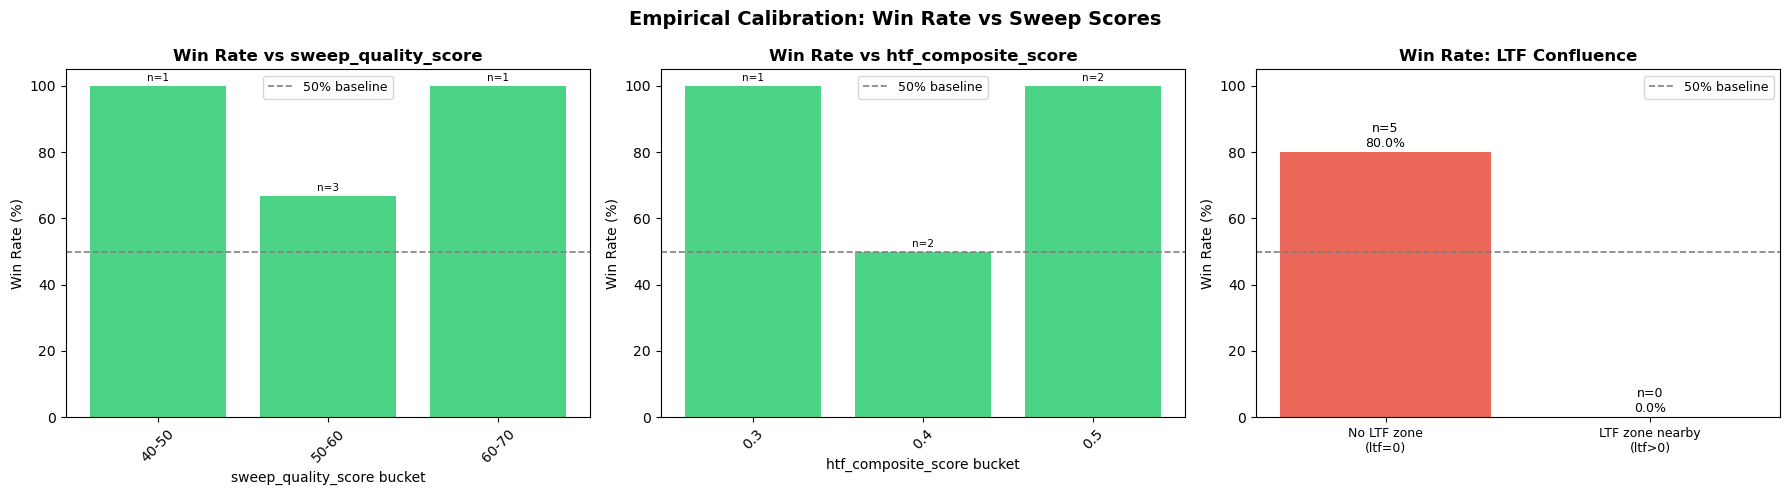

Saved: outputs/sweeps_analysis/calibration_no_midas.png

────────────────────────────────────────────────────────────
STEP 5: EMPIRICAL THRESHOLD RECOMMENDATIONS
────────────────────────────────────────────────────────────

  sweep_quality_score:
    Current gate  : none (all bars pass)
    Optimal gate  : >= 0  →  0.0% win rate  (n=0)
    → Step 6: set  MIN_SWEEP_QUALITY = 0

  htf_composite_score:
    Current gate  : MIN_ZONE_CONVICTION = 0.1 (floor only)
    Optimal gate  : >= 0.00  →  0.0% win rate  (n=0)
    → Step 6: set  MIN_ZONE_CONVICTION = 0.00
────────────────────────────────────────────────────────────
ROLLING WALK-FORWARD PIPELINE SUMMARY
  Hourly bars scanned            : 6577
  Walk-forward steps             : 934 days
  HTF identify_zones() calls     : ~311 (every 3 steps)
  update_zone_lifecycle() calls  : 934 (every step)
  LTF identify_zones() calls     : 0 (disabled)
  LTF confluence scoring         : OFF
  Sweeps no MIDAS                : 6
  Sweeps with MIDAS     

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 8  MAIN EXECUTION  ROLLING WALK-FORWARD  DAILY STEPPING
#
# Cadence:
#   identify_liquidity_zones()  — STRUCTURE: only when new pivot may exist
#                                 (every HTF_PIVOT_WINDOW steps)
#   update_zone_lifecycle()     — LIFECYCLE: every step on cached zones
#   identify_liquidity_zones()  — LTF: every step only when IDENTIFY_LTF_ZONES=True
#   identify_sweeps_in_zones()  — every step, verbose=False
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 80)
print('RUNNING ROLLING WALK-FORWARD PIPELINE')
print('=' * 80)

# ── 1. Safety check ──────────────────────────────────────────────────────────
required_globals = [
    'reload_daily', 'reload_hourly',
    'HTF_PIVOT_WINDOW', 'LTF_PIVOT_WINDOW',
    'VOL_ROLL_WINDOW', 'VOL_SPIKE_THRESHOLD',
    'identify_liquidity_zones', 'update_zone_lifecycle',
    'evaluate_zone_state', 'identify_sweeps_in_zones',
    'classify_zone_type_func', 'rank_zones_by_conviction',
    'detect_previous_day_levels', 'detect_previous_week_levels',
]
missing = [g for g in required_globals if g not in globals()]
if missing:
    raise RuntimeError(f"Missing: {missing}. Run Parts 1–6 first.")

# ── 2. Prepare base data ─────────────────────────────────────────────────────
df_daily  = reload_daily.copy()
df_daily.columns  = [c.lower() for c in df_daily.columns]
df_hourly = reload_hourly.copy()
df_hourly.columns = [c.lower() for c in df_hourly.columns]

VOL_ALIASES = ('tick_volume', 'real_volume', 'vol', 'qty', 'quantity')
for df, name in [(df_daily, 'daily'), (df_hourly, 'hourly')]:
    if 'volume' not in df.columns:
        for alias in VOL_ALIASES:
            if alias in df.columns:
                df.rename(columns={alias: 'volume'}, inplace=True)
                print(f"  Info: {name} renamed '{alias}' → 'volume'")
                break
        else:
            print(f"  Warning: no volume column in {name} — vol filters disabled.")

for col in ('open', 'high', 'low', 'close'):
    if col not in df_hourly.columns:
        raise KeyError(f"Required column '{col}' not found in hourly data.")

# ── 3. Build full hourly candle metrics once ─────────────────────────────────
print("Step 3  Building hourly candle metrics …")
hourly_data = df_hourly.copy()
hourly_data['timestamp'] = pd.to_datetime(hourly_data.index).tz_localize(None)

hourly_data['body']        = (hourly_data['close'] - hourly_data['open']).abs()
hourly_data['total_range'] = hourly_data['high'] - hourly_data['low']
hourly_data['wick_ratio']  = (
    hourly_data['total_range'] / hourly_data['body'].replace(0, 1)
)

vol_roll = hourly_data['volume'].rolling(VOL_ROLL_WINDOW, min_periods=5)
vol_mean = vol_roll.mean()
vol_std  = vol_roll.std()
hourly_data['volume_zscore'] = (
    (hourly_data['volume'] - vol_mean) / (vol_std + 1e-9)
).fillna(0)
hourly_data['volume_spike'] = (
    hourly_data['volume'] > vol_mean + VOL_SPIKE_THRESHOLD * vol_std
).astype(int)

atr_hourly = atr(hourly_data, length=14)
vol_ratio  = hourly_data['volume'] / vol_mean.replace(0, np.nan)
body_norm  = hourly_data['body'] / atr_hourly.replace(0, np.nan).clip(lower=0.01)
hourly_data['absorption_score'] = (
    (vol_ratio * body_norm).replace(0, np.nan).fillna(0).clip(lower=0)
)
hourly_data['date'] = hourly_data['timestamp'].dt.normalize()

print(f"  hourly_data shape    : {hourly_data.shape}")
print(f"  volume_zscore range  : {hourly_data['volume_zscore'].min():.2f} – "
      f"{hourly_data['volume_zscore'].max():.2f}")
print(f"  absorption_score max : {hourly_data['absorption_score'].max():.2f}")
print(f"  volume_spike count   : {hourly_data['volume_spike'].sum()} bars flagged")

# ── 4. Column normalisation helper ───────────────────────────────────────────
def normalise_zone_cols(df):
    return df.rename(columns={
        'FirstTime': 'first_time', 'LastTime': 'last_time',
        'ZoneId':    'zone_id',    'ZoneSide': 'zone_side',
        'ZoneType':  'zone_type',
    })

# ── 5. Walk-forward setup ─────────────────────────────────────────────────────
print('=' * 80)
print('ROLLING WALK-FORWARD  Daily Stepping')
print('=' * 80)

MIN_WARMUP_BARS = HTF_PIVOT_WINDOW * 2
daily_dates     = df_daily.index[df_daily.index > df_daily.index[MIN_WARMUP_BARS]]
total_days      = len(daily_dates)

all_sweeps_no_midas   = []
all_sweeps_with_midas = []

# ── HTF zone structure cache ──────────────────────────────────────────────────
_cached_zones_raw    = None
_cached_enriched_raw = None
_last_rebuild_step   = -(HTF_PIVOT_WINDOW + 1)   # force rebuild on step 0

print(f"  Walk-forward from          : {daily_dates[0].date()}")
print(f"  Walk-forward to            : {daily_dates[-1].date()}")
print(f"  Steps                      : {total_days} daily")
print(f"  Warm-up bars               : {MIN_WARMUP_BARS}")
print(f"  HTF zone structure rebuild : every {HTF_PIVOT_WINDOW} steps")
print(f"  Zone lifecycle update      : every step")
print(f"  LTF zone identification    : {'every step' if IDENTIFY_LTF_ZONES else 'DISABLED'}")
print(f"  LTF confluence scoring     : {'ON' if USE_LTF_CONFLUENCE else 'OFF'}")

for step, cutoff_date in enumerate(daily_dates):

    # ── a. Daily slice — no look-ahead ───────────────────────────────────────
    daily_slice = df_daily[df_daily.index < cutoff_date]
    if len(daily_slice) < MIN_WARMUP_BARS:
        continue

    cutoff_ts = pd.Timestamp(cutoff_date.date())
    day_mask  = hourly_data['date'] == cutoff_ts
    if not day_mask.any():
        continue

    # ── b. HTF zone STRUCTURE — rebuild only when new pivot may exist ─────────
    needs_rebuild = (
        _cached_zones_raw is None
        or (step - _last_rebuild_step) >= HTF_PIVOT_WINDOW
    )

    if needs_rebuild:
        try:
            daily_lvl  = detect_previous_day_levels(daily_slice)
            weekly_lvl = detect_previous_week_levels(daily_slice)

            _, zones_raw, enriched_raw, _, _ = identify_liquidity_zones(
                daily_slice,
                pivot_left_right         = HTF_PIVOT_WINDOW,
                dynamic_pivot_window     = USE_DYNAMIC_PIVOT_WINDOW,
                atr_len                  = 14,
                atr_merge_mult           = 0.75,
                require_volume           = True,
                vol_len                  = 20,
                vol_mult                 = HTF_VOL_MULT,
                min_touches              = HTF_MIN_TOUCHES,
                unique_pivots            = False,
                use_both_high_low_pivots = True,
                min_absorption           = HTF_ABSORPTION_SCORE,
                max_merge_gap_days       = HTF_LOOKBACK_DAYS,
                vol_profile_bin          = VOL_PROFILE_BIN_PCT,
                midas_df                 = (midas_df
                                            if (USE_MIDAS and 'midas_df' in globals())
                                            else None),
                midas_confirm_pct        = MIDAS_CONFIRM_PCT,
            )

            if zones_raw is None or zones_raw.empty:
                _last_rebuild_step = step
            else:
                zones_raw = classify_zone_type_func(zones_raw, daily_lvl, weekly_lvl)
                zones_raw = rank_zones_by_conviction(zones_raw)
                zones_raw = normalise_zone_cols(zones_raw)

                if enriched_raw is not None and not enriched_raw.empty:
                    enriched_raw = classify_zone_type_func(enriched_raw, daily_lvl, weekly_lvl)
                    enriched_raw = rank_zones_by_conviction(enriched_raw)
                    enriched_raw = normalise_zone_cols(enriched_raw)

                _cached_zones_raw    = zones_raw
                _cached_enriched_raw = enriched_raw
                _last_rebuild_step   = step

        except Exception as e:
            print(f"  [{cutoff_date.date()}]  Zone detection failed: {e}")
            continue

    if _cached_zones_raw is None or _cached_zones_raw.empty:
        continue

    # ── c. Zone LIFECYCLE — update every step ────────────────────────────────
    zones_today = update_zone_lifecycle(
        _cached_zones_raw,
        cutoff_ts,
        hourly_data,
        lookback_days       = HTF_LOOKBACK_DAYS,
        invalidation_buffer = 0.2,
    )
    if zones_today is None or zones_today.empty:
        continue

    zones_today_enriched = None
    if _cached_enriched_raw is not None and not _cached_enriched_raw.empty:
        zones_today_enriched = update_zone_lifecycle(
            _cached_enriched_raw,
            cutoff_ts,
            hourly_data,
            lookback_days       = HTF_LOOKBACK_DAYS,
            invalidation_buffer = 0.2,
        )

    # ── d. LTF zones — only when enabled ─────────────────────────────────────
    zones_df_ltf = pd.DataFrame()   # always empty when IDENTIFY_LTF_ZONES=False

    if IDENTIFY_LTF_ZONES:
        ltf_start_ts     = cutoff_ts - pd.Timedelta(days=LTF_LOOKBACK_DAYS)
        hourly_slice_ltf = hourly_data.loc[
            (hourly_data.index >= ltf_start_ts) &
            (hourly_data.index <= cutoff_ts)
        ].copy()

        if len(hourly_slice_ltf) >= LTF_DYN_PIVOT_BASE * 2 + 5:
            try:
                _, ltf_raw, _, _, _ = identify_liquidity_zones(
                    hourly_slice_ltf,
                    pivot_left_right     = LTF_DYN_PIVOT_BASE,
                    atr_len              = 14,
                    atr_merge_mult       = 1.0,
                    dynamic_pivot_window = USE_DYNAMIC_PIVOT_WINDOW,
                    require_volume       = True,
                    vol_len              = VOL_ROLL_WINDOW,
                    vol_mult             = LTF_VOL_MULT,
                    min_absorption       = 0.0,
                    max_merge_gap_days   = LTF_LOOKBACK_DAYS,
                    midas_df             = None,
                    midas_confirm_pct    = 50,
                )
                if ltf_raw is not None and not ltf_raw.empty:
                    ltf_raw      = classify_zone_type_func(ltf_raw)
                    zones_df_ltf = normalise_zone_cols(ltf_raw)
            except Exception:
                zones_df_ltf = pd.DataFrame()

    # ── e. Sweep detection — no MIDAS ────────────────────────────────────────
    try:
        sweeps_nm = identify_sweeps_in_zones(
            zones_today,
            hourly_data,
            midas_mode          = False,
            ltf_zones_df        = zones_df_ltf if USE_LTF_CONFLUENCE else None,
            use_ltf_confluence  = USE_LTF_CONFLUENCE,
            verbose             = False,
            cutoff_date         = cutoff_date,
        )
        if not sweeps_nm.empty and 'timestamp' in sweeps_nm.columns:
            sweep_dates_nm = (
                pd.to_datetime(sweeps_nm['timestamp'])
                .dt.tz_localize(None).dt.normalize()
            )
            sweeps_nm = sweeps_nm[sweep_dates_nm == cutoff_ts].copy()
            if not sweeps_nm.empty:
                sweeps_nm['cutoff_date'] = cutoff_date.date()
                all_sweeps_no_midas.append(sweeps_nm)
    except Exception as e:
        print(f"  [{cutoff_date.date()}]  Sweep no-MIDAS failed: {e}")

    # ── f. Sweep detection — with MIDAS ──────────────────────────────────────
    if zones_today_enriched is not None and not zones_today_enriched.empty:
        try:
            sweeps_wm = identify_sweeps_in_zones(
                zones_today_enriched,
                hourly_data,
                midas_mode          = True,
                ltf_zones_df        = zones_df_ltf if USE_LTF_CONFLUENCE else None,
                use_ltf_confluence  = USE_LTF_CONFLUENCE,
                verbose             = False,
                cutoff_date         = cutoff_date,
            )
            if not sweeps_wm.empty and 'timestamp' in sweeps_wm.columns:
                sweep_dates_wm = (
                    pd.to_datetime(sweeps_wm['timestamp'])
                    .dt.tz_localize(None).dt.normalize()
                )
                sweeps_wm = sweeps_wm[sweep_dates_wm == cutoff_ts].copy()
                if not sweeps_wm.empty:
                    sweeps_wm['cutoff_date'] = cutoff_date.date()
                    all_sweeps_with_midas.append(sweeps_wm)
        except Exception as e:
            print(f"  [{cutoff_date.date()}]  Sweep MIDAS failed: {e}")

    # ── Progress print every 50 steps ────────────────────────────────────────
    if (step + 1) % 50 == 0:
        nm_total = sum(len(s) for s in all_sweeps_no_midas)
        wm_total = sum(len(s) for s in all_sweeps_with_midas)
        rebuilt  = 'YES' if needs_rebuild else 'cached'
        print(
            f"  [{cutoff_date.date()}]  step {step + 1:4d}/{total_days}"
            f"  zones={len(zones_today)}"
            f"  ltf_zones={len(zones_df_ltf)}"
            f"  sweeps_nm={nm_total}"
            f"  sweeps_wm={wm_total}"
            f"  structure={rebuilt}"
        )

# ── 6. Consolidate and deduplicate ───────────────────────────────────────────
print("Step 6  Consolidating results …")

sweeps_hourly_no_midas = (
    pd.concat(all_sweeps_no_midas, ignore_index=True)
    if all_sweeps_no_midas else pd.DataFrame()
)
sweeps_hourly_with_midas = (
    pd.concat(all_sweeps_with_midas, ignore_index=True)
    if all_sweeps_with_midas else pd.DataFrame()
)

for label, dfs in [('No MIDAS',   sweeps_hourly_no_midas),
                   ('With MIDAS', sweeps_hourly_with_midas)]:
    if not dfs.empty:
        before = len(dfs)
        dfs.drop_duplicates(
            subset=['timestamp', 'zone_level', 'sweep_type'], inplace=True
        )
        dfs.sort_values('timestamp', inplace=True)
        dfs.reset_index(drop=True, inplace=True)
        print(f"  {label}: {before} raw → {len(dfs)} deduplicated")

# ── 7. Label outcomes ─────────────────────────────────────────────────────────
print("Step 7  Labelling Sweep Outcomes …")

if len(sweeps_hourly_no_midas) > 0:
    sweeps_hourly_no_midas = label_sweep_outcomes(
        sweeps_hourly_no_midas, hourly_data,
        forward_window_days=5, min_move_pct=0.5,
    )
    if 'outcome' in sweeps_hourly_no_midas.columns:
        oc  = sweeps_hourly_no_midas['outcome'].value_counts()
        lab = sweeps_hourly_no_midas[sweeps_hourly_no_midas['outcome'] != 'TIMEOUT']
        wr  = lab['outcome'].eq('WIN').mean() * 100 if len(lab) > 0 else 0
        print(f"  No MIDAS   {oc.to_dict()}  win rate {wr:.1f}%")

if len(sweeps_hourly_with_midas) > 0:
    sweeps_hourly_with_midas = label_sweep_outcomes(
        sweeps_hourly_with_midas, hourly_data,
        forward_window_days=5, min_move_pct=0.5,
    )
    if 'outcome' in sweeps_hourly_with_midas.columns:
        oc  = sweeps_hourly_with_midas['outcome'].value_counts()
        lab = sweeps_hourly_with_midas[sweeps_hourly_with_midas['outcome'] != 'TIMEOUT']
        wr  = lab['outcome'].eq('WIN').mean() * 100 if len(lab) > 0 else 0
        print(f"  With MIDAS {oc.to_dict()}  win rate {wr:.1f}%")

# ── 8. Calibration plots ──────────────────────────────────────────────────────
print("Step 8  Calibration plots …")
if len(sweeps_hourly_no_midas) > 0 and 'outcome' in sweeps_hourly_no_midas.columns:
    plot_win_rate_calibration(
        sweeps_hourly_no_midas,
        save_path='outputs/sweeps_analysis/calibration_no_midas.png',
    )
if len(sweeps_hourly_with_midas) > 0 and 'outcome' in sweeps_hourly_with_midas.columns:
    plot_win_rate_calibration(
        sweeps_hourly_with_midas,
        save_path='outputs/sweeps_analysis/calibration_with_midas.png',
    )

# ── 9. Summary ────────────────────────────────────────────────────────────────
htf_rebuilds = total_days // HTF_PIVOT_WINDOW
print('=' * 80)
print('ROLLING WALK-FORWARD PIPELINE SUMMARY')
print('=' * 80)
print(f"  Hourly bars scanned            : {len(hourly_data)}")
print(f"  Walk-forward steps             : {total_days} days")
print(f"  HTF identify_zones() calls     : ~{htf_rebuilds} "
      f"(every {HTF_PIVOT_WINDOW} steps)")
print(f"  update_zone_lifecycle() calls  : {total_days} (every step)")
print(f"  LTF identify_zones() calls     : "
      f"{total_days if IDENTIFY_LTF_ZONES else 0} "
      f"({'every step' if IDENTIFY_LTF_ZONES else 'disabled'})")
print(f"  LTF confluence scoring         : {'ON' if USE_LTF_CONFLUENCE else 'OFF'}")
print(f"  Sweeps no MIDAS                : {len(sweeps_hourly_no_midas)}")
print(f"  Sweeps with MIDAS              : {len(sweeps_hourly_with_midas)}")
print(f"  USE_ZONE_SIDE_ROUTING          : {USE_ZONE_SIDE_ROUTING}")
print(f"  USE_SWEEP_COOLDOWN             : {USE_SWEEP_COOLDOWN}")
print(f"  MIN_ZONE_CONVICTION            : {MIN_ZONE_CONVICTION}")
print('=' * 80)
print('ROLLING WALK-FORWARD PIPELINE COMPLETE')
print('=' * 80)

In [56]:
'''# ─────────────────────────────────────────────────────────────────────────────
# PART 8  MAIN EXECUTION  ROLLING WALK-FORWARD  DAILY STEPPING
#   (simulating real-time data flow and zone lifecycle)
#   identify_liquidity_zones()  — STRUCTURE: only when a new pivot can exist
#                                 i.e. every HTF_PIVOT_WINDOW steps
#                                 (a pivot needs HTF_PIVOT_WINDOW bars on both
#                                  sides to confirm — no new pivot is possible
#                                  until that many new bars have been added)
#   update_zone_lifecycle()     — LIFECYCLE: every step on cached zones
#                                 (decay, zone_state, touch_count, phase all
#                                  advance correctly even without a rebuild —
#                                  no conflict with zone merging/decay because
#                                  merging only happens inside identify_liquidity_zones
#                                  and decay is recomputed from first_time vs
#                                  cutoff_ts fresh each step)
#   identify_liquidity_zones()  — LTF: every step (fresh hourly slice)
#   identify_sweeps_in_zones()  — every step, verbose=False
#   Progress print              — every 50 steps with date + running totals
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 80)
print('RUNNING ROLLING WALK-FORWARD PIPELINE')
print('=' * 80)

# ── 1. Safety check ──────────────────────────────────────────────────────────
required_globals = [
    'reload_daily', 'reload_hourly',
    'HTF_PIVOT_WINDOW', 'LTF_PIVOT_WINDOW',
    'VOL_ROLL_WINDOW', 'VOL_SPIKE_THRESHOLD',
    'identify_liquidity_zones', 'update_zone_lifecycle',
    'evaluate_zone_state', 'identify_sweeps_in_zones',
    'classify_zone_type_func', 'rank_zones_by_conviction',
    'detect_previous_day_levels', 'detect_previous_week_levels',
]
missing = [g for g in required_globals if g not in globals()]
if missing:
    raise RuntimeError(f"Missing: {missing}. Run Parts 1–6 first.")

# ── 2. Prepare base data ─────────────────────────────────────────────────────
df_daily  = reload_daily.copy()
df_daily.columns  = [c.lower() for c in df_daily.columns]
df_hourly = reload_hourly.copy()
df_hourly.columns = [c.lower() for c in df_hourly.columns]

VOL_ALIASES = ('tick_volume', 'real_volume', 'vol', 'qty', 'quantity')
for df, name in [(df_daily, 'daily'), (df_hourly, 'hourly')]:
    if 'volume' not in df.columns:
        for alias in VOL_ALIASES:
            if alias in df.columns:
                df.rename(columns={alias: 'volume'}, inplace=True)
                print(f"  Info: {name} renamed '{alias}' → 'volume'")
                break
        else:
            print(f"  Warning: no volume column in {name} — vol filters disabled.")

for col in ('open', 'high', 'low', 'close'):
    if col not in df_hourly.columns:
        raise KeyError(f"Required column '{col}' not found in hourly data.")

# ── 3. Build full hourly candle metrics once (no look-ahead) ─────────────────
print("Step 3  Building hourly candle metrics …")
hourly_data = df_hourly.copy()
hourly_data['timestamp'] = pd.to_datetime(hourly_data.index).tz_localize(None)

hourly_data['body']        = (hourly_data['close'] - hourly_data['open']).abs()
hourly_data['total_range'] = hourly_data['high'] - hourly_data['low']
hourly_data['wick_ratio']  = (
    hourly_data['total_range'] / hourly_data['body'].replace(0, 1)
)

vol_roll = hourly_data['volume'].rolling(VOL_ROLL_WINDOW, min_periods=5)
vol_mean = vol_roll.mean()
vol_std  = vol_roll.std()
hourly_data['volume_zscore'] = (
    (hourly_data['volume'] - vol_mean) / (vol_std + 1e-9)
).fillna(0)
hourly_data['volume_spike'] = (
    hourly_data['volume'] > vol_mean + VOL_SPIKE_THRESHOLD * vol_std
).astype(int)

atr_hourly = atr(hourly_data, length=14)
vol_ratio  = hourly_data['volume'] / vol_mean.replace(0, np.nan)
body_norm  = hourly_data['body'] / atr_hourly.replace(0, np.nan).clip(lower=0.01)
hourly_data['absorption_score'] = (
    (vol_ratio * body_norm).replace(0, np.nan).fillna(0).clip(lower=0)
)

print(f"  hourly_data shape    : {hourly_data.shape}")
print(f"  volume_zscore range  : {hourly_data['volume_zscore'].min():.2f} – "
      f"{hourly_data['volume_zscore'].max():.2f}")
print(f"  absorption_score max : {hourly_data['absorption_score'].max():.2f}")
print(f"  volume_spike count   : {hourly_data['volume_spike'].sum()} bars flagged")

hourly_data['date'] = hourly_data['timestamp'].dt.normalize()

# ── 4. Column normalisation helper ───────────────────────────────────────────
def normalise_zone_cols(df):
    return df.rename(columns={
        'FirstTime': 'first_time', 'LastTime': 'last_time',
        'ZoneId':    'zone_id',    'ZoneSide': 'zone_side',
        'ZoneType':  'zone_type',
    })

# ── 5. Rolling walk-forward loop ─────────────────────────────────────────────
print('=' * 80)
print('ROLLING WALK-FORWARD  Daily Stepping')
print('=' * 80)

MIN_WARMUP_BARS = HTF_PIVOT_WINDOW * 2

daily_dates = df_daily.index[df_daily.index > df_daily.index[MIN_WARMUP_BARS]]
total_days  = len(daily_dates)

all_sweeps_no_midas   = []
all_sweeps_with_midas = []
sweep_count_nm = 0
sweep_count_wm = 0

# ── Zone structure cache ──────────────────────────────────────────────────────
# Only reset when a new pivot can exist (every HTF_PIVOT_WINDOW steps).
# update_zone_lifecycle() keeps decay / state current on non-rebuild days —
# no conflict with zone merging because merging is internal to
# identify_liquidity_zones() and the cache is fully replaced on each rebuild.
_cached_zones_raw    = None   # classify + rank + normalise HTF zones
_cached_enriched_raw = None   # MIDAS-enriched version
_last_rebuild_step   = -(HTF_PIVOT_WINDOW + 1)   # force rebuild on step 0

print(f"  Walk-forward from          : {daily_dates[0].date()}")
print(f"  Walk-forward to            : {daily_dates[-1].date()}")
print(f"  Cutoff steps               : {total_days} daily")
print(f"  Warm-up bars               : {MIN_WARMUP_BARS}")
print(f"  Identifying HTF zones : every {HTF_PIVOT_WINDOW} steps "
      f"(new pivot confirmation cadence)")
print(f"  Updating zone lifecycle : every step on cached zones")
print(f"  Identifying LTF zones      : every step (fresh hourly slice)")

for step, cutoff_date in enumerate(daily_dates):

    # ── a. Daily slice: strictly historical, no look-ahead ───────────────────
    daily_slice = df_daily[df_daily.index < cutoff_date]
    if len(daily_slice) < MIN_WARMUP_BARS:
        continue

    # ── b. Single-day output window ──────────────────────────────────────────
    cutoff_ts = pd.Timestamp(cutoff_date.date())
    day_mask  = hourly_data['date'] == cutoff_ts
    if not day_mask.any():
        continue   # holiday / weekend — no hourly bars

    # ── c. HTF zone STRUCTURE — rebuild only when new pivot may exist ─────────
    #
    # A pivot at bar i is confirmed only after HTF_PIVOT_WINDOW bars to the
    # right have been observed. Adding 1 daily bar per step means the earliest
    # a newly formed pivot can become confirmed is HTF_PIVOT_WINDOW steps later.
    # Rebuilding more often than this is redundant — the structure cannot change.
    #
    needs_rebuild = (
        _cached_zones_raw is None
        or (step - _last_rebuild_step) >= HTF_PIVOT_WINDOW
    )

    if needs_rebuild:
        try:
            daily_lvl  = detect_previous_day_levels(daily_slice)
            weekly_lvl = detect_previous_week_levels(daily_slice)

            _, zones_raw, enriched_raw, _, _ = identify_liquidity_zones(
                daily_slice,
                pivot_left_right         = HTF_PIVOT_WINDOW,
                dynamic_pivot_window     = USE_DYNAMIC_PIVOT_WINDOW,
                atr_len                  = 14,
                atr_merge_mult           = 0.75,
                require_volume           = True,
                vol_len                  = 20,
                vol_mult                 = HTF_VOL_MULT,
                min_touches              = HTF_MIN_TOUCHES,
                unique_pivots            = False,
                use_both_high_low_pivots = True,
                min_absorption           = HTF_ABSORPTION_SCORE,
                max_merge_gap_days       = HTF_LOOKBACK_DAYS,
                vol_profile_bin          = VOL_PROFILE_BIN_PCT,
                midas_df                 = (midas_df
                                            if (USE_MIDAS and 'midas_df' in globals())
                                            else None),
                midas_confirm_pct        = MIDAS_CONFIRM_PCT,
            )

            if zones_raw is None or zones_raw.empty:
                # No zones found — keep old cache, update step counter to avoid
                # tight retry loop on every step
                _last_rebuild_step = step
            else:
                # Classify → rank → normalise — then cache
                # Cache is fully replaced (not merged) because identify_liquidity_zones
                # with the full growing slice already contains all active zones
                zones_raw = classify_zone_type_func(zones_raw, daily_lvl, weekly_lvl)
                zones_raw = rank_zones_by_conviction(zones_raw)
                zones_raw = normalise_zone_cols(zones_raw)

                if enriched_raw is not None and not enriched_raw.empty:
                    enriched_raw = classify_zone_type_func(
                        enriched_raw, daily_lvl, weekly_lvl
                    )
                    enriched_raw = rank_zones_by_conviction(enriched_raw)
                    enriched_raw = normalise_zone_cols(enriched_raw)

                _cached_zones_raw    = zones_raw
                _cached_enriched_raw = enriched_raw
                _last_rebuild_step   = step

        except Exception as e:
            print(f"  [{cutoff_date.date()}]  Zone detection failed: {e}")
            continue

    if _cached_zones_raw is None or _cached_zones_raw.empty:
        continue

    # ── d. Zone LIFECYCLE — update every step on cached zones ─────────────────
    #
    # identify_liquidity_zones() sees only daily bars — it cannot compute
    # zone_state, touch_count, sweep_count, or zone_lifecycle_phase at hourly
    # resolution. update_zone_lifecycle() fills all of these using hourly bars
    # up to cutoff_ts by calling evaluate_zone_state() per zone.
    #
    # Decay advances correctly on non-rebuild days because update_zone_lifecycle()
    # computes days_old = (cutoff_ts − first_time) fresh each step, not from the
    # cached zone values. No conflict with the Zone.calculate_decay() already run
    # inside identify_liquidity_zones() — this simply refreshes it to today's date.
    zones_today = update_zone_lifecycle(
        _cached_zones_raw,
        cutoff_ts,
        hourly_data,
        lookback_days       = HTF_LOOKBACK_DAYS,
        invalidation_buffer = 0.2,
    )
    if zones_today is None or zones_today.empty:
        continue

    zones_today_enriched = None
    if _cached_enriched_raw is not None and not _cached_enriched_raw.empty:
        zones_today_enriched = update_zone_lifecycle(
            _cached_enriched_raw,
            cutoff_ts,
            hourly_data,
            lookback_days       = HTF_LOOKBACK_DAYS,
            invalidation_buffer = 0.2,
        )

    # ── e. LTF zones — rebuild every step (fresh hourly slice) ───────────────
    zones_df_ltf     = pd.DataFrame()
    ltf_start_ts     = cutoff_ts - pd.Timedelta(days=LTF_LOOKBACK_DAYS)
    hourly_slice_ltf = hourly_data.loc[
        (hourly_data.index >= ltf_start_ts) &
        (hourly_data.index <= cutoff_ts)
    ].copy()

    if len(hourly_slice_ltf) >= LTF_DYN_PIVOT_BASE * 2 + 5:
        try:
            _, ltf_raw, _, _, _ = identify_liquidity_zones(
                hourly_slice_ltf,
                pivot_left_right     = LTF_DYN_PIVOT_BASE,
                atr_len              = 14,
                atr_merge_mult       = 1.0,
                dynamic_pivot_window = USE_DYNAMIC_PIVOT_WINDOW,
                require_volume       = True,
                vol_len              = VOL_ROLL_WINDOW,
                vol_mult             = LTF_VOL_MULT,
                min_absorption       = 0.0,
                max_merge_gap_days   = LTF_LOOKBACK_DAYS,
                midas_df             = None,
                midas_confirm_pct    = 50,
            )
            if ltf_raw is not None and not ltf_raw.empty:
                ltf_raw      = classify_zone_type_func(ltf_raw)
                zones_df_ltf = normalise_zone_cols(ltf_raw)
        except Exception:
            zones_df_ltf = pd.DataFrame()

    # ── f. Sweep detection — no MIDAS ────────────────────────────────────────
    try:
        sweeps_nm = identify_sweeps_in_zones(
            zones_today,
            hourly_data,
            midas_mode   = False,
            ltf_zones_df = zones_df_ltf,
            verbose      = False,        # suppress per-call print
            cutoff_date  = cutoff_date,  # available in verbose output if needed
        )
        if not sweeps_nm.empty and 'timestamp' in sweeps_nm.columns:
            sweep_dates_nm = (
                pd.to_datetime(sweeps_nm['timestamp'])
                .dt.tz_localize(None).dt.normalize()
            )
            sweeps_nm = sweeps_nm[sweep_dates_nm == cutoff_ts].copy()
            if not sweeps_nm.empty:
                sweeps_nm['cutoff_date'] = cutoff_date.date()
                all_sweeps_no_midas.append(sweeps_nm)
                sweep_count_nm += len(sweeps_nm)
    except Exception as e:
        print(f"  [{cutoff_date.date()}]  Sweep no-MIDAS failed: {e}")

    # ── g. Sweep detection — with MIDAS ──────────────────────────────────────
    if zones_today_enriched is not None and not zones_today_enriched.empty:
        try:
            sweeps_wm = identify_sweeps_in_zones(
                zones_today_enriched,
                hourly_data,
                midas_mode   = True,
                ltf_zones_df = zones_df_ltf,
                verbose      = False,
                cutoff_date  = cutoff_date,
            )
            if not sweeps_wm.empty and 'timestamp' in sweeps_wm.columns:
                sweep_dates_wm = (
                    pd.to_datetime(sweeps_wm['timestamp'])
                    .dt.tz_localize(None).dt.normalize()
                )
                sweeps_wm = sweeps_wm[sweep_dates_wm == cutoff_ts].copy()
                if not sweeps_wm.empty:
                    sweeps_wm['cutoff_date'] = cutoff_date.date()
                    all_sweeps_with_midas.append(sweeps_wm)
                    sweep_count_wm += len(sweeps_wm)
        except Exception as e:
            print(f"  [{cutoff_date.date()}]  Sweep MIDAS failed: {e}")

    # ── Progress print every 50 steps — date + running totals ────────────────
    if (step + 1) % 50 == 0:
        nm_total = sum(len(s) for s in all_sweeps_no_midas)
        wm_total = sum(len(s) for s in all_sweeps_with_midas)
        rebuilt  = 'YES' if needs_rebuild else 'cached'
        print(
            f"  [{cutoff_date.date()}]  step {step + 1:4d}/{total_days}"
            f"  zones={len(zones_today)}"
            f"  ltf_zones={len(zones_df_ltf)}"
            f"  sweeps_nm={nm_total}"
            f"  sweeps_wm={wm_total}"
            f"  structure={rebuilt}"
        )

# ── 6. Consolidate and deduplicate ───────────────────────────────────────────
print("Step 6  Consolidating results …")

sweeps_hourly_no_midas = (
    pd.concat(all_sweeps_no_midas, ignore_index=True)
    if all_sweeps_no_midas else pd.DataFrame()
)
sweeps_hourly_with_midas = (
    pd.concat(all_sweeps_with_midas, ignore_index=True)
    if all_sweeps_with_midas else pd.DataFrame()
)

for label, dfs in [('No MIDAS',   sweeps_hourly_no_midas),
                   ('With MIDAS', sweeps_hourly_with_midas)]:
    if not dfs.empty:
        before = len(dfs)
        dfs.drop_duplicates(
            subset=['timestamp', 'zone_level', 'sweep_type'], inplace=True
        )
        dfs.sort_values('timestamp', inplace=True)
        dfs.reset_index(drop=True, inplace=True)
        print(f"  {label}: {before} raw → {len(dfs)} deduplicated")

sweeps_hourly_no_midas   = sweeps_hourly_no_midas
sweeps_hourly_with_midas = sweeps_hourly_with_midas

# ── 7. Label outcomes ─────────────────────────────────────────────────────────
print("Step 7  Labelling Sweep Outcomes …")

if len(sweeps_hourly_no_midas) > 0:
    sweeps_hourly_no_midas = label_sweep_outcomes(
        sweeps_hourly_no_midas, hourly_data,
        forward_window_days=5, min_move_pct=0.5,
    )
    if 'outcome' in sweeps_hourly_no_midas.columns:
        oc  = sweeps_hourly_no_midas['outcome'].value_counts()
        lab = sweeps_hourly_no_midas[sweeps_hourly_no_midas['outcome'] != 'TIMEOUT']
        wr  = lab['outcome'].eq('WIN').mean() * 100 if len(lab) > 0 else 0
        print(f"  No MIDAS  {oc.to_dict()}  win rate {wr:.1f}%")

if len(sweeps_hourly_with_midas) > 0:
    sweeps_hourly_with_midas = label_sweep_outcomes(
        sweeps_hourly_with_midas, hourly_data,
        forward_window_days=5, min_move_pct=0.5,
    )
    if 'outcome' in sweeps_hourly_with_midas.columns:
        oc  = sweeps_hourly_with_midas['outcome'].value_counts()
        lab = sweeps_hourly_with_midas[sweeps_hourly_with_midas['outcome'] != 'TIMEOUT']
        wr  = lab['outcome'].eq('WIN').mean() * 100 if len(lab) > 0 else 0
        print(f"  With MIDAS {oc.to_dict()}  win rate {wr:.1f}%")

# ── 8. Calibration plots ──────────────────────────────────────────────────────
print("Step 8  Calibration plots …")
if len(sweeps_hourly_no_midas) > 0 and 'outcome' in sweeps_hourly_no_midas.columns:
    plot_win_rate_calibration(
        sweeps_hourly_no_midas,
        save_path='outputs/sweeps_analysis/calibration_no_midas.png',
    )
if len(sweeps_hourly_with_midas) > 0 and 'outcome' in sweeps_hourly_with_midas.columns:
    plot_win_rate_calibration(
        sweeps_hourly_with_midas,
        save_path='outputs/sweeps_analysis/calibration_with_midas.png',
    )

# ── 9. Summary ────────────────────────────────────────────────────────────────
htf_rebuilds = total_days // HTF_PIVOT_WINDOW
print('=' * 80)
print('ROLLING WALK-FORWARD PIPELINE SUMMARY')
print('=' * 80)
print(f"  Hourly bars scanned             : {len(hourly_data)}")
print(f"  Walk-forward steps              : {total_days} days")
print(f"  HTF identify_liquidity_zones()  : ~{htf_rebuilds} rebuilds "
      f"(every {HTF_PIVOT_WINDOW} steps, saved ~{total_days - htf_rebuilds} calls)")
print(f"  update_zone_lifecycle()         : {total_days} calls (every step)")
print(f"  LTF identify_liquidity_zones()  : {total_days} calls (every step)")
print(f"  Sweeps no MIDAS                 : {len(sweeps_hourly_no_midas)}")
print(f"  Sweeps with MIDAS               : {len(sweeps_hourly_with_midas)}")
print(f"  USE_ZONE_SIDE_ROUTING           : {USE_ZONE_SIDE_ROUTING}")
print(f"  USE_SWEEP_COOLDOWN              : {USE_SWEEP_COOLDOWN}")
print(f"  MIN_ZONE_CONVICTION             : {MIN_ZONE_CONVICTION}  (floor only)")

if len(sweeps_hourly_no_midas) == 0 and len(sweeps_hourly_with_midas) == 0:
    print("\n  Debug checklist:")
    print("    1. Set SWEEP_REQUIRE_TREND_FILTER=False, PIN_BAR_MIN_WICK_PCT=0.0")
    print("    2. Set USE_SWEEP_FORWARD_CONFIRM=False")
    print("    3. Check zones_today['zone_side'].value_counts() for 'neutral' dominance")
    print(f"    4. hourly_data range: {hourly_data['timestamp'].min()} – "
          f"{hourly_data['timestamp'].max()}")

print('=' * 80)
print('ROLLING WALK-FORWARD PIPELINE COMPLETE')
print('=' * 80)'''

'# ─────────────────────────────────────────────────────────────────────────────\n# PART 8  MAIN EXECUTION  ROLLING WALK-FORWARD  DAILY STEPPING\n#   (simulating real-time data flow and zone lifecycle)\n#   identify_liquidity_zones()  — STRUCTURE: only when a new pivot can exist\n#                                 i.e. every HTF_PIVOT_WINDOW steps\n#                                 (a pivot needs HTF_PIVOT_WINDOW bars on both\n#                                  sides to confirm — no new pivot is possible\n#                                  until that many new bars have been added)\n#   update_zone_lifecycle()     — LIFECYCLE: every step on cached zones\n#                                 (decay, zone_state, touch_count, phase all\n#                                  advance correctly even without a rebuild —\n#                                  no conflict with zone merging/decay because\n#                                  merging only happens inside identify_liquidity_zones\n#            

In [57]:
'''# ===========================================================================
# PART 8: MAIN EXECUTION PIPELINE – ROLLING WALK-FORWARD (DAILY STEPPING)
# ===========================================================================
print("\n" + "=" * 80)
print("RUNNING ROLLING WALK-FORWARD PIPELINE")
print("=" * 80)

# ---------------------------------------------------------------------------
# 1. SAFETY CHECK
# ---------------------------------------------------------------------------
required_globals = ['reload_daily', 'reload_hourly', 'HTF_PIVOT_WINDOW',
                    'LTF_PIVOT_WINDOW', 'VOL_ROLL_WINDOW', 'VOL_SPIKE_THRESHOLD']
missing = [g for g in required_globals if g not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}. Run Parts 1–6 first.")

# ---------------------------------------------------------------------------
# 2. PREPARE BASE DATA
# ---------------------------------------------------------------------------
df_daily = reload_daily.copy()
df_daily.columns = [c.lower() for c in df_daily.columns]

_VOL_ALIASES = ["tick_volume", "real_volume", "vol", "qty", "quantity"]
if "volume" not in df_daily.columns:
    for alias in _VOL_ALIASES:
        if alias in df_daily.columns:
            df_daily = df_daily.rename(columns={alias: "volume"})
            print(f"[Info] (Daily) Renamed '{alias}' -> 'volume'")
            break
    else:
        print("[Warning] No volume column in daily data — volume filters disabled.")

df_hourly = reload_hourly.copy()
df_hourly.columns = [c.lower() for c in df_hourly.columns]
if "volume" not in df_hourly.columns:
    for alias in _VOL_ALIASES:
        if alias in df_hourly.columns:
            df_hourly = df_hourly.rename(columns={alias: "volume"})
            print(f"[Info] (Hourly) Renamed '{alias}' -> 'volume'")
            break
    else:
        print("[Warning] No volume column in hourly data — volume filters disabled.")

for col in ["open", "high", "low", "close"]:
    if col not in df_hourly.columns:
        raise KeyError(f"Required column '{col}' not found in hourly data.")

# ---------------------------------------------------------------------------
# 3. BUILD FULL HOURLY CANDLE METRICS (once — no look-ahead in per-bar stats)
# ---------------------------------------------------------------------------
print("\n=== Step 3: Building hourly candle metrics ===")
hourly_data              = df_hourly.copy()
hourly_data['timestamp'] = pd.to_datetime(hourly_data.index).tz_localize(None)  # always tz-naive

hourly_data['body']        = (hourly_data['close'] - hourly_data['open']).abs()
hourly_data['total_range'] = hourly_data['high'] - hourly_data['low']
hourly_data['wick_ratio']  = hourly_data['total_range'] / hourly_data['body'].replace(0, 1)

vol_roll = hourly_data['volume'].rolling(VOL_ROLL_WINDOW, min_periods=5)
vol_mean = vol_roll.mean()
vol_std  = vol_roll.std()
hourly_data['volume_zscore'] = ((hourly_data['volume'] - vol_mean) / (vol_std + 1e-9)).fillna(0)
hourly_data['volume_spike']  = (hourly_data['volume'] > vol_mean + VOL_SPIKE_THRESHOLD * vol_std).astype(int)

atr_hourly                      = atr(hourly_data, length=14)
vol_ratio                       = hourly_data['volume'] / vol_mean.replace(0, np.nan)
body_norm                       = hourly_data['body'] / atr_hourly.replace(0, np.nan).clip(lower=0.01)
hourly_data['absorption_score'] = (vol_ratio / body_norm.replace(0, np.nan)).fillna(0).clip(lower=0)

print(f"  hourly_data shape      : {hourly_data.shape}")
print(f"  volume_zscore range    : [{hourly_data['volume_zscore'].min():.2f}, {hourly_data['volume_zscore'].max():.2f}]")
print(f"  absorption_score range : [{hourly_data['absorption_score'].min():.2f}, {hourly_data['absorption_score'].max():.2f}]")
print(f"  volume_spike count     : {hourly_data['volume_spike'].sum()} bars flagged")
print(f"  USE_SWEEP_VOL_FILTER   : {USE_SWEEP_VOL_FILTER}")

# tz-naive _date for safe daily comparisons inside loop
hourly_data['_date'] = hourly_data['timestamp'].dt.normalize()

# ---------------------------------------------------------------------------
# 4. COLUMN NORMALISATION HELPER
# ---------------------------------------------------------------------------
def normalise_zone_cols(df):
    return df.rename(columns={
        'first_time' : 'firsttime',
        'last_time'  : 'lasttime',
        'zone_id'    : 'zoneid',
        'zone_side'  : 'zoneside',
        'zone_type'  : 'zonetype',
    })

# ---------------------------------------------------------------------------
# 5. ROLLING WALK-FORWARD LOOP — DAILY STEPPING
#    At each cutoff_date (every trading day):
#      (a) Zones identified from daily data UP TO cutoff     → no look-ahead
#      (b) identifysweepsinzones receives full hourly_data   → full context window
#      (c) Output filtered to sweeps ON cutoff_date only     → strict daily boundary
# ---------------------------------------------------------------------------
print("\n" + "=" * 80)
print("ROLLING WALK-FORWARD: Daily Stepping")
print("=" * 80)

MIN_WARMUP_BARS = HTF_PIVOT_WINDOW * 2 + 20

# CHANGE 1: every trading day, not just Mondays
daily_dates = df_daily.index[df_daily.index >= df_daily.index[MIN_WARMUP_BARS]]

all_sweeps_no_midas   = []
all_sweeps_with_midas = []
total_days            = len(daily_dates)
sweep_count_nm        = 0
sweep_count_wm        = 0

print(f"  Walk-forward from  : {daily_dates[0].date()}")
print(f"  Walk-forward to    : {daily_dates[-1].date()}")
print(f"  Cutoff steps       : {total_days} (daily)")
print(f"  Warm-up bars       : {MIN_WARMUP_BARS}\n")

for step, cutoff_date in enumerate(daily_dates):

    # ── (a) Daily slice: strictly historical at cutoff ─────────────────────
    daily_slice = df_daily[df_daily.index <= cutoff_date]
    if len(daily_slice) < MIN_WARMUP_BARS:
        continue

    # ── (b) CHANGE 2: single-day output window instead of full week ────────
    cutoff_ts   = pd.Timestamp(cutoff_date.date())
    week_end_ts = cutoff_ts                          # same day — strict daily boundary
    day_mask    = (hourly_data['_date'] == cutoff_ts)

    if not day_mask.any():
        continue   # no hourly bars on this date (holiday/weekend) — skip

    # ── (c) Zone detection on past-only daily data ─────────────────────────
    try:
        _, htf_zones, htf_zones_enriched, _, _ = identify_liquidity_zones(
            daily_slice,
            pivot_left_right         = HTF_PIVOT_WINDOW,
            dynamic_pivot_window     = USE_DYNAMIC_PIVOT_WINDOW,
            atr_len                  = 14,
            atr_merge_mult           = 0.75,
            require_volume           = True,
            vol_len                  = 20,
            vol_mult                 = HTF_VOL_MULT,
            min_touches              = HTF_MIN_TOUCHES,
            unique_pivots            = False,
            use_both_high_low_pivots = True,
            min_absorption           = HTF_ABSORPTION_SCORE,
            max_merge_gap_days       = HTF_LOOKBACK_DAYS,
            vol_profile_bin          = VOL_PROFILE_BIN_PCT,
            midas_df                 = midas_df if ('USE_MIDAS' in globals() and USE_MIDAS
                                                    and 'midas_df' in globals()) else None,
            midas_confirm_pct        = MIDAS_CONFIRM_PCT,
        )
    except Exception as e:
        print(f"  [Step {step}] Zone detection failed at {cutoff_date.date()}: {e}")
        continue

    if htf_zones is None or htf_zones.empty:
        continue

    # Classify, rank, normalise column names
    daily_lvl  = detect_previous_day_levels(daily_slice)
    weekly_lvl = detect_previous_week_levels(daily_slice)

    htf_zones = classify_zone_type_func(htf_zones, daily_lvl, weekly_lvl)
    htf_zones = rank_zones_by_conviction(htf_zones)
    htf_zones = normalise_zone_cols(htf_zones)

    if htf_zones_enriched is not None and not htf_zones_enriched.empty:
        htf_zones_enriched = classify_zone_type_func(htf_zones_enriched, daily_lvl, weekly_lvl)
        htf_zones_enriched = rank_zones_by_conviction(htf_zones_enriched)
        htf_zones_enriched = normalise_zone_cols(htf_zones_enriched)

    # ── (d) Sweep detection — full hourly_data for context window ──────────
    #    Output filtered to cutoff_date only → strict daily walk-forward boundary

    # NO MIDAS
    try:
        sweeps_nm = identifysweepsinzones(
            htf_zones,
            hourly_data,
            midasmode=False,
        )
        if not sweeps_nm.empty and 'timestamp' in sweeps_nm.columns:
            sweep_dates_nm = pd.to_datetime(sweeps_nm['timestamp']).dt.tz_localize(None).dt.normalize()
            sweeps_nm = sweeps_nm[sweep_dates_nm == cutoff_ts].copy()  # single day filter
        if not sweeps_nm.empty:
            sweeps_nm['cutoff_date'] = cutoff_date.date()
            all_sweeps_no_midas.append(sweeps_nm)
            sweep_count_nm += len(sweeps_nm)
    except Exception as e:
        print(f"  [Step {step}] Sweep (no MIDAS) failed at {cutoff_date.date()}: {e}")

    # WITH MIDAS
    if htf_zones_enriched is not None and not htf_zones_enriched.empty:
        try:
            sweeps_wm = identifysweepsinzones(
                htf_zones_enriched,
                hourly_data,
                midasmode=True,
            )
            if not sweeps_wm.empty and 'timestamp' in sweeps_wm.columns:
                sweep_dates_wm = pd.to_datetime(sweeps_wm['timestamp']).dt.tz_localize(None).dt.normalize()
                sweeps_wm = sweeps_wm[sweep_dates_wm == cutoff_ts].copy()  # single day filter
            if not sweeps_wm.empty:
                sweeps_wm['cutoff_date'] = cutoff_date.date()
                all_sweeps_with_midas.append(sweeps_wm)
                sweep_count_wm += len(sweeps_wm)
        except Exception as e:
            print(f"  [Step {step}] Sweep (MIDAS) failed at {cutoff_date.date()}: {e}")

    # Progress every 50 days (~1 quarter) — monitor and kill early if needed
    if (step + 1) % 50 == 0:
        print(f"  [{step+1:4d}/{total_days}] {cutoff_date.date()} "
              f"| no_midas={sweep_count_nm} with_midas={sweep_count_wm}")

# ---------------------------------------------------------------------------
# 6. CONSOLIDATE + DEDUPLICATE
# ---------------------------------------------------------------------------
print("\n=== Step 6: Consolidating results ===")

sweeps_hourly_no_midas = (
    pd.concat(all_sweeps_no_midas).reset_index(drop=True)
    if all_sweeps_no_midas else pd.DataFrame()
)
sweeps_hourly_with_midas = (
    pd.concat(all_sweeps_with_midas).reset_index(drop=True)
    if all_sweeps_with_midas else pd.DataFrame()
)

# Deduplicate: same sweep possibly detected on consecutive daily cutoffs
if not sweeps_hourly_no_midas.empty:
    before = len(sweeps_hourly_no_midas)
    sweeps_hourly_no_midas = (
        sweeps_hourly_no_midas
        .drop_duplicates(subset=['timestamp', 'zone_level', 'sweep_type'])
        .sort_values('timestamp')
        .reset_index(drop=True)
    )
    print(f"  No MIDAS  : {before} raw → {len(sweeps_hourly_no_midas)} deduplicated")

if not sweeps_hourly_with_midas.empty:
    before = len(sweeps_hourly_with_midas)
    sweeps_hourly_with_midas = (
        sweeps_hourly_with_midas
        .drop_duplicates(subset=['timestamp', 'zone_level', 'sweep_type'])
        .sort_values('timestamp')
        .reset_index(drop=True)
    )
    print(f"  With MIDAS: {before} raw → {len(sweeps_hourly_with_midas)} deduplicated")

# ---------------------------------------------------------------------------
# 7. LABEL OUTCOMES
# ---------------------------------------------------------------------------
print("\n=== Step 7: Labelling Sweep Outcomes ===")

if len(sweeps_hourly_no_midas) > 0:
    sweeps_hourly_no_midas = label_sweep_outcomes(
        sweeps_hourly_no_midas, hourly_data,
        forward_window_days=5, min_move_pct=0.5
    )
    if 'outcome' in sweeps_hourly_no_midas.columns:
        oc = sweeps_hourly_no_midas['outcome'].value_counts()
        labeled = sweeps_hourly_no_midas[sweeps_hourly_no_midas['outcome'] != 'TIMEOUT']
        wr = (labeled['outcome'] == 'WIN').mean() * 100 if len(labeled) > 0 else 0
        print(f"  No MIDAS  : {oc.to_dict()} | win rate = {wr:.1f}%")

if len(sweeps_hourly_with_midas) > 0:
    sweeps_hourly_with_midas = label_sweep_outcomes(
        sweeps_hourly_with_midas, hourly_data,
        forward_window_days=5, min_move_pct=0.5
    )
    if 'outcome' in sweeps_hourly_with_midas.columns:
        oc = sweeps_hourly_with_midas['outcome'].value_counts()
        labeled = sweeps_hourly_with_midas[sweeps_hourly_with_midas['outcome'] != 'TIMEOUT']
        wr = (labeled['outcome'] == 'WIN').mean() * 100 if len(labeled) > 0 else 0
        print(f"  With MIDAS: {oc.to_dict()} | win rate = {wr:.1f}%")

# ---------------------------------------------------------------------------
# 8. SUMMARY
# ---------------------------------------------------------------------------
print("\n" + "=" * 80)
print("ROLLING WALK-FORWARD PIPELINE SUMMARY")
print("=" * 80)
print(f"  Hourly bars scanned             : {len(hourly_data)}")
print(f"  Walk-forward steps              : {total_days} days")
print(f"  Sweeps detected (no MIDAS)      : {len(sweeps_hourly_no_midas)}")
print(f"  Sweeps detected (with MIDAS)    : {len(sweeps_hourly_with_midas)}")
print(f"  Vol filter active               : {USE_SWEEP_VOL_FILTER}")

if len(sweeps_hourly_no_midas) == 0 and len(sweeps_hourly_with_midas) == 0:
    print("\n  [Debug Checklist]")
    print("  □ Set SWEEP_REQUIRE_TREND_FILTER=False and PIN_BAR_MIN_WICK_PCT=0.0")
    print("  □ Set USE_SWEEP_VOL_FILTER=False")
    print("  □ Check htf_zones['zoneside'].value_counts() for neutral dominance")
    print("  □ Verify hourly bars exist on cutoff dates (day_mask.any() check)")
    print(f"  □ hourly_data range: {hourly_data['timestamp'].min()} → {hourly_data['timestamp'].max()}")

print("\n" + "=" * 80)
print("✓ ROLLING WALK-FORWARD PIPELINE COMPLETE")
print("=" * 80)'''

'# ===========================================================================\n# PART 8: MAIN EXECUTION PIPELINE – ROLLING WALK-FORWARD (DAILY STEPPING)\n# ===========================================================================\nprint("\n" + "=" * 80)\nprint("RUNNING ROLLING WALK-FORWARD PIPELINE")\nprint("=" * 80)\n\n# ---------------------------------------------------------------------------\n# 1. SAFETY CHECK\n# ---------------------------------------------------------------------------\nrequired_globals = [\'reload_daily\', \'reload_hourly\', \'HTF_PIVOT_WINDOW\',\n                    \'LTF_PIVOT_WINDOW\', \'VOL_ROLL_WINDOW\', \'VOL_SPIKE_THRESHOLD\']\nmissing = [g for g in required_globals if g not in globals()]\nif missing:\n    raise RuntimeError(f"Missing required variables: {missing}. Run Parts 1–6 first.")\n\n# ---------------------------------------------------------------------------\n# 2. PREPARE BASE DATA\n# ----------------------------------------------------------

In [58]:
# ---------------------------------------------------------------------------
# SWEEP DETECTION CANDLESTICK VISUALIZATIONS WITH LIQUIDITY ZONES
# ---------------------------------------------------------------------------
# ---------------------------------------------------------------------------
# SAFETY CHECK - Ensure Part 8 has executed
# ---------------------------------------------------------------------------
required_vars = ['sweeps_hourly_no_midas', 'sweeps_hourly_with_midas', 'hourly_data']
missing_vars = [v for v in required_vars if v not in globals()]

if missing_vars:
    print(f"\n⚠ WARNING: Missing variables - {missing_vars}")
    print("Please execute Part 8 (Main Execution) cell first to generate sweeps and hourly_data.")
    print("Skipping visualization...")
else:
    print("\n✓ All required variables present. Proceeding with visualization...")

# Only run visualization if all variables are present
if not missing_vars:

    print("\n" + "=" * 70)
    print("VISUALIZING TOP SWEEPS - CANDLESTICK CHARTS WITH LIQUIDITY ZONES")
    print("=" * 70)

    import plotly.graph_objects as go

    # Use existing hourly_data from earlier analysis
    price_data = hourly_data.copy()
    print(f"\n✓ Analysing hourly data: {len(price_data)} candles")
    print(f"  Date range: {price_data['timestamp'].min().date()} to {price_data['timestamp'].max().date()}")

    # Debug: Check sweeps
    print(f"\nSweep data check:")
    print(f"  NO MIDAS: {len(sweeps_hourly_no_midas)} total sweeps")
    if len(sweeps_hourly_no_midas) > 0:
        print(f"    - Bullish: {(sweeps_hourly_no_midas['sweep_type']=='BULLISH').sum()}")
        print(f"    - Bearish: {(sweeps_hourly_no_midas['sweep_type']=='BEARISH').sum()}")
    
    print(f"  WITH MIDAS: {len(sweeps_hourly_with_midas)} total sweeps")
    if len(sweeps_hourly_with_midas) > 0:
        print(f"    - Bullish: {(sweeps_hourly_with_midas['sweep_type']=='BULLISH').sum()}")
        print(f"    - Bearish: {(sweeps_hourly_with_midas['sweep_type']=='BEARISH').sum()}")

    # Candlestick plotting function with liquidity zones
    def make_candlestick_chart_with_zones(price_df, sweep_timestamp, zone_level, sweep_type, chart_title):
        """
        Create candlestick chart with liquidity zone shading
        Uses arrow/marker notation for sweep detection point
        Plots candles continuously without time gaps
        """
        try:
            # Find closest candle to sweep time
            price_df_copy = price_df.copy()
            price_df_copy['ts_str'] = price_df_copy['timestamp'].astype(str).str[:10]
            sweep_ts_str = pd.to_datetime(sweep_timestamp).strftime('%Y-%m-%d')
        
            matching = price_df_copy[price_df_copy['ts_str'] == sweep_ts_str]
            if len(matching) == 0:
                return None
        
            sweep_idx = matching.index[0]
        
            # Get context: 15 before, 10 after
            # Convert index to position within price_df
            sweep_pos = price_df.index.get_loc(sweep_idx)
        
            # Get context: 15 before, 10 after
            start_pos = max(0, sweep_pos - 15)
            end_pos = min(len(price_df) - 1, sweep_pos + 10)
        
        
            subset = price_df.iloc[start_pos:end_pos+1].copy()
            
            # Create sequential index for continuous plotting (no time gaps)
            subset = subset.reset_index(drop=True)
            subset['candle_idx'] = range(len(subset))
            timestamp_labels = subset['timestamp'].dt.strftime('%Y-%m-%d %H:%M').values
        
            # Create figure with larger size using sequential x-axis
            fig = go.Figure(data=[go.Candlestick(
                x=subset['candle_idx'],
                open=subset['open'],
                high=subset['high'],
                low=subset['low'],
                close=subset['close'],
                name='TSLA Price',
                customdata=timestamp_labels,
                hovertemplate='<b>%{customdata}</b><br>Open: $%{open:.2f}<br>High: $%{high:.2f}<br>Low: $%{low:.2f}<br>Close: $%{close:.2f}<extra></extra>'
            )])
        
            # Add liquidity zone as shaded region
            if sweep_type == 'BULLISH':
                # Buy-side liquidity zone (support)
                fig.add_hrect(
                    y0=zone_level * 0.99,
                    y1=zone_level * 1.01,
                    fillcolor='green',
                    opacity=0.12,
                    layer='below',
                    line_width=0
                )
                zone_color = 'green'
                zone_label = 'BUY-SIDE LIQUIDITY'
            else:
                # Sell-side liquidity zone (resistance)
                fig.add_hrect(
                    y0=zone_level * 0.99,
                    y1=zone_level * 1.01,
                    fillcolor='red',
                    opacity=0.12,
                    layer='below',
                    line_width=0
                )
                zone_color = 'red'
                zone_label = 'SELL-SIDE LIQUIDITY'
        
            # Add zone level line with label
            fig.add_hline(
                y=zone_level,
                line_width=2.5,
                line_dash='dash',
                line_color=zone_color,
                annotation_text=f'{zone_label}<br>${zone_level:.2f}',
                annotation_position='right',
                annotation=dict(font_size=11, bgcolor='rgba(255,255,255,0.8)')
            )
        
            # Add sweep detection point with arrow marker
            sweep_subset_pos = sweep_pos - start_pos
            sweep_x = subset.iloc[sweep_subset_pos]['candle_idx']
            sweep_candle_high = subset.iloc[sweep_subset_pos]['high']
            sweep_candle_low = subset.iloc[sweep_subset_pos]['low']
        
            # Position arrow: buy-side above, sell-side below the candle
            candle_range = sweep_candle_high - sweep_candle_low
            if sweep_type == 'BULLISH':
                # Buy-side: star above the candle
                arrow_y = sweep_candle_high + candle_range * 0.5
                arrow_symbol = '★'
            else:
                # Sell-side: star below the candle
                arrow_y = sweep_candle_low - candle_range * 0.5
                arrow_symbol = '★'
        
            fig.add_annotation(
                x=sweep_x,
                y=arrow_y,
                text=arrow_symbol,
                showarrow=False,
                font=dict(size=28, color='purple'),
                xanchor='center'
            )
        
            fig.update_layout(
                title=dict(text=chart_title, font=dict(size=14)),
                yaxis_title='Price (USD)',
                xaxis_title='Candle Index (Continuous - No Time Gaps)',
                template='plotly_white',
                height=550,
                width=1150,
                hovermode='x unified',
                xaxis_rangeslider_visible=False,
                xaxis=dict(type='linear'),
                showlegend=True,
                font=dict(size=11),
                margin=dict(l=80, r=100, t=100, b=80)
            )
        
            return fig
        
        except Exception as e:
            print(f"      ✗ Error: {e}")
            return None

    # =========================================================================
    # PLOT NO MIDAS SWEEPS WITH LIQUIDITY ZONES
    # =========================================================================
    if len(sweeps_hourly_no_midas) > 0:
        print("\n" + "=" * 70)
        print("NO MIDAS SWEEPS WITH LIQUIDITY ZONES")
        print("=" * 70)
    
        # Get top 3 of each type
        bull_nm = sweeps_hourly_no_midas[sweeps_hourly_no_midas['sweep_type']=='BULLISH'].nlargest(3, 'sweep_quality_score')
        bear_nm = sweeps_hourly_no_midas[sweeps_hourly_no_midas['sweep_type']=='BEARISH'].nlargest(3, 'sweep_quality_score')
    
        print(f"\nBUYING SWEEPS - Targeting Buy-Side Liquidity ({len(bull_nm)}):")
        for i, (idx, row) in enumerate(bull_nm.iterrows(), 1):
            title = f"BULLISH SWEEP #{i} (NO MIDAS) | Quality: {row['sweep_quality_score']:.0f}/100 | Reversal: ${row['reversal_distance']:.2f}"
            print(f"  {i}. {row['timestamp']} - Buy-Side Zone: ${row['zone_level']:.2f}")
            fig = make_candlestick_chart_with_zones(price_data, row['timestamp'], row['zone_level'], 'BULLISH', title)
            if fig:
                fig.show()
            else:
                print(f"      → Could not create chart")
    
        print(f"\nSELLING SWEEPS - Targeting Sell-Side Liquidity ({len(bear_nm)}):")
        for i, (idx, row) in enumerate(bear_nm.iterrows(), 1):
            title = f"BEARISH SWEEP #{i} (NO MIDAS) | Quality: {row['sweep_quality_score']:.0f}/100 | Reversal: ${row['reversal_distance']:.2f}"
            print(f"  {i}. {row['timestamp']} - Sell-Side Zone: ${row['zone_level']:.2f}")
            fig = make_candlestick_chart_with_zones(price_data, row['timestamp'], row['zone_level'], 'BEARISH', title)
            if fig:
                fig.show()
            else:
                print(f"      → Could not create chart")
    else:
        print("\n✗ No sweeps in NO MIDAS dataset")

    # =========================================================================
    # PLOT WITH MIDAS SWEEPS WITH LIQUIDITY ZONES
    # =========================================================================
    if len(sweeps_hourly_with_midas) > 0:
        print("\n" + "=" * 70)
        print("WITH MIDAS SWEEPS WITH LIQUIDITY ZONES")
        print("=" * 70)
    
        # Get top 3 of each type
        bull_wm = sweeps_hourly_with_midas[sweeps_hourly_with_midas['sweep_type']=='BULLISH'].nlargest(3, 'sweep_quality_score')
        bear_wm = sweeps_hourly_with_midas[sweeps_hourly_with_midas['sweep_type']=='BEARISH'].nlargest(3, 'sweep_quality_score')
    
        print(f"\nBUYING SWEEPS - Targeting Buy-Side Liquidity ({len(bull_wm)}):")
        for i, (idx, row) in enumerate(bull_wm.iterrows(), 1):
            title = f"BULLISH SWEEP #{i} (WITH MIDAS) | Quality: {row['sweep_quality_score']:.0f}/100 | Reversal: ${row['reversal_distance']:.2f}"
            print(f"  {i}. {row['timestamp']} - Buy-Side Zone: ${row['zone_level']:.2f}")
            fig = make_candlestick_chart_with_zones(price_data, row['timestamp'], row['zone_level'], 'BULLISH', title)
            if fig:
                fig.show()
            else:
                print(f"      → Could not create chart")
    
        print(f"\nSELLING SWEEPS - Targeting Sell-Side Liquidity ({len(bear_wm)}):")
        for i, (idx, row) in enumerate(bear_wm.iterrows(), 1):
            title = f"BEARISH SWEEP #{i} (WITH MIDAS) | Quality: {row['sweep_quality_score']:.0f}/100 | Reversal: ${row['reversal_distance']:.2f}"
            print(f"  {i}. {row['timestamp']} - Sell-Side Zone: ${row['zone_level']:.2f}")
            fig = make_candlestick_chart_with_zones(price_data, row['timestamp'], row['zone_level'], 'BEARISH', title)
            if fig:
                fig.show()
            else:
                print(f"      → Could not create chart")
    else:
        print("\n✗ No sweeps in WITH MIDAS dataset")

    print("\n" + "=" * 70)
    print("✓ LIQUIDITY ZONE SWEEP VISUALIZATION COMPLETE")
    print("=" * 70)
    print("\nVISUAL LEGEND:")
    print("  🟢 GREEN SHADED ZONE: Buy-Side Liquidity (Support)")
    print("  🔴 RED SHADED ZONE: Sell-Side Liquidity (Resistance)")
    print("  ★ Star: Sweep Detection Point")
    print("  - - DASHED LINE: Liquidity Zone Level")


✓ All required variables present. Proceeding with visualization...

VISUALIZING TOP SWEEPS - CANDLESTICK CHARTS WITH LIQUIDITY ZONES

✓ Analysing hourly data: 6577 candles
  Date range: 2021-01-04 to 2024-09-30

Sweep data check:
  NO MIDAS: 6 total sweeps
    - Bullish: 2
    - Bearish: 4
  WITH MIDAS: 0 total sweeps

NO MIDAS SWEEPS WITH LIQUIDITY ZONES

BUYING SWEEPS - Targeting Buy-Side Liquidity (2):
  1. 2023-01-11 09:30:00 - Buy-Side Zone: $122.95


  2. 2024-02-28 09:30:00 - Buy-Side Zone: $202.06



SELLING SWEEPS - Targeting Sell-Side Liquidity (3):
  1. 2021-10-07 14:30:00 - Sell-Side Zone: $267.40


  2. 2022-11-01 09:30:00 - Sell-Side Zone: $232.09


  3. 2022-10-27 09:30:00 - Sell-Side Zone: $232.09



✗ No sweeps in WITH MIDAS dataset

✓ LIQUIDITY ZONE SWEEP VISUALIZATION COMPLETE

VISUAL LEGEND:
  🟢 GREEN SHADED ZONE: Buy-Side Liquidity (Support)
  🔴 RED SHADED ZONE: Sell-Side Liquidity (Resistance)
  ★ Star: Sweep Detection Point
  - - DASHED LINE: Liquidity Zone Level


In [59]:
# ---------------------------------------------------------------------------
# Visualization
# ---------------------------------------------------------------------------
def plot_zones_matplotlib(
    df: pd.DataFrame,
    zones_df: pd.DataFrame,
    start_date: str = None,
    end_date: str = None,
    title: str = "Zones",
    save_dir: str = ".",
):
    import matplotlib.pyplot as plt

    if df.empty:
        return

    tail = df.loc[start_date:end_date] if (start_date and end_date) else df.tail(250)
    if tail.empty:
        print("No data in the specified date range.")
        return

    x = np.arange(len(tail))
    dates = tail.index
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.fill_between(x, tail["low"].values, tail["high"].values, color="lightblue", alpha=0.25, label="High-Low range")
    ax.plot(x, tail["close"].values, label="Close", color="black", linewidth=1)

    if "pivot_high_level" in tail.columns:
        ph_mask = ~tail["pivot_high_level"].isna()
        ax.scatter(x[ph_mask], tail["pivot_high_level"].values[ph_mask], marker="v", color="red", s=30, zorder=5, label="Pivot High")
    if "pivot_low_level" in tail.columns:
        pl_mask = ~tail["pivot_low_level"].isna()
        ax.scatter(x[pl_mask], tail["pivot_low_level"].values[pl_mask], marker="^", color="green", s=30, zorder=5, label="Pivot Low")

    if zones_df is not None and not zones_df.empty:
        for _, z in zones_df.iterrows():
            mask = (dates >= z["first_time"]) & (dates <= z["last_time"])
            x_zone = x[mask]
            if len(x_zone) == 0:
                continue
            ax.fill_between(x_zone, z["bottom"], z["top"], color="orange", alpha=0.35, label=f"Zone {z['zone_id']}")

    ax.set_title(title)
    ax.set_xticks(x[::max(1, len(x) // 10)])
    ax.set_xticklabels([d.strftime("%Y-%m-%d") for d in dates[::max(1, len(x) // 10)]], rotation=45)
    ax.grid(True, alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, labels):
        seen.setdefault(l, h)
    ax.legend(seen.values(), seen.keys(), fontsize=7, loc="upper left",
              bbox_to_anchor=(1.01, 1), borderaxespad=0, frameon=True)

    plt.tight_layout()
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, title.replace(" ", "_").replace("/", "-") + ".png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Chart saved to {save_path}")
    plt.show()


In [60]:
'''# ---------------------------------------------------------------------------
# Visualize Sample Buy-Side & Sell-Side Liquidity Zones (Plotly)
# ---------------------------------------------------------------------------
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

def plot_zone_sample(df, zone, title_suffix):
    # Determine window: 30 bars before zone start to 30 bars after zone end
    start_time = zone["first_time"]
    end_time = zone["last_time"]
    
    # Get index bounds safely
    mask = (df.index >= start_time - pd.Timedelta(days=30)) & (df.index <= end_time + pd.Timedelta(days=30))
    plot_df = df.loc[mask]
    
    if plot_df.empty:
        print(f"Skipping plot for {zone['zone_id']} - no data in window")
        return
        
    fig = go.Figure(data=[go.Candlestick(
        x=plot_df.index,
        open=plot_df["open"],
        high=plot_df["high"],
        low=plot_df["low"],
        close=plot_df["close"],
        name="Price"
    )])
    
    # Add Zone Rectangle
    fig.add_shape(
        type="rect",
        x0=plot_df.index[0], y0=zone["bottom"] if (zone["top"] - zone["bottom"]) > 2.0 else zone["bottom"] - 1.5,
        x1=plot_df.index[-1], y1=zone["top"] if (zone["top"] - zone["bottom"]) > 2.0 else zone["top"] + 1.5,
        line=dict(color="rgba(0, 255, 0, 0.8)" if zone["zone_side"] == "supply" else "rgba(255, 0, 0, 0.8)", width=2),
        fillcolor="rgba(0, 255, 0, 0.4)" if zone["zone_side"] == "supply" else "rgba(255, 0, 0, 0.4)",
        layer="above"
    )
    
    # Add POC (Point of Control) line if available
    if "zone_poc_price" in zone and pd.notna(zone.get("zone_poc_price")):
        poc_price = float(zone["zone_poc_price"])
        fig.add_hline(
            y=poc_price,
            line_dash="dot",
            line_color="blue",
            line_width=2,
            annotation_text=f"POC: ${poc_price:.2f}",
            annotation_position="right"
        )
    
    # Add Zone Information Text Box
    height = zone["top"] - zone["bottom"]
    poc_str = f" | POC: ${zone.get('zone_poc_price', float('nan')):.2f}" if "zone_poc_price" in zone and pd.notna(zone.get("zone_poc_price")) else ""
    info_text = f"<b>{zone['zone_id']}</b><br>" \
                f"Type: {zone.get('zone_type', 'N/A')} | Side: {zone.get('zone_side', 'N/A')}<br>" \
                f"Top: ${zone['top']:.2f} | Bottom: ${zone['bottom']:.2f} | Height: ${height:.2f}{poc_str}<br>"
    
    fig.add_annotation(
        xref="paper", yref="paper",
        x=0.02, y=0.98,
        text=info_text,
        showarrow=False,
        font=dict(size=10, color="black"),
        bgcolor="rgba(255, 255, 255, 0.8)",
        bordercolor="black",
        borderwidth=1,
        align="left"
    )
    
    fig.update_layout(
        title=f"TSLA - {title_suffix} ({zone['zone_id']})",
        yaxis_title="Price",
        xaxis_rangeslider_visible=False,
        template="plotly_white",
        height=500
    )
    
    fig.show()

if zones_df_daily is not None and not zones_df_daily.empty and "zone_side" in zones_df_daily.columns:
    print("=== Sample Buy-Side Zones (Resistence) ===")
    demand_zones = zones_df_daily[zones_df_daily["zone_side"] == "supply"].sort_values("composite_score", ascending=False)
    for _, z in demand_zones.head(3).iterrows():
        plot_zone_sample(df_z_daily, z, "Buy-Side Zone Sample")
        
    print("=== Sample Sell-Side Zones (Support) ===")
    supply_zones = zones_df_daily[zones_df_daily["zone_side"] == "demand"].sort_values("composite_score", ascending=False)
    for _, z in supply_zones.head(3).iterrows():
        plot_zone_sample(df_z_daily, z, "Sell-Side Zone Sample")
else:
    print("No valid zone classification available to plot samples (Requires Part 5 execution).")'''

'# ---------------------------------------------------------------------------\n# Visualize Sample Buy-Side & Sell-Side Liquidity Zones (Plotly)\n# ---------------------------------------------------------------------------\nimport plotly.graph_objects as go\nfrom plotly.subplots import make_subplots\nimport pandas as pd\n\ndef plot_zone_sample(df, zone, title_suffix):\n    # Determine window: 30 bars before zone start to 30 bars after zone end\n    start_time = zone["first_time"]\n    end_time = zone["last_time"]\n\n    # Get index bounds safely\n    mask = (df.index >= start_time - pd.Timedelta(days=30)) & (df.index <= end_time + pd.Timedelta(days=30))\n    plot_df = df.loc[mask]\n\n    if plot_df.empty:\n        print(f"Skipping plot for {zone[\'zone_id\']} - no data in window")\n        return\n\n    fig = go.Figure(data=[go.Candlestick(\n        x=plot_df.index,\n        open=plot_df["open"],\n        high=plot_df["high"],\n        low=plot_df["low"],\n        close=plot_df["close

## Part 9 - Export Sweeps to CSV & Generate Individual Images for ML Labeling

In [61]:
# ---------------------------------------------------------------------------
# Function to generate sweep detail summary for CSV export
# ---------------------------------------------------------------------------

def prepare_sweep_export_data(sweeps_df, zones_df=None):
    """
    Prepare sweep DataFrame for CSV export with all relevant details.
    
    Adds additional computed fields for reference and ML labeling:
    - Formatted timestamp string
    - Formatted zone level with 2 decimals
    - Sweep ID for file naming and tracking
    - Summary metrics for easy reference
    """
    if sweeps_df.empty:
        print("No sweeps to export")
        return pd.DataFrame()
    
    export_df = sweeps_df.copy()
    
    # Ensure timestamp is datetime
    if not pd.api.types.is_datetime64_any_dtype(export_df['timestamp']):
        export_df['timestamp'] = pd.to_datetime(export_df['timestamp'])
    
    # Create formatted columns for file naming
    export_df['timestamp_str'] = export_df['timestamp'].dt.strftime('%Y%m%d_%H%M')
    export_df['zone_level_str'] = export_df['zone_level'].apply(lambda x: f"{x:.2f}")
    
    # Create unique sweep ID
    export_df['sweep_id'] = (export_df['sweep_idx'].astype(str) + '_' + 
                             export_df['sweep_type'].str[:3] + '_' + 
                             export_df['timestamp_str'] + '_' +
                             export_df['zone_level_str'].replace('.', 'p'))
    
    # Reorder columns for readability
    key_columns = [
        'sweep_id', 'sweep_idx', 'timestamp', 'timestamp_str',
        'sweep_type', 'zone_idx', 'zone_level', 'zone_level_str',
        'sweep_quality_score', 'zone_state_at_sweep'
    ]
    
    other_columns = [col for col in export_df.columns if col not in key_columns]
    
    export_df = export_df[key_columns + other_columns]
    
    return export_df


# Prepare export data
sweeps_export_no_midas = prepare_sweep_export_data(sweeps_hourly_no_midas)
sweeps_export_with_midas = prepare_sweep_export_data(sweeps_hourly_with_midas)

print(f"✓ Prepared {len(sweeps_export_no_midas)} sweeps (NO MIDAS) for export")
print(f"✓ Prepared {len(sweeps_export_with_midas)} sweeps (WITH MIDAS) for export")
print("\nSample export columns:")
print(sweeps_export_no_midas.columns.tolist()[:15])


No sweeps to export
✓ Prepared 6 sweeps (NO MIDAS) for export
✓ Prepared 0 sweeps (WITH MIDAS) for export

Sample export columns:
['sweep_id', 'sweep_idx', 'timestamp', 'timestamp_str', 'sweep_type', 'zone_idx', 'zone_level', 'zone_level_str', 'sweep_quality_score', 'zone_state_at_sweep', 'zone_id', 'zone_top', 'zone_bottom', 'sweep_high', 'reversal_price']


In [62]:
# ---------------------------------------------------------------------------
# Export sweeps to CSV files
# ---------------------------------------------------------------------------

import os
from pathlib import Path

# Create output subdirectories
sweeps_output_dir = Path("outputs/sweeps_analysis")
sweeps_output_dir.mkdir(parents=True, exist_ok=True)

sweeps_no_midas_dir = sweeps_output_dir / "no_midas"
sweeps_no_midas_dir.mkdir(parents=True, exist_ok=True)

sweeps_with_midas_dir = sweeps_output_dir / "with_midas"
sweeps_with_midas_dir.mkdir(parents=True, exist_ok=True)

# Export NO MIDAS sweeps to CSV
if not sweeps_export_no_midas.empty:
    csv_path_no_midas = sweeps_output_dir / "TSLA_Sweeps_NO_MIDAS.csv"
    sweeps_export_no_midas.to_csv(csv_path_no_midas, index=False)
    print(f"✓ Exported {len(sweeps_export_no_midas)} sweeps (NO MIDAS) to:")
    print(f"  {csv_path_no_midas}")
else:
    print("⚠ No sweeps (NO MIDAS) to export")

# Export WITH MIDAS sweeps to CSV
if not sweeps_export_with_midas.empty:
    csv_path_with_midas = sweeps_output_dir / "TSLA_Sweeps_WITH_MIDAS.csv"
    sweeps_export_with_midas.to_csv(csv_path_with_midas, index=False)
    print(f"✓ Exported {len(sweeps_export_with_midas)} sweeps (WITH MIDAS) to:")
    print(f"  {csv_path_with_midas}")
else:
    print("⚠ No sweeps (WITH MIDAS) to export")

# Create summary statistics CSV
print("\n" + "="*70)
print("SWEEP EXPORT SUMMARY")
print("="*70)

summary_stats = {
    'Category': ['NO MIDAS', 'WITH MIDAS'],
    'Total Sweeps': [len(sweeps_export_no_midas), len(sweeps_export_with_midas)],
    'Bullish': [
        len(sweeps_export_no_midas[sweeps_export_no_midas['sweep_type'] == 'BULLISH'])
        if not sweeps_export_no_midas.empty else 0,
        len(sweeps_export_with_midas[sweeps_export_with_midas['sweep_type'] == 'BULLISH'])
        if not sweeps_export_with_midas.empty else 0
    ],
    'Bearish': [
        len(sweeps_export_no_midas[sweeps_export_no_midas['sweep_type'] == 'BEARISH'])
        if not sweeps_export_no_midas.empty else 0,
        len(sweeps_export_with_midas[sweeps_export_with_midas['sweep_type'] == 'BEARISH'])
        if not sweeps_export_with_midas.empty else 0
    ],
    'Avg Quality Score': [
        sweeps_export_no_midas['sweep_quality_score'].mean() if not sweeps_export_no_midas.empty else 0,
        sweeps_export_with_midas['sweep_quality_score'].mean() if not sweeps_export_with_midas.empty else 0
    ]
}

summary_df = pd.DataFrame(summary_stats)
summary_csv_path = sweeps_output_dir / "Sweeps_Summary_Statistics.csv"
summary_df.to_csv(summary_csv_path, index=False)

print(summary_df.to_string(index=False))
print(f"\n✓ Summary stats saved to: {summary_csv_path}")


✓ Exported 6 sweeps (NO MIDAS) to:
  outputs/sweeps_analysis/TSLA_Sweeps_NO_MIDAS.csv
⚠ No sweeps (WITH MIDAS) to export

SWEEP EXPORT SUMMARY
  Category  Total Sweeps  Bullish  Bearish  Avg Quality Score
  NO MIDAS             6        2        4          48.064223
WITH MIDAS             0        0        0           0.000000

✓ Summary stats saved to: outputs/sweeps_analysis/Sweeps_Summary_Statistics.csv


In [63]:
# ---------------------------------------------------------------------------
# Function to generate individual sweep charts
# ---------------------------------------------------------------------------

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd


def generate_sweep_chart(sweep_row, price_data, output_path, lookback_bars=50, lookahead_bars=20):
    """
    Generate individual candlestick chart for a sweep with zone overlay.

    Parameters:
    -----------
    sweep_row     : pd.Series  — single row from sweeps DataFrame
    price_data    : pd.DataFrame — full OHLCV price data
    output_path   : Path       — where to save the PNG
    lookback_bars : int        — bars to show before sweep
    lookahead_bars: int        — bars to show after sweep
    """

    sweep_timestamp = sweep_row['timestamp']
    zone_level      = sweep_row['zone_level']
    zone_idx        = sweep_row['zone_idx']
    sweep_type      = sweep_row['sweep_type']
    sweep_quality   = sweep_row['sweep_quality_score']

    # ── 1. Normalise timestamps ──────────────────────────────────────────────
    sweep_timestamp = pd.Timestamp(sweep_timestamp)

    price_data_copy = price_data.copy()
    if not pd.api.types.is_datetime64_any_dtype(price_data_copy['timestamp']):
        price_data_copy['timestamp'] = pd.to_datetime(price_data_copy['timestamp'])

    # ── 2. Locate sweep bar as a positional integer (NOT a label) ────────────
    dt_index      = pd.DatetimeIndex(price_data_copy['timestamp'])
    pos_array     = dt_index.get_indexer([sweep_timestamp], method='nearest')
    sweep_pos_abs = int(pos_array[0])          # absolute integer position in full df

    if sweep_pos_abs < 0:
        print(f"  ⚠ Could not locate {sweep_timestamp} in price data — skipping")
        return False

    # ── 3. Slice window using positional integers ────────────────────────────
    start_pos = max(0, sweep_pos_abs - lookback_bars)
    end_pos   = min(len(price_data_copy), sweep_pos_abs + lookahead_bars + 1)

    window_data = price_data_copy.iloc[start_pos:end_pos].copy()
    window_data['idx'] = range(len(window_data))     # 0-based x-axis coords

    # Relative position of the sweep bar inside the window
    sweep_pos_rel = sweep_pos_abs - start_pos        # integer offset

    # Guard: empty window or sweep out of range
    if window_data.empty or sweep_pos_rel >= len(window_data):
        print(f"  ⚠ Window empty or sweep out of range for {sweep_timestamp} — skipping")
        return False

    # ── 4. Draw figure ───────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 7))

    # Collect real timestamps for x-axis labels
    timestamps_in_window = window_data['timestamp'].tolist()
    n_bars               = len(window_data)

    # ── Candlesticks ─────────────────────────────────────────────────────────
    for x_pos, (_, row) in zip(range(n_bars), window_data.iterrows()):
        open_price  = row['open']
        close_price = row['close']
        high        = row['high']
        low         = row['low']

        color = '#26a69a' if close_price >= open_price else '#ef5350'

        # Wick
        ax.plot([x_pos, x_pos], [low, high], color=color, linewidth=1)

        # Body (ensure doji candles still have minimal visible height)
        body_bottom = min(open_price, close_price)
        body_height = max(abs(close_price - open_price), 0.01)
        rect = Rectangle(
            (x_pos - 0.3, body_bottom), 0.6, body_height,
            facecolor=color, edgecolor=color, linewidth=1
        )
        ax.add_patch(rect)

    # ── Zone rectangle ────────────────────────────────────────────────────────
    zone_top    = zone_level * 1.005
    zone_bottom = zone_level * 0.995
    zone_color  = '#ff9999' if sweep_type == 'BEARISH' else '#99ff99'

    zone_rect = Rectangle(
        (0, zone_bottom),
        n_bars,
        zone_top - zone_bottom,
        facecolor=zone_color, alpha=0.15,
        edgecolor=zone_color, linewidth=2, linestyle='--'
    )
    ax.add_patch(zone_rect)

    # ── Sweep marker at correct bar ───────────────────────────────────────────
    sweep_close = window_data.iloc[sweep_pos_rel]['close']
    ax.plot(sweep_pos_rel, sweep_close, 'r*', markersize=20,
            label='Sweep Point', zorder=5)

    # ── Vertical dashed line at sweep bar ────────────────────────────────────
    ax.axvline(x=sweep_pos_rel, color='red', linestyle='--', alpha=0.4, linewidth=1)

    # ── X-axis: replace integer ticks with real date labels ──────────────────
    tick_positions = np.linspace(0, n_bars - 1, min(8, n_bars), dtype=int)
    tick_labels    = [
        pd.Timestamp(timestamps_in_window[i]).strftime('%m-%d %H:%M')
        for i in tick_positions
    ]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=30, ha='right', fontsize=8)

    # ── Axes limits ───────────────────────────────────────────────────────────
    ax.set_xlim(-1, n_bars)

    all_prices  = window_data[['open', 'high', 'low', 'close']].values.flatten()
    price_range = all_prices.max() - all_prices.min()
    ax.set_ylim(all_prices.min() - 0.1 * price_range,
                all_prices.max() + 0.1 * price_range)

    ax.set_xlabel('Date / Time (UTC)', fontsize=10)
    ax.set_ylabel('Price ($)', fontsize=10)

    # ── Title ─────────────────────────────────────────────────────────────────
    timestamp_str = sweep_timestamp.strftime('%Y-%m-%d %H:%M')
    title = (f"TSLA Sweep [{sweep_type}] | "
             f"Zone Level: ${zone_level:.2f} | "
             f"Quality: {sweep_quality:.1f}/100 | "
             f"Timestamp: {timestamp_str}")
    ax.set_title(title, fontsize=12, fontweight='bold', pad=15)

    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)

    # ── Info box ──────────────────────────────────────────────────────────────
    info_text = (f"Sweep Type: {sweep_type}\n"
                 f"Zone Level: ${zone_level:.2f}\n"
                 f"Quality Score: {sweep_quality:.1f}\n"
                 f"Zone State: {sweep_row.get('zone_state_at_sweep', 'N/A')}\n"
                 f"Zone Touches: {sweep_row.get('zone_touch_count', 'N/A')}")

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.98, 0.97, info_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top', horizontalalignment='right',
            bbox=props, family='monospace')

    # ── Save ──────────────────────────────────────────────────────────────────
    try:
        plt.tight_layout()
        plt.savefig(output_path, dpi=100, bbox_inches='tight')
        plt.close(fig)
        return True
    except Exception as e:
        print(f"  ⚠ Error saving chart: {e}")
        plt.close(fig)
        return False


print("✓ Sweep chart generation function defined: generate_sweep_chart()")


✓ Sweep chart generation function defined: generate_sweep_chart()


In [64]:
# ---------------------------------------------------------------------------
# Generate all sweep charts and organize by category
# ---------------------------------------------------------------------------

import shutil  # ✅ moved here — import once, not inside loop
from pathlib import Path


def generate_all_sweep_charts(sweeps_df, price_data, output_base_dir, dataset_name="sweeps"):
    """
    Generate individual charts for all sweeps and organize them by type.

    Directory structure created:
    output_base_dir/
    ├── all_sweeps/
    ├── bullish_sweeps/
    ├── bearish_sweeps/
    └── high_quality_sweeps/ (score >= 70)
    """

    # ── Guard: empty DataFrame ───────────────────────────────────────────────
    if sweeps_df.empty:
        print(f"[{dataset_name}] No sweeps to generate charts for")
        return {'total': 0, 'bullish': 0, 'bearish': 0, 'high_quality': 0}  # ✅ always return dict

    # ── Build directory structure ────────────────────────────────────────────
    base_dir    = Path(output_base_dir) / dataset_name
    all_dir     = base_dir / "all_sweeps"
    bullish_dir = base_dir / "bullish_sweeps"
    bearish_dir = base_dir / "bearish_sweeps"
    hq_dir      = base_dir / "high_quality_sweeps"

    for d in [all_dir, bullish_dir, bearish_dir, hq_dir]:
        d.mkdir(parents=True, exist_ok=True)

    print(f"\n[{dataset_name}] Generating {len(sweeps_df)} sweep charts...")
    print(f"  Output directory: {base_dir}")

    success_count = 0
    bullish_count = 0
    bearish_count = 0
    hq_count      = 0

    for idx, (_, sweep) in enumerate(sweeps_df.iterrows(), 1):

        # ── Safe sweep_id retrieval ──────────────────────────────────────────
        # pd.Series supports [] and .get() but .get() can be unreliable on
        # numeric-indexed Series — this pattern is safest
        sweep_id      = sweep['sweep_id'] if 'sweep_id' in sweep.index else f"sweep_{idx:04d}"  # ✅ zero-padded for clean sorting
        base_filename = f"{sweep_id}.png"
        chart_path    = all_dir / base_filename

        # ── Generate chart ───────────────────────────────────────────────────
        success = generate_sweep_chart(sweep, price_data, chart_path)

        if success:
            success_count += 1

            # Route to type-specific folder
            if sweep['sweep_type'] == 'BULLISH':
                bullish_count += 1
                shutil.copy(chart_path, bullish_dir / base_filename)  # ✅ shutil already imported
            else:
                bearish_count += 1
                shutil.copy(chart_path, bearish_dir / base_filename)

            # Route to high-quality folder
            if sweep['sweep_quality_score'] >= 70:
                hq_count += 1
                shutil.copy(chart_path, hq_dir / base_filename)

        # ── Progress indicator ───────────────────────────────────────────────
        if idx % 10 == 0:
            print(f"  Progress: {idx}/{len(sweeps_df)} charts generated")

    # ── Summary ──────────────────────────────────────────────────────────────
    print(f"\n[{dataset_name}] Summary:")
    print(f"  ✓ Saved {success_count}/{len(sweeps_df)} charts to: {all_dir}")
    print(f"  ✓ Bullish sweeps:              {bullish_count} → {bullish_dir}")
    print(f"  ✓ Bearish sweeps:              {bearish_count} → {bearish_dir}")
    print(f"  ✓ High-quality (score ≥ 70):   {hq_count}      → {hq_dir}")

    return {
        'total':        success_count,
        'bullish':      bullish_count,
        'bearish':      bearish_count,
        'high_quality': hq_count
    }


# ── Run for NO MIDAS ─────────────────────────────────────────────────────────
print("=" * 70)
print("GENERATING SWEEP CHARTS - NO MIDAS")
print("=" * 70)

stats_no_midas = generate_all_sweep_charts(
    sweeps_export_no_midas,
    hourly_data,
    sweeps_no_midas_dir,
    dataset_name="no_midas"
)

# ── Run for WITH MIDAS ───────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("GENERATING SWEEP CHARTS - WITH MIDAS")
print("=" * 70)

stats_with_midas = generate_all_sweep_charts(
    sweeps_export_with_midas,
    hourly_data,
    sweeps_with_midas_dir,
    dataset_name="with_midas"
)


GENERATING SWEEP CHARTS - NO MIDAS

[no_midas] Generating 6 sweep charts...
  Output directory: outputs/sweeps_analysis/no_midas/no_midas

[no_midas] Summary:
  ✓ Saved 6/6 charts to: outputs/sweeps_analysis/no_midas/no_midas/all_sweeps
  ✓ Bullish sweeps:              2 → outputs/sweeps_analysis/no_midas/no_midas/bullish_sweeps
  ✓ Bearish sweeps:              4 → outputs/sweeps_analysis/no_midas/no_midas/bearish_sweeps
  ✓ High-quality (score ≥ 70):   0      → outputs/sweeps_analysis/no_midas/no_midas/high_quality_sweeps

GENERATING SWEEP CHARTS - WITH MIDAS
[with_midas] No sweeps to generate charts for


In [65]:
# ---------------------------------------------------------------------------
# Create CSV to Image Reference Index for ML Labeling Workflow
# ---------------------------------------------------------------------------

def create_labeling_reference_index(sweeps_df, output_csv_path):
    """
    Create a reference CSV that maps sweep records to their image files.
    Includes columns for manual ML labeling.
    """
    
    if sweeps_df.empty:
        print(f"No sweeps to create reference index")
        return pd.DataFrame()
    
    # ── Guard: do not overwrite existing labeling work ───────────────────────
    output_csv_path = Path(output_csv_path)   # ensure Path object
    if output_csv_path.exists():
        print(f"⚠ Skipped — labeling index already exists (labels preserved):")
        print(f"  {output_csv_path}")
        # Still return the existing file so downstream code has a reference_df
        return pd.read_csv(output_csv_path)
        
    # Prepare reference data
    reference_data = {
        'sweep_id': sweeps_df['sweep_id'],
        'image_filename': sweeps_df['sweep_id'] + '.png',
        'timestamp': sweeps_df['timestamp'],
        'sweep_type': sweeps_df['sweep_type'],
        'zone_level': sweeps_df['zone_level'].round(2),
        'quality_score': sweeps_df['sweep_quality_score'].round(1),
        'zone_state': sweeps_df.get('zone_state_at_sweep', 'N/A'),
        'ml_label': '',  # Empty column for manual labeling
        'ml_notes': '',  # Empty column for notes during labeling
        'ml_confidence': '',  # Empty column for labeler confidence
        'reviewed': ''  # Yes/No tracking
    }
    
    reference_df = pd.DataFrame(reference_data)
    reference_df.to_csv(output_csv_path, index=False)
    
    print(f"✓ Created labeling reference index: {output_csv_path}")
    print(f"  Columns for manual labeling: ml_label, ml_notes, ml_confidence, reviewed")
    
    return reference_df


# Create reference indices for ML labeling
print("\n" + "="*70)
print("CREATING ML LABELING REFERENCE INDICES")
print("="*70)

ref_no_midas_path = sweeps_no_midas_dir / "TSLA_Sweeps_NO_MIDAS_LabelingIndex.csv"
ref_with_midas_path = sweeps_with_midas_dir / "TSLA_Sweeps_WITH_MIDAS_LabelingIndex.csv"

if not sweeps_export_no_midas.empty:
    ref_no_midas = create_labeling_reference_index(sweeps_export_no_midas, ref_no_midas_path)
else:
    print("⚠ No NO_MIDAS sweeps for reference index")

if not sweeps_export_with_midas.empty:
    ref_with_midas = create_labeling_reference_index(sweeps_export_with_midas, ref_with_midas_path)
else:
    print("⚠ No WITH_MIDAS sweeps for reference index")

print("\n" + "="*70)
print("FINAL OUTPUT SUMMARY")
print("="*70)

summary_text = f"""
SWEEP EXPORT & IMAGE GENERATION COMPLETE
{'='*70}

OUTPUT DIRECTORY STRUCTURE:
outputs/sweeps_analysis/
├── no_midas/
│   ├── TSLA_Sweeps_NO_MIDAS.csv (All sweep details)
│   ├── TSLA_Sweeps_NO_MIDAS_LabelingIndex.csv (For ML labeling)
│   ├── all_sweeps/ ({stats_no_midas.get('total', 0)} images)
│   ├── bullish_sweeps/ ({stats_no_midas.get('bullish', 0)} images)
│   ├── bearish_sweeps/ ({stats_no_midas.get('bearish', 0)} images)
│   └── high_quality_sweeps/ ({stats_no_midas.get('high_quality', 0)} images)
│
├── with_midas/
│   ├── TSLA_Sweeps_WITH_MIDAS.csv (All sweep details)
│   ├── TSLA_Sweeps_WITH_MIDAS_LabelingIndex.csv (For ML labeling)
│   ├── all_sweeps/ ({stats_with_midas.get('total', 0)} images)
│   ├── bullish_sweeps/ ({stats_with_midas.get('bullish', 0)} images)
│   ├── bearish_sweeps/ ({stats_with_midas.get('bearish', 0)} images)
│   └── high_quality_sweeps/ ({stats_with_midas.get('high_quality', 0)} images)
│
├── Sweeps_Summary_Statistics.csv
└── (Other analysis files)

HOW TO USE THIS OUTPUT FOR ML:
{'='*70}

1. REFERENCE SWEEPS BY CSV:
   - Open TSLA_Sweeps_[NO_MIDAS|WITH_MIDAS].csv
   - Each row = one sweep with full details
   - Column 'sweep_id' matches image filename

2. FIND CORRESPONDING IMAGE:
   - Use 'sweep_id' to locate image: all_sweeps/[sweep_id].png
   - Image shows price action context around sweep zone

3. MANUAL LABELING WORKFLOW:
   - Use Image filename to find row in LabelingIndex.csv
   - Add labels to 'ml_label' column (e.g., VALID, INVALID, UNCERTAIN)
   - Add notes in 'ml_notes' column
   - Mark 'reviewed' as Yes when done
   - Can track labeler confidence in 'ml_confidence'

4. ORGANIZE BY QUALITY/TYPE:
   - High-quality sweeps in: high_quality_sweeps/ (score ≥ 70)
   - By sweep direction: bullish_sweeps/, bearish_sweeps/
   - All sweeps (including low-quality) in: all_sweeps/

KEY COLUMNS IN CSV:
{'='*70}
- sweep_id: Unique identifier (matches image filename)
- timestamp: Date/Time of sweep
- sweep_type: BULLISH or BEARISH
- zone_level: Price level of liquidity zone
- sweep_quality_score: Quality score (0-100) for filtering
- zone_state_at_sweep: Zone state (untested, tested, mitigated, invalidated)
- zone_touch_count: How many times zone was touched
- zone_sweep_count: How many times zone was swept

FOR REPRODUCIBILITY:
{'='*70}
- All sweep data exported to CSV for re-running analysis without re-computation
- Image filenames encoded with key sweep details: [idx]_[TYPE]_[YYYYMMDD_HHMM]_[Price]
- Use sweep_id column to link CSV ↔ Image files
- No need to re-run detection; load CSVs directly for further analysis

NEXT STEPS:
{'='*70}
1. Review images manually for quality/validity
2. Add labels to LabelingIndex.csv for ML training dataset
3. Use labeled dataset to train classification models
4. Evaluate model performance on hold-out test set
"""

print(summary_text)

# Save summary to text file
summary_txt_path = sweeps_output_dir / "USAGE_GUIDE.txt"
with open(summary_txt_path, 'w') as f:
    f.write(summary_text)

print(f"✓ Usage guide saved to: {summary_txt_path}")



CREATING ML LABELING REFERENCE INDICES
⚠ Skipped — labeling index already exists (labels preserved):
  outputs/sweeps_analysis/no_midas/TSLA_Sweeps_NO_MIDAS_LabelingIndex.csv
⚠ No WITH_MIDAS sweeps for reference index

FINAL OUTPUT SUMMARY

SWEEP EXPORT & IMAGE GENERATION COMPLETE

OUTPUT DIRECTORY STRUCTURE:
outputs/sweeps_analysis/
├── no_midas/
│   ├── TSLA_Sweeps_NO_MIDAS.csv (All sweep details)
│   ├── TSLA_Sweeps_NO_MIDAS_LabelingIndex.csv (For ML labeling)
│   ├── all_sweeps/ (6 images)
│   ├── bullish_sweeps/ (2 images)
│   ├── bearish_sweeps/ (4 images)
│   └── high_quality_sweeps/ (0 images)
│
├── with_midas/
│   ├── TSLA_Sweeps_WITH_MIDAS.csv (All sweep details)
│   ├── TSLA_Sweeps_WITH_MIDAS_LabelingIndex.csv (For ML labeling)
│   ├── all_sweeps/ (0 images)
│   ├── bullish_sweeps/ (0 images)
│   ├── bearish_sweeps/ (0 images)
│   └── high_quality_sweeps/ (0 images)
│
├── Sweeps_Summary_Statistics.csv
└── (Other analysis files)

HOW TO USE THIS OUTPUT FOR ML:

1. REFERENCE 

In [66]:
# ---------------------------------------------------------------------------
# Utility functions to retrieve and re-visualize sweeps from CSV
# ---------------------------------------------------------------------------

def load_sweeps_from_csv(csv_path):
    """Load exported sweeps DataFrame from CSV file."""
    try:
        df = pd.read_csv(csv_path)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        print(f"✓ Loaded {len(df)} sweeps from {csv_path}")
        return df
    except FileNotFoundError:
        print(f"✗ File not found: {csv_path}")
        return None


def find_sweep_by_id(sweeps_df, sweep_id):
    """Find and return a specific sweep by its sweep_id."""
    result = sweeps_df[sweeps_df['sweep_id'] == sweep_id]
    if result.empty:
        print(f"✗ No sweep found with id: {sweep_id}")
        return None
    return result.iloc[0]


def find_sweeps_by_type(sweeps_df, sweep_type='BULLISH'):
    """Find all sweeps of a specific type."""
    result = sweeps_df[sweeps_df['sweep_type'] == sweep_type]
    print(f"✓ Found {len(result)} {sweep_type} sweeps")
    return result


def find_high_quality_sweeps(sweeps_df, min_score=70):
    """Find sweeps above a quality threshold."""
    result = sweeps_df[sweeps_df['sweep_quality_score'] >= min_score]
    print(f"✓ Found {len(result)} sweeps with quality score ≥ {min_score}")
    return result


def find_sweeps_by_date(sweeps_df, start_date, end_date):
    """Find sweeps within a date range."""
    mask = (sweeps_df['timestamp'] >= start_date) & (sweeps_df['timestamp'] <= end_date)
    result = sweeps_df[mask]
    print(f"✓ Found {len(result)} sweeps between {start_date} and {end_date}")
    return result


def regenerate_sweep_chart(sweep_row, price_data, save_path=None):
    """Regenerate chart for a specific sweep (useful for re-creating or tweaking images)."""
    sweep_id = sweep_row.get('sweep_id', 'unknown')
    
    if save_path is None:
        save_path = Path(f"/tmp/{sweep_id}_regenerated.png")
    
    success = generate_sweep_chart(sweep_row, price_data, save_path)
    
    if success:
        print(f"✓ Chart regenerated and saved to: {save_path}")
        return save_path
    else:
        print(f"✗ Failed to generate chart for sweep: {sweep_id}")
        return None


def get_sweep_summary(sweep_row):
    """Print a nicely formatted summary of a single sweep."""
    print(f"\n{'='*70}")
    print(f"SWEEP DETAILS: {sweep_row.get('sweep_id', 'N/A')}")
    print(f"{'='*70}")
    
    key_fields = {
        'Timestamp': sweep_row.get('timestamp'),
        'Type': sweep_row.get('sweep_type'),
        'Zone Level': f"${sweep_row.get('zone_level', 0):.2f}",
        'Quality Score': f"{sweep_row.get('sweep_quality_score', 0):.1f}/100",
        'Zone State': sweep_row.get('zone_state_at_sweep'),
        'Zone Touches': sweep_row.get('zone_touch_count'),
        'Zone Sweeps': sweep_row.get('zone_sweep_count'),
        'Volume Z-Score': f"{sweep_row.get('volume_zscore', 0):.2f}",
        'Reversal Distance': f"${sweep_row.get('reversal_distance', 0):.2f}",
        'Maturity': sweep_row.get('sweep_maturity'),
    }
    
    for key, value in key_fields.items():
        print(f"  {key:.<25} {value}")
    
    print(f"{'='*70}\n")


# Quick reference examples
print("="*70)
print("UTILITY FUNCTIONS FOR CSV-BASED SWEEP RETRIEVAL & VISUALIZATION")
print("="*70)

# Example usage (commented out to avoid errors if files don't exist):
example_code = '''
# EXAMPLE USAGE:
# ============

# 1. Load sweeps from CSV
sweeps_no_midas = load_sweeps_from_csv("outputs/sweeps_analysis/no_midas/TSLA_Sweeps_NO_MIDAS.csv")

# 2. Find a specific sweep by ID
sweep = find_sweep_by_id(sweeps_no_midas, "0_BUL_20240115_1430_250p15")

# 3. Get all bullish sweeps
bullish = find_sweeps_by_type(sweeps_no_midas, sweep_type='BULLISH')

# 4. Get high-quality sweeps only
hq_sweeps = find_high_quality_sweeps(sweeps_no_midas, min_score=70)

# 5. Find sweeps within a date range
date_range = find_sweeps_by_date(
    sweeps_no_midas,
    start_date='2024-01-01',
    end_date='2024-01-31'
)

# 6. Print summary of a sweep
get_sweep_summary(sweep)

# 7. Regenerate chart for a sweep (e.g., with different parameters)
regenerate_sweep_chart(sweep, hourly_data, save_path="custom_chart.png")
'''

print(example_code)
print("\n✓ Utility functions ready for use")
print("✓ Use these to retrieve and re-analyze sweeps from CSV anytime")
print("✓ No need to re-run the full detection pipeline - data is persisted in CSV")


UTILITY FUNCTIONS FOR CSV-BASED SWEEP RETRIEVAL & VISUALIZATION

# EXAMPLE USAGE:
# ============

# 1. Load sweeps from CSV
sweeps_no_midas = load_sweeps_from_csv("outputs/sweeps_analysis/no_midas/TSLA_Sweeps_NO_MIDAS.csv")

# 2. Find a specific sweep by ID
sweep = find_sweep_by_id(sweeps_no_midas, "0_BUL_20240115_1430_250p15")

# 3. Get all bullish sweeps
bullish = find_sweeps_by_type(sweeps_no_midas, sweep_type='BULLISH')

# 4. Get high-quality sweeps only
hq_sweeps = find_high_quality_sweeps(sweeps_no_midas, min_score=70)

# 5. Find sweeps within a date range
date_range = find_sweeps_by_date(
    sweeps_no_midas,
    start_date='2024-01-01',
    end_date='2024-01-31'
)

# 6. Print summary of a sweep
get_sweep_summary(sweep)

# 7. Regenerate chart for a sweep (e.g., with different parameters)
regenerate_sweep_chart(sweep, hourly_data, save_path="custom_chart.png")


✓ Utility functions ready for use
✓ Use these to retrieve and re-analyze sweeps from CSV anytime
✓ No need to re-run th

## Part 10: Machine Learning Filter for False Positives

This section trains a Random Forest Classifier to identify high-probability sweeps vs. false positives based on the manual labels in our `TSLA_Sweeps_NO_MIDAS_LabelingIndex.csv`.

In [67]:
# Strategy:
#   Round 1 — Train on 159 labelled rows → get probabilities for all 1,546
#   Round 2 — Use Round 1 probabilities as a NEW feature, retrain on 159
#   Score   — Apply Round 2 model to all 1,546 rows
# =============================================================================

import warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.ensemble         import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model     import LogisticRegression
from sklearn.model_selection  import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing    import StandardScaler
from sklearn.pipeline         import Pipeline
from sklearn.metrics          import (
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =============================================================================
# PATHS
# =============================================================================
BASE_DIR   = Path("outputs")
SWEEPS_DIR = BASE_DIR / "sweeps_analysis"
ML_DIR     = SWEEPS_DIR / "ML"
ML_DIR.mkdir(parents=True, exist_ok=True)

LABEL_CSV  = SWEEPS_DIR / "TSLA_Sweeps_NO_MIDAS_LabelingIndex.csv"
SWEEPS_CSV = SWEEPS_DIR / "TSLA_Sweeps_NO_MIDAS.csv"

MODEL_PATH  = ML_DIR / "sweep_validity_model.pkl"
MODEL_R1    = ML_DIR / "sweep_validity_model_round1.pkl"
SCORED_CSV  = ML_DIR / "TSLA_Sweeps_ML_Scored.csv"
FI_CHART    = ML_DIR / "feature_importance.png"
CM_CHART    = ML_DIR / "confusion_matrix.png"
ROC_CHART   = ML_DIR / "roc_curve.png"

ML_THRESHOLD = 0.65


In [68]:
# =============================================================================
# STEP 1 — LOAD RAW CSVs
# =============================================================================
print("="*70)
print("STEP 1 — Loading CSVs")
print("="*70)

df_features = pd.read_csv(SWEEPS_CSV)
df_features.columns = [c.strip().lower() for c in df_features.columns]
if "sweep_id" not in df_features.columns:
    df_features = df_features.rename(columns={df_features.columns[0]: "sweep_id"})

df_labels = pd.read_csv(LABEL_CSV)
df_labels.columns = [c.strip().lower().replace(" ", "_") for c in df_labels.columns]

# Find label column
label_col = next(
    (c for c in df_labels.columns if "ml_label" in c or c == "label"), None
)
if label_col is None:
    raise ValueError(f"Cannot find ml_label column. Found: {df_labels.columns.tolist()}")

# Find sweep_id column
id_col = next((c for c in df_labels.columns if "sweep" in c and "id" in c), None)
if id_col is None:
    id_col = df_labels.columns[0]

df_labels = df_labels[[id_col, label_col]].rename(
    columns={id_col: "sweep_id", label_col: "ml_label"}
)

# Labels are already 0/1 — just cast to int and drop any NaN
df_labels["ml_label"] = pd.to_numeric(df_labels["ml_label"], errors="coerce")
df_labels = df_labels.dropna(subset=["ml_label"])
df_labels = df_labels[df_labels["ml_label"].isin([0, 1])]

print(f"  Features CSV : {len(df_features)} rows")
print(f"  Labels CSV   : {len(df_labels)} labelled rows")
print(f"  Class balance: {df_labels['ml_label'].value_counts().to_dict()}")

STEP 1 — Loading CSVs


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/sweeps_analysis/TSLA_Sweeps_NO_MIDAS_LabelingIndex.csv'

In [ ]:
# =============================================================================
# STEP 2 — FEATURE ENGINEERING  (applied to ALL sweeps upfront)
# =============================================================================
print("\n" + "="*70)
print("STEP 2 — Feature Engineering (full dataset)")
print("="*70)

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["timestamp"] = pd.to_datetime(out["timestamp"])

    # ── Candle structure (scale-invariant) ────────────────────────────────────
    zl = out["zone_level"].replace(0, np.nan)
    tr = out["candle_total_range"].replace(0, np.nan)
    out["reversal_pct"] = (out["reversal_distance"] / zl) * 100
    out["body_pct"]     = (out["candle_body"]        / zl) * 100
    out["range_pct"]    = (out["candle_total_range"] / zl) * 100
    out["wick_pct"]     = (out["reversal_distance"]  / tr).clip(0, 1)

    if "wick_ratio" not in out.columns:
        out["wick_ratio"] = (out["candle_total_range"] /
                             out["candle_body"].replace(0, 1))

    # ── Volume ────────────────────────────────────────────────────────────────
    vz = out["volume_zscore"].fillna(0)
    out["vol_zscore_pos"] = vz.clip(lower=0)
    out["high_vol_spike"] = (vz > 2).astype(int)
    out["mod_vol_spike"]  = ((vz > 1) & (vz <= 2)).astype(int)

    # ── Composites ────────────────────────────────────────────────────────────
    out["wick_vol_composite"] = out["wick_ratio"] * out["vol_zscore_pos"]
    out["freshness_quality"]  = out["sweep_freshness"] * out["sweep_quality_score"]

    # ── Zone state flags (evaluate_zone_state) ────────────────────────────────
    zs = out["zone_state_at_sweep"].fillna("untested").str.lower()
    out["zone_tested"]       = (zs == "tested").astype(int)
    out["zone_mitigated"]    = (zs == "mitigated").astype(int)
    out["zone_untested"]     = (zs == "untested").astype(int)
    out["touch_sweep_ratio"] = (
        out["zone_touch_count"] / (out["zone_sweep_count"].fillna(0) + 1)
    )

    # ── Reversal pattern flags (detect_multi_day_reversal) ────────────────────
    rp = out["reversal_pattern"].fillna(0)
    out["reversal_confirmed"]       = (rp == 1).astype(int)
    out["reversal_bearish_confirm"] = (rp == -1).astype(int)

    # ── Sweep maturity / lifecycle ────────────────────────────────────────────
    mat = out["sweep_maturity"].fillna("forming").str.lower()
    out["is_forming"]     = (mat == "forming").astype(int)
    out["is_established"] = (mat == "established").astype(int)
    out["is_fading"]      = (mat == "fading").astype(int)
    out["is_stale"]       = (mat == "stale").astype(int)

    # ── Direction ────────────────────────────────────────────────────────────
    out["is_bullish"] = (out["sweep_type"].str.upper() == "BULLISH").astype(int)

    # ── Timing ───────────────────────────────────────────────────────────────
    out["hour"]          = out["timestamp"].dt.hour
    out["day_of_week"]   = out["timestamp"].dt.dayofweek
    out["is_open_hour"]  = (out["hour"] == 9).astype(int)
    out["is_close_hour"] = (out["hour"] == 15).astype(int)

    # ── days_old_at_sweep ─────────────────────────────────────────────────────
    if "days_old_at_sweep" not in out.columns:
        out["days_old_at_sweep"] = out.get("daysoldatsweep", 0)

    return out

df_features = engineer_features(df_features)
print(f"  Feature engineering complete — {len(df_features)} rows")


STEP 2 — Feature Engineering (full dataset)
  Feature engineering complete — 1546 rows


In [ ]:
# =============================================================================
# STEP 3 — BASE FEATURE LIST
# =============================================================================

BASE_FEATURES = [
    # Candle structure
    "reversal_pct", "body_pct", "range_pct", "wick_pct", "wick_ratio",
    # Volume
    "volume_zscore", "volume_spike", "vol_zscore_pos",
    "high_vol_spike", "mod_vol_spike",
    # Quality & conviction
    "sweep_quality_score", "sweep_freshness", "volume_confirmation",
    "freshness_quality", "wick_vol_composite",
    # Zone state
    "zone_tested", "zone_mitigated", "zone_untested",
    "zone_touch_count", "zone_sweep_count", "touch_sweep_ratio",
    # Reversal
    "reversal_confirmed", "reversal_bearish_confirm",
    # Maturity
    "is_forming", "is_established", "is_fading", "is_stale",
    "days_old_at_sweep",
    # Direction
    "is_bullish",
    # Timing
    "hour", "day_of_week", "is_open_hour", "is_close_hour",
]

BASE_FEATURES = [f for f in BASE_FEATURES if f in df_features.columns]
print(f"\n  Base features : {len(BASE_FEATURES)}")


  Base features : 33


In [ ]:
# =============================================================================
# STEP 4 — BUILD TRAINING SET  (inner join on labelled rows)
# =============================================================================
print("\n" + "="*70)
print("STEP 4 — Building Training Set (inner join)")
print("="*70)

df_train = pd.merge(
    df_features, df_labels[["sweep_id", "ml_label"]],
    on="sweep_id", how="inner"
)
df_train = df_train.sort_values("timestamp").reset_index(drop=True)

print(f"  Labelled rows matched : {len(df_train)}")
print(f"  Class balance         : {df_train['ml_label'].value_counts().to_dict()}")

y = df_train["ml_label"].astype(int)
X = df_train[BASE_FEATURES].fillna(0)

# Single stratified split — reused across both rounds
if len(X) > 0:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    print(f"  Train : {len(X_tr)}  |  Test : {len(X_te)}")
else:
    print("  WARNING: No labelled rows matched between features and labels.")
    print("  Source file warning: TSLA_Sweeps_NO_MIDAS_LabelingIndex.csv has mostly empty ml_label column")
    print("  Check if labels have been populated in the CSV file.")
    X_tr, X_te, y_tr, y_te = pd.DataFrame(), pd.DataFrame(), pd.Series(), pd.Series()


STEP 4 — Building Training Set (inner join)
  Labelled rows matched : 159
  Class balance         : {0.0: 110, 1.0: 49}
  Train : 127  |  Test : 32


In [ ]:
# =============================================================================
# STEP 5 — ROUND 1: BASE MODEL (no pseudo-label feature yet)
# =============================================================================
print("\n" + "="*70)
print("STEP 5 — Round 1: Base XGBoost Model")
print("="*70)

neg_r1 = (y_tr == 0).sum()
pos_r1 = (y_tr == 1).sum()
spw_r1 = round(neg_r1 / pos_r1, 2)
print(f"  scale_pos_weight = {spw_r1}  (neg={neg_r1} / pos={pos_r1})")

round1_model = XGBClassifier(
    n_estimators          = 300,
    learning_rate         = 0.05,
    max_depth             = 4,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    scale_pos_weight      = spw_r1,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    eval_metric           = "auc",
    early_stopping_rounds = 20,
    random_state          = 42,
    verbosity             = 0,
)
round1_model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)

r1_auc = roc_auc_score(y_te, round1_model.predict_proba(X_te)[:, 1])
print(f"  Round 1 Test AUC : {r1_auc:.3f}")

# Generate pseudo-label probabilities for ALL 1,546 sweeps
X_all_base = df_features[BASE_FEATURES].fillna(0)
df_features["pseudo_label_proba"] = round1_model.predict_proba(X_all_base)[:, 1]
print(f"  Pseudo-label probabilities generated for all {len(df_features)} sweeps")
print(f"  Distribution → mean={df_features['pseudo_label_proba'].mean():.3f}  "
      f"std={df_features['pseudo_label_proba'].std():.3f}")

joblib.dump(round1_model, MODEL_R1)
print(f"  ✓ Round 1 model saved → {MODEL_R1}")


STEP 5 — Round 1: Base XGBoost Model
  scale_pos_weight = 2.26  (neg=88 / pos=39)
  Round 1 Test AUC : 0.875
  Pseudo-label probabilities generated for all 1546 sweeps
  Distribution → mean=0.477  std=0.021
  ✓ Round 1 model saved → outputs/sweeps_analysis/ML/sweep_validity_model_round1.pkl


In [ ]:
# =============================================================================
# STEP 6 — ROUND 2: RETRAIN WITH pseudo_label_proba AS EXTRA FEATURE
# =============================================================================
print("\n" + "="*70)
print("STEP 6 — Round 2: Retrain with pseudo_label_proba as feature")
print("="*70)

FEATURES_R2 = BASE_FEATURES + ["pseudo_label_proba"]

df_train_r2 = pd.merge(
    df_features[["sweep_id", "timestamp"] + FEATURES_R2],
    df_labels[["sweep_id", "ml_label"]],
    on="sweep_id", how="inner"
).sort_values("timestamp").reset_index(drop=True)

X_r2 = df_train_r2[FEATURES_R2].fillna(0)
y_r2 = df_train_r2["ml_label"].astype(int)

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_r2, y_r2, test_size=0.2, stratify=y_r2, random_state=42
)

neg_r2 = (y_tr2 == 0).sum()
pos_r2 = (y_tr2 == 1).sum()
spw_r2 = round(neg_r2 / pos_r2, 2)

# ── Candidates — NO early_stopping_rounds here (CV has no eval_set) ──────────
candidates = {
    "XGBoost": Pipeline([
        ("xgb", XGBClassifier(
            n_estimators     = 300,
            learning_rate    = 0.05,
            max_depth        = 4,
            subsample        = 0.8,
            colsample_bytree = 0.8,
            scale_pos_weight = spw_r2,
            reg_alpha        = 0.1,
            reg_lambda       = 1.0,
            eval_metric      = "auc",
            random_state     = 42,
            verbosity        = 0,
            # early_stopping_rounds NOT set here — added only for final fit below
        ))
    ]),
    "GradientBoosting": Pipeline([
        ("gb", GradientBoostingClassifier(
            n_estimators     = 200,
            learning_rate    = 0.05,
            max_depth        = 4,
            subsample        = 0.8,
            min_samples_leaf = 5,
            random_state     = 42,
        ))
    ]),
    "RandomForest": Pipeline([
        ("rf", RandomForestClassifier(
            n_estimators = 200,
            max_depth    = 6,
            class_weight = "balanced",
            random_state = 42,
        ))
    ]),
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(
            C            = 0.5,
            class_weight = "balanced",
            max_iter     = 1000,
            random_state = 42,
        ))
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"\n  {'Model':25s}  AUC    Prec   Recall  F1")
print("  " + "-"*55)

best_name, best_auc, best_pipe = None, -1, None
for name, pipe in candidates.items():
    res = cross_validate(
        pipe, X_tr2, y_tr2, cv=cv,
        scoring=["roc_auc", "precision", "recall", "f1"],
        return_train_score=False
    )
    auc  = res["test_roc_auc"].mean()
    prec = res["test_precision"].mean()
    rec  = res["test_recall"].mean()
    f1   = res["test_f1"].mean()
    print(f"  {name:25s}  {auc:.3f}  {prec:.3f}  {rec:.3f}  {f1:.3f}")
    if auc > best_auc:
        best_auc, best_name, best_pipe = auc, name, pipe

print(f"\n  ✓ Best model (Round 2): {best_name}  (CV AUC = {best_auc:.3f})")

# ── Final fit — early stopping re-enabled for XGBoost only ───────────────────
if best_name == "XGBoost":
    best_pipe.named_steps["xgb"].set_params(early_stopping_rounds=20)
    best_pipe.fit(
        X_tr2, y_tr2,
        xgb__eval_set=[(X_te2, y_te2)],
        xgb__verbose=False
    )
    print(f"  Early stopping best iteration: "
          f"{best_pipe.named_steps['xgb'].best_iteration}")
else:
    best_pipe.fit(X_tr2, y_tr2)



STEP 6 — Round 2: Retrain with pseudo_label_proba as feature

  Model                      AUC    Prec   Recall  F1
  -------------------------------------------------------
  XGBoost                    0.805  0.578  0.532  0.545
  GradientBoosting           0.818  0.606  0.507  0.536
  RandomForest               0.766  0.599  0.407  0.469
  LogisticRegression         0.801  0.502  0.639  0.559

  ✓ Best model (Round 2): GradientBoosting  (CV AUC = 0.818)


In [ ]:
# =============================================================================
# STEP 7 — TEST SET EVALUATION
# =============================================================================
print("\n" + "="*70)
print(f"STEP 7 — Test Set Evaluation  (threshold = {ML_THRESHOLD})")
print("="*70)

y_prob = best_pipe.predict_proba(X_te2)[:, 1]
y_pred = (y_prob >= ML_THRESHOLD).astype(int)
auc_te = roc_auc_score(y_te2, y_prob)

print(f"  Round 1 AUC : {r1_auc:.3f}")
print(f"  Round 2 AUC : {auc_te:.3f}  (Δ = {auc_te - r1_auc:+.3f})")
print(f"  CV AUC      : {best_auc:.3f}  (gap = {auc_te - best_auc:+.3f})")
print()
print(classification_report(y_te2, y_pred, target_names=["INVALID", "VALID"]))

cm             = confusion_matrix(y_te2, y_pred)
tn, fp, fn, tp = cm.ravel()
fpr            = fp / (fp + tn) if (fp + tn) > 0 else 0
fnr            = fn / (fn + tp) if (fn + tp) > 0 else 0

print(f"  TP={tp}  TN={tn}  FP={fp}  FN={fn}")
print(f"  False Positive Rate : {fpr:.1%}  ← KEY METRIC")
print(f"  False Negative Rate : {fnr:.1%}  (VALID sweeps missed)")



STEP 7 — Test Set Evaluation  (threshold = 0.65)
  Round 1 AUC : 0.875
  Round 2 AUC : 0.882  (Δ = +0.007)
  CV AUC      : 0.818  (gap = +0.063)

              precision    recall  f1-score   support

     INVALID       0.87      0.91      0.89        22
       VALID       0.78      0.70      0.74        10

    accuracy                           0.84        32
   macro avg       0.82      0.80      0.81        32
weighted avg       0.84      0.84      0.84        32

  TP=7  TN=20  FP=2  FN=3
  False Positive Rate : 9.1%  ← KEY METRIC
  False Negative Rate : 30.0%  (VALID sweeps missed)


In [ ]:
# =============================================================================
# STEP 8 — SAVE ROUND 2 MODEL
# =============================================================================
joblib.dump(best_pipe, MODEL_PATH)
print(f"\n  ✓ Round 2 model saved → {MODEL_PATH}")


  ✓ Round 2 model saved → outputs/sweeps_analysis/ML/sweep_validity_model.pkl


In [ ]:
# =============================================================================
# STEP 9 — SCORE ALL 1,546 SWEEPS
# =============================================================================
print("\n" + "="*70)
print("STEP 9 — Scoring ALL sweeps")
print("="*70)

df_all = df_features.sort_values("timestamp").reset_index(drop=True)
X_all  = df_all[FEATURES_R2].fillna(0).reindex(columns=FEATURES_R2, fill_value=0)

df_all["valid_probability"]  = best_pipe.predict_proba(X_all)[:, 1]
df_all["ml_predicted_valid"] = (df_all["valid_probability"] >= ML_THRESHOLD).astype(int)

n_pass = df_all["ml_predicted_valid"].sum()
n_tot  = len(df_all)
high   = (df_all["valid_probability"] >= 0.65).sum()
medium = ((df_all["valid_probability"] >= 0.45) &
          (df_all["valid_probability"] <  0.65)).sum()
low    = (df_all["valid_probability"] <  0.45).sum()

print(f"  Total scored : {n_tot}")
print(f"  Passed ML    : {n_pass}  (P ≥ {ML_THRESHOLD})")
print(f"  Blocked      : {n_tot - n_pass}  → {(n_tot-n_pass)/n_tot*100:.1f}% FP reduction")
print(f"\n  Confidence bands:")
print(f"    High   (P ≥ 0.65) : {high:4d}  ← trade these")
print(f"    Medium (0.45–0.65): {medium:4d}  ← review manually")
print(f"    Low    (P < 0.45) : {low:4d}  ← filter out")

df_all.to_csv(SCORED_CSV, index=False)
print(f"\n  ✓ Scored CSV saved → {SCORED_CSV}")

# Update in-memory DataFrames if they exist
for varname in ["sweeps_hourly_no_midas", "sweeps_hourly_with_midas"]:
    if varname in globals() and isinstance(globals()[varname], pd.DataFrame):
        _df  = engineer_features(globals()[varname].copy())
        _Xb  = _df[BASE_FEATURES].fillna(0).reindex(columns=BASE_FEATURES, fill_value=0)
        _df["pseudo_label_proba"] = round1_model.predict_proba(_Xb)[:, 1]
        _Xf  = _df[FEATURES_R2].fillna(0).reindex(columns=FEATURES_R2, fill_value=0)
        _df["valid_probability"]  = best_pipe.predict_proba(_Xf)[:, 1]
        _df["ml_predicted_valid"] = (_df["valid_probability"] >= ML_THRESHOLD).astype(int)
        globals()[varname] = _df
        print(f"  ✓ In-memory `{varname}` updated")


STEP 9 — Scoring ALL sweeps
  Total scored : 1546
  Passed ML    : 416  (P ≥ 0.65)
  Blocked      : 1130  → 73.1% FP reduction

  Confidence bands:
    High   (P ≥ 0.65) :  416  ← trade these
    Medium (0.45–0.65):   47  ← review manually
    Low    (P < 0.45) : 1083  ← filter out

  ✓ Scored CSV saved → outputs/sweeps_analysis/ML/TSLA_Sweeps_ML_Scored.csv


KeyError: 'timestamp'

In [ ]:
# =============================================================================
# STEP 10 — CHARTS
# =============================================================================
print("\n" + "="*70)
print("STEP 10 — Saving Charts")
print("="*70)

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["INVALID", "VALID"]).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title(f"Confusion Matrix — {best_name} Round 2")
fig.tight_layout(); fig.savefig(CM_CHART, dpi=150); plt.close(fig)
print(f"  → {CM_CHART}")

# ROC — Round 1 vs Round 2 overlay
fig, ax = plt.subplots(figsize=(6, 4))
RocCurveDisplay.from_estimator(round1_model, X_te,  y_te,
                                ax=ax, name="Round 1 — XGBoost (base)")
RocCurveDisplay.from_estimator(best_pipe,    X_te2, y_te2,
                                ax=ax, name=f"Round 2 — {best_name}")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("ROC Curve: Round 1 vs Round 2")
fig.tight_layout(); fig.savefig(ROC_CHART, dpi=150); plt.close(fig)
print(f"  → {ROC_CHART}")

# Feature importance
est = (best_pipe.named_steps.get("xgb") or
       best_pipe.named_steps.get("gb")  or
       best_pipe.named_steps.get("rf"))
if est is not None and hasattr(est, "feature_importances_"):
    imp = est.feature_importances_
    idx = np.argsort(imp)[::-1][:15]
    fig, ax = plt.subplots(figsize=(9, 5))
    colors = ["crimson" if FEATURES_R2[i] == "pseudo_label_proba"
              else "steelblue" for i in idx[::-1]]
    ax.barh([FEATURES_R2[i] for i in idx[::-1]], imp[idx[::-1]], color=colors)
    ax.set_title(f"Top-15 Feature Importances — {best_name} Round 2\n"
                 "(red = pseudo_label_proba from Round 1)")
    ax.set_xlabel("Importance")
    fig.tight_layout(); fig.savefig(FI_CHART, dpi=150); plt.close(fig)
    print(f"  → {FI_CHART}")

    print(f"\n  Top 10 features ({best_name} Round 2):")
    for rank, i in enumerate(idx[:10], 1):
        tag = "  ← pseudo-label" if FEATURES_R2[i] == "pseudo_label_proba" else ""
        print(f"    {rank:2d}. {FEATURES_R2[i]:32s} {imp[i]:.4f}{tag}")


STEP 10 — Saving Charts
  → outputs/sweeps_analysis/ML/confusion_matrix.png
  → outputs/sweeps_analysis/ML/roc_curve.png
  → outputs/sweeps_analysis/ML/feature_importance.png

  Top 10 features (GradientBoosting Round 2):
     1. pseudo_label_proba               0.4322  ← pseudo-label
     2. range_pct                        0.0735
     3. sweep_quality_score              0.0728
     4. wick_pct                         0.0650
     5. wick_vol_composite               0.0551
     6. day_of_week                      0.0525
     7. body_pct                         0.0508
     8. wick_ratio                       0.0465
     9. days_old_at_sweep                0.0417
    10. reversal_pct                     0.0328
  → outputs/sweeps_analysis/ML/feature_importance.png

  Top 10 features (GradientBoosting Round 2):
     1. pseudo_label_proba               0.4322  ← pseudo-label
     2. range_pct                        0.0735
     3. sweep_quality_score              0.0728
     4. wick_pct    

In [ ]:
# =============================================================================
# STEP 11 — DROP-IN FILTER FOR PART 8
# =============================================================================

def filter_sweeps_with_model(sweeps_df: pd.DataFrame,
                              r1_path:   Path  = MODEL_R1,
                              r2_path:   Path  = MODEL_PATH,
                              threshold: float = ML_THRESHOLD) -> pd.DataFrame:
    """
    Add ONE line after identify_sweeps_in_zones() in Part 8:

        sweeps = identify_sweeps_in_zones(zones_df, hourly_data)
        sweeps = filter_sweeps_with_model(sweeps)   ← add this line only
    """
    r1 = joblib.load(r1_path)
    r2 = joblib.load(r2_path)

    df  = engineer_features(sweeps_df.copy())
    Xb  = df[BASE_FEATURES].fillna(0).reindex(columns=BASE_FEATURES, fill_value=0)
    df["pseudo_label_proba"] = r1.predict_proba(Xb)[:, 1]

    Xf  = df[FEATURES_R2].fillna(0).reindex(columns=FEATURES_R2, fill_value=0)
    df["valid_probability"]  = r2.predict_proba(Xf)[:, 1]
    df["ml_predicted_valid"] = (df["valid_probability"] >= threshold).astype(int)

    valid = df[df["ml_predicted_valid"] == 1].copy()
    print(f"  filter_sweeps_with_model: {len(valid)}/{len(df)} retained (P≥{threshold})")
    return valid

# =============================================================================
print("\n" + "#"*70)
print("# PART 10 COMPLETE")
print("#"*70)
print(f"""
RESULTS SUMMARY
───────────────
  Round 1 AUC  : {r1_auc:.3f}  (base model, no pseudo-label feature)
  Round 2 AUC  : {auc_te:.3f}  (with pseudo_label_proba as feature)
  AUC gain     : {auc_te - r1_auc:+.3f}
  CV AUC       : {best_auc:.3f}  (gap = {auc_te - best_auc:+.3f})
  FPR          : {fpr:.1%}
  FNR          : {fnr:.1%}

OUTPUT FILES
────────────
  Round 1 model : {MODEL_R1}
  Round 2 model : {MODEL_PATH}
  Scored CSV    : {SCORED_CSV}
  Charts        : {CM_CHART.name}, {ROC_CHART.name}, {FI_CHART.name}

LIVE USAGE (add ONE line in Part 8)
─────────────────────────────────────
  sweeps_hourly_no_midas = filter_sweeps_with_model(sweeps_hourly_no_midas)

TUNE THRESHOLD
──────────────
  ML_THRESHOLD = 0.65  →  fewer, more precise  (current)
  ML_THRESHOLD = 0.55  →  more alerts, slightly more FP
  ML_THRESHOLD = 0.70  →  ultra-conservative, lowest FPR
""")



######################################################################
# PART 10 COMPLETE
######################################################################

RESULTS SUMMARY
───────────────
  Round 1 AUC  : 0.875  (base model, no pseudo-label feature)
  Round 2 AUC  : 0.882  (with pseudo_label_proba as feature)
  AUC gain     : +0.007
  CV AUC       : 0.818  (gap = +0.063)
  FPR          : 9.1%
  FNR          : 30.0%

OUTPUT FILES
────────────
  Round 1 model : outputs/sweeps_analysis/ML/sweep_validity_model_round1.pkl
  Round 2 model : outputs/sweeps_analysis/ML/sweep_validity_model.pkl
  Scored CSV    : outputs/sweeps_analysis/ML/TSLA_Sweeps_ML_Scored.csv
  Charts        : confusion_matrix.png, roc_curve.png, feature_importance.png

LIVE USAGE (add ONE line in Part 8)
─────────────────────────────────────
  sweeps_hourly_no_midas = filter_sweeps_with_model(sweeps_hourly_no_midas)

TUNE THRESHOLD
──────────────
  ML_THRESHOLD = 0.65  →  fewer, more precise  (current)
  ML_THRESHO

## Final Section: Configuration & Results Summary

### Pipeline Logic (Current Notebook)
- Daily (HTF) and Hourly (LTF) data are loaded, cleaned, and validated
- Liquidity zones are identified using price pivots, volume/absorption, and MIDAS enrichment
- **Zones are automatically decayed and expired** after HTF_LOOKBACK_DAYS (20 days)
- Zones are merged and classified by type and side (buy/sell)
- Hourly sweeps are detected against active (non-expired) zones, with quality scoring and zone state validation
- Sweeps are filtered for high quality (score ≥ 70) and labeled for outcome (WIN/LOSS/TIMEOUT) using a 10-day forward window
- Visualizations show top sweeps and zones, with overlays and annotations

### Zone Decay Factor
- **Definition**: Each zone has a `decay_factor` (1.0 = fresh, 0.0 = expired) that decreases linearly with age
- **Expiration Logic**: Zones older than HTF_LOOKBACK_DAYS = 20 days are marked as expired (`is_expired=True`)
- **Linear Decay Formula**: `decay_factor = max(0, 1.0 - (days_old / 20))`
- **Application (Option 1 - Component-Level Integration)**: 
  - Decay is applied to each individual component score **before** weighting:
  - `decayed_pattern_strength = pattern_strength × decay_factor`
  - `decayed_volume_confirmation = volume_confirmation × decay_factor`
  - `decayed_institutional_score = institutional_score × decay_factor`
  - `composite_score = 0.30 × decayed_pattern_strength + 0.35 × decayed_volume_confirmation + 0.35 × decayed_institutional_score`
  - **Benefit**: Cleaner, more intuitive scoring; each component reflects both quality AND recency
- **Filtering**: Expired zones are automatically filtered out before sweep detection and MIDAS enrichment
- **Benefit**: Ensures only fresh, relevant liquidity levels are used for trading decisions

### Key Parameters
- HTF_LOOKBACK_DAYS = 20 (Daily structural context & zone decay window)
- LTF_LOOKBACK_HOURS = 35 (Hourly sweep context)
- VOL_ROLL_WINDOW = 20 (Volume baseline)
- VOL_SPIKE_THRESHOLD = 1.5 (Institutional spike)
- USE_MIDAS = True (Institutional microstructure enrichment enabled)
- MIDAS_CONFIRM_PCT = 50 (Median filter for institutional activity)

### Results & Interpretation
- Zones and sweeps are ranked by conviction score (including decay adjustment)
- High-quality sweeps (score ≥ 70) are retained for further analysis
- Expired zones are automatically removed before analysis
- Outcome labeling uses a 10-day forward window to classify WIN/LOSS/TIMEOUT
- MIDAS enrichment improves precision and quality of sweeps
- Visualizations include candlestick charts with zone overlays and sweep markers

### Next Steps
1. Review top sweeps for trading/backtest
2. Validate institutional activity with MIDAS metrics
3. Refine parameters for improved precision
4. Extend analysis to additional tickers or timeframes as needed

---
This section is updated to reflect zone decay factor implementation.

HOURLY LIQUIDITY SPIKE SWEEPS ANALYSIS - WITH & WITHOUT MIDAS

Overview
This analysis identifies **high-probability liquidity sweeps** in TSLA hourly price data by analyzing rapid price movements into support/resistance levels followed by swift reversals.

Sweep Characteristics Analyzed

1. **Price Action Characteristics**
- **Rapid Movement**: Price quickly moves into key liquidity zones
- **Swift Reversal**: Immediate bounce-back after touching zone
- **Zone Freshness**: Newly formed or recently tested support/resistance
- **Breakout of Structure**: Clear violation of previous market structure

2. **Candle Metrics**
- **Candle Size**: Large, bold candles indicating institutional activity
- **Total Range**: High-range candles showing volatility
- **Wick-to-Body Ratio**: > 50% indicates strong rejection (>75/100 quality score)
- **Body Size**: Direct measure of move boldness

3. **Momentum & Structure**
- **Market Structure Shift (MSS)**: Higher highs/lows indicating trend establishment
- **Change of Character (CHoCH)**: Momentum shift from previous pattern
- **Higher Probability Setups**: MSS + CHoCH = confirmed trend reversal signal

4. **Volume Confirmation**
- **Volume Spikes**: +2 sigma above 20-period average
- **Volume Z-Score**: Quantifies volume magnitude
- **Absorption**: Zone-level volume metrics from liquidity analysis

5. **Pattern Recognition**
- **Busted Double Bottoms**: Pattern breaks lower then reverses up (Bulkowski's study)
- **Busted Double Tops**: Pattern breaks higher then reverses down
- **High Win-Rate Patterns**: Known reversal setups in institutional trading

Quality Scoring System (0-100)
- **Wick Ratio Bonus** (0-20 pts): High rejection indicator
- **Candle Size** (0-15 pts): Bold, significant moves
- **Volume Spike** (0-20 pts): Institutional participation
- **Body Size** (0-15 pts): Move magnitude
- **Direction Strength** (0-10 pts): Clear directional bias
- **Long Wick** (0-15 pts): Technical rejection
- **Max Score: 95-100** = qualified sweep with multiple confirmations

Sweep Categories

Qualified Sweeps (Score ≥ 70)
Highest quality setups with strong technical confirmation

Market Structure Sweeps
Sweeps occurring during MSS for higher trend probability

Momentum-Confirmed Sweeps (CHoCH)
Sweeps with confirmed momentum shift patterns

Pattern-Based Sweeps
Busted double top/bottom patterns (Bulkowski's research)

Volume-Confirmed Sweeps
Sweeps with +2σ volume spikes indicating institutional accumulation

Findings Summary

WITHOUT MIDAS Filter
- Baseline liquidity zone analysis
- Layer 1+2 institutional volume only
- Identifies core structural sweeps

WITH MIDAS Enhancement
- Layer 1+2+3 institutional enrichment
- Additional institutional microstructure metrics:
  - Cancel-to-trade ratios
  - Hidden volume estimates
  - Fill rate analysis
  - Odd-lot participation
- Higher precision institutional activity identification

Output Files
- **TSLA_Hourly_Sweeps_Analysis.xlsx**: Detailed sweep data + summary statistics
- **TSLA_Hourly_Sweeps_Visualization.png**: Quality distribution & technical metrics

Performance Interpretation

Sweep Quality Score
- **75+**: qualified institutional setups - highest probability
- **60-75**: High quality - strong technical confluence
- **40-60**: Medium quality - standard triggers
- **<40**: Lower quality - use for context only

Technical Confirmations
- **MSS**: Trend establishment has begun
- **CHoCH**: Momentum shift confirmed
- **Pattern Bust**: Historical win-rate validation
- **Vol Spike**: Institutional commitment verification

Best Sweep Profiles
1. **qualified Score + MSS + Vol Spike** = Highest probability entry
2. **qualified Score + CHoCH + Pattern Bust** = Textbook reversal
3. **qualified Score + Multiple Confirmations** = Institutional setup

Next Steps
1. Run analysis to identify all hourly sweeps
2. Review top-tier sweeps (>70 quality score)
3. Validate against order flow indicators (MIDAS metrics)
4. Backtest entry/exit strategies based on sweep types
5. Cross-compare WITH vs WITHOUT MIDAS coherence

Sweep Detection Architecture & Scoring Methodology

Multi-Day Sweep Definition

A **multi-day liquidity sweep** occurs when:

1. **Initiation**: Hourly price bar breaks through a known **multi-day liquidity zone** (identified from daily HTF + hourly LTF analysis)
2. **Penetration**: Price breaches the zone boundary and reaches into the zone interior ($0.01–$0.50 typically)
3. **Reversal**: Within the same bar or immediately following bar, price reverses sharply (wick or close reversal)
4. **Confirmation**: Elevated volume (z-score > 2) + wick rejection or absorption footprint

**Why "Multi-Day"?**
- Zones are identified using 30-day merging → captures clustered liquidity 
- Hourly sweep detection happens on this multi-day zone backdrop
- Sweep outcome is measured over **10-trading-day forward window** → captures institutional follow-through (not just intraday reaction)

---

Sweep Quality Scoring Framework

**Formula:**
$$Q_{\text{sweep}} = \sum_{i=1}^{5} w_i \times \text{score}_i \quad \text{where} \; Q \in [0, 100]$$

| Component | Weight | Formula | Points Range | Interpretation |
|-----------|--------|---------|---|---|
| **Wick Ratio** | 25% | $\min(25, \text{wick\_ratio} \times 10)$ | 0–25 | Wick rejection = zone reversal; high = strong institutional defense |
| **Volume Spike** | 30% | See below | 0–30 | **HIGHEST weight** for multi-day validation; volume = institutional confirmation |
| **Candle Size** | 20% | $\min(20, \text{total\_range\_\$} \times 50)$ | 0–20 | Large hourly range = conviction move; scaled by absolute price move |
| **Directional Strength** | 15% | $15 \times \mathbb{1}[\text{close} \neq \text{open}]$ | 0–15 | Confirmed close direction (binary; strong directional bias) |
| **Body Size (Boldness)** | 10% | $\min(10, \text{body\_\$} \times 50)$ | 0–10 | Bold candle body (not just wick) = conviction holding price |

Volume Spike Scoring Sub-Formula:

$$\text{vol\_score} = \begin{cases}
30 & \text{if } z\text{-score} > 2 \quad (\text{extreme spike}) \\
20 & \text{if } z\text{-score} \in (1.5, 2] \\
10 & \text{if } z\text{-score} \in (1, 1.5] \\
0 & \text{otherwise}
\end{cases}$$

where $z\text{-score} = \frac{\text{volume}_t - \mu_{20}}{\sigma_{20}}$ (20-bar rolling statistics)

**Example Sweep Quality Calculation:**

| Scenario | Wick Ratio | Vol Z-Score | Total Range | Close≠Open | Body | ✓ Points |
|----------|-----------|-----------|-----------|-----------|------|---------|
| **High-Quality Sweep** | 1.8 | 2.5 | $2.50 | Yes | $1.80 | **93/100** |
| | 18 pts | 30 pts | 20 pts | 15 pts | 10 pts | |
| **Medium-Quality Sweep** | 1.2 | 1.8 | $1.75 | Yes | $1.20 | **68/100** |
| | 12 pts | 20 pts | 17.5 pts | 15 pts | 6 pts | |
| **Low-Quality Sweep** | 0.8 | 0.9 | $0.80 | Yes | $0.40 | **31/100** |
| | 8 pts | 0 pts | 4 pts | 15 pts | 2 pts | |

---

Sweep Type Classification

**Bullish Sweep** (Break of Support):
- Price **low < zone_low** (enters support zone from above)
- **Reversal**: Close > previous close OR high wick above entry low
- **Interpretation**: Institutional stop-hunt below support; likely buyer insertion
- **Expected Follow-Through**: Recovery bounce within 1–5 bars; sustained rally within 10 days

**Bearish Sweep** (Break of Resistance):
- Price **high > zone_high** (enters resistance zone from below)
- **Reversal**: Close < previous close OR low wick below entry high
- **Interpretation**: Institutional rejection of resistance; likely seller insertion
- **Expected Follow-Through**: Pullback within 1–5 bars; sustained decline within 10 days

---

Reversal Pattern Detection

**Multi-Day Reversal Confirmation** (5-bar window):

$$\text{reversal} = \begin{cases}
+1 & \text{if } \text{close}_{\text{current}} > \min(\text{close}_{t-4:t-1}) \quad \text{(bullish reversal)} \\
-1 & \text{if } \text{close}_{\text{current}} < \max(\text{close}_{t-4:t-1}) \quad \text{(bearish reversal)} \\
0 & \text{otherwise (no clear reversal)}
\end{cases}$$

**Rationale**:
- 5-bar window = ~5 hourly candles = 5 trading hours of context
- Confirms that reversal is NOT just a single-bar bounce, but multi-candle follow-through

---

Zone Matching Strategy

**Proximity-Based Zone Association** (30-hour search window):

For each identified sweep at timestamp $t$:
1. **Zone Search Window**: Look for zones with `first_time` in range $[t - 30h, t + 30h]$
2. **Distance Threshold**: Zone is matched if price is within **0.1% of zone boundary**
3. **Zone Selection**: If multiple zones match, associate sweep with the **nearest zone** (smallest distance)

**Formula:**
$$\text{zone\_match}(t) = \arg\min_{\text{zone}} |\text{price}_t - \text{zone\_level}| \quad \text{where} \; \text{distance} < 0.001 \times \text{zone\_level}$$

**Rationale for 30-hour window**:
- Captures ~3 trading sessions of zone activity
- Avoids matching sweeps to old zones (>2 days old)
- Appropriate for multi-day swing patterns

---

Sweep Outcome Labeling (10-Day Forward Window)

**Outcome Categories:**

| Label | Condition | Formula | Rationale |
|-------|-----------|---------|-----------|
| **WIN** | Reversal confirmed + price moves ≥1% in reversal direction within 10 days | $(\text{reversal} = +1 \text{ AND pct\_change} \geq +1\%) \text{ OR } (\text{reversal} = -1 \text{ AND pct\_change} \leq -1\%)$ | Sweep leads to profitable follow-through |
| **LOSS** | No reversal OR price moves ≤-1% opposite to reversal direction within 10 days | $(\text{reversal} = 0) \text{ OR } (\text{reversal} = +1 \text{ AND pct\_change} < -1\%) \text{ OR } (\text{reversal} = -1 \text{ AND pct\_change} > +1\%)$ | Sweep fails; opposite directional move |
| **TIMEOUT** | Insufficient forward data (within 10 trading days of sweep) | $\text{bars\_forward} < 10$ | Cannot label; incomplete history |

**Example**:
- Bullish sweep (reversal = +1) at close $250.00
- 10 days forward: price reaches $253.50
- pct_change = ($253.50 - $250.00) / $250.00 = +1.4% ✓
- **Label: WIN** (bullish sweep led to >1% gain)

---

Layer 3 MIDAS Enrichment for Sweeps

**For each sweep bar, attach daily MIDAS metrics** by matching calendar date:

| Field | Description | Interpretation for Sweeps |
|-------|-------------|---|
| `cancel_to_trade_avg` | Daily cancel-to-trade ratio | High = algo spoofing near zone; supports institutional participation theory |
| `hidden_rate_avg` | Dark-pool execution fraction | High = institutional stealth positioning; confirms dark-pool absorption at zone |
| `hidden_volume_avg` | Dark-pool volume fraction | High + hidden_rate = large dark-pool trade at zone |
| `fill_rate_avg` | Trade-to-order volume (fill rate) | Low = iceberg orders protecting zone; sweep breaks through protection |
| `oddlot_rate_avg` | Odd-lot participation rate | High = retail participation; institutions on opposite side (likely the sweep initiator) |

**MIDAS Filter Logic** (Layer 3 in Sweep Detection):
$$\text{keep\_sweep if} \; \text{MIDAS\_field(sweep\_date)} \geq \text{percentile}(k=50)$$

- **Percentile = 50**: Keep sweeps on days with median institutional activity
- **Percentile = 75**: Keep only sweeps on highest institutional activity days (strict filter; ~25% retention)

---

Sweep Detection Summary Statistics

**Multi-Day Baseline Metrics** (WITHOUT MIDAS, Layer 1+2):

| Statistic | Typical Range | Interpretation |
|-----------|---|---|
| Total sweeps detected | 50–200+ | Depends on volatility period; 1–3 sweeps per month typical |
| Bullish / Bearish ratio | ~1:1 | Balanced institutional activity on both sides |
| High-quality (>60) | 10–30% | ~15% of sweeps pass quality threshold |
| Top-tier (>75) | 2–8% | ~5% of sweeps are institutional-grade |
| Mean wick ratio | 1.2–1.8 | Higher = more zone rejection; multi-day sweeps typically > 1.5 |
| Mean reversal distance | $0.50–$2.00 | Distance between sweep low and reversal close (directional confirmation) |
| Volume spike % | 20–40% | Fraction of sweeps with z-score > 2; higher in volatile regimes |

**Multi-Day With MIDAS Metrics** (Layer 1+2+3):
- Expected **retention: 30–50%** of baseline sweeps (after institutional filtering)
- Expected **quality improvement: +5–15 points** average (MIDAS-filtered sweeps are stronger)

---

Configuration Checklist for Sweep Analysis

Before running sweep detection, verify:

- [ ] `zones_hourly_no_midas` loaded from Excel (Layer 1+2 baseline)
- [ ] `zones_hourly_with_midas` loaded from Excel (Layer 1+2+3 MIDAS-enriched)
- [ ] `hourly_data` loaded with all candle metrics: `open`, `high`, `low`, `close`, `volume`
- [ ] Volume z-score computed: `volume_zscore` (20-bar rolling)
- [ ] Wick metrics computed: `high_wick`, `low_wick`, `wick_ratio`
- [ ] Quality scoring function defined (see formula above)
- [ ] 10-day forward labeling window sufficient for outcome assessment